# Cas9 and Cas12 structures

Supplementary notebook for the review. Run the cells from top to bottom in this directory, with `Table_expanded.xlsx` (sheet `reviewed_entries_extended`).

The run writes the figures and tables next to the notebook, then rebuilds `publication/` with the numbered figures, their tables, `figure_legends.md` and `article_number_check.csv`. Interface coordinates go to `handoff/`. Coordinates are cached in `cif/`, and PDB API answers in `api_cache/`.

The substitution section writes two columns back onto the workbook (`Engineered substitutions` and `Effector reference`). Keep a copy of the workbook. The workbook lists 437 PDB entries. PDB 8H9D contributes two stage rows, so the stage table has 438 rows.

Saved CSV files use English column names (`english_tables.py`). Legends of the figures are written to `publication/figure_legends.md`.


## 0. Setup

One cell for the whole notebook: cached loaders, mmCIF parsing, alignment,
the domain and catalytic-residue tables, figure style, and the figure
functions. It is meant to be folded: after this point it is only called.


In [1]:
"""Setup cell: everything below only calls into it.

No analytical decision is made here. This is the machinery the analysis rests
on, and the reference values copied from the primary sources.

  1. Cache of network requests: PDBe, UniProt, RCSB
  2. Entities of an entry, and sequences
  3. Alignment
  4. Coordinates: chains, base pairs, protein–nucleic-acid contacts
  5. Reference tables: domains, catalytic residues, PAM-reading residues
  6. The workbook: reading sheets, stages, orthologs, building the frame
  7. Subgroups: the effector against its partner
  8. Substitutions: differences in the deposit, kept as engineered substitutions
  9. Substitutions by alignment (only deposits with no external reference)
 10. Domain annotation from coordinates (for section 5)
 11. Interfaces: chain roles and the contact profile
 12. Figure style and the label dictionary
 13. Figures
 14. Domain organization of the representatives (a linear map)
 15. Further cuts of the set
 16. Cuts by subtype (the domain annotation of the sheet)
 17. A summary of what each figure kept and left out
 18. Structural comparison of annotations (US-align)
"""

import gzip
from english_tables import english_table
import itertools
import json
import logging
import os
import re
import shlex
import shutil
import subprocess
import textwrap
import time
import urllib.error
import urllib.request
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats as spstats

# ===============================================================
# = 1-5. Загрузка данных, выравнивание, координаты, справочники
# ===============================================================
CACHE = "api_cache"
CIF_DIR = "cif"
PDBE = "https://www.ebi.ac.uk/pdbe/api/pdb/entry/%s/%s"
RCSB_CIF = "https://files.rcsb.org/download/%s.cif.gz"
UNIPROT = "https://rest.uniprot.org/uniprotkb/%s.json"
CAS9_DOM = [
    ("RuvC-I", 1, 59),
    ("BH", 60, 93),
    ("REC1a", 94, 179),
    ("REC2", 180, 307),
    ("REC1b", 308, 496),
    ("REC3", 497, 713),
    ("linker", 714, 717),
    ("RuvC-II", 718, 769),
    ("L1", 770, 774),
    ("HNH", 775, 908),
    ("RuvC-III", 909, 1098),
    ("PI", 1099, 1368),
]
CAS12_DOM = [
    ("WED-I", 1, 24),
    ("REC1", 25, 339),
    ("REC2", 340, 591),
    ("WED-II", 592, 662),
    ("PI", 663, 762),
    ("WED-III", 763, 892),
    ("RuvC-I", 893, 953),
    ("BH", 954, 971),
    ("RuvC-II", 972, 1078),
    ("Nuc", 1079, 1254),
    ("RuvC-III", 1255, 1300),
]
CATALYTIC = {
    "Q99ZW2": {
        10: "RuvC-I",
        762: "RuvC-II",
        983: "RuvC-III",
        986: "RuvC-III",
        839: "HNH",
        840: "HNH",
        854: "HNH",
        863: "HNH",
    },
    "A0Q7Q2": {
        917: "RuvC-I",
        1006: "RuvC-II",
        1255: "RuvC-III",
        1218: "Nuc",
        843: "WED-III",
        852: "WED-III",
        869: "WED-III",
    },
}
PAM_RES = {
    "Q99ZW2": {
        1107: "PI",
        1108: "PI",
        1109: "PI",
        1111: "PI",
        1135: "PI",
        1136: "PI",
        1218: "PI",
        1219: "PI",
        1322: "PI",
        1333: "PI",
        1335: "PI",
        1337: "PI",
    },
    "A0Q7Q2": {613: "WED-II", 667: "PI", 671: "PI"},
}
AA3 = {
    "ALA": "A",
    "ARG": "R",
    "ASN": "N",
    "ASP": "D",
    "CYS": "C",
    "GLN": "Q",
    "GLU": "E",
    "GLY": "G",
    "HIS": "H",
    "ILE": "I",
    "LEU": "L",
    "LYS": "K",
    "MET": "M",
    "PHE": "F",
    "PRO": "P",
    "SER": "S",
    "THR": "T",
    "TRP": "W",
    "TYR": "Y",
    "VAL": "V",
    "MSE": "M",
    "SEC": "U",
    "PYL": "O",
}
RNA_RES = set("A C G U".split()) | {
    "PSU",
    "5MU",
    "OMC",
    "OMG",
    "2MG",
    "1MA",
    "7MG",
    "H2U",
    "4SU",
}
DNA_RES = set("DA DC DG DT DU".split())
PHOS_AT = {"P", "OP1", "OP2", "OP3", "O5'", "O3'", "O1P", "O2P", "O3P"}
SUGAR_AT = {"C1'", "C2'", "C3'", "C4'", "C5'", "O2'", "O4'"}


def _cached(url: str, key: str, timeout: int = 90, retries: int = 2):
    """Ответ эндпоинта с кэшем на диске. -> объект | None.

    На диск кладётся только окончательный ответ: удачный разбор либо честный
    404 («такого ресурса нет»). Таймаут, обрыв и 5xx — это состояние сети, а
    не факт о записи; такой ответ кэшировать нельзя, иначе одна неудачная
    попытка навсегда превращает «не дозвонились» в «данных нет», и запись
    молча выпадает из анализа при всех следующих прогонах. Поэтому временная
    ошибка повторяется, а если не помогло - возвращается None БЕЗ записи в
    кэш, чтобы следующий прогон попробовал снова.
    """
    os.makedirs(CACHE, exist_ok=True)
    path = os.path.join(CACHE, re.sub(r"[^A-Za-z0-9_.-]", "_", key) + ".json")
    if os.path.exists(path):
        return json.load(open(path))
    obj, final = None, False
    for attempt in range(retries + 1):
        try:
            with urllib.request.urlopen(url, timeout=timeout) as fh:
                obj = json.loads(fh.read().decode())
            final = True
            break
        except urllib.error.HTTPError as e:
            if e.code == 404:  # ресурса действительно нет
                obj, final = None, True
                break
            if attempt == retries:
                break
            time.sleep(1.5 * (attempt + 1))
        except Exception:
            if attempt == retries:
                break
            time.sleep(1.5 * (attempt + 1))
    if final:
        json.dump(obj, open(path, "w"))
    return obj


def pdbe(ids, endpoint="molecules", workers=8):
    """{PDB_ID: запись | None} для одного эндпоинта PDBe. Кэшируется на диск."""
    ids = list(dict.fromkeys(ids))

    def one(pid):
        obj = _cached(PDBE % (endpoint, pid), f"{endpoint}_{pid}")
        if not obj:
            return pid, None
        return pid, obj.get(pid.lower()) or obj.get(pid) or None

    with ThreadPoolExecutor(max_workers=workers) as ex:
        return dict(ex.map(one, ids))


def fetch_cif(ids, workers=6):
    """Скачать координаты в CIF_DIR. -> {id: 'ok'|'cached'|'fail'}"""
    os.makedirs(CIF_DIR, exist_ok=True)

    def one(pid):
        dst = os.path.join(CIF_DIR, f"{pid}.cif.gz")
        if os.path.exists(dst) and os.path.getsize(dst) > 5000:
            return pid, "cached"
        try:
            data = urllib.request.urlopen(RCSB_CIF % pid, timeout=180).read()
        except Exception:
            return pid, "fail"
        with open(dst, "wb") as fh:
            fh.write(data)
        return pid, "ok"

    with ThreadPoolExecutor(max_workers=workers) as ex:
        return dict(ex.map(one, list(dict.fromkeys(ids))))


SIFTS = "https://www.ebi.ac.uk/pdbe/api/mappings/uniprot/%s"


def sifts_uniprot(ids, workers=8):
    """{PDB_ID: {entity_id: (accession, unp_start, unp_end, identity)}} по SIFTS.

    Берётся сегмент с наибольшим покрытием — у химер и фьюжнов сегментов
    несколько, и нас интересует основной (эффекторный) фрагмент.
    """

    def one(pid):
        obj = _cached(SIFTS % pid.lower(), f"sifts_{pid}")
        out = {}
        if not obj:
            return pid, out
        rec = (obj.get(pid.lower()) or {}).get("UniProt") or {}
        for acc, v in rec.items():
            for m in v.get("mappings", []):
                eid = m.get("entity_id")
                span = (m.get("unp_end") or 0) - (m.get("unp_start") or 0)
                prev = out.get(eid)
                if prev is None or span > prev[2] - prev[1]:
                    out[eid] = (
                        acc,
                        m.get("unp_start"),
                        m.get("unp_end"),
                        m.get("identity"),
                    )
        return pid, out

    with ThreadPoolExecutor(max_workers=workers) as ex:
        return dict(ex.map(one, list(dict.fromkeys(ids))))


def uniprot_record(acc, timeout=90):
    """Полная запись UniProt (кэшируется). -> dict | None."""
    return _cached(UNIPROT % acc, f"uniprot_{acc}", timeout)


def uniprot_seq(acc, timeout=90):
    obj = uniprot_record(acc, timeout)
    return obj["sequence"]["value"] if obj and "sequence" in obj else None


def uniprot_domains(acc, timeout=90):
    """[(имя, начало, конец)] — курированные домены и регионы записи UniProt.

    Нужны как НЕЗАВИСИМАЯ проверка доменной разметки: наша разметка переносится
    выравниванием с референса семейства, а эта приходит из записи самого
    ортолога и от выравнивания не зависит. Служебные регионы (Disordered,
    Compositional bias) отброшены.
    """
    obj = uniprot_record(acc, timeout)
    if not obj:
        return []
    out = []
    for f in obj.get("features") or []:
        if f.get("type") not in ("Domain", "Region"):
            continue
        d = f.get("description") or ""
        if "isorder" in d or "ompositional" in d:
            continue
        loc = f.get("location") or {}
        try:
            a = int(loc["start"]["value"])
            b = int(loc["end"]["value"])
        except (KeyError, TypeError, ValueError):
            continue
        out.append((d, a, b))
    return out


def entity_kind(t: str) -> str:
    """Тип сущности PDBe. Гибрид проверяется первым: его molecule_type —
    'polydeoxyribonucleotide/polyribonucleotide hybrid', то есть начинается с
    'polydeoxyribo', и при проверке по startswith он молча уходил бы в ДНК.
    Среди гибридов в выборке есть химерные РНК-ДНК гиды, поэтому подмена
    типа искажала бы роль цепи."""
    t = (t or "").lower()
    if "hybrid" in t or (
        "polydeoxyribo" in t and "polyribo" in t.replace("polydeoxyribo", "")
    ):
        return "hybrid"
    if t.startswith("polypeptide"):
        return "protein"
    if t.startswith("polyribo"):
        return "RNA"
    if t.startswith("polydeoxyribo"):
        return "DNA"
    return "other"


def entity_rows(mol_by_id):
    """Плоская таблица сущностей: одна строка на entity одной записи PDB."""
    out = []
    for pid, rec in mol_by_id.items():
        if not rec:
            continue
        for m in rec:
            out.append(
                dict(
                    pdb=pid,
                    entity=m.get("entity_id"),
                    kind=entity_kind(m.get("molecule_type")),
                    raw_kind=m.get("molecule_type", ""),
                    name="; ".join(m.get("molecule_name") or []),
                    gene=(
                        "; ".join(m.get("gene_name") or [])
                        if m.get("gene_name")
                        else ""
                    ),
                    n_copies=len(m.get("in_chains") or []),
                    chains=",".join(m.get("in_chains") or []),
                    length=m.get("length"),
                    seq=m.get("sequence") or "",
                    mutation_flag=m.get("mutation_flag"),
                    organism="; ".join(
                        sorted(
                            {
                                (s.get("organism_scientific_name") or "")
                                for s in (m.get("source") or [])
                            }
                        )
                    ),
                )
            )
    return out


def _aligner():
    from Bio.Align import PairwiseAligner, substitution_matrices

    al = PairwiseAligner()
    al.substitution_matrix = substitution_matrices.load("BLOSUM62")
    al.open_gap_score, al.extend_gap_score = -11, -1
    al.mode = "global"
    return al


ALIGNER = None


def align_pairs(a: str, b: str):
    """Соответствие позиций (1-based) двух последовательностей по глобальному
    выравниванию. -> (список (i_a, i_b, aa_a, aa_b), % идентичности, score)."""
    global ALIGNER
    if ALIGNER is None:
        ALIGNER = _aligner()
    aln = ALIGNER.align(a, b)[0]
    pairs, ident = [], 0
    for (s1, e1), (s2, e2) in zip(*aln.aligned):
        for k in range(e1 - s1):
            i, j = s1 + k, s2 + k
            pairs.append((i + 1, j + 1, a[i], b[j]))
            ident += a[i] == b[j]
    n = min(len(a), len(b))
    return pairs, 100.0 * ident / n if n else 0.0, aln.score


def load_structure(pid):
    import gemmi

    st = gemmi.read_structure(os.path.join(CIF_DIR, f"{pid}.cif.gz"))
    st.remove_alternative_conformations()
    st.remove_hydrogens()
    st.remove_waters()
    st.setup_entities()
    return st


def chain_kinds(st):
    """{chain: (kind, n_res)} по составу полимерной части цепи."""
    out = {}
    for ch in st[0]:
        n_p = n_r = n_d = 0
        for res in ch:
            nm = res.name.strip()
            if nm in AA3:
                n_p += 1
            elif nm in RNA_RES:
                n_r += 1
            elif nm in DNA_RES:
                n_d += 1
        tot = n_p + n_r + n_d
        if tot == 0:
            continue
        kind = "protein" if n_p >= max(n_r, n_d) else ("RNA" if n_r >= n_d else "DNA")
        out[ch.name] = (kind, {"protein": n_p, "RNA": n_r, "DNA": n_d}[kind])
    return out


def moiety(atom_name: str) -> str:
    if atom_name in PHOS_AT:
        return "phos"
    if atom_name in SUGAR_AT:
        return "sugar"
    return "base"


def base_pairs(st, cutoff=3.5):
    """Пары оснований между разными цепями: {(ch1,ch2): {(n1,n2), ...}}.

    Критерий — контакт азотистое основание↔азотистое основание ближе cutoff.
    Этого достаточно, чтобы отличить спаренный участок от расплетённого;
    водородные связи по геометрии здесь не нужны.
    """
    import gemmi

    ns = gemmi.NeighborSearch(st, cutoff + 1).populate()
    pairs = defaultdict(set)
    for ch in st[0]:
        for res in ch:
            nm = res.name.strip()
            if nm not in RNA_RES and nm not in DNA_RES:
                continue
            for atom in res:
                if moiety(atom.name) != "base":
                    continue
                for m in ns.find_atoms(atom.pos, "\0", radius=cutoff):
                    cra = m.to_cra(st[0])
                    if cra.chain.name == ch.name:
                        continue
                    onm = cra.residue.name.strip()
                    if onm not in RNA_RES and onm not in DNA_RES:
                        continue
                    if moiety(cra.atom.name) != "base":
                        continue
                    if cra.atom.pos.dist(atom.pos) <= cutoff:
                        pairs[(ch.name, cra.chain.name)].add(
                            (res.seqid.num, cra.residue.seqid.num)
                        )
    return dict(pairs)


def protein_nucleic_contacts(st, cutoff=4.0):
    """Список контактов белок↔нуклеиновая кислота ближе cutoff.

    -> [(p_chain, p_resnum, p_resname, n_chain, n_resnum, n_kind, moiety, dist)]
    Один контакт = одна пара атомов; агрегирование делает вызывающая сторона.
    Расстояние отдаётся наружу, потому что при свёртке пар атомов в пару
    остатков приходится выбирать, чью часть нуклеотида записать, и выбор
    «первый попавшийся» смещает результат (см. profile_entry).
    """
    import gemmi

    ns = gemmi.NeighborSearch(st, cutoff + 1).populate()
    out = []
    for ch in st[0]:
        for res in ch:
            nm = res.name.strip()
            kind = "RNA" if nm in RNA_RES else ("DNA" if nm in DNA_RES else None)
            if kind is None:
                continue
            for atom in res:
                moi = moiety(atom.name)
                for m in ns.find_atoms(atom.pos, "\0", radius=cutoff):
                    cra = m.to_cra(st[0])
                    if cra.residue.name.strip() not in AA3:
                        continue
                    dist = cra.atom.pos.dist(atom.pos)
                    if dist > cutoff:
                        continue
                    out.append(
                        (
                            cra.chain.name,
                            cra.residue.seqid.num,
                            cra.residue.name.strip(),
                            ch.name,
                            res.seqid.num,
                            kind,
                            moi,
                            dist,
                        )
                    )
    return out


def entity_seqs(mol_by_id):
    """{(pdb, entity_id): последовательность} для всех полимерных сущностей."""
    out = {}
    for pid, ms in mol_by_id.items():
        for m in ms or []:
            s = m.get("sequence")
            if s:
                out[(pid, m["entity_id"])] = s
    return out


def align_id(a: str, b: str) -> float:
    """Процент идентичности по глобальному выравниванию (0-100)."""
    if not a or not b:
        return 0.0
    return align_pairs(a, b)[1]


def fetch_pdbe(ids, workers=8):
    """(summary, molecules, experiment) одним вызовом — как в разделе 1."""
    return (
        pdbe(ids, "summary", workers),
        pdbe(ids, "molecules", workers),
        pdbe(ids, "experiment", workers),
    )


def sifts_raw(pid):
    """Сырой блок SIFTS UniProt записи (тот же кэш, что у sifts_uniprot)."""
    obj = _cached(SIFTS % pid.lower(), f"sifts_{pid}")
    return ((obj or {}).get(pid.lower()) or {}).get("UniProt") or {}


def map_pos(src, dst):
    """{позиция в src -> позиция в dst} по глобальному выравниванию (1-based)."""
    pairs, _, _ = align_pairs(src, dst)
    return {i_s: i_d for i_s, i_d, _, _ in pairs}


def pid_align(a, b):
    """(идентичность % по выровненным колонкам, число колонок, score)."""
    pairs, _, score = align_pairs(a, b)
    same = sum(1 for _i, _j, x, y in pairs if x == y)
    return 100.0 * same / max(1, len(pairs)), len(pairs), score


# ====================================================
# = 6. Книга: листы, стадии, ортологи, фрейм анализа
# ====================================================
REVIEWED_SHEET_CANDIDATES = (
    "reviewed_entries_extended",
    "reviewed_entries_expanded",
    "reviewed_entries",
)


def pick_xlsx():
    env = os.environ.get("CAS_XLSX")
    if env and os.path.exists(env):
        return env
    for name in ("Table_expanded.xlsx", "Итоговая таблица.xlsx"):
        if os.path.exists(name):
            return name
    return env or "Table_expanded.xlsx"


def _get(r, *keys, default=np.nan):
    """Значение первой существующей непустой колонки строки книги."""
    idx = getattr(r, "index", ())
    for k in keys:
        if k in idx:
            v = r[k]
            if pd.notna(v):
                return v
    return default


def load_reviewed(xl):
    """Основной лист записей + пометки noteworthy со сжатого листа, если он есть.

    В `reviewed_entries_extended` у 20 стадий снята завершающая звёздочка
    (нестандартный случай). Сжатый `reviewed_entries` её ещё держит — забираем
    флаг оттуда, не переписывая текст стадии расширенного листа.
    """
    names = list(xl.sheet_names)
    sheet = next((s for s in REVIEWED_SHEET_CANDIDATES if s in names), None)
    if sheet is None:
        raise ValueError(
            "в книге нет листа reviewed_entries / _extended / _expanded: "
            + ", ".join(names)
        )
    R2 = xl.parse(sheet).copy()
    R2["stage_noteworthy_book"] = False
    if sheet != "reviewed_entries" and "reviewed_entries" in names:
        compact = xl.parse("reviewed_entries")
        if "pdb_id" in compact.columns and "cleavage_cycle_stage" in compact.columns:
            star = (
                compact.drop_duplicates("pdb_id")
                .set_index("pdb_id")
                .cleavage_cycle_stage.astype(str)
                .str.endswith("*")
            )
            R2["stage_noteworthy_book"] = R2.pdb_id.map(star).fillna(False).astype(bool)
    return R2, sheet


STAGE_RX = [
    (r"^apo$", "Apo"),
    (r"^guide[ _-]?rna[ _-]?bound", "GuideRNA"),
    (r"^target[ _-]?engagement", "TargetEngage"),
    (r"^r[-_ ]?loop[ _-]?formation", "Rloop_partial"),
    (r"^full[-_ ]?r[-_ ]?loop", "Rloop_full"),
    (r"^r[_ -]?loop[_ -]?full$", "Rloop_full"),
    (r"^r[_ -]?loop[_ -]?after[_ -]?cleavage", "AfterCleav"),
    (r"^post[-_ ]?cleavage", "PostCleav"),
]
STAGE_ORDER = [
    "Apo",
    "GuideRNA",
    "TargetEngage",
    "Rloop_partial",
    "Rloop_full",
    "AfterCleav",
    "PostCleav",
]


def parse_stage(s):
    """(стадия, длина R-петли в нт, пометка) из строки аннотации.

    Завершающая звёздочка в аннотации стадии — не неуверенность в выборе
    стадии, а указание на нестандартный случай, требующий внимания:
    нестандартная мишень или гид, неразрешённая плотность, димер с
    неэквивалентными копиями, стадия, неприменимая к данному эффектору.
    Сама стадия при этом определена, поэтому звёздочка снимается до разбора,
    а факт пометки возвращается отдельно.
    """
    if not isinstance(s, str):
        return None, np.nan, False
    raw = s.strip()
    noted = raw.endswith("*")
    core = raw.rstrip("*").strip()
    m = re.search(r"\((\d+)\s*mer\)", core, re.I)
    mer = int(m.group(1)) if m else np.nan
    body = re.sub(r"\s*\(\d+\s*mer\)\s*", "", core, flags=re.I).strip()
    for rx, st in STAGE_RX:
        if re.match(rx, body, re.I):
            return st, mer, noted
    return None, mer, noted


def norm(x):
    return re.sub(r"\s+", " ", str(x)).strip()


def _aliases(cell):
    """Все написания, под которыми ортолог может фигурировать в таблице записей."""
    s = norm(cell)
    s = re.sub(r"\(.*?\)", "", s)  # снять пояснения
    s = re.sub(r"-\s*(unassigned|VII subtype)$", "", s, flags=re.I)
    out = {norm(re.sub(r"\*", "", s))}
    for part in s.split("/"):  # 'AsCas12f/Cas14a'
        p = norm(part).rstrip("*").strip()
        if p and not p.lower().startswith("cast"):
            out.add(p)
    return {o for o in out if o}


def _col_subtype(header):
    r"""Подтип из заголовка колонки. -> (подтип, имя ортолога | None).

        'V-A'                        -> ('V-A', None)
        'V-K (V-U5)'                 -> ('V-K', None)
        'SbCas12f - VII subtype'     -> ('VII', 'SbCas12f')
        'Cas12e/Cas12X - unassigned' -> ('unassigned', 'Cas12e/Cas12X')

    Разделителем считается дефис, ОКРУЖЁННЫЙ пробелами: в именах самих
    подтипов дефис тоже есть ('II-A', 'V-K'), но там он без пробелов, и
    прежний шаблон со `\s*` вокруг дефиса ловил бы их тоже. Второе
    послабление — хвост 'subtype' необязателен: после правки книги заголовок
    стал 'Cas12e/Cas12X - unassigned', ортолог из него не извлекался вовсе, и
    шесть записей (Cas12X, Cas12e) теряли подтип.
    """
    m = re.match(r"(.+?)\s+-\s+(.+?)\s*$", header)
    if m:
        name = m.group(1).strip()
        qual = re.sub(r"\s+subtype\s*$", "", m.group(2), flags=re.I).strip()
        return qual, name
    return re.sub(r"\s*\(.*?\)\s*", "", header).strip(), None


def build_alias_map(CL):
    """(псевдоним -> (каноническое имя, подтип)), множество Engineered-обозначений.

    Колонки листа = подтипы; безымянная колонка справа от подтипа помечает
    инженерные обозначения. Ячейка с суффиксом '- unassigned' переопределяет
    подтип на 'unassigned'.
    """
    cols = list(CL.columns)
    alias, engin = {}, set()
    for i, c in enumerate(cols):
        if c.startswith("Unnamed"):
            continue
        sub, hdr_name = _col_subtype(c)
        flagcol = (
            cols[i + 1]
            if i + 1 < len(cols) and cols[i + 1].startswith("Unnamed")
            else None
        )
        if hdr_name:  # ортолог вынесен в заголовок
            for a in _aliases(hdr_name):
                alias.setdefault(a.lower(), (hdr_name, sub))
        for j, v in CL[c].items():
            if pd.isna(v):
                continue
            txt = norm(v)
            cell_sub = (
                "unassigned" if re.search(r"-\s*unassigned\s*$", txt, re.I) else sub
            )
            canon = norm(
                re.sub(
                    r"\(.*?\)", "", re.sub(r"-\s*unassigned\s*$", "", txt, flags=re.I)
                )
            )
            canon = canon.rstrip("*").strip()
            for a in _aliases(v):
                alias.setdefault(a.lower(), (canon, cell_sub))
            fv = CL[flagcol].iloc[j] if flagcol is not None else None
            if isinstance(fv, str) and "engineer" in fv.lower():
                engin.add(canon)
    return alias, engin


def _lookup_keys(name):
    """Ключи поиска от специфичного к общему; порядок значим.

    Множество здесь давало недетерминированный результат: у ярлыков вида
    'AsCas12f/Cas14a' часть после слэша ('cas14a') сама есть в словаре и
    указывает на другой ортолог (AlCas12f/Cas14a). Порядок обхода множества
    строк зависит от хеш-сида процесса, поэтому один и тот же код давал
    разные имена ортологов между прогонами. Сначала полное имя, затем без
    скобок, и только потом части после слэша.
    """
    s = norm(name)
    out = [s, norm(re.sub(r"\(.*?\)", "", s))]  # 'AsCas12a (AsCpf1)'
    out += [norm(p) for p in s.split("/")]  # 'Cas12o/CasJ'
    seen, keys = set(), []
    for o in out:
        k = o.lower().rstrip("*").strip()
        if k and k not in seen:
            seen.add(k)
            keys.append(k)
    return keys


def resolve_ortholog(name):
    canon, sub = None, "не найден"
    for k in _lookup_keys(name):
        if k in ALIAS:
            canon, sub = ALIAS[k]
            break
    if canon is None:
        canon = norm(name)
    mapped = ORTHOLOG_OVERRIDE.get(canon)
    if mapped:
        hit = ALIAS.get(mapped.lower())
        canon, sub = hit if hit else (mapped, sub)
    return canon, sub


SPLIT_ENTRIES = {"8H9D": [("Apo", "B"), ("Guide RNA-bound", "A")]}
ORTHOLOG_OVERRIDE = {"LbCas12": "LbCas12a"}
STAGE_OVERRIDE = {
    "7S3H": "Target engagement",
    "7S36": "Target engagement",
}
APO_FRAGMENT_NA = {"7S37"}
NOT_CLEAVAGE_CYCLE = set()
FAM_OF_TYPE = {"II": "Cas9", "V": "Cas12"}


def api_method(sum_rec):
    """Метод из PDB API -> 'Cryo-EM' | 'X-ray' | как в API, если иное."""
    ms = (sum_rec or [{}])[0].get("experimental_method") or []
    s = " ".join(ms).lower()
    if s.startswith(("electron", "cryo")) or "microscopy" in s:
        return "Cryo-EM"
    if "diffraction" in s or "x-ray" in s:
        return "X-ray"
    return "; ".join(ms) if ms else None


def api_organism(mol_rec):
    """Организм самой длинной белковой сущности записи (по PDB API)."""
    best, blen = None, -1
    for e in mol_rec or []:
        if not str(e.get("molecule_type", "")).startswith("polypeptide"):
            continue
        n = e.get("length") or 0
        if n > blen:
            src = (e.get("source") or [{}])[0]
            best, blen = src.get("organism_scientific_name"), n
    return best


def build_frame(R2, SUM=None, MOL=None, EXP=None):
    """Фрейм анализа: строки — reviewed_entries(_extended), метаданные — из PDB API.

    Выверенный лист — единственный источник строк анализа.
    Из книги берутся курируемые поля (тип, эффектор, стадия цикла, длина
    гетеродуплекса, инженерные замены, модуляторы, doi, комментарий);
    метод, разрешение, дата выпуска, организм и заголовок — из PDB API.
    Год депозита, если он есть в расширенном листе, берётся из книги
    (это deposition_date, не release_date).
    """
    SUM, MOL, EXP = SUM or {}, MOL or {}, EXP or {}
    unknown = sorted(set(R2.crispr_type.astype(str).str.strip()) - set(FAM_OF_TYPE))
    if unknown:
        raise KeyError(
            f"неизвестный crispr_type в книге: {unknown}; " "добавь его в FAM_OF_TYPE"
        )
    rows = []
    for _, r in R2.iterrows():
        if r.pdb_id in SPLIT_ENTRIES:
            variants = SPLIT_ENTRIES[r.pdb_id]
        else:
            stg_raw = STAGE_OVERRIDE.get(r.pdb_id, r.cleavage_cycle_stage)
            variants = [(stg_raw, None)]
        mer_book = _get(r, "Heteroduplex (bp)")
        noted_book = (
            bool(r.stage_noteworthy_book)
            if "stage_noteworthy_book" in r.index
            else False
        )
        for k, (stg_raw, chain) in enumerate(variants):
            st, mer, noted = parse_stage(stg_raw)
            if pd.notna(mer_book):
                mer = float(mer_book)
            canon, sub = resolve_ortholog(r.effector)
            api = api_method(SUM.get(r.pdb_id))
            tbl_m = (
                "Cryo-EM"
                if str(r.experimental_method).lower().startswith(("cryo", "electron"))
                else "X-ray"
            )
            rows.append(
                dict(
                    pdb=r.pdb_id,
                    split=k if len(variants) > 1 else None,
                    chain_state=chain,
                    fam=FAM_OF_TYPE[str(r.crispr_type).strip()],
                    crispr_type=r.crispr_type,
                    effector_raw=r.effector,
                    effector=canon,
                    subtype=sub,
                    engineered_name=canon in ENGIN_NAME,
                    stage=st,
                    mer=mer,
                    noteworthy=bool(noted or noted_book),
                    stage_raw=stg_raw,
                    method=api or tbl_m,
                    method_table=tbl_m,
                    method_api=api,
                    organism=api_organism(MOL.get(r.pdb_id)),
                    release=(SUM.get(r.pdb_id) or [{}])[0].get("release_date"),
                    deposit_year=_get(r, "Deposition year"),
                    title=(SUM.get(r.pdb_id) or [{}])[0].get("title")
                    or r.structure_title,
                    title_table=r.structure_title,
                    doi=r.doi,
                    commentary=r.Commentary,
                    eng_variant_table=_get(
                        r, "Engineered variant", "Engineered substitutions"
                    ),
                    substitutions_table=_get(r, "Engineered substitutions"),
                    modulators_table=_get(r, "Modulators"),
                    rna_chains=_get(r, "RNA chains (nt)"),
                    dna_chains=_get(r, "DNA chains (nt)"),
                    res_table=_get(r, "Resolution (Å)", "Resolution (A)"),
                )
            )
    T = pd.DataFrame(rows)

    def _res(pid):  # разрешение — только из PDB API
        for d in EXP.get(pid) or []:
            if d.get("resolution"):
                return float(d["resolution"])
        return np.nan

    T["res"] = T.pdb.map(_res)
    T["stage"] = pd.Categorical(T.stage, STAGE_ORDER, ordered=True)
    T["cleavage_cycle"] = ~T.pdb.isin(NOT_CLEAVAGE_CYCLE)
    T["stage_overridden"] = T.pdb.isin(STAGE_OVERRIDE)
    return T


TARGET_STAGES = (
    "TargetEngage",
    "Rloop_partial",
    "Rloop_full",
    "AfterCleav",
    "PostCleav",
)


def na_composition(ENT):
    """{PDB: состав нуклеиновых кислот записи} по сущностям PDBe.

    `есть_ДНК` — есть цепь ДНК или гибридная; `есть_мишень` — есть ДНК, гибрид
    ИЛИ вторая РНК.

    Вторая РНК как признак мишени работает только в одну сторону. Она
    действительно бывает мишенью (9HM4: crRNA + targetRNA), но ровно так же
    бывает второй половиной дуального гида (9H21: crRNA + tracrRNA) или
    коротким фрагментом рядом с гидом (7D8C). Поэтому её наличие снимает
    подозрение со стадии, которая требует мишени, но само по себе не
    доказывает, что мишень есть, — правило аудита пользуется им только так.
    """
    out = {}
    na = ENT[ENT.kind.isin(["RNA", "DNA", "hybrid"])]
    for pid, g in na.groupby("pdb"):
        n_rna = int((g.kind == "RNA").sum())
        n_dna = int((g.kind == "DNA").sum())
        n_hyb = int((g.kind == "hybrid").sum())
        out[pid] = dict(
            РНК=n_rna,
            ДНК=n_dna,
            гибрид=n_hyb,
            есть_НК=True,
            есть_ДНК=bool(n_dna or n_hyb),
            есть_мишень=bool(n_dna or n_hyb or n_rna >= 2),
        )
    for pid in set(ENT.pdb) - set(out):
        out[pid] = dict(
            РНК=0, ДНК=0, гибрид=0, есть_НК=False, есть_ДНК=False, есть_мишень=False
        )
    return out


def stage_composition_audit(T, NA):
    """Конфликты «стадия из книги x состав записи». Пустая таблица — сходится.

    Три правила, каждое опирается только на надёжный признак:

      * апо — нуклеиновых кислот в записи быть не должно;
      * гид-связанная — не должно быть ДНК (вторая РНК уликой не считается,
        см. na_composition);
      * стадии от узнавания цели и дальше — мишень должна быть.

    Записи из SPLIT_ENTRIES пропускаются: их копии сняты в разных состояниях,
    и состав описывает обе сразу. Записи, для которых PDBe не отдал сущностей,
    пропускаются тоже — сверять не с чем. 7S37 (APO_FRAGMENT_NA): open-protein
    апо с слабо разрешёнными кусками РНК вне белка — правило «апо без НК»
    к ней не применяется.
    """
    rows = []
    for _, r in T.iterrows():
        pid, st = r.pdb, str(r.stage)
        if pid in SPLIT_ENTRIES or pid not in NA:
            continue
        c = NA[pid]
        bad = None
        if st == "Apo" and c["есть_НК"] and pid not in APO_FRAGMENT_NA:
            bad = "апо, но нуклеиновая кислота в записи есть"
        elif st == "GuideRNA" and c["есть_ДНК"]:
            bad = "гид-связанная, но ДНК в записи есть"
        elif st in TARGET_STAGES and not c["есть_мишень"]:
            bad = "стадия требует мишени, мишени в записи нет"
        if bad:
            rows.append(
                dict(
                    pdb=pid,
                    стадия=st,
                    проблема=bad,
                    РНК=c["РНК"],
                    ДНК=c["ДНК"],
                    гибрид=c["гибрид"],
                    стадия_книги=r.stage_raw,
                    заголовок=str(r.title or "")[:90],
                )
            )
    return pd.DataFrame(
        rows,
        columns=[
            "pdb",
            "стадия",
            "проблема",
            "РНК",
            "ДНК",
            "гибрид",
            "стадия_книги",
            "заголовок",
        ],
    )


# ====================================================
# = 7. Подгруппы: эффектор против белкового партнёра
# ====================================================
EFF_RX = re.compile(
    "Cas9|Cas12|Cpf1|Cas14|CasX|CasY|CasPhi|Casφ|IscB|TnpB|Fanzor|"
    "Csn1|C2c1|Cas 9|CasJ|Casπ|RNA-guided (?:nuclease|endonuclease)",
    re.I,
)
NOT_EFF_RX = re.compile(r"\bCas1\b|\bCas2\b|Csn2|\bCas5\b|\bCas7\b|Cas12f2", re.I)
SUBGROUP_RX = [
    ("нуклеосома", r"Histone H2A|Histone H2B|Histone H3|Histone H4|nucleosome"),
    ("РНК-полимераза", r"DNA-directed RNA polymerase|RNA polymerase Rpb|sigma-70"),
    (
        "транспозосома",
        r"Transposase|TnsB|TnsC|TnsA|TniQ|Integrase catalytic|"
        r"ribosomal subunit protein uS15|IstB",
    ),
    ("адаптация", r"\bCas1\b|\bCas2\b|Csn2"),
    (
        "анти-CRISPR",
        r"anti-?CRISPR|\bAcr[IVX]|\bAcr-|Inhibitor of Type II|"
        r"Phage associated protein|Phage protein|gp28|DUF1642|DUF3013|"
        r"Temperate phage|NTF2-like",
    ),
    # PcrIIC1 и тиоредоксин — положительные модуляторы, а не ингибиторы.
    # PcrIIC1: 'Pro-CRISPR PcrIIC1-associated Cas9 system for enhanced bacterial
    # immunity', Nature 2024, doi 10.1038/s41586-024-07486-x (8WMM, 8WMN, 8WR4).
    # Тиоредоксин: 'Phage-associated Cas12p nucleases require binding to bacterial
    # thioredoxin for activation and cleavage', Nat Microbiol 2026,
    # doi 10.1038/s41564-025-02224-z (9JFS, 9JG3) — тиоредоксин бактериальный,
    # а фаговым является сам эффектор.
    ("активатор эффектора", r"PcrIIC|Thioredoxin"),
    ("анти-Thoeris", r"Thoeris anti-defense"),
    ("мультисубъединичный эффектор", r"\bCas5\b|\bCas7\b"),
]
CURATED = {
    "7CI1": ("анти-CRISPR", "AcrVA2; сущность подписана 'Coat protein'"),
    "7CI2": ("анти-CRISPR", "AcrVA2 + MbCpf1; сущность подписана 'Coat protein'"),
    "7EL1": (
        "анти-CRISPR",
        "AcrIIA14 (Structural basis of SaCas9 inhibition by AcrIIA14)",
    ),
    "7XVO": ("анти-CRISPR", "AcrIIC4 (100% идентичность сущности с 7XVQ)"),
    "7XVQ": ("анти-CRISPR", "AcrIIC4"),
    "8HS8": ("анти-CRISPR", "AcrIIC4 (100% идентичность с 7XVQ)"),
    "8JA0": ("анти-CRISPR", "AcrIIC4; NmeCas9-sgRNA-AcrIIC4"),
    "8YE6": (
        "анти-CRISPR",
        "AcrIIA32 (Inhibition mechanisms by AcrIIA25.1 and AcrIIA32)",
    ),
    "8YE9": ("анти-CRISPR", "AcrIIA25.1"),
    "9JFS": (
        "активатор эффектора",
        "бактериальный тиоредоксин активирует фаговый Cas12p, Nat Microbiol 2026",
    ),
    "9JG3": (
        "активатор эффектора",
        "бактериальный тиоредоксин активирует фаговый Cas12p, Nat Microbiol 2026",
    ),
    "6VPC": (
        "базовый редактор",
        "TadA-8e; сущность 'tRNA-specific adenosine deaminase'",
    ),
    "8WUS": ("прайм-редактор", "MMLV RT; сущность подписана 'Pepsin A'"),
    "8WUT": ("прайм-редактор", "MMLV RT; сущность подписана 'Pepsin A'"),
    "8WUV": ("прайм-редактор", "MMLV RT; сущность подписана 'Pepsin A'"),
    "8YGJ": ("прайм-редактор", "MMLV RT; сущность подписана 'Pepsin A'"),
    "6IUF": (
        "анти-CRISPR",
        "AcrVA5 отдельно (ацетилтрансфераза, с acetyl-CoA); "
        "сущность подписана 'protein-a'",
    ),
    "9KJA": ("анти-CRISPR", "AcrVA3 отдельно; сущность подписана 'HNH endonuclease'"),
}
ORDER = [
    "анти-CRISPR",
    "активатор эффектора",
    "транспозосома",
    "адаптация",
    "анти-Thoeris",
    "прайм-редактор",
    "базовый редактор",
    "нуклеосома",
    "РНК-полимераза",
    "мультисубъединичный эффектор",
    "прочий партнёр",
]
HARD_PARTNER_RX = re.compile(
    r"Histone|DNA-directed RNA polymerase|RNA polymerase Rpb|sigma-70|"
    r"\bCas1\b|\bCas2\b|Csn2|\bCas5\b|\bCas7\b|anti-?CRISPR|\bAcr[IVX]|\bAcr-|PcrIIC|"
    r"ribosomal subunit|TniQ|Integrase catalytic|Thoeris|Pepsin|Thioredoxin|"
    r"adenosine deaminase|Coat protein|Phage",
    re.I,
)
MIN_EFF_AA = 250  # самый компактный эффектор набора — Cas12f, 365 а.о.


def split_effector(ENT):
    """(сущности эффектора, белковые партнёры).

    Два правила, в порядке применения:

    1. Сущность с явным именем эффектора ('SpCas9', 'Cas12k', 'Cpf1', ...)  —
       эффектор. Cas1/Cas2/Csn2/Cas5/Cas7 из этого исключены: они содержат
       'Cas', но в наших записях всегда партнёры.
    2. Если явно названного эффектора в записи нет, эффектор — самый крупный
       белок от MIN_EFF_AA а.о., имя которого не входит в HARD_PARTNER_RX.

    Правило 2 разбирает ловушку 'Transposase': в записях Cas12f/Cas12n так
    подписан сам эффектор (явно названного Cas в записи нет), а в записях
    CAST (Cas12k) явное имя эффектора есть — и тогда 'Transposase' остаётся
    партнёром, чем и является TnsB.
    """
    prot = ENT[ENT.kind == "protein"].copy()
    named = prot.name.str.contains(EFF_RX, na=False, regex=True)
    excl = prot.name.str.contains(NOT_EFF_RX, na=False, regex=True)
    prot["is_eff"] = named & ~excl
    # Правило 1 срабатывает по имени и раньше не смотрело на длину, поэтому
    # отдельно смоделированный обрывок эффектора шёл как самостоятельная копия
    # (9IX6: 'Cas12X' в 14 а.о. рядом с полноразмерным 735 а.о.). Считаем
    # сущность обрывком, если она короче половины самой длинной одноимённой
    # копии в этой же записи и не дотягивает до минимума эффектора.
    longest = prot.where(prot.is_eff).groupby(prot.pdb).length.transform("max")
    prot["eff_fragment"] = (
        prot.is_eff & (prot.length < 0.5 * longest) & (prot.length < MIN_EFF_AA)
    )
    prot.loc[prot.eff_fragment, "is_eff"] = False
    has_named = prot.groupby("pdb").is_eff.transform("any")
    cand = (
        ~has_named
        & (prot.length >= MIN_EFF_AA)
        & ~prot.name.str.contains(HARD_PARTNER_RX, na=False, regex=True)
    )
    biggest = prot.where(cand).groupby(prot.pdb).length.transform("max")
    prot.loc[cand & (prot.length == biggest), "is_eff"] = True
    # Обрывок эффектора — не партнёр: иначе запись получила бы ложную подгруппу.
    return prot[prot.is_eff], prot[~prot.is_eff & ~prot.eff_fragment]


def classify(ALL_IDS, PART, titles):
    """{PDB ID: [подгруппа, ...]}. Запись без белкового партнёра -> []."""
    by_pdb = PART.groupby("pdb").name.apply(list).to_dict()
    out = {}
    for pid in ALL_IDS:
        names = by_pdb.get(pid, [])
        tags = [
            t for t, rx in SUBGROUP_RX if any(re.search(rx, n, re.I) for n in names)
        ]
        if pid in CURATED:
            t = CURATED[pid][0]
            if t not in tags:
                tags.append(t)
        if names and not tags:
            tags.append("прочий партнёр")
        out[pid] = tags
    return out


def subgroup_table(SG, PART, T, titles, EFFENT=None):
    """Плоская таблица: запись x подгруппа, с партнёрами и стадией цикла.

    Колонки «класс» в таблице нет: анализ построен только на выверенном
    листе, где все записи одного класса, поэтому колонка была константой.
    """
    tmeta = T.set_index("pdb")
    with_eff = set(EFFENT.pdb) if EFFENT is not None else set(T.pdb)
    by_pdb = (
        PART.groupby("pdb")
        .apply(
            lambda d: "; ".join(f"{r['name']} x{r.n_copies}" for _, r in d.iterrows()),
            include_groups=False,
        )
        .to_dict()
    )
    rows = []
    for pid, tags in SG.items():
        for tag in tags:
            m = tmeta.loc[[pid]].iloc[0] if pid in tmeta.index else None
            rows.append(
                dict(
                    подгруппа=tag,
                    pdb=pid,
                    в_наборе=pid in set(T.pdb),
                    с_эффектором=pid in with_eff,
                    эффектор=m.effector if m is not None else "—",
                    семейство=m.fam if m is not None else "—",
                    подтип=m.subtype if m is not None else "—",
                    стадия=str(m.stage) if m is not None else "—",
                    метод=m.method if m is not None else "—",
                    разрешение=(
                        round(float(m.res), 2)
                        if m is not None and pd.notna(m.res)
                        else None
                    ),
                    партнёры=by_pdb.get(pid, ""),
                    примечание=CURATED.get(pid, ("", ""))[1],
                    заголовок=(titles.get(pid) or "")[:110],
                )
            )
    df = pd.DataFrame(rows)
    df["подгруппа"] = pd.Categorical(
        df.подгруппа, [t for t in ORDER if t in set(df.подгруппа)], ordered=True
    )
    return df.sort_values(["подгруппа", "pdb"]).reset_index(drop=True)


def annotate_effectors(EFFENT, T, sifts):
    """Добавляет к эффекторным сущностям acc (SIFTS) и ортолог/семейство/подтип.

    acc берётся по сущности, а не по записи: один ярлык ортолога в таблице
    иногда объединяет разные белки, и референс для замен нужно выбирать по
    акцессии сущности. Примерно у четверти сущностей отображения в UniProt нет —
    там acc остаётся пустым, и референс подбирается по семейству.
    """
    acc = {
        (p, e): (v[0] if v else None)
        for p, d in (sifts or {}).items()
        for e, v in d.items()
    }
    meta = T.drop_duplicates("pdb").set_index("pdb")[["effector", "fam", "subtype"]]
    out = EFFENT.copy()
    out["acc"] = [acc.get((p, e)) for p, e in zip(out.pdb, out.entity)]
    for c in ("effector", "fam", "subtype"):
        out[c] = out.pdb.map(meta[c])
    return out


# ==================================================
# = 8. Замены: авторский перечень отличий депозита
# ==================================================
HEADER_URL = "https://files.rcsb.org/header/%s.cif"
HEADER_DIR = "handoff/cif_header"
ENGINEERED = "engineered mutation"
CANDIDATE = ("conflict", "variant", "see remark 999")
SRC_DIF = "депозит: engineered mutation"
SRC_FLAG = "депозит: mutation_flag"
SRC_CROSS = "депозит: вариант в другой записи"
SRC_CATAL = "депозит: conflict в каталитической позиции"
SRC_LABEL = "депозит: conflict у инженерного варианта"
SRC_CHEM = "депозит: conflict с химией инактивации"
SRC_TITLE = "депозит: вариант назван в заголовке"
SRC_ALN = "выравнивание (депозит без референса)"
SRC_ANCHOR = "каталитический якорь подтипа"
SRC_ORDER = (
    SRC_DIF,
    SRC_FLAG,
    SRC_CROSS,
    SRC_CATAL,
    SRC_LABEL,
    SRC_CHEM,
    SRC_TITLE,
    SRC_ANCHOR,
    SRC_ALN,
)
INACTIVATING_WT = frozenset("DEHN")
CURATED_TITLE = {
    "5B2Q": (
        ("E1369R", "E1449H", "R1556A"),
        "Crystal structure of Francisella novicida Cas9 RHA ... "
        "вариант RHA и есть перечень вносимых остатков: R, H, A",
    ),
}
BAD_FLAG = re.compile(r"^\s*(yes|no|true|false|engineered\s+mutation|-|\?)\s*$", re.I)
FLAG_RX = re.compile(r"\b([ACDEFGHIKLMNPQRSTVWY])(\d{1,4})([ACDEFGHIKLMNPQRSTVWY])\b")


def fetch_headers(ids, dest=HEADER_DIR, workers=8, retries=2):
    """Скачать заголовки mmCIF (без координат) в dest. -> {id: путь | None}.

    Кэш на диске: заголовок записи неизменен, повторный прогон идёт без сети.
    Сетевая ошибка не кэшируется — см. _cached, та же логика.
    """
    os.makedirs(dest, exist_ok=True)

    def one(pid):
        fp = os.path.join(dest, f"{pid}.cif")
        if os.path.exists(fp) and os.path.getsize(fp) > 500:
            return pid, fp
        for attempt in range(retries + 1):
            try:
                with urllib.request.urlopen(HEADER_URL % pid, timeout=60) as fh:
                    txt = fh.read().decode("utf-8", "replace")
                open(fp, "w", encoding="utf-8").write(txt)
                return pid, fp
            except urllib.error.HTTPError as e:
                if e.code == 404:
                    return pid, None
            except Exception:
                pass
            if attempt < retries:
                time.sleep(1.5 * (attempt + 1))
        return pid, None

    with ThreadPoolExecutor(max_workers=workers) as ex:
        return dict(ex.map(one, list(dict.fromkeys(ids))))


def _tokens(line):
    try:
        return shlex.split(line)
    except ValueError:  # незакрытая кавычка в значении
        return line.split()


def loop_rows(text, prefix):
    """Строки блока `loop_` с указанным префиксом -> список словарей.

    Разбор устойчив к двум особенностям формата, на которых ломается наивный
    построчный вариант: значения одной строки таблицы могут быть перенесены
    на несколько физических строк, а длинное значение — оформлено блоком
    `;...;`. Поэтому токены копятся в буфер и нарезаются по числу колонок.
    Если записи одна, она лежит без `loop_` — это разбирается отдельно.
    """
    lines = text.splitlines()
    out, i = [], 0
    while i < len(lines):
        if lines[i].strip() == "loop_":
            j, cols = i + 1, []
            while j < len(lines) and lines[j].startswith(prefix + "."):
                cols.append(lines[j].strip().split(".", 1)[1])
                j += 1
            if cols:
                buf = []
                while j < len(lines):
                    s = lines[j]
                    if s.startswith("#") or s.strip() == "loop_" or s.startswith("_"):
                        break
                    if s.startswith(";"):
                        val = [s[1:]]
                        j += 1
                        while j < len(lines) and not lines[j].startswith(";"):
                            val.append(lines[j])
                            j += 1
                        buf.append("\n".join(val))
                        j += 1
                        continue
                    if s.strip():
                        buf += _tokens(s)
                    j += 1
                    while len(buf) >= len(cols):
                        out.append(dict(zip(cols, buf[: len(cols)])))
                        buf = buf[len(cols) :]
                return out
            i = j
        else:
            i += 1
    single = {}
    for s in lines:
        if s.startswith(prefix + "."):
            t = _tokens(s)
            if len(t) >= 2:
                single[t[0].split(".", 1)[1]] = " ".join(t[1:])
    return [single] if single else []


def deposit_tables(
    ids,
    dest=HEADER_DIR,
    cache_dif="handoff/deposit_diff.csv",
    cache_seq="handoff/deposit_align.csv",
    refresh=False,
):
    """(DIF, SEQ) — авторский перечень отличий и блок выравнивания на референс.

    DIF: `_struct_ref_seq_dif` — по строке на каждое объявленное отличие.
    SEQ: `_struct_ref_seq` — по строке на сегмент выравнивания цепи на запись
    базы; отсюда берётся сдвиг между авторской нумерацией и SEQRES.

    Кэш — на уровне разобранных таблиц, а не скачанных заголовков: заголовки
    набора весят около 100 МБ, разобранные таблицы — сотни килобайт, и в
    проекте нужны именно они. Заголовки скачиваются только для записей,
    которых в кэше ещё нет, и каталог `dest` можно удалять.
    """
    ids = list(dict.fromkeys(str(i) for i in ids))
    DIF = (
        pd.read_csv(cache_dif)
        if (cache_dif and os.path.exists(cache_dif) and not refresh)
        else pd.DataFrame()
    )
    SEQ = (
        pd.read_csv(cache_seq)
        if (cache_seq and os.path.exists(cache_seq) and not refresh)
        else pd.DataFrame()
    )
    have = set(SEQ.pdb.astype(str)) if len(SEQ) else set()
    need = [p for p in ids if p not in have]
    if need:
        paths = fetch_headers(need, dest)
        miss = sorted(p for p, v in paths.items() if v is None)
        if miss:
            raise RuntimeError("не скачались заголовки mmCIF: " + ", ".join(miss))
        dif, seq = [], []
        for pid, fp in paths.items():
            txt = open(fp, encoding="utf-8", errors="replace").read()
            for r in loop_rows(txt, "_struct_ref_seq_dif"):
                r["pdb"] = pid
                dif.append(r)
            for r in loop_rows(txt, "_struct_ref_seq"):
                if "seq_align_beg" in r or "db_align_beg" in r:
                    r["pdb"] = pid
                    seq.append(r)
        DIF = pd.concat(
            [d for d in (DIF, pd.DataFrame(dif)) if len(d)], ignore_index=True
        )
        SEQ = pd.concat(
            [d for d in (SEQ, pd.DataFrame(seq)) if len(d)], ignore_index=True
        )
        if cache_dif:
            os.makedirs(os.path.dirname(cache_dif) or ".", exist_ok=True)
            DIF.to_csv(cache_dif, index=False, encoding="utf-8-sig")
            SEQ.to_csv(cache_seq, index=False, encoding="utf-8-sig")
    keep = set(ids)
    DIF = DIF[DIF.pdb.astype(str).isin(keep)].copy() if len(DIF) else DIF
    SEQ = SEQ[SEQ.pdb.astype(str).isin(keep)].copy() if len(SEQ) else SEQ
    for d in (DIF, SEQ):
        if len(d):
            d["pdb"] = d.pdb.astype(str)
    return DIF, SEQ


def polymer_maps(MOL):
    """({(pdb, цепь): entity}, {(pdb, entity): SEQRES}) только для белков.

    Только полипептиды: неполимерные сущности (лиганды, ионы) перечисляют в
    `in_chains` те же буквы цепей, и общая карта затиралась ими — тогда
    объявленное отличие уезжало на сущность без SEQRES и молча терялось
    (291 строка из 644 на этом наборе).
    """
    ch2ent, seqs = {}, {}
    for pid, ms in MOL.items():
        for m in ms or []:
            if not str(m.get("molecule_type", "")).startswith("polypeptide"):
                continue
            seqs[(pid, m["entity_id"])] = m.get("sequence") or ""
            for c in m.get("in_chains") or []:
                ch2ent[(pid, str(c))] = m["entity_id"]
    return ch2ent, seqs


def auth_offsets(SEQ, ch2ent):
    """{(pdb, entity): [(auth_beg, auth_end, seqres_beg)]} — сегменты нумерации.

    Авторская нумерация и индекс SEQRES совпадают не всегда: N-концевой тег
    сдвигает одну относительно другой, а у фьюженов сдвиг ещё и меняется по
    длине цепи. `_struct_ref_seq` описывает это сегментами, и перевод
    auth -> SEQRES делается по тому сегменту, в который попала позиция.
    """
    out = {}
    if not len(SEQ):
        return out
    for _, r in SEQ.iterrows():
        for ch in str(r.get("pdbx_strand_id", "")).split(","):
            ent = ch2ent.get((r["pdb"], ch.strip()))
            if ent is None:
                continue
            try:
                ab = int(float(r["pdbx_auth_seq_align_beg"]))
                ae = int(float(r["pdbx_auth_seq_align_end"]))
                sb = int(float(r["seq_align_beg"]))
            except (TypeError, ValueError, KeyError):
                continue
            out.setdefault((r["pdb"], ent), []).append((ab, ae, sb))
    return {k: sorted(set(v)) for k, v in out.items()}


def auth_to_seqres(segments, pos):
    """Позиция авторской нумерации -> индекс SEQRES (1-based) | None."""
    for ab, ae, sb in segments or []:
        if ab <= pos <= ae:
            return sb + (pos - ab)
    return None


def _num(x):
    try:
        v = float(x)
        return int(v) if np.isfinite(v) else None
    except (TypeError, ValueError):
        return None


def from_struct_ref_dif(DIF, ch2ent, seqs, keep_entities=None):
    """Точечные отличия из авторского перечня -> таблица строк.

    Возвращает все точечные отличия с их авторской категорией; отбор
    инженерных делает `deposit_substitutions`. Отличие принимается, только если
    SEQRES конструкта действительно несёт объявленный остаток на объявленной
    позиции: это проверка, что нумерации строки и сущности сошлись.
    """
    rows = []
    if not len(DIF):
        return pd.DataFrame(rows)
    for _, r in DIF.iterrows():
        det = str(r.get("details", "")).strip().lower()
        wt = AA3.get(str(r.get("db_mon_id", "")).strip().upper())
        mut = AA3.get(str(r.get("mon_id", "")).strip().upper())
        if wt is None or mut is None or wt == mut:
            continue  # тег, вставка, делеция, модификация
        sn = _num(r.get("seq_num"))
        for ch in str(r.get("pdbx_pdb_strand_id", "")).split(","):
            ent = ch2ent.get((r["pdb"], ch.strip()))
            if ent is None:
                continue
            if keep_entities is not None and (r["pdb"], ent) not in keep_entities:
                continue
            seq = seqs.get((r["pdb"], ent), "")
            if not seq or sn is None or not (1 <= sn <= len(seq)):
                continue
            if seq[sn - 1] != mut:  # нумерации не сошлись — не наша строка
                continue
            db = _num(r.get("pdbx_seq_db_seq_num"))
            auth = _num(r.get("pdbx_auth_seq_num"))
            rows.append(
                dict(
                    pdb=r["pdb"],
                    entity=ent,
                    wt=wt,
                    mut=mut,
                    поз_seqres=sn,
                    поз_референса=db,
                    поз_авторская=auth,
                    акцессия=str(r.get("pdbx_seq_db_accession_code", "")).strip(),
                    база=str(r.get("pdbx_seq_db_name", "")).strip(),
                    категория=det,
                )
            )
    return pd.DataFrame(rows).drop_duplicates(
        subset=["pdb", "entity", "wt", "поз_seqres", "mut"]
    )


def from_mutation_flag(MOL, offsets, seqs, keep_entities=None):
    """Замены из поля `mutation_flag` сводки PDBe -> таблица строк.

    Позиция в этом поле — авторская, поэтому переводится в индекс SEQRES по
    сегментам `_struct_ref_seq`. Замена принимается, только если SEQRES несёт
    на этой позиции именно мутантный остаток; иначе строка попадает в
    непрошедшие (флаг бывает записан в нумерации другого конструкта).
    """
    ok, bad = [], []
    for pid, ms in MOL.items():
        for m in ms or []:
            if not str(m.get("molecule_type", "")).startswith("polypeptide"):
                continue
            ent = m["entity_id"]
            if keep_entities is not None and (pid, ent) not in keep_entities:
                continue
            raw = m.get("mutation_flag")
            if not isinstance(raw, str) or BAD_FLAG.match(raw):
                continue
            seq = seqs.get((pid, ent), "")
            segs = offsets.get((pid, ent), [])
            for wt, p, mut in FLAG_RX.findall(raw):
                p = int(p)
                sn = auth_to_seqres(segs, p)
                rec = dict(
                    pdb=pid,
                    entity=ent,
                    wt=wt,
                    mut=mut,
                    поз_seqres=sn,
                    поз_референса=None,
                    поз_авторская=p,
                    акцессия="",
                    база="",
                    категория="mutation_flag",
                    флаг=raw,
                )
                if (
                    sn is not None
                    and seq
                    and 1 <= sn <= len(seq)
                    and seq[sn - 1] == mut
                ):
                    ok.append(rec)
                else:
                    bad.append(rec)
    return pd.DataFrame(ok), pd.DataFrame(bad)


def _dedup(S):
    """Одна строка на физическую замену: (запись, сущность, позиция SEQRES, мутант).

    Ключ намеренно НЕ включает дикий остаток. Два авторских источника изредка
    расходятся в том, какой остаток был исходным, и тогда ключ с `wt` разводил
    одну и ту же замену на две строки. Оба случая набора — опечатки в свободном
    тексте `mutation_flag`: 8WUS и 8YGJ объявляют в перечне ASP->ALA на позиции
    референса 10 (D10A, канонический мёртвый SpCas9), а во флаге пишут 'H10A';
    7WAY, 7WAZ и 7WB0 объявляют ASP922->ALA (D922A, каталитический аспартат
    RuvC у PlmCas12e), а во флаге пишут 'E922A'.

    Побеждает источник с большим приоритетом: перечень отличий mmCIF называет
    остаток референса отдельным полем `db_mon_id`, тогда как флаг — строка
    свободного текста. Мутантный остаток у обоих уже проверен по SEQRES.
    Отброшенный вариант не теряется: он записывается в `конфликт_источников`.
    """
    d = S.sort_values(["pdb", "entity", "поз_seqres", "источник"]).copy()
    keys = list(zip(d.pdb, d.entity, d.поз_seqres, d.mut))
    seen = {}
    for k, w in zip(keys, d.wt):
        seen.setdefault(k, []).append(w)
    alt = {k: "; ".join(sorted(set(v))) for k, v in seen.items() if len(set(v)) > 1}
    d["_k"] = keys
    d = d.drop_duplicates(subset="_k").reset_index(drop=True)
    d["конфликт_источников"] = [alt.get(k, "") for k in d["_k"]]
    return d.drop(columns=["_k"])


def _label(df, effector_of):
    return [effector_of.get(p) for p in df.pdb]


def _declared_pos(df):
    """Позиция в той нумерации, в которой замену называет депонент.

    Для отличия из `_struct_ref_seq_dif` это нумерация референсной записи
    (`pdbx_seq_db_seq_num`) — в ней замену называют и в статьях: D10A, H840A.
    Если её нет (депозит ссылается сам на себя, `db_name = PDB`), остаётся
    авторская нумерация — у таких конструктов она и есть общепринятая.
    """
    ref = pd.to_numeric(df.поз_референса, errors="coerce")
    auth = pd.to_numeric(df.поз_авторская, errors="coerce")
    return ref.fillna(auth).astype("Int64")


def _key(df):
    """Ключ «тот же вариант того же белка»: (ортолог, wt, позиция, mut)."""
    return list(zip(df.эффектор, df.wt, _declared_pos(df), df.mut))


def deposit_substitutions(
    DIF,
    SEQ,
    MOL,
    effector_of,
    fam_of,
    fam_ref,
    align_pairs,
    domains,
    catalytic,
    pam_res,
    engineered_labels=(),
    keep_entities=None,
    curated=None,
):
    """Инженерные замены набора + аудит всех рассмотренных отличий.

    -> (S, AUD). S — по строке на (запись, сущность, замена) с колонками
    `источник` (каким свидетельством подтверждена), `позиция` (нумерация, в
    которой замену называет депонент), `поз_в_референсе_семейства`, `домен`,
    `класс_замены`. AUD — все рассмотренные точечные отличия с исходом.

    Уровни подтверждения — по убыванию прямоты свидетельства:

      A `engineered mutation` в авторском перечне mmCIF;
      B замена названа в `mutation_flag` сводки PDBe;
      C депонент назвал отличие conflict/variant, но ровно этот вариант этого
        же ортолога назван инженерным в другом депозите (6VPC: D10A и H840A
        мёртвого SpCas9 поданы как conflict);
      D conflict в каталитической позиции семейства. Дикий организм не носит
        мёртвую нуклеазу: замена каталитического остатка — приём получения
        структуры (9K32 D10A/H364A, 8Y0B/8Y0C E1006A, 9KLN D496A);
      E conflict у ортолога, чей ярлык в книге сам обозначает инженерный
        вариант (лист `classification`, пометка Engineered): eSaCas9, SpG,
        SpRY, SuperFi. Тогда отличия от дикой записи базы и есть заявленная
        инженерия, как бы депонент их ни категоризовал.

    Отличие, не набравшее ни одного уровня, инженерным не считается: это
    расхождение штамма или дефект референсной записи. Такие не теряются —
    они уходят в AUD с исходом «не подтверждена как инженерная». Два
    показательных случая набора: 11 «замен» LbCas12a против записи
    A0ACD6BAZ6, которая сама содержит аланины на этих позициях (несут все
    11 депозитов ортолога), и штаммовая пара St1Cas9 A56T/V132I.
    """
    ch2ent, seqs = polymer_maps(MOL)
    offsets = auth_offsets(SEQ, ch2ent)
    Dp = from_struct_ref_dif(DIF, ch2ent, seqs, keep_entities)
    Fok, Fbad = from_mutation_flag(MOL, offsets, seqs, keep_entities)
    for df in (Dp, Fok, Fbad):
        if len(df):
            df["эффектор"] = _label(df, effector_of)
            df["семейство"] = [fam_of.get(p) for p in df.pdb]

    # Разметка по референсу семейства нужна до отбора: уровень D смотрит на
    # каталитическую позицию, а она задана в нумерации SpCas9/FnCas12a.
    cand = pd.concat([d for d in (Dp, Fok) if len(d)], ignore_index=True)
    if len(cand):
        cand = family_positions(cand, seqs, fam_of, fam_ref, align_pairs, domains)
        cand = classify_function(cand, catalytic, pam_res)
        cand["позиция"] = _declared_pos(cand)
    else:
        return pd.DataFrame(), pd.DataFrame()

    is_flag = cand.категория == "mutation_flag"
    A = cand[(~is_flag) & (cand.категория == ENGINEERED)].copy()
    A["источник"] = SRC_DIF
    B = cand[is_flag].copy()
    B["источник"] = SRC_FLAG
    rest = cand[(~is_flag) & cand.категория.isin(CANDIDATE)].copy()

    known = set(_key(A)) | set(_key(B))
    eng_lab = {str(x) for x in (engineered_labels or ())}
    cur = dict(curated if curated is not None else CURATED_TITLE)
    src = []
    for k, cl, lab, pid, wt, mut, zam in zip(
        _key(rest),
        rest.класс_замены,
        rest.эффектор,
        rest.pdb,
        rest.wt,
        rest.mut,
        [f"{w}{int(p)}{m}" for w, p, m in zip(rest.wt, _declared_pos(rest), rest.mut)],
    ):
        if k in known:
            src.append(SRC_CROSS)
        elif cl == "каталитическая":
            src.append(SRC_CATAL)
        elif lab in eng_lab:
            src.append(SRC_LABEL)
        elif wt in INACTIVATING_WT and mut == "A":
            src.append(SRC_CHEM)
        elif zam in (cur.get(pid, ((), ""))[0]):
            src.append(SRC_TITLE)
        else:
            src.append(None)
    rest["источник"] = src
    C = rest[rest.источник.notna()].copy()

    S = pd.concat([d for d in (A, B, C) if len(d)], ignore_index=True)
    if len(S):
        S["источник"] = pd.Categorical(S.источник, SRC_ORDER, ordered=True)
        S = _dedup(S)
        S["замена"] = [f"{w}{int(p)}{m}" for w, p, m in zip(S.wt, S.позиция, S.mut)]

    got = set(zip(S.pdb, S.entity, S.wt, S.поз_seqres, S.mut)) if len(S) else set()
    a = cand.copy()
    a["исход"] = [
        "инженерная" if k in got else "не подтверждена как инженерная"
        for k in zip(a.pdb, a.entity, a.wt, a.поз_seqres, a.mut)
    ]
    a.loc[
        a.категория.isin(
            [
                "expression tag",
                "linker",
                "initiating methionine",
                "deletion",
                "insertion",
            ]
        ),
        "исход",
    ] = "не точечная замена"
    aud = [a]
    if len(Fbad):
        f = Fbad.copy()
        f["исход"] = "mutation_flag не сошёлся с SEQRES"
        aud.append(f)
    AUD = pd.concat(aud, ignore_index=True)
    return S, AUD


def family_positions(S, seqs, fam_of, fam_ref, align_pairs, domains=None):
    """Позиция каждой замены в нумерации референса семейства + домен.

    Домены, каталитические остатки и остатки чтения PAM заданы в нумерации
    SpCas9 (Q99ZW2) и FnCas12a (A0Q7Q2). Замена приходит с позицией в SEQRES
    своего конструкта, поэтому SEQRES выравнивается на референс семейства —
    один раз на сущность, а не на замену.

    Выравнивание здесь отвечает только за перенос разметки. Что замена есть и
    какая она — уже сказал депонент; ошибка выравнивания может увести замену в
    соседний домен, но не может её выдумать.
    """
    if not len(S):
        return S
    d = S.copy()
    cache = {}
    pos_f, ident = [], []
    for pid, ent, sn in zip(d.pdb, d.entity, d.поз_seqres):
        fam = fam_of.get(pid)
        seq = seqs.get((pid, ent), "")
        key = (pid, ent)
        if key not in cache:
            ref = fam_ref.get(fam)
            if not seq or not ref:
                cache[key] = ({}, np.nan)
            else:
                pairs, pct, _ = align_pairs(seq, ref)
                cache[key] = ({i_s: i_r for i_s, i_r, _, _ in pairs}, pct)
        m, pct = cache[key]
        p = m.get(int(sn)) if pd.notna(sn) else None
        pos_f.append(p)
        ident.append(pct)
    d["поз_в_референсе_семейства"] = pd.array(pos_f, dtype="Int64")
    d["идентичность_семейству"] = ident
    if domains is not None:
        d["домен"] = [
            _domain_of(fam_of.get(p), q, domains)
            for p, q in zip(d.pdb, d.поз_в_референсе_семейства)
        ]
    return d


def _domain_of(fam, pos, domains):
    if fam not in domains or pos is None or pd.isna(pos):
        return None
    for name, a, b in domains[fam]:
        if a <= int(pos) <= b:
            return name
    return None


def classify_function(S, catalytic, pam_res, fam_acc=None):
    """Класс позиции: каталитическая | PAM | прочая — по референсу семейства."""
    if not len(S):
        return S
    acc = fam_acc or {"Cas9": "Q99ZW2", "Cas12": "A0Q7Q2"}
    out = []
    for fam, pos in zip(S.семейство, S.поз_в_референсе_семейства):
        a = acc.get(fam)
        p = int(pos) if pd.notna(pos) else None
        if p is None or a is None:
            out.append("прочая")
        elif p in catalytic.get(a, {}):
            out.append("каталитическая")
        elif p in pam_res.get(a, {}):
            out.append("PAM")
        else:
            out.append("прочая")
    d = S.copy()
    d["класс_замены"] = out
    return d


PAPER_NOT_ENGINEERED = {
    # GeoCas9, 8JTJ/8JTR — Shen et al., ACS Catal. 2024, doi 10.1021/acscatal.4c03278.
    # Табл. S4 SI перечисляет все олигонуклеотиды мутагенеза работы: H582A,
    # делеции V996-G1001, E993-I1004, L990-K1007, P1081-D1087, K1074-D1087,
    # S1069-D1087 и WED (P853A/P861A). T219, T241 и G353 не упомянуты нигде.
    ("8JTJ", "T219A"): "не названа в Shen 2024 (табл. S4 SI — весь мутагенез работы)",
    ("8JTJ", "T241A"): "не названа в Shen 2024 (табл. S4 SI — весь мутагенез работы)",
    ("8JTJ", "G353E"): "не названа в Shen 2024 (табл. S4 SI — весь мутагенез работы)",
    ("8JTR", "T219A"): "не названа в Shen 2024 (табл. S4 SI — весь мутагенез работы)",
    ("8JTR", "T241A"): "не названа в Shen 2024 (табл. S4 SI — весь мутагенез работы)",
    ("8JTR", "G353E"): "не названа в Shen 2024 (табл. S4 SI — весь мутагенез работы)",
    # Cas9d, 8W2Z/9AUF — Nat. Commun. 2024, doi 10.1038/s41467-024-55573-4.
    # В тексте названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K;
    # позиций 529, 532, 544 и 549 нет ни в одном написании.
    (
        "8W2Z",
        "G529E",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
    (
        "8W2Z",
        "S532P",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
    (
        "8W2Z",
        "R544M",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
    (
        "8W2Z",
        "K549R",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
    (
        "9AUF",
        "G529E",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
    (
        "9AUF",
        "S532P",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
    (
        "9AUF",
        "R544M",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
    (
        "9AUF",
        "K549R",
    ): "не названа в Nat Commun 2024 (названы A297T, C618Y, G634P, K649A, N644K, N651A, N654A, R733K)",
}


def annotate_paper_checks(AUD):
    """Проставить в аудите исход для отличий, проверенных по тексту статьи."""
    if not len(AUD):
        return AUD
    d = AUD.copy()
    if "позиция" in d.columns:
        zam = [
            f"{w}{int(p)}{m}" if pd.notna(p) else ""
            for w, p, m in zip(d.wt, d.позиция, d.mut)
        ]
    else:
        zam = [""] * len(d)
    d["проверка_по_статье"] = [
        PAPER_NOT_ENGINEERED.get((p, z), "") for p, z in zip(d.pdb, zam)
    ]
    m = d.проверка_по_статье.astype(bool) & (
        d.исход == "не подтверждена как инженерная"
    )
    d.loc[m, "исход"] = "не инженерная (проверено по статье)"
    return d


CATALYTIC_ANCHOR = {
    "Cas12": [
        dict(
            anchor="6NY1",
            positions={672: "D", 769: "E", 935: "D"},
            note="триада RuvC DpbCas12e, объявлена в mutation_flag 6NY1",
        )
    ],
}


def dead_by_anchor(
    MOL, without_basis, effector_of, fam_of, align_pairs, anchors=None, min_hits=None
):
    """Замены мёртвых вариантов, опознанные по каталитическому якорю подтипа.

    Применяется ТОЛЬКО к сущностям без авторского свидетельства: там, где
    депонент перечень дал, выводить ничего не нужно. Возвращает строки того же
    вида, что и остальные источники, плюс колонку `якорь`.
    """
    anchors = anchors if anchors is not None else CATALYTIC_ANCHOR
    _, seqs = polymer_maps(MOL)

    def longest(pid):
        best, ent = "", None
        for (p, e), sq in seqs.items():
            if p == pid and len(sq) > len(best):
                best, ent = sq, e
        return best, ent

    rows = []
    for pid, ent in sorted(without_basis):
        fam = fam_of.get(pid)
        seq = seqs.get((pid, ent), "")
        if not seq:
            continue
        for a in anchors.get(fam, []):
            aseq, _ = longest(a["anchor"])
            if not aseq:
                continue
            wt = list(aseq)
            for pos, res in a["positions"].items():  # вернуть дикий остаток
                if 1 <= pos <= len(wt):
                    wt[pos - 1] = res
            pairs, ident, _ = align_pairs("".join(wt), seq)
            m = {i: (aa, bb, j) for i, j, aa, bb in pairs}
            hits = [
                (a["positions"][pos], pos, m[pos]) for pos in a["positions"] if pos in m
            ]
            need = min_hits if min_hits is not None else len(a["positions"])
            if len(hits) < need or not all(h[2][1] == "A" for h in hits):
                continue
            for wtres, pos, (aa, bb, j) in hits:
                rows.append(
                    dict(
                        pdb=pid,
                        entity=ent,
                        wt=wtres,
                        mut="A",
                        поз_seqres=j,
                        поз_референса=None,
                        поз_авторская=j,
                        акцессия="",
                        база="",
                        категория="каталитический якорь",
                        эффектор=effector_of.get(pid),
                        семейство=fam,
                        источник=SRC_ANCHOR,
                        якорь=f"{a['anchor']}:{wtres}{pos}",
                        идентичность_якоря=round(ident, 1),
                    )
                )
            break
    return pd.DataFrame(rows)


def entities_without_basis(SEQ, MOL, keep_entities=None):
    """{(pdb, entity)} — эффекторные сущности без авторского свидетельства.

    Депонент перечисляет отличия только относительно записи внешней базы. Если
    он сослался на сам депозит (`_struct_ref.db_name = PDB`), сравнивать было
    не с чем, и `_struct_ref_seq_dif` у такой записи пуст независимо от того,
    есть в конструкте замены или нет. Молчание здесь не значит «замен нет»:
    5X2G (CjCas9 с вырезанным HNH) и 5ID6 (аланиновое сканирование LbCas12a)
    именно такие. Для этих и только для этих сущностей подключается
    выравнивание на дикий тип — см. supplement_from_alignment.
    """
    ch2ent, _ = polymer_maps(MOL)
    has = set()
    if len(SEQ):
        for _, r in SEQ.iterrows():
            acc = str(r.get("pdbx_db_accession", "")).strip()
            if not acc or acc.upper() == str(r["pdb"]).upper():
                continue  # самоссылка: внешней записи нет
            for ch in str(r.get("pdbx_strand_id", "")).split(","):
                ent = ch2ent.get((r["pdb"], ch.strip()))
                if ent is not None:
                    has.add((r["pdb"], ent))
    for pid, ms in MOL.items():
        for m in ms or []:
            if not str(m.get("molecule_type", "")).startswith("polypeptide"):
                continue
            mf = m.get("mutation_flag")
            if isinstance(mf, str) and not BAD_FLAG.match(mf) and FLAG_RX.search(mf):
                has.add((pid, m["entity_id"]))
    allents = set(keep_entities) if keep_entities is not None else set()
    return allents - has


TERM_POS = 2  # старт-метионин и следующий остаток — граница конструкта
TERM_WINDOW = 30  # ширина концевой зоны, в которой ищется прогон тега
TERM_RUN = 4  # столько несовпадений подряд в этой зоне = тег, не замена
ALA_SCAN = 5  # столько замен на аланин в одной сущности = сканирование
GS_RUN = 3  # столько подряд идущих позиций в Gly/Ser = граница линкера


def _runs(positions, minlen):
    """Позиции, входящие в прогоны подряд идущих номеров длиной от minlen."""
    out, cur = set(), []
    for p in sorted(positions):
        if cur and p == cur[-1] + 1:
            cur.append(p)
        else:
            if len(cur) >= minlen:
                out |= set(cur)
            cur = [p]
    if len(cur) >= minlen:
        out |= set(cur)
    return out


def _artifact_positions(pos_list, muts, length):
    """Позиции, объяснимые границей конструкта, а не заменой.

    Два класса. Первый: плотный прогон несовпадений у самого края — так
    выравнивание записывает His-тег или урезанный конец. Второй: прогон
    позиций, вставших в Gly или Ser, — так оно записывает стык вставленного
    Gly/Ser-линкера, когда из белка вырезан домен. Одиночная замена ни того,
    ни другого прогона не образует и здесь не отмечается.
    """
    ps = sorted(pos_list)
    out = set()
    head = [p for p in ps if p <= TERM_WINDOW]
    tail = [p for p in ps if p > length - TERM_WINDOW]
    for run in (head, tail):
        if len(run) >= TERM_RUN:
            out |= set(run)
    out |= {p for p in ps if p <= TERM_POS}
    out |= _runs([p for p, m in zip(pos_list, muts) if m in ("G", "S")], GS_RUN)
    return out


def supplement_from_alignment(
    ALN,
    without_basis,
    seqs,
    fam_of,
    fam_ref,
    align_pairs,
    domains,
    catalytic,
    pam_res,
    known_keys,
    engineered_labels=(),
    effector_of=None,
    protein_of=None,
):
    """Замены сущностей без авторского свидетельства -> (S_доп, AUD_доп).

    Отличия берутся выравниванием на дикий тип, но инженерными становятся не
    все: выравнивание видит и границу конструкта, и расхождение штамма. В
    инженерные проходит отличие, для которого есть отдельный довод:

      * каталитическая позиция семейства (её не отменяет даже близость к краю);
      * химия инактивации D/E/H/N -> Ala;
      * аланиновое сканирование: от ALA_SCAN замен на аланин в одной сущности;
      * ровно этот вариант этого белка объявлен инженерным в другом депозите;
      * ярлык ортолога сам обозначает инженерный вариант.

    Отдельно снимаются два класса артефактов самого выравнивания: плотный
    прогон у края последовательности (экспрессионный тег) и прогон позиций,
    вставших в Gly или Ser (граница вставленного линкера). Второй важен:
    когда из белка вырезан домен и на его место поставлен Gly/Ser-линкер,
    выравнивание показывает на стыке несколько точечных «замен» в G и S,
    которых в конструкте нет. Депозиты, где это видно прямо, подтверждают
    разбор: 5X2G объявляет 487-492 линкером при выравнивании Q0P897 1-480 и
    642-984, а 9KJ6 — 1246-1252 линкером; точечных замен на стыке нет ни у
    той, ни у другой записи.

    Всё прочее уходит в аудит как неподтверждённое.
    """
    if ALN is None or not len(ALN):
        return pd.DataFrame(), pd.DataFrame()
    d = ALN[[(p, e) in without_basis for p, e in zip(ALN.pdb, ALN.entity)]].copy()
    if not len(d):
        return pd.DataFrame(), pd.DataFrame()
    if "поз_seqres" not in d.columns:
        raise KeyError(
            "в таблице выравнивания нет поз_seqres — обнови " "alignment_substitutions"
        )
    d["поз_seqres"] = d.поз_seqres.astype(int)
    d["поз_референса"] = d.pos.astype(int)
    d["поз_авторская"] = d.pos.astype(int)
    d["категория"] = "выравнивание"
    d["акцессия"] = ""
    d["база"] = ""
    d["эффектор"] = [(effector_of or {}).get(p) for p in d.pdb]
    d["семейство"] = [fam_of.get(p) for p in d.pdb]
    d = family_positions(d, seqs, fam_of, fam_ref, align_pairs, domains)
    d = classify_function(d, catalytic, pam_res)
    d["позиция"] = _declared_pos(d)

    eng_lab = {str(x) for x in (engineered_labels or ())}
    src = []
    for (pid, ent), g in d.groupby(["pdb", "entity"], sort=False):
        n = len(seqs.get((pid, ent), "")) or int(g.поз_seqres.max())
        arte = _artifact_positions(g.поз_seqres.tolist(), g.mut.tolist(), n)
        n_ala = int((g.mut == "A").sum())
        for idx, r in g.iterrows():
            if r.класс_замены == "каталитическая":
                src.append((idx, SRC_CATAL))
            elif r.поз_seqres in arte:
                src.append((idx, None))
            elif r.wt in INACTIVATING_WT and r.mut == "A":
                src.append((idx, SRC_CHEM))
            elif n_ala >= ALA_SCAN and r.mut == "A":
                src.append((idx, SRC_ALN))
            elif (
                (protein_of or {}).get(r.эффектор, r.эффектор),
                r.wt,
                r.поз_в_референсе_семейства,
                r.mut,
            ) in known_keys:
                src.append((idx, SRC_CROSS))
            elif r.эффектор in eng_lab:
                src.append((idx, SRC_LABEL))
            else:
                src.append((idx, None))
    d["источник"] = pd.Series(dict(src))
    S = d[d.источник.notna()].copy()
    if len(S):
        S["замена"] = [f"{w}{int(p)}{m}" for w, p, m in zip(S.wt, S.позиция, S.mut)]
    A = d.copy()
    got = set(S.index)
    A["исход"] = [
        "инженерная" if i in got else "не подтверждена как инженерная" for i in A.index
    ]
    return S, A


KMER = 12
SAME_PROTEIN = 0.80  # доля общих 12-меров, выше которой ярлыки — один белок


def _kmers(seq, k=KMER):
    return {seq[i : i + k] for i in range(len(seq) - k + 1)} if len(seq) >= k else set()


def protein_groups(EFFENT, seqs, fam_of):
    """{ярлык ортолога: имя белка} — склейка инженерных ярлыков с родителем.

    Единица счёта в статистике — уникальная замена БЕЛКА, а не ярлыка. В книге
    инженерный вариант часто несёт собственное имя (SpGCas9, SpRYCas9,
    SuperFiSpCas9, eSaCas9, iGeoCas9), хотя белок тот же самый и нумерация та
    же: без склейки R1335Q считается тремя разными «уникальными заменами» —
    по одной на ярлык, — и ровно в том домене (PI), на котором держится вывод
    о сосредоточении инженерии.

    Родство определяется последовательностью, а не разбором имени: доля общих
    12-меров у двух представителей. У одного белка она около единицы, у
    разных ортологов — почти ноль, поэтому порог некритичен. Имя группы —
    самый короткий ярлык (родительский: 'SpCas9' короче 'SpRYCas9'), при
    равной длине — алфавитно, чтобы результат не зависел от порядка строк.
    """
    rep = {}
    for lab, g in EFFENT.groupby("effector"):
        best = ""
        for pid, ent in zip(g.pdb, g.entity):
            sq = seqs.get((pid, ent), "")
            if len(sq) > len(best):
                best = sq
        if best:
            rep[lab] = best
    labs = sorted(rep)
    km = {l: _kmers(rep[l]) for l in labs}
    parent = {l: l for l in labs}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for i, a in enumerate(labs):
        for b in labs[i + 1 :]:
            if fam_of.get(a) != fam_of.get(b) and fam_of.get(a) and fam_of.get(b):
                continue
            ka, kb = km[a], km[b]
            if not ka or not kb:
                continue
            if len(ka & kb) / min(len(ka), len(kb)) >= SAME_PROTEIN:
                ra, rb = find(a), find(b)
                if ra != rb:
                    parent[rb] = ra
    groups = {}
    for l in labs:
        groups.setdefault(find(l), []).append(l)
    out = {}
    for members in groups.values():
        name = sorted(members, key=lambda x: (len(x), x))[0]
        for m in members:
            out[m] = name
    return out


def build(
    ids,
    MOL,
    SEQ_ALIGN,
    DIF,
    EFFENT,
    effector_of,
    fam_of,
    fam_ref,
    align_pairs,
    domains,
    catalytic,
    pam_res,
    engineered_labels=(),
    keep_entities=None,
    ALN=None,
):
    """Полный набор инженерных замен + аудит. -> (S, AUD, GROUPS).

    Порядок источников: сначала авторские метаданные депозита, затем — только
    для сущностей, о которых депозит молчит, — выравнивание на дикий тип.
    Колонка `белок` схлопывает инженерные ярлыки на родителя, и именно она,
    а не ярлык книги, служит единицей счёта уникальных замен.
    """
    _, seqs = polymer_maps(MOL)
    S, AUD = deposit_substitutions(
        DIF,
        SEQ_ALIGN,
        MOL,
        effector_of,
        fam_of,
        fam_ref,
        align_pairs,
        domains,
        catalytic,
        pam_res,
        engineered_labels,
        keep_entities,
    )
    groups = protein_groups(EFFENT, seqs, _family_of_label(effector_of, fam_of))
    nb = entities_without_basis(SEQ_ALIGN, MOL, keep_entities)
    # Мёртвые варианты подтипов, до которых не дотягивается семейный референс.
    ANC = dead_by_anchor(MOL, nb, effector_of, fam_of, align_pairs)
    if len(ANC):
        ANC = family_positions(ANC, seqs, fam_of, fam_ref, align_pairs, domains)
        ANC = classify_function(ANC, catalytic, pam_res)
        ANC["позиция"] = _declared_pos(ANC)
        ANC["замена"] = [
            f"{w}{int(q)}{m}" for w, q, m in zip(ANC.wt, ANC.позиция, ANC.mut)
        ]
        S = pd.concat([S, ANC], ignore_index=True) if len(S) else ANC
    if ALN is not None and len(ALN):
        known = (
            set(
                zip(
                    [groups.get(e, e) for e in S.эффектор],
                    S.wt,
                    S.поз_в_референсе_семейства,
                    S.mut,
                )
            )
            if len(S)
            else set()
        )
        S2, A2 = supplement_from_alignment(
            ALN,
            nb,
            seqs,
            fam_of,
            fam_ref,
            align_pairs,
            domains,
            catalytic,
            pam_res,
            known,
            engineered_labels,
            effector_of,
            groups,
        )
        if len(S2):
            S = pd.concat([S, S2], ignore_index=True)
        if len(A2):
            AUD = pd.concat([AUD, A2], ignore_index=True)
    if len(S):
        S["белок"] = [groups.get(e, e) for e in S.эффектор]
        S["источник"] = pd.Categorical(S.источник, SRC_ORDER, ordered=True)
        S = _dedup(S)
    if len(AUD):
        AUD["белок"] = [groups.get(e, e) for e in AUD.эффектор]
    return S, AUD, groups


def _family_of_label(effector_of, fam_of):
    out = {}
    for pid, lab in effector_of.items():
        out.setdefault(lab, fam_of.get(pid))
    return out


def book_column(S, ids):
    """{pdb: 'D10A; H840A'} — значение колонки листа. Пусто -> ''.

    Порядок — по позиции: так строка читается как перечень по цепи, а не как
    след порядка строк депозита, и две записи одного конструкта дают
    посимвольно одинаковое значение.
    """
    out = {p: "" for p in ids}
    if not len(S):
        return out
    for pid, g in S.groupby("pdb"):
        seen, items = set(), []
        for _, r in g.sort_values(["позиция", "wt", "mut"]).iterrows():
            if r.замена in seen:
                continue
            seen.add(r.замена)
            items.append(r.замена)
        out[pid] = "; ".join(items)
    return out


BOOK_RX = re.compile(r"\b([ACDEFGHIKLMNPQRSTVWY])(\d{1,4})([ACDEFGHIKLMNPQRSTVWY])\b")


def parse_book_column(cell):
    """'D10A; H840A' -> [('D', 10, 'A'), ('H', 840, 'A')]. Пусто -> []."""
    if not isinstance(cell, str) or not cell.strip():
        return []
    seen, out = set(), []
    for wt, p, mut in BOOK_RX.findall(cell):
        key = (wt, int(p), mut)
        if key not in seen:
            seen.add(key)
            out.append(key)
    return out


def from_book(R2, S, col="Engineered substitutions", id_col="pdb_id"):
    """Замены, прочитанные С ЛИСТА книги, с разметкой из S. -> DataFrame.

    Лист — источник для всех фигур раздела замен. Разметка (домен, класс
    позиции, семейство, белок) приходит из S: сам лист её не несёт и нести не
    должен — иначе правка границы домена требовала бы правки книги.
    Замена, которой нет в S, остаётся с пустой разметкой и видна в сверке.
    """
    meta = {}
    if len(S):
        for r in S.itertuples():
            meta[(r.pdb, r.замена)] = dict(
                entity=r.entity,
                акцессия=getattr(r, "акцессия", ""),
                домен=r.домен,
                класс_замены=r.класс_замены,
                семейство=r.семейство,
                эффектор=r.эффектор,
                белок=r.белок,
                источник=str(r.источник),
                поз_в_референсе_семейства=r.поз_в_референсе_семейства,
                идентичность_семейству=r.идентичность_семейству,
            )
    rows = []
    for _, r in R2.iterrows():
        pid = str(r[id_col])
        for wt, pos, mut in parse_book_column(r.get(col)):
            zam = f"{wt}{pos}{mut}"
            rows.append(
                dict(
                    pdb=pid,
                    wt=wt,
                    позиция=pos,
                    mut=mut,
                    замена=zam,
                    **meta.get((pid, zam), {}),
                )
            )
    B = pd.DataFrame(rows)
    if len(B):
        # Псевдонимы под фигурные модули: `pos` — позиция в той нумерации, в
        # которой замену называет депонент, `fam` — семейство, `dom_conf` —
        # надёжность переноса разметки (идентичность выравнивания сущности на
        # референс семейства).
        B["pos"] = B.позиция
        B["fam"] = B.семейство
        B["dom_conf"] = B.идентичность_семейству
    return B


def audit_book_vs_pdb(R2, S, col="Engineered substitutions", id_col="pdb_id"):
    """Расхождения листа книги с набором, выведенным из метаданных PDB."""
    book = {}
    for _, r in R2.iterrows():
        book[str(r[id_col])] = {
            f"{w}{p}{m}" for w, p, m in parse_book_column(r.get(col))
        }
    pdbset = {}
    if len(S):
        for pid, g in S.groupby("pdb"):
            pdbset[str(pid)] = set(g.замена)
    rows = []
    for pid in sorted(set(book) | set(pdbset)):
        b, n = book.get(pid, set()), pdbset.get(pid, set())
        if b == n:
            continue
        rows.append(
            dict(
                pdb=pid,
                только_в_книге="; ".join(sorted(b - n)),
                только_из_PDB="; ".join(sorted(n - b)),
            )
        )
    return pd.DataFrame(rows, columns=["pdb", "только_в_книге", "только_из_PDB"])


def write_book_column(
    path,
    S,
    ids,
    sheet="reviewed_entries_extended",
    col="Engineered substitutions",
    id_col="pdb_id",
    dry_run=False,
):
    """Записать выведенный из PDB перечень замен в колонку листа книги.

    Книга — источник для фигур, метаданные депозита — источник для книги.
    Связь между ними держится этой функцией и сверкой `audit_book_vs_pdb`:
    если лист правили руками, следующий прогон покажет расхождение, а не
    молча посчитает фигуры по одному, а таблицу по другому.

    Прочие листы и форматирование книги не трогаются: openpyxl переписывает
    только значения ячеек указанной колонки.

    -> DataFrame изменённых строк (pdb, было, стало).
    """
    import openpyxl

    want = book_column(S, ids)
    wb = openpyxl.load_workbook(path)
    if sheet not in wb.sheetnames:
        raise KeyError(f"в книге нет листа {sheet}: {wb.sheetnames}")
    ws = wb[sheet]
    head = [c.value for c in ws[1]]
    if id_col not in head:
        raise KeyError(f"на листе {sheet} нет колонки {id_col}")
    if col not in head:
        head.append(col)
        ws.cell(row=1, column=len(head), value=col)
    ic, cc = head.index(id_col) + 1, head.index(col) + 1
    changed = []
    for r in range(2, ws.max_row + 1):
        pid = ws.cell(row=r, column=ic).value
        if pid is None:
            continue
        pid = str(pid).strip()
        old = ws.cell(row=r, column=cc).value
        old = "" if old is None else str(old).strip()
        new = want.get(pid, "")
        if old != new:
            changed.append(dict(pdb=pid, было=old, стало=new))
            if not dry_run:
                # Присваивание идёт через .value, а не через cell(value=...):
                # openpyxl трактует value=None как «ничего не передали» и
                # оставляет старое содержимое, поэтому очистка ячейки так не
                # работает — запись молча сохраняла прежний перечень.
                ws.cell(row=r, column=cc).value = new or None
    if not dry_run:
        wb.save(path)
    return pd.DataFrame(changed, columns=["pdb", "было", "стало"])


def reference_column(SEQ, MOL, effector_of, keep_entities=None):
    """{pdb: 'Q99ZW2'} — запись базы, в нумерации которой названы замены.

    Берётся из блока выравнивания депозита (`_struct_ref_seq.pdbx_db_accession`)
    для эффекторной сущности. Самоссылка (акцессия равна коду PDB) значением не
    считается: у такой записи внешнего референса нет, позиции даны в авторской
    нумерации конструкта, и это надо видеть в таблице, а не угадывать. Если
    сегменты одной цепи ссылаются на разные записи (фьюжн), они перечисляются
    через запятую.
    """
    ch2ent, _ = polymer_maps(MOL)
    out = {}
    if not len(SEQ):
        return out
    for _, r in SEQ.iterrows():
        acc = str(r.get("pdbx_db_accession", "")).strip()
        if not acc or acc.upper() == str(r["pdb"]).upper() or acc in ("?", "."):
            continue
        for ch in str(r.get("pdbx_strand_id", "")).split(","):
            ent = ch2ent.get((r["pdb"], ch.strip()))
            if ent is None:
                continue
            if keep_entities is not None and (r["pdb"], ent) not in keep_entities:
                continue
            out.setdefault(r["pdb"], [])
            if acc not in out[r["pdb"]]:
                out[r["pdb"]].append(acc)
    return {p: ", ".join(v) for p, v in out.items()}


def write_column(
    path,
    values,
    ids,
    column,
    sheet="reviewed_entries_extended",
    id_col="pdb_id",
    dry_run=False,
):
    """Записать произвольную колонку в лист книги. -> изменённые строки."""
    import openpyxl

    wb = openpyxl.load_workbook(path)
    if sheet not in wb.sheetnames:
        raise KeyError(f"в книге нет листа {sheet}: {wb.sheetnames}")
    ws = wb[sheet]
    head = [c.value for c in ws[1]]
    if id_col not in head:
        raise KeyError(f"на листе {sheet} нет колонки {id_col}")
    if column not in head:
        head.append(column)
        ws.cell(row=1, column=len(head), value=column)
    ic, cc = head.index(id_col) + 1, head.index(column) + 1
    changed = []
    for r in range(2, ws.max_row + 1):
        pid = ws.cell(row=r, column=ic).value
        if pid is None:
            continue
        pid = str(pid).strip()
        old = ws.cell(row=r, column=cc).value
        old = "" if old is None else str(old).strip()
        newv = str(values.get(pid, "") or "").strip()
        if old != newv:
            changed.append(dict(pdb=pid, было=old, стало=newv))
            if not dry_run:
                ws.cell(row=r, column=cc).value = newv or None
    if not dry_run:
        wb.save(path)
    return pd.DataFrame(changed, columns=["pdb", "было", "стало"])


def _coarse_uniprot(name):
    n = (name or "").lower()
    if "ruvc" in n:
        return "RuvC"
    if "hnh" in n:
        return "HNH"
    if "bridge" in n:
        return "BH"
    if "wedge" in n or re.search(r"\bwed\b", n):
        return "WED"
    if "pam-interacting" in n or n.strip() == "pi":
        return "PI"
    if "recognition" in n or n.startswith("rec"):
        return "REC"
    if "nuclease domain" in n:
        return "Nuc"
    return None


def _coarse_ours(dom):
    if not isinstance(dom, str):
        return None
    if dom.startswith("RuvC"):
        return "RuvC"
    if dom.startswith("WED"):
        return "WED"
    if dom.startswith("REC"):
        return "REC"
    return dom if dom in ("HNH", "BH", "PI", "Nuc") else None


def domain_validation(S, uniprot_domains):
    """Сверка перенесённой доменной разметки с записью UniProt самого ортолога.

    Наша разметка получена выравниванием сущности на референс семейства
    (SpCas9 Q99ZW2 или FnCas12a A0Q7Q2) — то есть зависит от качества этого
    выравнивания, а у далёких ортологов оно слабое. Запись UniProt того
    ортолога, с которым депонент сравнивал конструкт, даёт домен НЕЗАВИСИМО:
    позиция замены уже дана в нумерации этой записи, поэтому никакого
    выравнивания для сверки не нужно вовсе.

    Сверка идёт по крупным модулям (RuvC, HNH, REC, PI, WED, BH, Nuc): более
    мелкое деление аннотировано не у всех ортологов.

    -> DataFrame со строкой на замену: `домен_UniProt`, `согласовано`.
    """
    if not len(S):
        return pd.DataFrame()
    feats = {}
    for acc in sorted(
        {str(a).strip() for a in S.акцессия.fillna("") if str(a).strip()}
    ):
        got = [
            (c, a, b)
            for c, a, b in (
                (_coarse_uniprot(n), a, b) for n, a, b in uniprot_domains(acc)
            )
            if c
        ]
        feats[acc] = got
    rows = []
    for r in S.itertuples():
        acc = str(getattr(r, "акцессия", "") or "").strip()
        ours = _coarse_ours(r.домен)
        hit = None
        if acc and feats.get(acc) and pd.notna(r.позиция):
            over = [(b - a, c) for c, a, b in feats[acc] if a <= r.позиция <= b]
            if over:
                hit = sorted(over)[0][1]  # самый узкий из накрывающих
        rows.append(
            dict(
                pdb=r.pdb,
                entity=r.entity,
                белок=r.белок,
                замена=r.замена,
                позиция=r.позиция,
                акцессия=acc,
                домен=r.домен,
                домен_крупно=ours,
                домен_UniProt=hit,
                идентичность_семейству=r.идентичность_семейству,
                согласовано=(
                    None if (hit is None or ours is None) else bool(hit == ours)
                ),
            )
        )
    return pd.DataFrame(rows)


DOMAIN_REFERENCE_PROTEINS = ("SpCas9", "FnCas12a")


def domain_certainty(S, DV, references=DOMAIN_REFERENCE_PROTEINS):
    """Отметить замены, чья доменная принадлежность установлена НЕ переносом.

    Единственный источник доменных границ с точностью до остатка — структурная
    литература по SpCas9 и FnCas12a. На любой другой белок границы переносятся
    выравниванием, и у далёких ортологов этот перенос ошибается: он ставит
    каталитические аспартаты AacCas12b и AsCas12f в PI и Nuc вместо RuvC.
    Порог по идентичности выравнивания тут не помогает — он измеряет сходство
    последовательностей, а не правильность переноса: SaCas9 при 28 %
    идентичности размечается верно, а AsCas12f при 33 % — нет.

    Поэтому критерий не пороговый, а доказательный. Замена считается
    размеченной достоверно, если выполнено одно из двух:

      * её белок и есть референс семейства — границы взяты из литературы
        прямо для него;
      * позиция замены попадает в домен, аннотированный в записи базы САМОГО
        этого белка, и эта аннотация совпадает с нашей. Позиция замены уже
        выражена в нумерации той записи, поэтому проверка независима от
        выравнивания полностью.

    Замена, для которой ни то ни другое не выполнено (позиция вне
    аннотированных областей или аннотация противоречит переносу), в разрез по
    доменам не идёт. Это не потеря данных: сама замена остаётся в наборе, не
    используется только её доменная принадлежность.
    """
    d = S.copy()
    if DV is None or not len(DV):
        d["домен_UniProt"] = None
        d["домен_достоверен"] = d.белок.isin(references)
        return d
    key = DV.set_index(["pdb", "entity", "замена"])
    idx = list(zip(d.pdb, d.entity, d.замена))
    d["домен_UniProt"] = [key.домен_UniProt.get(k) for k in idx]
    ours = [key.домен_крупно.get(k) for k in idx]
    agree = [
        (u is not None and o is not None and u == o)
        for u, o in zip(d.домен_UniProt, ours)
    ]
    d["домен_подтверждён"] = agree
    d["домен_достоверен"] = d.белок.isin(references) | pd.Series(agree, index=d.index)
    return d


DIRECT_EVIDENCE = (SRC_DIF, SRC_FLAG)


def publication_table(S):
    """Таблица замен для публикации: по строке на «запись x замена».

    Колонки названы по-английски: таблица идёт рядом с фигурами, а они
    англоязычные. Содержит ровно то, что нужно для проверки фигуры вручную —
    код записи, ортолог, замену, её функциональный статус и то, каким
    свидетельством она подтверждена.
    """
    STATUS = {
        "каталитическая": "catalytic-centre residue (nuclease inactivation)",
        "PAM": "PAM-reading residue (PAM specificity)",
        "прочая": "other position",
    }
    EVID = {
        SRC_DIF: "A - declared 'engineered mutation' by the depositor",
        SRC_FLAG: "B - named in the deposit mutation_flag",
        SRC_CROSS: "C - same variant declared engineered in another deposit",
        SRC_CATAL: "D - conflict at a catalytic residue of the family reference",
        SRC_LABEL: "E - conflict in a protein labelled an engineered variant",
        SRC_CHEM: "F - conflict with inactivating chemistry (D/E/H/N to Ala)",
        SRC_TITLE: "G - variant named in the deposit title",
        SRC_ANCHOR: "H - catalytic anchor of the subtype",
        SRC_ALN: "I - alignment, deposit carries no author record",
    }
    d = S.copy()
    out = pd.DataFrame(
        {
            "pdb_id": d.pdb,
            "effector": d.эффектор,
            "protein": d.белок,
            "substitution": d.замена,
            "wt": d.wt,
            "position": d.позиция,
            "mutant": d.mut,
            "numbering": [
                (
                    "reference record"
                    if pd.notna(x) and str(x).strip()
                    else "author numbering"
                )
                for x in d.акцессия
            ],
            "reference": d.акцессия,
            "domain": d.домен,
            "functional_status": [STATUS.get(c, c) for c in d.класс_замены],
            "evidence": [EVID.get(str(x), str(x)) for x in d.источник],
            "direct_author_evidence": d.источник.isin(DIRECT_EVIDENCE),
            "domain_assignment_verified": d.get("домен_достоверен", False),
            "domain_from_own_record": d.get("домен_UniProt", None),
        }
    )
    return out.sort_values(["protein", "position", "pdb_id"]).reset_index(drop=True)


# ============================================================
# = 9. Замены выравниванием: депозиты без внешнего референса
# ============================================================
MUT_RX = re.compile(r"\b([ACDEFGHIKLMNPQRSTVWY])(\d{1,4})([ACDEFGHIKLMNPQRSTVWY])\b")
BAD_FLAG = re.compile(r"^\s*(YES|NO|TRUE)\s*$", re.I)
MAX_MUT = 30  # больше - химера/сильно перестроенный конструкт, замены не перечисляем
MIN_IDENT = 0.80  # ниже - референс не тот, выравнивание не даёт замен


def parse_flag(s):
    """Пары (wt, pos, mut) из строки mutation_flag PDBe."""
    if not isinstance(s, str) or BAD_FLAG.match(s):
        return []
    return [(a, int(p), b) for a, p, b in MUT_RX.findall(s)]


LEN_TOL = 0.02  # допуск по длине при подборе консенсуса внутри ортолога
SIB_ID = 90.0  # мин. идентичность, при которой сущности считаются одним белком
REF_OUTLIER = (
    3  # расхождений UniProt с модальным SEQRES, выше которых запись базы - выброс
)
REF_MAJOR = 0.8  # ...при такой доле сущностей, согласных с модальным SEQRES


def repair_reference(acc, group_seqs, declared, uniprot_seq, align_pairs, align_id):
    """Починка записи UniProt в позициях, где с ней спорит согласное большинство.

    SIFTS иногда отображает структуры на запись TrEMBL, которая сама
    является вариантом. Пример из набора: 22 из 23 структур LbCas12a
    сверяются с A0ACD6BAZ6, а она несёт аланины там, где во всех депозитах
    стоят настоящие остатки (AA против NE и FL) - 12 расхождений. Тогда
    «замены» получаются у всех структур ортолога сразу, включая дикие.

    Правка идёт ПОЗИЦИОННО и только там, где депозиты НЕ заявляют замену
    сами. Иначе правило уничтожает настоящую инженерию: у AacCas12b
    (T0D7A2) все три расхождения с модальным SEQRES - это заявленная в
    mutation_flag каталитическая триада D570A/E848A/D977A, и подмена
    референса консенсусом стёрла бы её. Позиция считается заявленной, если
    в mutation_flag любой записи группы есть та же пара остатков
    (дикий -> мутантный) в окне +-POS_WIN: нумерация конструкта может быть
    сдвинута относительно референса.

    Условие большинства обязательно: у SaCas9 (J7RUA5) расхождений тоже 12,
    но модальная последовательность - сам eSaCas9, и с ней согласны лишь 5
    сущностей из 16. Большинства нет, референс базы остаётся, инженерия
    eSaCas9 видна.

    Возвращает (исправленная последовательность, число правок) либо
    (None, 0), если правка не нужна или условия не выполнены. Нумерация
    остаётся нумерацией UniProt: позиции сравнимы с литературой.
    """
    ss = [s for s in group_seqs if s]
    if len(ss) < ART_MIN_N:
        return None, 0
    modal, _n = Counter(ss).most_common(1)[0]
    agree = sum(1 for s in ss if s is modal or align_id(modal, s) >= 99.5)
    if agree / len(ss) < REF_MAJOR:
        return None, 0
    try:
        up = uniprot_seq(acc)
    except Exception:
        return None, 0
    if not up:
        return None, 0
    pairs, _ident, _ = align_pairs(up, modal)
    fix = [
        (i, b)
        for i, _j, a, b in pairs
        if a != b
        and not any(w == a and m == b and abs(p - i) <= POS_WIN for w, p, m in declared)
    ]
    if len(fix) < REF_OUTLIER:
        return None, 0
    seq = list(up)
    for i, b in fix:
        seq[i - 1] = b
    return "".join(seq), len(fix)


def entity_refs(EFF, seqs, uniprot_seq, align_id, align_pairs=None):
    """{(pdb, entity): (seq, источник, акцессия)} - референс дикого типа.

    Референс подбирается ПОСЕЩНОСТНО, а не на ортолог: ярлык ортолога в
    курируемой таблице иногда объединяет разные белки (Cas12j-1/-2/-3,
    DpbCasX и PlmCasX), и один консенсус на такую группу даёт выравнивание
    с идентичностью 15-50%, из которого замены не извлечь.

      1. Последовательность UniProt по СОБСТВЕННОЙ SIFTS-акцессии сущности -
         истинный дикий тип, доступен у большинства. Запись базы
         предварительно проверяется на выброс (repair_reference): если
         она расходится с согласным большинством депозитов, референсом
         становится их консенсус.
      2. Если акцессии нет - модальный SEQRES среди сущностей того же
         ортолога, чья длина отличается не более чем на LEN_TOL И чья
         идентичность запросу не ниже SIB_ID. Оба ограничения не дают
         смешать разные белки внутри одного ярлыка.
      3. Если родни нет вовсе, референсом становится сама сущность: замены
         по ней не вызываются, и это честно отражено в статусе.
    """
    cache, out, fixed = {}, {}, {}
    if align_pairs is not None:
        for acc, g in EFF[EFF.acc.notna()].groupby("acc"):
            declared = [
                (w, p, m)
                for _, q in g.iterrows()
                for w, p, m in parse_flag(q.get("mutation_flag"))
            ]
            seq, nfix = repair_reference(
                acc,
                [seqs.get((q.pdb, q.entity)) for _, q in g.iterrows()],
                declared,
                uniprot_seq,
                align_pairs,
                align_id,
            )
            if seq is not None:
                fixed[acc] = (seq, nfix)
    for _, r in EFF.iterrows():
        if isinstance(r.acc, str):
            if r.acc in fixed:
                seq, nfix = fixed[r.acc]
                out[(r.pdb, r.entity)] = (
                    seq,
                    f"UniProt (исправлен по консенсусу депозитов: " f"{nfix} позиций)",
                    r.acc,
                )
                continue
            if r.acc not in cache:
                try:
                    cache[r.acc] = uniprot_seq(r.acc)
                except Exception:
                    cache[r.acc] = None
            if cache[r.acc]:
                out[(r.pdb, r.entity)] = (cache[r.acc], "UniProt", r.acc)
                continue
        me = seqs.get((r.pdb, r.entity))
        if not me:
            continue
        sib = EFF[
            (EFF.effector == r.effector)
            & (EFF.length.between(r.length * (1 - LEN_TOL), r.length * (1 + LEN_TOL)))
        ]
        ss = []
        for _, q in sib.iterrows():
            s = seqs.get((q.pdb, q.entity))
            if s and (s is me or align_id(me, s) >= SIB_ID):
                ss.append(s)
        if len(ss) > 1:
            out[(r.pdb, r.entity)] = (
                Counter(ss).most_common(1)[0][0],
                "консенсус",
                None,
            )
        else:
            out[(r.pdb, r.entity)] = (
                me,
                "нет референса (единственная структура)",
                None,
            )
    return out


def ref_key(REFS, pdb, entity, effector):
    """Ключ группировки по референсу: с чем именно сравнивалась сущность.

    Акцессия UniProt одна на все записи, сверяемые с этим белком, - по ней
    и группируются записи, когда сама запись базы чинится по консенсусу
    депозитов (repair_reference). У консенсуса
    акцессии нет, ключом становится ярлык ортолога: консенсус строится
    внутри ярлыка. Самореференс уникален для записи и в частотный тест не
    попадает (n = 1 < ART_MIN_N).
    """
    ref = REFS.get((pdb, entity))
    if not ref:
        return f"нет:{pdb}:{entity}"
    _seq, src, acc = ref
    if acc:
        return f"UniProt:{acc}"
    if src == "консенсус":
        return f"консенсус:{effector}"
    return f"сам:{pdb}:{entity}"


def alignment_substitutions(EFF, seqs, REFS, align_pairs):
    """Таблица замен по выравниванию: одна строка на «запись x замена».

    Терминальные метки и удлинения конструкта дают в выравнивании пропуски,
    а не несовпадения, поэтому в замены не попадают. Позиция - в нумерации
    референса ортолога (для UniProt-референса это нумерация UniProt).
    """
    rows, per_entry = [], []
    for _, r in EFF.iterrows():
        s = seqs.get((r.pdb, r.entity))
        ref = REFS.get((r.pdb, r.entity))
        if not s or not ref:
            per_entry.append(
                dict(
                    pdb=r.pdb,
                    entity=r.entity,
                    effector=r.effector,
                    n_mut=np.nan,
                    ident=np.nan,
                    статус="нет референса",
                    референс_ключ=ref_key(REFS, r.pdb, r.entity, r.effector),
                )
            )
            continue
        pairs, ident, _ = align_pairs(ref[0], s)
        # j — индекс в SEQRES депозита, i — позиция в референсе. Нужны оба:
        # позицию замены называют в нумерации референса, а разметку доменов и
        # поиск концевых артефактов ведут по SEQRES конструкта.
        mism = [(aa, i, bb, j) for i, j, aa, bb in pairs if aa != bb]
        st = (
            "низкая идентичность"
            if ident < MIN_IDENT * 100
            else (
                "химера/перестроен"
                if len(mism) > MAX_MUT
                else "дикий тип" if not mism else "инженерный"
            )
        )
        per_entry.append(
            dict(
                pdb=r.pdb,
                entity=r.entity,
                effector=r.effector,
                референс_ключ=ref_key(REFS, r.pdb, r.entity, r.effector),
                n_mut=len(mism),
                ident=round(ident, 1),
                статус=st,
                референс=ref[1],
                акцессия=ref[2],
            )
        )
        if st == "инженерный":
            for wt, pos, mu, jseq in mism:
                rows.append(
                    dict(
                        pdb=r.pdb,
                        entity=r.entity,
                        effector=r.effector,
                        wt=wt,
                        pos=pos,
                        mut=mu,
                        поз_seqres=jseq,
                        источник="выравнивание",
                    )
                )
    return pd.DataFrame(rows), pd.DataFrame(per_entry)


ART_MIN_N = 3  # ...при не менее чем таком числе записей ортолога
POS_WIN = 25  # окно поиска исправленной позиции в нумерации референса

# ==================================================
# = 10. Разметка доменов по координатам (раздел 5)
# ==================================================
PAINT_CAS9_DOM = [
    ("RuvC-I", 1, 59),
    ("BH", 60, 93),
    ("REC1a", 94, 179),
    ("REC2", 180, 307),
    ("REC1b", 308, 496),
    ("REC3", 497, 713),
    ("линкер REC-RuvC", 714, 717),
    ("RuvC-II", 718, 769),
    ("L1", 770, 774),
    ("HNH", 775, 908),
    ("RuvC-III", 909, 1098),
    ("PI", 1099, 1368),
]
PAINT_CAS12_DOM = [
    ("WED-I", 1, 24),
    ("REC1", 25, 339),
    ("REC2", 340, 591),
    ("WED-II", 592, 662),
    ("PI", 663, 762),
    ("WED-III", 763, 892),
    ("RuvC-I", 893, 953),
    ("BH", 954, 971),
    ("RuvC-II", 972, 1078),
    ("Nuc", 1079, 1254),
    ("RuvC-III", 1255, 1300),
]
CAT_SPCAS9 = [
    ("D10", "RuvC-I", "кат", "координация Mg2+", "24529477"),
    ("E762", "RuvC-II", "кат", "координация Mg2+", "24529477"),
    ("H983", "RuvC-III", "кат", "каталитический гистидин", "24529477"),
    ("D986", "RuvC-III", "кат", "координация Mg2+", "24529477"),
    ("D839", "HNH", "кат", "каталитический аспартат", "24529477"),
    ("H840", "HNH", "кат", "общее основание", "24529477"),
    ("N863", "HNH", "кат", "координация иона металла", "24529477"),
]
CAT_FNCAS12A = [
    ("D917", "RuvC-I", "кат", "триада RuvC", "26422227"),
    ("E1006", "RuvC-II", "кат", "триада RuvC", "26422227"),
    ("D1255", "RuvC-III", "кат", "триада RuvC", "26422227"),
    ("R1218", "Nuc", "кат", "разрезание второй цепи", "28431230"),
    ("H843", "WED-III", "проц", "процессинг pre-crRNA", "28431230"),
    ("K852", "WED-III", "проц", "процессинг pre-crRNA", "28431230"),
    ("K869", "WED-III", "проц", "процессинг pre-crRNA", "28431230"),
]
CAT_LB2CAS12A = [
    ("D815", "RuvC-I", "кат", "D815A отменяет разрезание", "39676682"),
    ("E906", "RuvC-II", "кат", "E906A отменяет", "39676682"),
    ("D1161", "RuvC-III", "кат", "D1161A отменяет", "39676682"),
    ("R1124", "Nuc", "кат", "R1124A ослабляет", "39676682"),
]
PAM_SPCAS9 = [
    ("R1333", "PI", "PAM", "H-связи с G2 PAM, базоспецифично"),
    ("R1335", "PI", "PAM", "H-связи с G3 PAM, базоспецифично"),
    ("K1107", "PI", "PAM", "петля фосфатного замка, контакт dC-2"),
    ("E1108", "PI", "PAM", "петля фосфатного замка, амид с +1-фосфатом"),
    ("S1109", "PI", "PAM", "петля фосфатного замка, боковая цепь с +1-фосфатом"),
    ("S1136", "PI", "PAM", "контакт dG3* через воду"),
]
PAM_FNCAS12A = [
    ("K613", "WED-II", "PAM", "базоспецифичное распознавание 5-TTN-3"),
    ("K671", "PI", "PAM", "базоспецифичное распознавание 5-TTN-3"),
    ("K667", "PI", "PAM", "вклинивается между цепями, расплетает дуплекс"),
    ("Y410", "REC2", "PAM", "стэкинг-кэп гетеродуплекса на U20"),
]
PAM_LB2CAS12A = [
    ("K518", "WED-II", "PAM", "распознавание PAM"),
    ("K575", "PI", "PAM", "распознавание PAM"),
]


def known_refs():
    """Референсы с курируемой разметкой: акцессия -> (имя, база разметки, остатки)."""
    return {
        "Q99ZW2": ("SpCas9", "CAS9_DOM", CAT_SPCAS9 + PAM_SPCAS9),
        "A0Q7Q2": ("FnCas12a", "CAS12_DOM", CAT_FNCAS12A + PAM_FNCAS12A),
        "Lb2Cas12a_ref": ("Lb2Cas12a", "CAS12_DOM", CAT_LB2CAS12A + PAM_LB2CAS12A),
    }


def cif_loop(pid, prefix, cif_dir="cif"):
    """Строки loop-категории prefix из mmCIF как список dict."""
    rows, cols, state = [], [], 0
    with gzip.open(f"{cif_dir}/{pid}.cif.gz", "rt") as fh:
        for line in fh:
            s = line.rstrip("\n")
            if state == 0:
                if s.startswith(prefix + "."):
                    state = 1
                    cols = [s.split(".", 1)[1].split()[0]]
                continue
            if state == 1:
                if s.startswith(prefix + "."):
                    cols.append(s.split(".", 1)[1].split()[0])
                    continue
                state = 2
            if state == 2:
                if not s.strip() or s[0] in "#_" or s.startswith("loop_"):
                    break
                f = shlex.split(s)
                if len(f) == len(cols):
                    rows.append(dict(zip(cols, f)))
    return rows


def coord_res(pid, cif_dir="cif"):
    """{auth_chain: {auth_seq_id: три-буквенный код}} — фактически разрешённые остатки."""
    out = {}
    with gzip.open(f"{cif_dir}/{pid}.cif.gz", "rt") as fh:
        inloop, cols = False, []
        for line in fh:
            if line.startswith("_atom_site."):
                inloop = True
                cols.append(line.strip().split(".")[1])
                continue
            if inloop and (line.startswith("#") or line.startswith("loop_")):
                break
            if inloop and line.strip() and not line.startswith("_"):
                d = dict(zip(cols, line.split()))
                if d.get("group_PDB") == "ATOM":
                    out.setdefault(d["auth_asym_id"], {})[int(d["auth_seq_id"])] = d[
                        "label_comp_id"
                    ]
    return out


def numbering(pid, cif_dir="cif"):
    """(scheme, entity_of_chain): scheme[chain][entity_seq_id] = auth_seq_id.

    Это единственный корректный способ связать индекс в последовательности
    с auth-номером: смещение своё у каждой записи и у каждой цепи.
    """
    sch, ent = {}, {}
    for x in cif_loop(pid, "_pdbx_poly_seq_scheme", cif_dir):
        # Различаем ДВА случая, иначе fallback сводит исправление на нет:
        #   колонки auth_seq_num нет вовсе -> берём pdb_seq_num;
        #   колонка есть, но значение '?'  -> остаток НЕ разрешён, строку
        #                                     пропускаем (fallback на
        #                                     pdb_seq_num дал бы устаревший
        #                                     номер и завысил покрытие).
        if "auth_seq_num" in x:
            try:
                a = int(x["auth_seq_num"])
            except ValueError:
                continue
        else:
            try:
                a = int(x["pdb_seq_num"])
            except (ValueError, KeyError):
                continue
        sch.setdefault(x["pdb_strand_id"], {})[int(x["seq_id"])] = a
        ent[x["pdb_strand_id"]] = x["entity_id"]
    return sch, ent


def transfer_domains(dom_src, seq_src, seq_dst, L_dst):
    """Перенести разметку на ортолог выравниванием.

    Возвращает НЕПРЕРЫВНУЮ разметку по seq_dst: каждый остаток попадает ровно в
    один домен (иначе при раскраске остаются неокрашенные участки).
    """
    s2d = map_pos(seq_src, seq_dst)
    out, prev = [], 0
    for k, (nm, s, e) in enumerate(dom_src):
        cand = [s2d[p] for p in range(e, max(s - 1, 0), -1) if p in s2d]
        end = cand[0] if cand else prev
        start = 1 if k == 0 else prev + 1
        if k == len(dom_src) - 1:
            end = L_dst
        out.append((nm, start, max(end, start)))
        prev = out[-1][2]
    return out


def build_context(ids, cif_dir="cif", refs=None, dom_by_ref=None, ref_of=None):
    """Собрать всё, что нужно для аудита, из координат + PDBe + UniProt.

    refs / dom_by_ref / ref_of — необязательные словари для доопределения
    ортологов, у которых нет отображения в UniProt или чья запись UniProt
    дефектна: тогда референс и словарь доменов задаются вызывающей стороной.
    """
    ctx = dict(
        ids=[i.upper() for i in ids],
        cif_dir=cif_dir,
        ref_seq=dict(refs or {}),
        dom_by_ref=dict(dom_by_ref or {}),
        ref_of=dict(ref_of or {}),
        sifts={},
        mols={},
        prot={},
        seq={},
        sch={},
        ent={},
        coords={},
        notes=[],
        ref_pid={},
        sifts_raw={},
    )
    for name, dom in [("CAS9_DOM", PAINT_CAS9_DOM), ("CAS12_DOM", PAINT_CAS12_DOM)]:
        ctx["dom_by_ref"].setdefault(name, dom)
    for p in ctx["ids"]:
        mols = pdbe([p], "molecules")[p]
        ctx["mols"][p] = mols
        ctx["prot"][p] = [m for m in mols if "polypeptide" in m["molecule_type"]]
        ctx["seq"][p] = {m["entity_id"]: m.get("sequence", "") for m in mols}
        ctx["sch"][p], ctx["ent"][p] = numbering(p, cif_dir)
        ctx["coords"][p] = coord_res(p, cif_dir)
        try:
            m = sifts_raw(p)
            ctx["sifts"][p] = {k: v["name"] for k, v in m.items()}
            ctx["sifts_raw"][p] = m
        except Exception:
            ctx["sifts"][p] = {}
            ctx["sifts_raw"][p] = {}
        if p not in ctx["ref_of"]:
            # Референс — акцессион САМОЙ ДЛИННОЙ белковой сущности записи.
            # Было: accs[0], первый акцессион в порядке словаря SIFTS. На 6RJA
            # (St1Cas9 + AcrIIA6) это давало референс анти-CRISPR-белка длиной
            # 183 ао вместо Cas9 длиной 1121 ао — разметка эффектора строилась
            # по чужому белку. Любая запись с партнёром (Acr, дезаминаза,
            # обратная транскриптаза) уязвима к той же подмене.
            plen = {
                e.get("entity_id"): (e.get("length") or 0)
                for e in mols
                if str(e.get("molecule_type", "")).startswith("polypeptide")
            }

            def _acc_len(a):
                ents = {
                    x.get("entity_id")
                    for x in ctx["sifts_raw"].get(p, {}).get(a, {}).get("mappings", [])
                }
                return max((plen.get(e, 0) for e in ents), default=0)

            known = [a for a in ctx["sifts"][p] if a in known_refs()]
            cand = known or list(ctx["sifts"][p])
            ctx["ref_of"][p] = max(cand, key=_acc_len) if cand else None
            if cand and len(cand) > 1:
                ctx["notes"].append(
                    f"{p}: референс {ctx['ref_of'][p]} выбран по самой длинной "
                    f"белковой сущности из "
                    + ", ".join(f"{a} ({_acc_len(a)} ао)" for a in cand)
                )
        if ctx["ref_of"][p] is None:
            ctx["notes"].append(
                f"{p}: нет отображения в UniProt — задайте референс вручную"
            )
    for acc in sorted(set(ctx["ref_of"].values()) - {None}):
        if acc not in ctx["ref_seq"]:
            ctx["ref_seq"][acc] = uniprot_seq(acc)
        if acc not in ctx["dom_by_ref"]:
            # Словарь выбирается по ГОМОЛОГИИ с обоими первоисточниками.
            # Было: порог по длине (>1310 ао = SpCas9). Это давало межсемейный
            # перенос на компактных Cas9 — SaCas9 1053, CjCas9 984, NmeCas9 1082,
            # GeoCas9 1087 ао короче порога и получали словарь FnCas12a, отчего
            # на записях Cas9 появлялись домены WED-I/II/III, Nuc и REC1,
            # которых в номенклатуре Cas9 нет вовсе.
            for s in ("Q99ZW2", "A0Q7Q2"):
                if s not in ctx["ref_seq"]:
                    ctx["ref_seq"][s] = uniprot_seq(s)
            id9 = pid_align(ctx["ref_seq"]["Q99ZW2"], ctx["ref_seq"][acc])[0]
            id12 = pid_align(ctx["ref_seq"]["A0Q7Q2"], ctx["ref_seq"][acc])[0]
            base, src_acc = (
                ("CAS9_DOM", "Q99ZW2") if id9 >= id12 else ("CAS12_DOM", "A0Q7Q2")
            )
            ctx["ref_pid"][acc] = dict(
                SpCas9=round(id9, 1),
                FnCas12a=round(id12, 1),
                выбран=base,
                идентичность=round(max(id9, id12), 1),
            )
            if abs(id9 - id12) < 3.0:
                ctx["notes"].append(
                    f"{acc}: идентичность к SpCas9 {id9:.1f}% и к FnCas12a {id12:.1f}% "
                    f"почти равны — выбор словаря ненадёжен"
                )
            if acc == src_acc:
                # сам первоисточник: границы взяты из статьи, переносить нечего
                ctx["dom_by_ref"][acc] = ctx["dom_by_ref"][base]
                continue
            if src_acc not in ctx["ref_seq"]:
                ctx["ref_seq"][src_acc] = uniprot_seq(src_acc)
            ctx["dom_by_ref"][acc] = transfer_domains(
                ctx["dom_by_ref"][base],
                ctx["ref_seq"][src_acc],
                ctx["ref_seq"][acc],
                len(ctx["ref_seq"][acc]),
            )
            ctx["notes"].append(
                f"{acc}: разметка перенесена выравниванием с {src_acc} "
                f"(идентичность {ctx['ref_pid'].get(acc, {}).get('идентичность', '?')}%), "
                f"не из первоисточника"
            )
    return ctx


def chains_of(ctx, pid):
    """[(entity_id, chain)] белковых цепей записи, присутствующих в координатах."""
    out = []
    for m in ctx["prot"][pid]:
        for ch in m["in_chains"]:
            if ch in ctx["coords"][pid]:
                out.append((m["entity_id"], ch))
    return out


def paint_table(ctx):
    """Границы доменов в auth-нумерации КАЖДОЙ цепи + фактическое покрытие.

    Это и есть таблица для раскраски: auth_start/auth_end подставляются прямо
    в селектор PyMOL/ChimeraX, gaps перечисляет неразрешённые участки внутри домена.
    """
    rows = []
    for p in ctx["ids"]:
        acc = ctx["ref_of"][p]
        if acc is None:
            continue
        dom, ref = ctx["dom_by_ref"][acc], ctx["ref_seq"][acc]
        for eid, ch in chains_of(ctx, p):
            q, sc, obs = ctx["seq"][p][eid], ctx["sch"][p][ch], ctx["coords"][p][ch]
            r2q = map_pos(ref, q)
            # auth-номера, у которых есть эквивалент в референсе; всё остальное —
            # вставки конструкта (метки His, остатки от протеазы) и не раскрашивается
            ctx.setdefault("mapped_auth", {})[(p, ch)] = {
                sc[j] for j in r2q.values() if j in sc
            }
            for nm, s, e in dom:
                auths = [
                    x
                    for x in (sc.get(r2q.get(pp)) for pp in range(s, e + 1))
                    if x is not None
                ]
                seen = sorted(x for x in auths if x in obs)
                bl = []
                for x in seen:
                    if bl and x == bl[-1][1] + 1:
                        bl[-1][1] = x
                    else:
                        bl.append([x, x])
                rows.append(
                    dict(
                        pdb=p,
                        chain=ch,
                        entity=eid,
                        ref=acc,
                        domain=nm,
                        ref_start=s,
                        ref_end=e,
                        dom_len=e - s + 1,
                        auth_start=min(auths) if auths else None,
                        auth_end=max(auths) if auths else None,
                        modelled=len(seen),
                        pct=round(100 * len(seen) / (e - s + 1), 1),
                        n_blocks=len(bl),
                        gaps="; ".join(
                            f"{bl[k][1]+1}-{bl[k+1][0]-1}" for k in range(len(bl) - 1)
                        )
                        or "—",
                    )
                )
    return pd.DataFrame(rows)


# =========================================================
# = 11. Интерфейсы: роли цепей и профиль контактов записи
# =========================================================
DOM_CLASS = {
    "REC1": "распознавание",
    "REC1a": "распознавание",
    "REC1b": "распознавание",
    "REC2": "распознавание",
    "REC3": "распознавание",
    "WED-I": "распознавание",
    "WED-III": "распознавание",
    "BH": "мостиковая спираль",
    "HNH": "нуклеазный",
    "RuvC-I": "нуклеазный",
    "RuvC-II": "нуклеазный",
    "RuvC-III": "нуклеазный",
    "Nuc": "нуклеазный",
    "PI": "PAM-считывающий",
    "WED-II": "PAM-считывающий",
    "L1": "линкер",
    "linker": "линкер",
}


def assign_chains(st, min_bp=4):
    """{цепь: роль} - роли нуклеиновых цепей записи.

    Гидовая РНК - самая длинная цепь РНК. Целевая цепь ДНК - цепь ДНК с
    наибольшим числом пар оснований с гидом (гетеродуплекс R-петли);
    остальные цепи ДНК - нецелевые.
    """
    kinds = chain_kinds(st)
    rna = [(c, n) for c, (k, n) in kinds.items() if k == "RNA"]
    dna = [(c, n) for c, (k, n) in kinds.items() if k == "DNA"]
    roles = {}
    if not rna:
        for c, _ in dna:
            roles[c] = "нецелевая цепь ДНК"
        return roles
    guide = max(rna, key=lambda t: t[1])[0]
    roles[guide] = "гидовая РНК"
    for c, _ in rna:
        roles.setdefault(c, "гидовая РНК")
    bp = base_pairs(st)
    npair = Counter()
    for (c1, c2), s in bp.items():
        if c1 == guide:
            npair[c2] += len(s)
        elif c2 == guide:
            npair[c1] += len(s)
    ts = [c for c, _ in dna if npair.get(c, 0) >= min_bp]
    ts = max(ts, key=lambda c: npair[c]) if ts else None
    for c, _ in dna:
        roles[c] = "целевая цепь ДНК" if c == ts else "нецелевая цепь ДНК"
    return roles, npair.get(ts, 0) if ts else 0


def dom_lookup(PT, pid, chain):
    """{auth_resnum: домен} из таблицы раскраски paint_table."""
    out = {}
    sub = PT[(PT.pdb == pid) & (PT.chain == chain) & PT.auth_start.notna()]
    for _, r in sub.iterrows():
        for i in range(int(r.auth_start), int(r.auth_end) + 1):
            out[i] = r.domain
    return out


def dom_class(name):
    """Класс домена по его имени. Имя может отсутствовать.

    Остаток, попавший в контакт, не обязан лежать в размеченной области: при
    переносе разметки с семейного референса покрываются только выровненные
    сегменты, и хвосты остаются без домена. Такое имя приходит сюда как None
    или NaN (pandas >= 3 приводит None в строковой колонке к NaN), и проверять
    надо тип, а не истинность: `not name` на NaN даёт False, и следующая
    строка падала с TypeError, унося всю запись из набора (9KLN, 7YOJ).
    """
    if not isinstance(name, str) or not name.strip():
        return "вне доменов"
    if "линкер" in name or name == "linker":
        return "линкер"
    return DOM_CLASS.get(name, "вне доменов")


def profile_entry(pid, PT, cutoff=4.0):
    """Профиль интерфейса одной записи: строка на контакт остаток-нуклеотид."""
    st = load_structure(pid)
    r = assign_chains(st)
    roles, n_bp = r if isinstance(r, tuple) else (r, 0)
    eff_chains = sorted(set(PT[PT.pdb == pid].chain))
    if not eff_chains:
        return pd.DataFrame(), 0
    cont = protein_nucleic_contacts(st, cutoff=cutoff)
    # Пары атомов сворачиваются в пару «остаток белка - нуклеотид», иначе вес
    # получает плотность упаковки, а не размер интерфейса. Часть нуклеотида
    # берётся у БЛИЖАЙШЕЙ пары атомов. Прежде бралась часть первого атома в
    # порядке обхода, то есть в порядке mmCIF, а он у нуклеотида всегда
    # начинается с остова (P, OP1, OP2, O5', C5'...) и только потом идёт
    # основание: остаток, касающийся и фосфата, и основания, всегда
    # записывался как фосфатный. Смещение измерено пересчётом всех записей
    # фигуры: доля контактов с основаниями 13.7 -> 18.2 % у Cas9 и
    # 17.9 -> 22.7 % у Cas12. Направление вывода от этого не меняется, но
    # величина в подписи панели c - меняется.
    best = {}
    for pc, pr, prn, nc, nr, nk, moi, dist in cont:
        if pc not in eff_chains or nc not in roles:
            continue
        key = (pc, pr, nc, nr)
        prev = best.get(key)
        if prev is None or dist < prev[0]:
            best[key] = (dist, pc, pr, prn, roles[nc], moi)
    rows = [(pc, pr, prn, part, moi) for _d, pc, pr, prn, part, moi in best.values()]
    if not rows:
        return pd.DataFrame(), n_bp
    df = pd.DataFrame(rows, columns=["chain", "остаток", "aa", "партнёр", "часть"])
    df["pdb"] = pid
    look = {c: dom_lookup(PT, pid, c) for c in eff_chains}
    df["домен"] = [look[c].get(p) for c, p in zip(df.chain, df.остаток)]
    df["класс"] = [dom_class(d) for d in df.домен]
    return df, n_bp


# ======================================
# = 12. Стиль фигур и словарь подписей
# ======================================
CLASS_COLORS = {
    "распознавание": "#4a7fb5",
    "нуклеазный": "#b2532a",
    "PAM-считывающий": "#c9a227",
    "мостиковая спираль": "#5e8c61",
    "линкер": "#8a8f98",
    "вне доменов": "#c6c9cd",
}


def shade(color, k):
    """Осветлить (k>0) или затемнить (k<0) цвет, сохранив тон.

    Нужно там, где от основного цвета надо увести родственный оттенок:
    так из якорных цветов доменов получаются цвета их соседей по лобе
    (DOMAIN_EXTRA). Светлота держится в [0.25, 0.86], иначе тёмные полосы
    сливаются с обводкой, а светлые - с фоном.
    """
    import colorsys
    import matplotlib.colors as mc

    r, g, b = mc.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    return mc.to_hex(colorsys.hls_to_rgb(h, min(0.86, max(0.25, l + k)), s))


_SUFFIX_RE = re.compile(r"^(.*)-(I{1,3}|IV)$")


def domain_family(name):
    """Семейство домена: RuvC-II -> RuvC, WED-III -> WED.

    Римский индекс отрезается, потому что RuvC-I/II/III - это ОДИН домен,
    разрезанный вставками, и цвет у него один. Составные имена (REC1-REC2,
    WED-PI, tRLD/Insertion) не трогаются: там суффикс - не индекс.
    """
    m = _SUFFIX_RE.match(str(name))
    return m.group(1) if m else str(name)


# Единственный источник цвета домена на всю книгу. Основные цвета — те, что
# изначально заданы для развёрток 4UN3 и 5NFV (раздел 13e): на них уже
# ссылается текст обзора, поэтому остальные фигуры приведены к ним, а не
# наоборот. Ключ — семейство: у HNH (Cas9) и Nuc (Cas12) цвет общий намеренно,
# это второй нуклеазный центр, и в одной панели они не встречаются.
DOMAIN_BASE = {
    "RuvC": "#790100",
    "BH": "#e5c357",
    "REC1": "#2a76d8",
    "REC2": "#2cb3fe",
    "REC3": "#720ba9",
    "HNH": "#e47526",
    "Nuc": "#e47526",
    "PI": "#376848",
    "WED": "#b7efca",
}
# Домены, которых на развёртках нет — они есть лишь у части ортологов. Цвет
# каждому даётся оттенком ближайшего основного, чтобы карта читалась теми же
# правилами: нуклеазное ядро — от RuvC/HNH, REC-лоба — от REC, PAM-область —
# от PI/WED, соединительные и неопознанные участки — нейтральный ряд.
DOMAIN_EXTRA = {
    "TNB": shade("#e47526", -0.14),
    "tRLD/Insertion": shade("#790100", 0.20),
    "REC1-REC2": shade("#2a76d8", 0.14),
    "REC1-REC3": shade("#2a76d8", -0.10),
    "NTSB": shade("#2cb3fe", -0.16),
    "LC": shade("#2cb3fe", 0.10),
    "Lid": shade("#720ba9", 0.18),
    "ZF": shade("#720ba9", -0.08),
    "WED-REC": shade("#b7efca", -0.16),
    "WED-PI": shade("#376848", 0.16),
    "PRS": shade("#376848", -0.05),
    "CTD": shade("#e5c357", -0.18),
    "L1": "#8a8f98",
    "L2": shade("#8a8f98", -0.11),
    "PLL": shade("#8a8f98", 0.11),
    "Linker": shade("#8a8f98", -0.20),
    "HNC": shade("#8a8f98", 0.20),
    "UK": "#c6c9cd",
}
DOMAIN_COLORS = {**DOMAIN_BASE, **DOMAIN_EXTRA}


def domain_color(name):
    """Цвет домена по его имени, через семейство (см. DOMAIN_COLORS)."""
    return DOMAIN_COLORS.get(domain_family(name), CLASS_COLORS["вне доменов"])


def text_on(color):
    """Чёрная подпись или белая — та, что контрастнее на этом фоне.

    В палитре доменов рядом стоят почти чёрный RuvC (#790100) и почти белый
    WED (#b7efca), поэтому единый цвет текста читался бы на одном из них
    плохо. Порог — точка равного контраста по WCAG.
    """
    lin = [
        c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
        for c in mpl.colors.to_rgb(color)
    ]
    lum = 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]
    return "0.08" if (lum + 0.05) ** 2 > 0.0525 else "white"


SANS, MONO = "IBM Plex Sans", "IBM Plex Mono"
SEMIBOLD = 600
SAVE_DPI, SHOW_DPI = 900, 110
FONT_FILES = (
    "IBMPlexSans-Regular.otf",
    "IBMPlexSans-SemiBold.otf",
    "IBMPlexSans-Italic.otf",
    "IBMPlexSans-SemiBoldItalic.otf",
    "IBMPlexMono-Regular.otf",
    "IBMPlexMono-SemiBold.otf",
)
PLEX_TGZ = "https://registry.npmjs.org/@ibm/plex/-/plex-5.1.3.tgz"


def font_dir():
    """Каталог со шрифтами: переменная окружения, ./fonts или рядом с модулем."""
    env = os.environ.get("CAS_FONT_DIR")
    for d in [env, "fonts"]:
        if d and os.path.isdir(d) and any(f.endswith(".otf") for f in os.listdir(d)):
            return d
    return "fonts"


def ensure_fonts(dest=None):
    """Скачать недостающие файлы IBM Plex и вернуть каталог с ними."""
    import io
    import shutil
    import tarfile
    import urllib.request

    dest = dest or font_dir()
    os.makedirs(dest, exist_ok=True)
    missing = [f for f in FONT_FILES if not os.path.exists(os.path.join(dest, f))]
    if not missing:
        return dest
    t = tarfile.open(fileobj=io.BytesIO(urllib.request.urlopen(PLEX_TGZ).read()))
    for n in t.getnames():
        if n.endswith(".otf") and "/complete/" in n and os.path.basename(n) in missing:
            with open(os.path.join(dest, os.path.basename(n)), "wb") as fh:
                shutil.copyfileobj(t.extractfile(n), fh)
    still = [f for f in FONT_FILES if not os.path.exists(os.path.join(dest, f))]
    if still:
        raise RuntimeError(f"не удалось получить шрифты: {still}")
    return dest


def register_fonts(dest=None):
    """Зарегистрировать IBM Plex в matplotlib. Возвращает True при успехе.

    Регистрируем по файлам: семейство берётся из метаданных OTF, поэтому
    SemiBold попадает в 'IBM Plex Sans' с weight=600, а не отдельным
    семейством 'IBM Plex Sans SemiBold'.
    """
    import matplotlib.font_manager as fm

    d = dest or font_dir()
    if not os.path.isdir(d):
        return False
    known = {os.path.basename(getattr(f, "fname", "")) for f in fm.fontManager.ttflist}
    for f in sorted(os.listdir(d)):
        if f.endswith((".otf", ".ttf")) and f not in known:
            fm.fontManager.addfont(os.path.join(d, f))
    fams = {f.name for f in fm.fontManager.ttflist}
    return SANS in fams and MONO in fams


def apply_figure_style(
    *, frame="open", font=None, sizes=(8, 7, 6), grid=False, fonts=True
):
    """Единый стиль. fonts=True — подключить IBM Plex (скачать при отсутствии)."""
    # IBM Plex зарегистрирован в Regular и SemiBold: запрос bold matplotlib сводит
    # к 600 — это и задумано, но печатает findfont-предупреждение на каждой фигуре.
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
    if fonts and font is None:
        try:
            if not register_fonts():
                register_fonts(ensure_fonts())
            font = [SANS, "DejaVu Sans"]
        except Exception as e:  # без сети — не роняем прогон
            print(f"IBM Plex недоступен ({e}); шрифт по умолчанию")
    base, tick, small = sizes
    plt.rcParams.update(
        {
            "figure.dpi": SHOW_DPI,
            "savefig.dpi": SAVE_DPI,
            "savefig.bbox": "tight",
            "font.monospace": [MONO, "DejaVu Sans Mono"],
            "mathtext.fontset": "dejavusans",
            "font.size": base,
            "axes.titlesize": base,
            "axes.labelsize": base,
            "axes.labelweight": SEMIBOLD,
            "xtick.labelsize": tick,
            "ytick.labelsize": tick,
            "legend.fontsize": small,
            "legend.frameon": False,
            "axes.spines.top": frame == "boxed",
            "axes.spines.right": frame == "boxed",
            "axes.grid": grid,
            "grid.linewidth": 0.4,
            "grid.alpha": 0.4,
            "axes.linewidth": 0.6,
            "xtick.major.width": 0.6,
            "ytick.major.width": 0.6,
            "lines.linewidth": 1.2,
        }
    )
    if font:
        plt.rcParams["font.family"] = font


def finish_fig(fig, regular=()):
    """Полужирные подписи осей и подписи делений на готовой фигуре.

    Подписи осей всегда полужирные (см. axes.labelweight в apply_figure_style,
    но supxlabel/supylabel в него не попадают). Подписи делений — полужирные,
    кроме перечисленных в regular пар (ax, "x"|"y"): там, где рядом с
    подтипами стоят названия ортологов, доменов или партнёров, полужирным
    выделяем только подтип, а эти подписи оставляем обычным начертанием.
    Вызывать после всех layout-вызовов (legend_below, tight_layout), но до
    fig.savefig — иначе новые Text-объекты не попадут под правку.
    """
    reg = set(regular)
    for ax in fig.get_axes():
        for lbl in (ax.xaxis.label, ax.yaxis.label):
            if lbl.get_text():
                lbl.set_fontweight(SEMIBOLD)
        if (ax, "x") not in reg:
            for t in ax.get_xticklabels():
                t.set_fontweight(SEMIBOLD)
        if (ax, "y") not in reg:
            for t in ax.get_yticklabels():
                t.set_fontweight(SEMIBOLD)
    for attr in ("_supxlabel", "_supylabel"):
        txt = getattr(fig, attr, None)
        if txt is not None:
            txt.set_fontweight(SEMIBOLD)
    return fig


TERMS = {
    # стадии функционального цикла (коды -> подписи, словарь источника)
    "Apo": "Apo",
    "GuideRNA": "Guide RNA bound",
    "TargetEngage": "Target engagement",
    "Rloop_partial": "Partial R-loop",
    "Rloop_full": "Full R-loop",
    "AfterCleav": "R-loop after cleavage",
    "PostCleav": "Product complex",
    # подгруппы: партнёр в комплексе с эффектором
    "анти-CRISPR": "Inhibitor",
    "активатор эффектора": "Activator",
    "транспозосома": "Transposome (CAST)",
    "адаптация": "Cas1-Cas2-Csn2",
    "анти-Thoeris": "Anti-Thoeris",
    "прайм-редактор": "Reverse transcriptase",
    "базовый редактор": "Adenine base editor",
    "нуклеосома": "Nucleosome",
    "РНК-полимераза": "RNA polymerase",
    "мультисубъединичный эффектор": "Cas5-Cas7 complex",
    "прочий партнёр": "Other partner",
    # партнёр по контакту
    "гидовая РНК": "Guide RNA",
    "целевая цепь ДНК": "Target DNA strand",
    "нецелевая цепь ДНК": "Non-target DNA strand",
    # классы доменов
    "распознавание": "Recognition",
    "нуклеазный": "Cleavage",
    "PAM-считывающий": "PAM interaction",
    "мостиковая спираль": "Bridge helix",
    "линкер": "Linker",
    "вне доменов": "Outside domains",
    # часть нуклеотида, с которой идёт контакт
    "phos": "Phosphate",
    "sugar": "Sugar",
    "base": "Base",
}


def tr(x):
    """Подпись для фигуры: перевод по словарю, иначе значение как есть.

    Незнакомое значение возвращается без изменений — имена доменов (RuvC-I,
    PI, REC1) и ортологов (SpCas9) интернациональны и перевода не требуют.
    """
    return TERMS.get(x, x)


def set_frame(ax, style="open"):
    show = {
        "open": (False, False, True, True),
        "boxed": (True, True, True, True),
        "none": (False, False, False, False),
    }[style]
    for side, vis in zip(("top", "right", "bottom", "left"), show):
        ax.spines[side].set_visible(vis)
        if vis:
            ax.spines[side].set_linewidth(0.6)
    ax.tick_params(direction="out", length=0 if style == "none" else 3, width=0.6)


def panel_letter(ax, letter, dx=-0.18, dy=1.02, case="lower", fontsize=None):
    """Буква панели. Перед рисованием придвигается к рамке на долю дюйма
    и остаётся снаружи осей."""
    if fontsize is None:
        fontsize = plt.rcParams.get("font.size", 8) + 1
    fw, fh = ax.figure.get_size_inches()
    bb = ax.get_position()
    w_in, h_in = bb.width * fw, bb.height * fh
    if dx < 0 and w_in > 0:
        dx = min(dx + 0.14 / w_in, -0.015)
    if dy > 1 and h_in > 0:
        dy = max(dy - 0.045 / h_in, 1.004)
    s = letter.lower() if case == "lower" else letter.upper()
    ax.text(
        dx,
        dy,
        s,
        transform=ax.transAxes,
        fontweight=SEMIBOLD,
        fontsize=fontsize,
        va="bottom",
        ha="left",
    )


# ==================================
# = 13a. Фигура: замены по доменам
# ==================================
UNIQ = ["белок", "wt", "pos", "mut"]
CAS9_FIG_ORDER = [
    "RuvC-I",
    "BH",
    "REC1",
    "REC2",
    "REC3",
    "RuvC-II",
    "HNH",
    "RuvC-III",
    "PI",
]


def _figure_doms(fam, doms):
    """(имя, начало, конец, исходные имена, длина в а.о.) для столбцов фигуры."""
    by = {n: (s, e) for n, s, e in doms}
    if fam != "Cas9":
        return [(n, s, e, [n], e - s + 1) for n, s, e in doms]
    out = []
    for name in CAS9_FIG_ORDER:
        src = ["REC1a", "REC1b"] if name == "REC1" else [name]
        spans = [(n, *by[n]) for n in src if n in by]
        if not spans:
            continue
        s = min(x[1] for x in spans)
        e = max(x[2] for x in spans)
        length = sum(x[2] - x[1] + 1 for x in spans)
        out.append((name, s, e, [x[0] for x in spans], length))
    return out


def domain_freq(G, dom_lists, MUT=None):
    """Таблица «домен x замены» в структурном порядке, с нулями.

    На фигуре Cas9 REC1a и REC1b объединены в REC1 (та же номенклатура, что у
    Cas12), линкер и L1 не рисуются. Подсчёт идёт по исходным именам доменов,
    столбец называется уже объединённым именем.

    Единица счёта — УНИКАЛЬНАЯ замена ортолога (ортолог, дикий остаток,
    позиция, мутантный остаток), а не строка таблицы. Строк на одну и ту же
    замену ровно столько, во скольких записях её депонировали, поэтому пул
    строк отвечает на вопрос «сколько раз выложили один и тот же конструкт», а
    не «где сосредоточена инженерия»: D10A и H840A мёртвого SpCas9 дают по 67
    строк каждая и при счёте строк выводят нуклеазные домены вперёд домена, где
    замены действительно разные. Уникальность считается ВНУТРИ ортолога:
    позиция дана в нумерации его собственного референса, поэтому одинаковый
    номер у разных ортологов — разные события.

    Разнообразие (`уникальных`) и распространённость (`записей`) — разные
    величины, и нужны обе: PI несёт больше всего разных замен, а мутирован в
    наибольшем числе записей HNH, почти всегда одной и той же заменой.

    Каталитические замены вынесены в отдельную колонку: инактивация фермента —
    приём получения структуры (мёртвый белок задерживает R-петлю), а не
    инженерия свойств, и складывать её с заменами специфичности нельзя.

    Отбор по достоверности разметки сделан ДО вызова (domain_certainty):
    сюда приходят только замены, чей домен установлен литературными границами
    самого белка или подтверждён записью базы этого белка. Поэтому отдельной
    колонки «надёжных» больше нет — надёжны все строки.

    `G` — замены, прочитанные С ЛИСТА книги (from_book): лист —
    источник для всех фигур этого раздела. Разметка (`домен`, `класс_замены`,
    `белок`) приходит из набора, выведенного из метаданных PDB, и
    сверяется с листом до вызова. Если передать `AUD` (аудит отличий),
    добавляется колонка `не_подтверждено`: сколько отличий этого домена
    депонент объявил, но ни одно свидетельство не назвало инженерными.
    """
    for c in ("класс_замены", "белок", "домен"):
        if c not in G.columns:
            raise KeyError(f"нет колонки {c!r}: собери G через from_book")
    rows = []
    for fam, doms in dom_lists.items():
        sub = G[G.fam == fam]
        n_uniq = sub[UNIQ].drop_duplicates().shape[0]
        for name, s, e, src, length in _figure_doms(fam, doms):
            d = sub[sub.домен.isin(src)]
            u = d[UNIQ].drop_duplicates().shape[0]
            uk = d[d.класс_замены == "каталитическая"][UNIQ].drop_duplicates().shape[0]
            up = d[d.класс_замены == "PAM"][UNIQ].drop_duplicates().shape[0]
            rows.append(
                dict(
                    fam=fam,
                    домен=name,
                    начало=s,
                    конец=e,
                    длина=length,
                    уникальных=u,
                    уникальных_каталитических=uk,
                    уникальных_PAM=up,
                    уникальных_прочих=u - uk,
                    записей=d.pdb.nunique(),
                    замен=len(d),
                    уник_семейства=n_uniq,
                    доля_уник_проц=round(100 * u / n_uniq, 1) if n_uniq else 0.0,
                    уникальных_на_100ао=round(100 * u / length, 2),
                    не_подтверждено=(
                        0
                        if MUT is None or not len(MUT)
                        else int(
                            (
                                (MUT.семейство == fam)
                                & MUT.домен.isin(src)
                                & (MUT.исход == "не подтверждена как инженерная")
                            ).sum()
                        )
                    ),
                )
            )
    return pd.DataFrame(rows)


def domain_palette(DF):
    """{(fam, домен): hex} — цвет домена из общего словаря DOMAIN_COLORS.

    Раньше тон задавал функциональный класс, а светлота разводила домены
    внутри класса. Это расходилось с развёртками раздела 13e, где у тех же
    доменов свои цвета, и один и тот же RuvC выглядел на двух фигурах
    по-разному. Теперь источник один, и цвет домена значит одно и то же
    на столбце, на развёртке, на карте архитектур и на структуре в Blender.
    """
    return {(r.fam, r.домен): domain_color(r.домен) for _, r in DF.iterrows()}


# ==============================================================
# = 13b. Фигуры обзора: разрешение, стадии, R-петли, подгруппы
# ==============================================================
FAMC = {"Cas9": "#166f81", "Cas12": "#516651"}
SORDER = [
    "Apo",
    "GuideRNA",
    "TargetEngage",
    "Rloop_partial",
    "Rloop_full",
    "AfterCleav",
    "PostCleav",
]
STALL_C = (
    "#c44e7c"  # розовый: контраст обоим оттенкам FAMC (сине-зелёному и оливковому)
)

# Цвета подтипов: Cas9 — холодные тона, Cas12 — тёплые и прочие, без
# подтипа — серый. Нужны там, где точки одного семейства различаются
# подтипом (разрешение); имя подтипа на оси или в легенде всегда рядом.
SUBTYPE_COLORS = {
    "II-A": "#08519c",
    "II-B": "#4292c6",
    "II-C": "#17a3b8",
    "II-D": "#6a51a3",
    "V-A": "#d62728",
    "V-B": "#ff7f0e",
    "V-C": "#e7ba52",
    "V-E": "#8c564b",
    "V-F": "#2ca02c",
    "V-G": "#e377c2",
    "V-H": "#bcbd22",
    "V-I": "#ad494a",
    "V-J": "#98df8a",
    "V-K": "#ff9896",
    "V-L": "#c49c94",
    "V-M": "#f7b6d2",
    "V-N": "#dbdb8d",
    "V-O": "#637939",
    "V-P": "#ce6dbd",
}


def subtype_color(s):
    return SUBTYPE_COLORS.get(str(s), "#b0b0b0")


# Тепловые карты — одна гамма «бумага -> глубокий петроль» (OKLCH: тон 215°,
# светлота 0.94 -> 0.33). Тёплые тона на фигурах заняты Cas12 и нуклеазными
# доменами (RuvC, HNH/Nuc, BH), насыщенные синий и голубой — Cas9 и REC;
# приглушённый сине-зелёный не совпадает ни с одним из них и спокойно лежит
# на тёплом фоне #f4f1ea. Самая светлая ступень холодная, поэтому малое
# значение от пустого фона всё равно отличается.
HEAT_STEPS = [
    "#d9f0f6",
    "#aad2dc",
    "#79b5c3",
    "#5096a7",
    "#2f7888",
    "#1b5967",
    "#063c47",
]
HEAT_CMAP = mpl.colors.LinearSegmentedColormap.from_list("cas_heat", HEAT_STEPS)
# Карты покрытия стадий кодируют присутствие, а не число: у большинства
# ортологов в клетке 1–2 записи, и градиент почти ничего не добавлял.
PRESENCE_C = HEAT_STEPS[2]
PAPER = "#f4f1ea"
RES_MIN_N = 2  # подтип на панели c разрешения, если структур не меньше


def legend_below(fig, handles, axes=None, pad=0.14, x=0.5, loc="upper center", **kw):
    """Легенда под осями фигуры: верх легенды — на pad дюйма ниже самой
    нижней подписи (делений, оси, аннотаций) из axes, поэтому между
    легендой и графиками не остаётся пустой полосы и она ни на что не
    налезает. axes — по умолчанию все видимые оси с включённой рамкой."""
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    axes = axes or [a for a in fig.axes if a.get_visible() and a.axison]
    y0 = min(a.get_tightbbox(r).y0 for a in axes)
    H = fig.get_size_inches()[1]
    kw.setdefault("frameon", False)
    if isinstance(kw.get("fontsize"), (int, float)):
        kw["fontsize"] = kw["fontsize"] + 1.5
    return fig.legend(
        handles=handles,
        loc=loc,
        bbox_to_anchor=(x, y0 / fig.bbox.height - pad / H),
        **kw,
    )


def _presence_handles(fs):
    return [
        mpl.patches.Patch(
            facecolor=PRESENCE_C,
            edgecolor="none",
            label="structures deposited (number — PDB entries)",
        ),
        mpl.lines.Line2D(
            [],
            [],
            marker="x",
            ls="none",
            color="0.62",
            ms=fs * 0.5,
            mew=fs * 0.1,
            label="none deposited",
        ),
    ]


def fig_resolution(T, path="cas_resolution.png"):
    """Три панели: семейство, метод, подтипы с ≥ RES_MIN_N структурами.

    Цвет точки и ящика — подтип (SUBTYPE_COLORS), легенда подтипов — под
    панелями; медиана — чёрная черта. Подписи осей и делений по x — 16 пт.
    """
    T = T.drop_duplicates("pdb")
    LAB, XT, YT, TT = 16, 16, 14, 16
    fig = plt.figure(figsize=(11.5, 11.0))
    fig.suptitle(
        "Distribution of structure resolutions", fontsize=18, fontweight=600, y=0.995
    )
    gs = fig.add_gridspec(
        2, 2, height_ratios=[1, 1.3], hspace=0.42, wspace=0.30, top=0.94
    )
    axA, axB, axC = (
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, :]),
    )
    rng = np.random.default_rng(0)
    subs_all = sorted(T.subtype.dropna().unique(), key=subtype_key)

    def dots(ax, x, g, width, size):
        v = g.res.to_numpy(float)
        ax.scatter(
            rng.normal(x, width, len(v)),
            v,
            s=size,
            c=[subtype_color(s) for s in g.subtype],
            alpha=0.85,
            edgecolors="0.25",
            linewidths=0.25,
            zorder=3,
        )

    for i, fam in enumerate(["Cas9", "Cas12"]):
        g = T[(T.fam == fam) & T.res.notna()]
        v = g.res
        p = axA.violinplot([v], positions=[i], widths=0.62, showextrema=False)
        for b in p["bodies"]:
            b.set_facecolor("0.85")
            b.set_alpha(0.55)
            b.set_edgecolor("0.55")
        dots(axA, i, g, 0.05, 11)
        axA.plot([i - 0.19, i + 0.19], [v.median()] * 2, color="0.1", lw=2.2, zorder=5)
        axA.annotate(
            f"{v.median():.2f} Å\nn={len(v)}",
            (i + 0.30, v.median()),
            fontsize=13,
            color="0.1",
            va="center",
            linespacing=1.15,
        )
    axA.set_xticks([0, 1])
    axA.set_xticklabels(["Cas9", "Cas12"], fontsize=XT)
    axA.set_xlim(-0.5, 1.85)
    axA.set_ylabel("Resolution, Å", fontsize=LAB)
    axA.set_title("by Type", loc="left", fontweight="bold", fontsize=TT)
    axA.invert_yaxis()
    set_frame(axA, "open")

    ticks, labels = [], []
    for i, fam in enumerate(["Cas9", "Cas12"]):
        for j, met in enumerate(["X-ray", "Cryo-EM"]):
            g = T[(T.fam == fam) & (T.method == met) & T.res.notna()]
            xx = i + (j - 0.5) * 0.46
            dots(axB, xx, g, 0.055, 11)
            if len(g):
                axB.plot(
                    [xx - 0.15, xx + 0.15],
                    [g.res.median()] * 2,
                    color="0.1",
                    lw=2.2,
                    zorder=5,
                )
                axB.annotate(
                    f"{g.res.median():.2f}",
                    (xx, g.res.min() - 0.15),
                    ha="center",
                    va="bottom",
                    fontsize=13,
                    color="0.1",
                )
            ticks.append(xx)
            labels.append("X-ray" if met == "X-ray" else "cryo-EM")
    axB.set_xticks(ticks)
    axB.set_xticklabels(labels, fontsize=XT)
    for i, fam in enumerate(["Cas9", "Cas12"]):
        axB.annotate(
            fam,
            xy=(i, 0),
            xycoords=("data", "axes fraction"),
            xytext=(0, -30),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=XT,
            fontweight=SEMIBOLD,
        )
    axB.set_xlim(-0.6, 1.6)
    axB.set_ylabel("Resolution, Å", fontsize=LAB)
    axB.set_title("by experimental method", loc="left", fontweight="bold", fontsize=TT)
    rv = T.res.dropna()
    axB.set_ylim(float(rv.max()) + 0.3, float(rv.min()) - 0.6)
    set_frame(axB, "open")

    # Панель c — подтипы, а не ортологи: по ортологу у большинства одна-две
    # структуры, и ящик из двух точек ничего не говорит о разбросе.
    g = (
        T.dropna(subset=["res"])
        .groupby(["fam", "subtype"])
        .res.agg(["size", "median", "min", "max"])
        .reset_index()
        .rename(columns={"size": "n"})
    )
    g = g.iloc[
        sorted(
            range(len(g)),
            key=lambda i: (g.fam.iloc[i] != "Cas9", subtype_key(g.subtype.iloc[i])),
        )
    ]
    shown = g[g.n >= RES_MIN_N].reset_index(drop=True)
    omit = g[g.n < RES_MIN_N].reset_index(drop=True)
    rng3 = np.random.default_rng(11)
    for i, r in enumerate(shown.itertuples()):
        v = T[(T.fam == r.fam) & (T.subtype == r.subtype) & T.res.notna()].res.to_numpy(
            float
        )
        col = subtype_color(r.subtype)
        bp = axC.boxplot(
            [v],
            positions=[i],
            widths=0.62,
            whis=1.5,
            patch_artist=True,
            showfliers=False,
            manage_ticks=False,
        )
        bp["boxes"][0].set(
            facecolor=shade(col, 0.30), edgecolor=col, linewidth=1.1, alpha=0.9
        )
        for k in ("whiskers", "caps"):
            for ln in bp[k]:
                ln.set(color=col, linewidth=1.1)
        bp["medians"][0].set(color="0.1", linewidth=2.0)
        axC.scatter(
            rng3.normal(i, 0.075, len(v)),
            v,
            s=11,
            color=col,
            alpha=0.85,
            edgecolors="0.25",
            linewidths=0.25,
            zorder=4,
        )
    axC.set_xticks(range(len(shown)))
    axC.set_xticklabels(
        [f"{r.subtype} ({r.n})" for r in shown.itertuples()],
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=XT,
    )
    axC.set_ylabel("Resolution, Å", fontsize=LAB)
    if len(shown):
        axC.set_ylim(shown["max"].max() + 0.18, shown["min"].min() - 0.18)
    axC.set_title("by subtype", loc="left", fontweight="bold", fontsize=TT)
    axC.set_xlim(-0.8, len(shown) - 0.2)
    set_frame(axC, "open")
    for ax in (axA, axB, axC):
        ax.tick_params(axis="y", labelsize=YT)
    for ax, lt in zip([axA, axB, axC], "abc"):
        panel_letter(ax, lt, fontsize=18, dx=-0.12 if ax is axC else -0.2)
    hl = [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=9,
            color=subtype_color(s),
            markeredgecolor="0.25",
            markeredgewidth=0.3,
            label=s,
        )
        for s in subs_all
    ]
    legend_below(
        fig,
        hl,
        ncol=10,
        fontsize=13,
        handlelength=0.7,
        columnspacing=1.1,
        handletextpad=0.35,
    )
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    return fig, shown, omit


def _shapiro_normal(groups, alpha=0.05):
    """Шапиро-Уилк на каждую группу (n ≥ 3); группы короче не проверяются и не
    блокируют параметрику — их слишком мало, чтобы тест вообще что-то показал.
    Нормальность признаётся, только если ни одна проверенная группа её не
    отвергла.
    """
    checked = False
    for v in groups:
        v = np.asarray(v, float)
        if len(v) < 3:
            continue
        checked = True
        if spstats.shapiro(v).pvalue < alpha:
            return False
    return True if checked else False


def _holm(pvals):
    """Поправка Холма: p сортируются по возрастанию, каждое умножается на
    оставшееся число сравнений, поправленные p делаются монотонными."""
    pvals = np.asarray(pvals, float)
    order = np.argsort(pvals)
    adj = np.empty(len(pvals))
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(pvals) - rank) * pvals[i])
        adj[i] = min(running, 1.0)
    return adj


def _compare2(a, b, label_a, label_b, panel):
    """Две независимые выборки: тест Уэлча, если обе похожи на нормальные
    (Шапиро-Уилк), иначе Манн-Уитни. Эффект — Cohen's d или ранго-бисериальная
    корреляция."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    normal = _shapiro_normal([a, b])
    if normal:
        stat, p = spstats.ttest_ind(a, b, equal_var=False)
        pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
        eff, eff_name, test = (
            (a.mean() - b.mean()) / pooled if pooled else np.nan,
            "Cohen's d",
            "Welch t-test",
        )
    else:
        stat, p = spstats.mannwhitneyu(a, b, alternative="two-sided")
        eff, eff_name, test = (
            1 - 2 * stat / (len(a) * len(b)),
            "rank-biserial r",
            "Mann-Whitney U",
        )
    return dict(
        панель=panel,
        сравнение=f"{label_a} vs {label_b}",
        тест=test,
        normal="Shapiro-Wilk: normal" if normal else "Shapiro-Wilk: non-normal",
        n1=len(a),
        n2=len(b),
        статистика=stat,
        p=p,
        эффект=eff,
        эффект_вид=eff_name,
    )


def _compare_k(groups, labels, panel):
    """≥ 3 независимые выборки: однофакторный ANOVA, если все похожи на
    нормальные, иначе Краскел-Уоллис. Эффект — eta² или epsilon²."""
    groups = [np.asarray(g, float) for g in groups]
    normal = _shapiro_normal(groups)
    k, n = len(groups), sum(len(g) for g in groups)
    if normal:
        stat, p = spstats.f_oneway(*groups)
        pooled = np.concatenate(groups)
        grand = pooled.mean()
        ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
        ss_total = float(((pooled - grand) ** 2).sum())
        eff, eff_name, test = (
            ss_between / ss_total if ss_total else np.nan,
            "eta²",
            "one-way ANOVA",
        )
    else:
        stat, p = spstats.kruskal(*groups)
        eff, eff_name, test = (
            (stat - k + 1) / (n - k) if n > k else np.nan,
            "epsilon²",
            "Kruskal-Wallis",
        )
    return dict(
        панель=panel,
        сравнение=" / ".join(labels),
        тест=test,
        normal="Shapiro-Wilk: normal" if normal else "Shapiro-Wilk: non-normal",
        n1=n,
        n2=k,
        статистика=stat,
        p=p,
        эффект=eff,
        эффект_вид=eff_name,
    )


def fig_resolution_stats(T, path="cas_resolution_stats.png"):
    """Вариация фигуры 1 со статистическими тестами.

    a — Type II против Type V (тест на две выборки); b — рентген против
    крио-ЭМ внутри каждого Type (два теста на две выборки, поправка Холма);
    c — подтипы внутри Cas9 и внутри Cas12 отдельно (два омнибус-теста,
    поправка Холма). Нормальность — Шапиро-Уилк (n ≥ 3 на группу); при
    нормальности всех групп сравнения — параметрические (Уэлч, ANOVA), иначе
    непараметрические (Манн-Уитни, Краскел-Уоллис). Возвращает фигуру и
    таблицу результатов (эффекты, p и p с поправкой Холма).
    """
    T = T.drop_duplicates("pdb")
    LAB, XT, YT, TT = 16, 16, 14, 16
    rows = []
    fig = plt.figure(figsize=(11.5, 11.0))
    fig.suptitle(
        "Distribution of structure resolutions, with significance tests",
        fontsize=18,
        fontweight=600,
        y=0.995,
    )
    gs = fig.add_gridspec(
        2, 2, height_ratios=[1, 1.3], hspace=0.46, wspace=0.30, top=0.94
    )
    axA, axB, axC = (
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, :]),
    )
    rng = np.random.default_rng(0)
    subs_all = sorted(T.subtype.dropna().unique(), key=subtype_key)

    def dots(ax, x, g, width, size):
        v = g.res.to_numpy(float)
        ax.scatter(
            rng.normal(x, width, len(v)),
            v,
            s=size,
            c=[subtype_color(s) for s in g.subtype],
            alpha=0.85,
            edgecolors="0.25",
            linewidths=0.25,
            zorder=3,
        )

    def bracket(ax, x1, x2, y, text):
        ax.plot(
            [x1, x1, x2, x2],
            [y, y - 0.06, y - 0.06, y],
            color="0.15",
            lw=1.0,
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )
        ax.text(
            (x1 + x2) / 2,
            y + 0.01,
            text,
            ha="center",
            va="bottom",
            fontsize=8.6,
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )

    # a — Type II (Cas9) vs Type V (Cas12)
    vals = {}
    for i, fam in enumerate(["Cas9", "Cas12"]):
        g = T[(T.fam == fam) & T.res.notna()]
        v = g.res
        vals[fam] = v.to_numpy(float)
        p = axA.violinplot([v], positions=[i], widths=0.62, showextrema=False)
        for b in p["bodies"]:
            b.set_facecolor("0.85")
            b.set_alpha(0.55)
            b.set_edgecolor("0.55")
        dots(axA, i, g, 0.05, 11)
        axA.plot([i - 0.19, i + 0.19], [v.median()] * 2, color="0.1", lw=2.2, zorder=5)
        axA.annotate(
            f"{v.median():.2f} Å\nn={len(v)}",
            (i + 0.30, v.median()),
            fontsize=13,
            color="0.1",
            va="center",
            linespacing=1.15,
        )
    resA = _compare2(vals["Cas9"], vals["Cas12"], "Type II", "Type V", "a")
    rows.append(resA)
    axA.set_xticks([0, 1])
    axA.set_xticklabels(["Cas9", "Cas12"], fontsize=XT)
    axA.set_xlim(-0.5, 1.85)
    axA.set_ylabel("Resolution, Å", fontsize=LAB)
    axA.set_title("by Type", loc="left", fontweight="bold", fontsize=TT)
    axA.margins(y=0.16)  # запас сверху под подпись теста, без выхода за пределы осей
    axA.invert_yaxis()
    axA.annotate(
        f"{resA['тест']}, p = {resA['p']:.3g}, {resA['эффект_вид']} = "
        f"{resA['эффект']:.2f}",
        (0.5, 0.99),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=9.5,
        color="0.2",
    )
    set_frame(axA, "open")

    # b — рентген vs крио-ЭМ, отдельно для каждого Type (поправка Холма на 2 теста)
    ticks, labels, bvals = [], [], {}
    for i, fam in enumerate(["Cas9", "Cas12"]):
        for j, met in enumerate(["X-ray", "Cryo-EM"]):
            g = T[(T.fam == fam) & (T.method == met) & T.res.notna()]
            xx = i + (j - 0.5) * 0.46
            dots(axB, xx, g, 0.055, 11)
            bvals[(fam, met)] = (xx, g.res.to_numpy(float))
            if len(g):
                axB.plot(
                    [xx - 0.15, xx + 0.15],
                    [g.res.median()] * 2,
                    color="0.1",
                    lw=2.2,
                    zorder=5,
                )
                axB.annotate(
                    f"{g.res.median():.2f}",
                    (xx, g.res.min() - 0.15),
                    ha="center",
                    va="bottom",
                    fontsize=13,
                    color="0.1",
                )
            ticks.append(xx)
            labels.append("X-ray" if met == "X-ray" else "cryo-EM")
    resB = [
        _compare2(
            bvals[(fam, "X-ray")][1],
            bvals[(fam, "Cryo-EM")][1],
            f"{fam} X-ray",
            f"{fam} cryo-EM",
            "b",
        )
        for fam in ("Cas9", "Cas12")
    ]
    padj = _holm([r["p"] for r in resB])
    for r, pa in zip(resB, padj):
        r["p_холм"] = pa
    rows += resB
    axB.set_xticks(ticks)
    axB.set_xticklabels(labels, fontsize=XT)
    for i, fam in enumerate(["Cas9", "Cas12"]):
        axB.annotate(
            fam,
            xy=(i, 0),
            xycoords=("data", "axes fraction"),
            xytext=(0, -30),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=XT,
            fontweight=SEMIBOLD,
        )
    axB.set_xlim(-0.6, 1.6)
    axB.set_ylabel("Resolution, Å", fontsize=LAB)
    axB.set_title("by experimental method", loc="left", fontweight="bold", fontsize=TT)
    rv = T.res.dropna()
    axB.set_ylim(float(rv.max()) + 0.3, float(rv.min()) - 0.9)
    for fam, r in zip(("Cas9", "Cas12"), resB):
        x1, x2 = bvals[(fam, "X-ray")][0], bvals[(fam, "Cryo-EM")][0]
        bracket(
            axB, x1, x2, 0.90, f"{r['тест']}\np = {r['p']:.3g} (Holm {r['p_холм']:.3g})"
        )
    set_frame(axB, "open")

    # c — подтипы, омнибус-тест отдельно внутри Cas9 и внутри Cas12
    g = (
        T.dropna(subset=["res"])
        .groupby(["fam", "subtype"])
        .res.agg(["size", "median", "min", "max"])
        .reset_index()
        .rename(columns={"size": "n"})
    )
    g = g.iloc[
        sorted(
            range(len(g)),
            key=lambda i: (g.fam.iloc[i] != "Cas9", subtype_key(g.subtype.iloc[i])),
        )
    ]
    shown = g[g.n >= RES_MIN_N].reset_index(drop=True)
    rng3 = np.random.default_rng(11)
    for i, r in enumerate(shown.itertuples()):
        v = T[(T.fam == r.fam) & (T.subtype == r.subtype) & T.res.notna()].res.to_numpy(
            float
        )
        col = subtype_color(r.subtype)
        bp = axC.boxplot(
            [v],
            positions=[i],
            widths=0.62,
            whis=1.5,
            patch_artist=True,
            showfliers=False,
            manage_ticks=False,
        )
        bp["boxes"][0].set(
            facecolor=shade(col, 0.30), edgecolor=col, linewidth=1.1, alpha=0.9
        )
        for k in ("whiskers", "caps"):
            for ln in bp[k]:
                ln.set(color=col, linewidth=1.1)
        bp["medians"][0].set(color="0.1", linewidth=2.0)
        axC.scatter(
            rng3.normal(i, 0.075, len(v)),
            v,
            s=11,
            color=col,
            alpha=0.85,
            edgecolors="0.25",
            linewidths=0.25,
            zorder=4,
        )
    axC.set_xticks(range(len(shown)))
    axC.set_xticklabels(
        [f"{r.subtype} ({r.n})" for r in shown.itertuples()],
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=XT,
    )
    axC.set_ylabel("Resolution, Å", fontsize=LAB)
    if len(shown):
        axC.set_ylim(shown["max"].max() + 0.18, shown["min"].min() - 0.60)
    axC.set_title("by subtype", loc="left", fontweight="bold", fontsize=TT)
    axC.set_xlim(-0.8, len(shown) - 0.2)
    resC = []
    for fam in ("Cas9", "Cas12"):
        sub = shown[shown.fam == fam]
        gg = [
            T[(T.fam == fam) & (T.subtype == s) & T.res.notna()].res.to_numpy(float)
            for s in sub.subtype
        ]
        if len(gg) >= 2:
            resC.append(_compare_k(gg, list(sub.subtype), "c"))
    if resC:
        padj = _holm([r["p"] for r in resC])
        for r, pa in zip(resC, padj):
            r["p_холм"] = pa
        rows += resC
        for i, (fam, r) in enumerate(zip(("Cas9", "Cas12"), resC)):
            xs = shown.index[shown.fam == fam]
            xm = (xs.min() + xs.max()) / 2 if len(xs) else 0
            axC.annotate(
                f"{fam}, subtypes: {r['тест']}\np = {r['p']:.3g} "
                f"(Holm {r['p_холм']:.3g}), {r['эффект_вид']} = {r['эффект']:.2f}",
                (xm, 1.10),
                xycoords=("data", "axes fraction"),
                ha="center",
                va="bottom",
                fontsize=9.0,
                color="0.2",
            )
    set_frame(axC, "open")
    for ax in (axA, axB, axC):
        ax.tick_params(axis="y", labelsize=YT)
    for ax, lt in zip([axA, axB, axC], "abc"):
        panel_letter(ax, lt, fontsize=18, dx=-0.12 if ax is axC else -0.2)
    hl = [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=9,
            color=subtype_color(s),
            markeredgecolor="0.25",
            markeredgewidth=0.3,
            label=s,
        )
        for s in subs_all
    ]
    legend_below(
        fig,
        hl,
        ncol=10,
        fontsize=13,
        handlelength=0.7,
        columnspacing=1.1,
        handletextpad=0.35,
    )
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    RES = pd.DataFrame(
        rows
    )  # p_холм есть только у b и c — у a одно сравнение, без поправки
    english_table(RES).to_csv(path.replace(".png", ".csv"), index=False)
    return fig, RES


def _heatmap(
    ax,
    piv,
    vmax,
    title,
    xlabels=None,
    y_fs=None,
    x_fs=None,
    x_rot=25,
    title_loc="left",
    flat=False,
    show_ylabels=True,
    cell_fs=None,
    title_fs=8,
):
    """Тепловая карта; пустая ячейка — ×.

    Градиент — HEAT_CMAP. flat=True — присутствие: все ненулевые ячейки
    одним цветом PRESENCE_C, число в клетке остаётся подписью.
    """
    M = np.asarray(piv.values, dtype=float)
    ax.set_facecolor(PAPER)
    nr, nc = M.shape
    fs = cell_fs or (4.6 if nr > 40 else (5.2 if nr > 24 else 6.2))
    if flat:
        cmap = mpl.colors.ListedColormap([PRESENCE_C])
        cmap.set_bad(alpha=0)
        im = ax.imshow(
            np.where(M > 0, 1.0, np.nan), cmap=cmap, aspect="auto", vmin=0, vmax=1
        )
        tcolor = lambda _v: "0.08"
    else:
        im = ax.imshow(
            np.where(M > 0, M, np.nan),
            cmap=HEAT_CMAP,
            aspect="auto",
            vmin=1,
            vmax=max(vmax, 1),
        )
        hi = vmax if vmax else 1
        tcolor = lambda v: "0.08" if v < hi * 0.5 else "white"
    for i in range(nr):
        for j in range(nc):
            if M[i, j] > 0:
                ax.text(
                    j,
                    i,
                    int(M[i, j]),
                    ha="center",
                    va="center",
                    fontsize=fs,
                    color=tcolor(M[i, j]),
                )
            else:
                ax.plot([j], [i], marker="x", ms=fs * 0.42, mew=fs * 0.09, color="0.62")
    labels = xlabels if xlabels is not None else [tr(c) for c in piv.columns]
    ax.set_xticks(range(nc))
    ax.set_xticklabels(
        labels,
        rotation=x_rot,
        ha="right" if x_rot else "center",
        rotation_mode="anchor" if x_rot else "default",
        fontsize=x_fs,
    )
    ax.set_yticks(range(nr))
    yfs = y_fs or (4.6 if nr > 24 else 6.2)
    if show_ylabels:
        ax.set_yticklabels([f"{e}" for e in piv.index], fontsize=yfs)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)
    if title:
        ax.set_title(title, loc=title_loc, fontsize=title_fs, fontweight="bold")
    return im


def fig_stages(T, path="cas_stages.png"):
    """Покрытие стадий на одном холсте.

    a — столбцы, рядом b и c — подтипы. d и e — ортологи по оси x, стадии
    по оси y; обе карты одной ширины и лежат под верхним рядом. Слева на
    оси x ортолог с наибольшим числом структур.
    """
    if "cleavage_cycle" in T.columns:
        T = T[T.cleavage_cycle].copy()
    n_ent = (
        T.pivot_table(
            index="stage", columns="fam", values="pdb", aggfunc="nunique", observed=True
        )
        .reindex(SORDER)
        .fillna(0)
    )
    n_ort = (
        T.pivot_table(
            index="stage",
            columns="fam",
            values="effector",
            aggfunc="nunique",
            observed=True,
        )
        .reindex(SORDER)
        .fillna(0)
    )
    piv = (
        T.pivot_table(
            index="effector",
            columns="stage",
            values="pdb",
            aggfunc="size",
            observed=True,
        )
        .reindex(columns=SORDER)
        .fillna(0)
    )
    fam_of = T.drop_duplicates("effector").set_index("effector").fam
    parts = {}
    for fam in ("Cas9", "Cas12"):
        sub = piv.loc[piv.index.map(fam_of) == fam]
        parts[fam] = sub.loc[sub.sum(axis=1).sort_values(ascending=False).index].iloc[
            ::-1
        ]
    pivs = fig_stage_subtypes(T)
    shown = pivs[~pivs.index.get_level_values("subtype").isin(SUBTYPE_MISSING)]
    sparts = {
        f: shown.xs(f, level="fam")
        for f in ("Cas9", "Cas12")
        if f in shown.index.get_level_values("fam")
    }
    xlabs = [tr(s) for s in SORDER]

    def wide(frame):
        """Стадии по строкам, ортологи по столбцам, слева — с наибольшим числом структур."""
        order = frame.sum(axis=1).sort_values(ascending=False).index
        out = frame.loc[order, SORDER].T
        out.index = [tr(s) for s in out.index]
        return out

    wide9, wide12 = wide(parts["Cas9"]), wide(parts["Cas12"])
    n9, n12 = wide9.shape[1], wide12.shape[1]

    # ширина холста задаётся картой Cas12: клетка ортолога одна и та же у d и e
    COL_X = 0.34
    ROW_T, ROW_S = 0.50, 0.42
    LO = 2.72
    wOrth = COL_X * n12
    margin_r = 0.32
    W = LO + wOrth + margin_r
    LA, LS, gap1 = 0.95, 1.20, 0.58
    # верхний ряд заполняет ту же ширину: a и карта подтипов делят её пополам
    inner = W - LA - margin_r - gap1 - LS
    wA = inner * 0.52
    wS = inner - wA
    xA, xS, xO = LA, LA + wA + gap1 + LS, LO

    hs9 = ROW_S * len(sparts["Cas9"])
    hs12 = ROW_S * len(sparts["Cas12"])
    hT = ROW_T * len(SORDER)
    top, gap_s = 0.78, 0.50
    sub_body = hs9 + gap_s + hs12
    gap_to_d, gap_de = 1.95, 2.20
    H = top + sub_body + gap_to_d + hT + gap_de + hT
    fig = plt.figure(figsize=(W, H))

    def ax_at(x, yb, w, h):
        return fig.add_axes([x / W, yb / H, w / W, h / H])

    y_top = H - top
    axA = ax_at(xA, y_top - sub_body, wA, sub_body)
    axB = ax_at(xS, y_top - hs9, wS, hs9)
    axC = ax_at(xS, y_top - sub_body, wS, hs12)
    yD = y_top - sub_body - gap_to_d - hT
    axD = ax_at(xO, yD, wOrth, hT)
    axE = ax_at(xO, yD - gap_de - hT, wOrth, hT)

    def presence(ax, frame, title, y_fs, cell_fs, x_fs, x_rot, show_x):
        _heatmap(
            ax,
            frame,
            1.0,
            title,
            flat=True,
            y_fs=y_fs,
            x_fs=x_fs,
            x_rot=x_rot,
            title_loc="left",
            cell_fs=cell_fs,
            title_fs=16,
        )
        ax.set_xlim(-0.5, frame.shape[1] - 0.5)
        ax.tick_params(axis="y", length=0, pad=4)
        ax.tick_params(axis="x", length=0, pad=2)
        for spn in ax.spines.values():
            spn.set_visible(False)
        for t in ax.get_yticklabels():
            t.set_ha("right")
        if not show_x:
            ax.set_xticklabels([])
        else:
            for t in ax.get_xticklabels():
                t.set_ha("right")
                t.set_rotation_mode("anchor")
        ax.set_title(title, loc="left", fontsize=16, fontweight="bold", pad=6)

    x = np.arange(len(SORDER))
    bw = 0.40
    for j, fam in enumerate(["Cas9", "Cas12"]):
        axA.bar(
            x + (j - 0.5) * bw,
            n_ent[fam],
            width=bw * 0.88,
            color=FAMC[fam],
            edgecolor="0.25",
            lw=0.6,
            label=fam,
            zorder=3,
        )
        for xi, ne, no in zip(x + (j - 0.5) * bw, n_ent[fam], n_ort[fam]):
            axA.annotate(
                f"{int(ne)}/{int(no)}",
                (xi, ne),
                textcoords="offset points",
                xytext=(0, 3),
                ha="center",
                fontsize=14,
                color="0.15",
                rotation=90,
                va="bottom",
            )
    axA.set_xlim(-0.5, len(SORDER) - 0.5)
    axA.set_xticks(x)
    axA.set_xticklabels(
        xlabs, rotation=40, ha="right", rotation_mode="anchor", fontsize=15
    )
    axA.tick_params(axis="x", length=3.5, pad=4, width=0.6)
    axA.set_ylabel("PDB entries", fontsize=16)
    axA.tick_params(axis="y", labelsize=14, length=3.5, width=0.6)
    axA.set_title(
        "Entries / orthologues per stage",
        loc="left",
        fontsize=16,
        fontweight="bold",
        pad=6,
    )
    axA.legend(
        frameon=False,
        fontsize=15.5,
        loc="upper left",
        handlelength=1.1,
        borderaxespad=0.2,
    )
    axA.margins(y=0.14)
    set_frame(axA, "open")
    top_stage = n_ent.sum(axis=1).idxmax()
    assert (
        top_stage == "Rloop_full"
    ), f"максимум записей у стадии {top_stage}, а не Rloop_full"
    presence(axB, sparts["Cas9"], "Cas9, by subtype", 16, 14, 14, 40, False)
    presence(axC, sparts["Cas12"], "Cas12, by subtype", 16, 14, 15, 40, True)
    presence(axD, wide9, "Cas9", 15, 12, 12, 90, True)
    presence(axE, wide12, "Cas12", 15, 11, 11, 90, True)

    def letter(ax, s, gutter, width):
        panel_letter(ax, s, fontsize=18, dx=-(gutter - 0.04) / width, dy=1.01)

    letter(axA, "a", LA, wA)
    letter(axB, "b", LS, wS)
    letter(axC, "c", LS, wS)
    letter(axD, "d", LO, wOrth)
    letter(axE, "e", LO, wOrth)
    fig.text(
        0.5,
        1 - 0.06 / H,
        "Structural coverage of the functional pathway, Cas9 vs Cas12",
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="center",
    )
    legend_below(
        fig,
        _presence_handles(14),
        axes=[axE],
        ncol=2,
        fontsize=14,
        handlelength=1.2,
        columnspacing=2.0,
        pad=0.22,
    )
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    return fig, piv, pivs


CATALYTIC_EVIDENCE = (
    "депозит: conflict в каталитической позиции",
    "депозит: conflict с химией инактивации",
    "каталитический якорь подтипа",
)


def _stall_pdbs(MUT, GS=None):
    """Записи с каталитической заменой (остановка комплекса на R-петле).

    Каталитичность берётся из двух источников, и второй нужен: класс позиции
    проставлен переносом с референса семейства, а у далёких ортологов этот
    перенос не работает — там замена опознана как каталитическая по уровню
    свидетельства (conflict в каталитической позиции, якорь подтипа), и класс
    позиции при этом может остаться «прочая». Химия инактивации (D/E/H/N→A)
    говорит о типе замены, а не о месте: по ней замена — остановка, только
    если разметка кладёт остаток в нуклеазный домен (GS.каталитическая, то же
    правило, что на фигуре 5; D496A ChCas12b лежит в REC1). Без GS химия
    принимается как есть.
    """
    if MUT is None or not len(MUT):
        return set()
    d = MUT
    if "в_статистике" in d.columns:
        d = d[d.в_статистике]
    hit = pd.Series(False, index=d.index)
    if "класс_замены" in d.columns:
        hit |= d.класс_замены.eq("каталитическая")
    if "источник" in d.columns:
        ev = CATALYTIC_EVIDENCE if GS is None else CATALYTIC_POSITION_EVIDENCE
        hit |= d.источник.astype(str).isin(ev)
    out = set(d.loc[hit, "pdb"])
    if GS is not None and len(GS):
        # с таблицей центров каталитичность решает она одна: прежние пути
        # (класс по референсу семейства, уровень свидетельства) давали и
        # ложные (LbCas12a N1078A), и пропущенные (AacCas12b D570A) замены
        return set(GS.loc[GS.каталитическая, "pdb"])
    return out


def fig_rloop(T, MUT=None, GS=None, path="cas_rloop.png"):
    """Длина гетеродуплекса по подтипам: весь подтип против каталитической остановки.

    Каталитические замены (D10A, H840A и эквиваленты по CATALYTIC) — приём
    получить структуру на собранной R-петле: мёртвый активный центр не режет
    ДНК, комплекс остаётся на гетеродуплексе. Сравнение идёт внутри подтипа,
    парой «все структуры подтипа с R-петлёй — те из них, что с остановкой»:
    между подтипами длина гетеродуплекса и так разная (гид Cas12a короче), и
    общая для семейства скрипка смешивала этот сдвиг с эффектом остановки.
    R-петля — гетеродуплекс длиннее 0 нт (у комплекса продукта «0 mer» его
    нет); записи без подтипа (unassigned) не рисуются — это не подтип.
    """
    if "cleavage_cycle" in T.columns:
        T = T[T.cleavage_cycle].copy()
    T = T.drop_duplicates("pdb")
    rl = T[(T.mer > 0) & ~T.subtype.isin(SUBTYPE_MISSING)].copy()
    rl["stall"] = rl.pdb.isin(_stall_pdbs(MUT, GS))
    # подтип без единого каталитически неактивного комплекса не рисуется: сравнивать
    # «весь подтип» с пустым подмножеством нечего
    has_stall = rl.groupby("subtype").stall.any()
    omitted = {
        f: [
            s
            for s in sorted(rl[rl.fam == f].subtype.unique(), key=subtype_key)
            if not has_stall[s]
        ]
        for f in ("Cas9", "Cas12")
    }
    rl_all = rl
    rl = rl[rl.subtype.map(has_stall)]
    rng = np.random.default_rng(3)
    MINV = 6
    fams = [f for f in ("Cas9", "Cas12") if (rl.fam == f).any()]
    fig, axes = plt.subplots(
        len(fams),
        1,
        figsize=(7.2, 2.5 * len(fams) + 0.6),
        squeeze=False,
        gridspec_kw=dict(hspace=0.55),
    )

    def group(ax, x, v, color):
        # подписи n и медианы над каждой группой в панели Cas12 (13 подтипов,
        # 26 групп) не помещаются — n вынесены в подписи оси, медиана — черта
        if not len(v):
            return
        if len(v) >= MINV and np.std(v) > 0:
            pc = ax.violinplot([v], positions=[x], widths=0.82, showextrema=False)
            for b in pc["bodies"]:
                b.set(facecolor=color, alpha=0.28, edgecolor=color, linewidth=0.6)
        ax.scatter(
            rng.normal(x, 0.07, len(v)),
            v,
            s=5.0,
            color=color,
            alpha=0.75,
            linewidths=0,
            zorder=3,
        )
        med = float(np.median(v))
        ax.plot([x - 0.3, x + 0.3], [med] * 2, color="0.1", lw=1.4, zorder=5)

    for ax, fam, letter in zip(axes[:, 0], fams, "ab"):
        d = rl[rl.fam == fam]
        subs = sorted(d.subtype.unique(), key=subtype_key)
        for i, s in enumerate(subs):
            g = d[d.subtype == s]
            group(ax, 3 * i, g.mer.to_numpy(float), FAMC[fam])
            group(ax, 3 * i + 1, g[g.stall].mer.to_numpy(float), STALL_C)
        ax.axhline(20, ls=":", lw=0.8, color="0.5", zorder=1)
        ax.set_xticks([3 * i + 0.5 for i in range(len(subs))])
        ax.set_xticklabels(
            [
                f"{s}\n{(d.subtype == s).sum()}/{(d[d.subtype == s].stall).sum()}"
                for s in subs
            ],
            fontsize=6.0,
            linespacing=1.1,
        )
        ax.set_xlim(-1, 3 * len(subs) - 1)
        ax.set_ylim(0, float(rl.mer.max()) + 7)
        ax.set_ylabel("heteroduplex, nt")
        n_st = int(d.stall.sum())
        ax.set_title(
            f"{fam}: whole subtype vs its catalytic-stall subset "
            f"({n_st} of {len(d)} R-loop structures stalled)",
            loc="left",
            fontsize=7.4,
            fontweight=SEMIBOLD,
        )
        set_frame(ax, "open")
        panel_letter(ax, letter, dx=-0.07)
    hl = [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=4.5,
            color=FAMC[f],
            label=f"{f}: all R-loop structures of the subtype",
        )
        for f in fams
    ]
    hl.append(
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=4.5,
            color=STALL_C,
            label="catalytic-stall subset (D10A/H840A and equivalents)",
        )
    )
    hl.append(mpl.lines.Line2D([], [], ls=":", lw=0.8, color="0.5", label="20 nt"))
    hl.append(
        mpl.lines.Line2D(
            [],
            [],
            ls="none",
            label="under subtype: all / stalled structures;" " black bar — median",
        )
    )
    om = [f"{f}: {', '.join(v)}" for f, v in omitted.items() if v]
    if om:
        hl.append(
            mpl.lines.Line2D(
                [],
                [],
                ls="none",
                label="not shown (no catalytically inactive "
                "structure): " + "; ".join(om),
            )
        )
    legend_below(
        fig, hl, ncol=2, fontsize=6.2, handlelength=1.2, x=0.06, loc="upper left"
    )
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    # Таблица к фигуре: по строке на точку, чтобы фигуру можно было проверить
    # вручную — из неё воспроизводятся и скрипки, и медианы.
    tab = (
        rl_all[
            ["pdb", "fam", "subtype", "effector", "stage_raw", "mer", "stall", "res"]
        ]
        .rename(
            columns={
                "stage_raw": "stage",
                "mer": "heteroduplex_bp",
                "stall": "catalytic_stall",
                "res": "resolution_A",
            }
        )
        .sort_values(["fam", "subtype", "effector", "pdb"])
        .reset_index(drop=True)
    )
    return fig, tab


# ===================================================
# = 13e. Фигура: атомное покрытие вдоль 4UN3 и 5NFV
# ===================================================
REP_PDB = {"Cas9": "4UN3", "Cas12": "5NFV"}
REF_ACC = {"Cas9": "Q99ZW2", "Cas12": "A0Q7Q2"}
REP_ORTHOLOG = {"Cas9": "SpCas9", "Cas12": "FnCas12a"}
# Границы — авторская нумерация 4UN3 / 5NFV (= UniProt после снятия тегов),
# цвет — из общего словаря DOMAIN_COLORS раздела 12.
CAS9_ARCH = [
    (n, a, b, domain_color(n))
    for n, a, b in [
        ("RuvC-I", 1, 59),
        ("BH", 60, 93),
        ("REC1-I", 94, 179),
        ("REC2", 180, 307),
        ("REC1-II", 308, 496),
        ("REC3", 497, 717),
        ("RuvC-II", 718, 774),
        ("HNH", 775, 908),
        ("RuvC-III", 909, 1098),
        ("PI", 1099, 1368),
    ]
]
CAS12_ARCH = [
    (n, a, b, domain_color(n))
    for n, a, b in [
        ("WED-I", 1, 23),
        ("REC1-I", 24, 338),
        ("REC2", 339, 590),
        ("WED-II", 591, 661),
        ("PI", 662, 761),
        ("WED-III", 762, 891),
        ("RuvC-I", 892, 952),
        ("BH", 953, 970),
        ("RuvC-II", 971, 1077),
        ("Nuc", 1078, 1253),
        ("RuvC-III", 1254, 1300),
    ]
]
ARCH = {"Cas9": CAS9_ARCH, "Cas12": CAS12_ARCH}


def hx(c):
    """'#RRGGBB' из 6- или 8-значного hex."""
    s = str(c).lstrip("#")
    if len(s) == 8:
        s = s[:6]
    return "#" + s.lower()


def arch_domain_of(pos, arch):
    for name, s, e, _ in arch:
        if s <= pos <= e:
            return name
    return None


def observed_seqres(cov_rec, entity):
    """Множество 1-based label_seq_id сущности, для которых есть атомы.

    PDBe polymer_coverage отдаёт отрезки по цепям. У записи с несколькими
    копиями эффектора (8H9D) объединяем цепи одной сущности: участок
    построен в депозите, если построен хотя бы в одной копии.
    """
    out = set()
    if not cov_rec:
        return out
    mols = cov_rec.get("molecules") if isinstance(cov_rec, dict) else cov_rec
    if mols is None:
        return out
    for m in mols:
        try:
            if int(m.get("entity_id")) != int(entity):
                continue
        except (TypeError, ValueError):
            continue
        for ch in m.get("chains") or []:
            for seg in ch.get("observed") or []:
                try:
                    a = int(seg["start"]["residue_number"])
                    b = int(seg["end"]["residue_number"])
                except (KeyError, TypeError, ValueError):
                    continue
                if b < a:
                    a, b = b, a
                out.update(range(a, b + 1))
    return out


def pick_effectors(ENT):
    """По одной эффекторной сущности на PDB: та же логика, что split_effector.

    pandas/pyarrow `.str.contains` ломается на юникод-эскейпах в EFF_RX, поэтому
    фильтр имён идёт через `re.search` по строке.
    """
    prot = ENT[ENT.kind == "protein"].copy()

    def named_eff(n):
        s = "" if pd.isna(n) else str(n)
        return bool(EFF_RX.search(s)) and not bool(NOT_EFF_RX.search(s))

    def hard_partner(n):
        s = "" if pd.isna(n) else str(n)
        return bool(HARD_PARTNER_RX.search(s))

    prot["is_eff"] = prot.name.map(named_eff)
    longest = prot.where(prot.is_eff).groupby(prot.pdb).length.transform("max")
    prot["eff_fragment"] = (
        prot.is_eff & (prot.length < 0.5 * longest) & (prot.length < MIN_EFF_AA)
    )
    prot.loc[prot.eff_fragment, "is_eff"] = False
    has_named = prot.groupby("pdb").is_eff.transform("any")
    cand = ~has_named & (prot.length >= MIN_EFF_AA) & ~prot.name.map(hard_partner)
    biggest = prot.where(cand).groupby(prot.pdb).length.transform("max")
    prot.loc[cand & (prot.length == biggest), "is_eff"] = True
    e = prot[prot.is_eff].copy()
    e["entity"] = e.entity.astype(int)
    return e.sort_values(["pdb", "length"], ascending=[True, False]).drop_duplicates(
        "pdb"
    )


def one_effector(EFF):
    """По одной эффекторной сущности на PDB — самая длинная, как в split_effector."""
    e = EFF.copy()
    e["entity"] = e.entity.astype(int)
    return e.sort_values(["pdb", "length"], ascending=[True, False]).drop_duplicates(
        "pdb"
    )


def profile_family(fam, T, EFF, SEQS, COV, ref_seq):
    """Покрытие каждой позиции референса 4UN3 / 5NFV.

    Только записи ортолога-представителя (SpCas9 / FnCas12a). На уникальный
    PDB: выравнивание SEQRES эффектора на референс и отметка, какие позиции
    (а) имеют пару в конструкте, (б) построены в координатах.
    """
    arch = ARCH[fam]
    want = REP_ORTHOLOG[fam]
    Lref = len(ref_seq)
    n_aln = np.zeros(Lref + 1, dtype=int)
    n_mod = np.zeros(Lref + 1, dtype=int)
    rows, skipped = [], []
    meta = T.drop_duplicates("pdb").set_index("pdb")
    ids = [p for p in meta.index if str(meta.loc[p].effector) == want]
    n = len(ids)
    E = pick_effectors(EFF) if "kind" in EFF.columns else one_effector(EFF)
    for pid in ids:
        hit = E[E.pdb == pid]
        if hit.empty:
            skipped.append((pid, "нет эффекторной сущности"))
            continue
        eid = int(hit.iloc[0].entity)
        seq = SEQS.get((pid, eid)) or SEQS.get((pid, str(eid)))
        if not seq:
            skipped.append((pid, "нет SEQRES"))
            continue
        obs = observed_seqres(COV.get(pid), eid)
        pairs, ident, _ = align_pairs(ref_seq, seq)
        aln_pos, mod_pos = set(), set()
        for i_ref, i_seq, _, _ in pairs:
            if not (1 <= i_ref <= Lref):
                continue
            n_aln[i_ref] += 1
            aln_pos.add(i_ref)
            if i_seq in obs:
                n_mod[i_ref] += 1
                mod_pos.add(i_ref)
        rows.append(
            dict(
                pdb=pid,
                fam=fam,
                entity=eid,
                ident=round(ident, 1),
                effector=want,
                subtype=str(meta.loc[pid].subtype),
                n_seq=len(seq),
                n_obs=len(obs),
                n_aligned=len(aln_pos),
                n_modelled=len(mod_pos),
            )
        )
    # Знаменатель — записи, которые РЕАЛЬНО обсчитаны, а не все найденные:
    # пропущенная запись (нет эффекторной сущности или SEQRES) не добавляет
    # ничего в n_построен, но раньше входила в делитель и занижала занятость.
    n = len(rows)
    pos = np.arange(1, Lref + 1)
    P = pd.DataFrame(
        {
            "fam": fam,
            "ортолог": want,
            "pos": pos,
            "домен": [arch_domain_of(i, arch) for i in pos],
            "n_записей": n,
            "n_в_конструкте": n_aln[1:],
            "n_построен": n_mod[1:],
        }
    )
    P["доля_конструкт"] = np.where(n, P.n_в_конструкте / n, np.nan)
    P["доля_построен"] = np.where(n, P.n_построен / n, np.nan)
    return P, pd.DataFrame(rows), skipped


def occupancy_gaps(P, max_frac=0.80, min_len=5):
    """Непрерывные участки, где доля построенных остатков ниже порога."""
    frac = P.доля_построен.to_numpy()
    pos = P.pos.to_numpy()
    dom = P.домен.to_numpy()
    low = frac < max_frac
    rows, i, n = [], 0, len(P)
    while i < n:
        if not low[i]:
            i += 1
            continue
        j = i
        while j < n and low[j]:
            j += 1
        if j - i >= min_len:
            sl = P.iloc[i:j]
            imin = sl.доля_построен.idxmin()
            rows.append(
                dict(
                    fam=P.fam.iloc[0],
                    ортолог=P.ортолог.iloc[0],
                    начало=int(pos[i]),
                    конец=int(pos[j - 1]),
                    длина=j - i,
                    домен=", ".join(
                        dict.fromkeys(str(d) for d in dom[i:j] if d and d != "None")
                    ),
                    min_pct=round(100 * float(sl.доля_построен.min()), 1),
                    mean_pct=round(100 * float(sl.доля_построен.mean()), 1),
                    min_pos=int(sl.loc[imin, "pos"]),
                )
            )
        i = j
    return pd.DataFrame(rows)


def _domain_strip(ax, arch, xmax):
    """Цветная развёртка доменов 4UN3 / 5NFV."""
    ax.set_xlim(0.5, xmax + 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.tick_params(axis="x", labelbottom=False, length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for name, s, e, col in arch:
        ax.add_patch(
            mpl.patches.Rectangle(
                (s - 0.5, 0.08),
                e - s + 1,
                0.84,
                facecolor=hx(col),
                edgecolor="0.2",
                linewidth=0.35,
                clip_on=False,
            )
        )
        width = e - s + 1
        if width >= 80:
            fs = 5.4
        elif width >= 40:
            fs = 4.6
        elif width >= 18:
            fs = 4.0
        else:
            fs = None
        if not fs:
            continue
        label = name
        # узкий RuvC-III у 5NFV не держит полное имя
        if name.startswith("RuvC-") and width < 55:
            label = name.replace("RuvC-", "R-")
        x, ha = (s + e) / 2, "center"
        if e >= xmax - 1 and width < 90:
            x, ha = e - 0.5, "right"
        elif s <= 2 and width < 40:
            x, ha = s + 0.5, "left"
        ax.text(
            x,
            0.5,
            label,
            ha=ha,
            va="center",
            fontsize=fs,
            color="0.08" if not name.startswith("WED") else "0.18",
            clip_on=False,
        )


def fig_coverage(profiles, path="cas_coverage.png"):
    """Две панели: развёртка доменов + доля построенных остатков."""
    fig = plt.figure(figsize=(7.2, 5.2))
    outer = fig.add_gridspec(2, 1, hspace=0.42, height_ratios=[1, 1])
    legend_handles = [
        mpl.lines.Line2D([], [], color="0.15", lw=0.9, label="modelled"),
        mpl.lines.Line2D([], [], color="0.45", lw=0.7, ls=":", label="in construct"),
    ]
    for i, fam in enumerate(["Cas9", "Cas12"]):
        inner = outer[i].subgridspec(2, 1, height_ratios=[0.22, 1.0], hspace=0.08)
        axd = fig.add_subplot(inner[0])
        ax = fig.add_subplot(inner[1])
        P = profiles[fam]
        arch = ARCH[fam]
        xmax = int(P.pos.max())
        xlim = (0.5, xmax + 0.5)
        n = int(P.n_записей.iloc[0])
        axd.set_title(
            f"{REP_ORTHOLOG[fam]}: atomic occupancy along " f"{REP_PDB[fam]} (n = {n})",
            loc="left",
            fontsize=7.8,
            fontweight="bold",
            pad=6,
        )
        _domain_strip(axd, arch, xmax)
        axd.set_xlim(*xlim)

        x = P.pos.to_numpy()
        ax.plot(
            x, 100 * P.доля_конструкт.to_numpy(), color="0.45", lw=0.7, ls=":", zorder=3
        )
        for name, s, e, col in arch:
            sl = P[(P.pos >= s) & (P.pos <= e)]
            ax.fill_between(
                sl.pos,
                100 * sl.доля_построен,
                color=hx(col),
                alpha=0.88,
                linewidth=0,
                zorder=2,
            )
        ax.plot(x, 100 * P.доля_построен.to_numpy(), color="0.15", lw=0.55, zorder=4)
        ax.set_xlim(*xlim)
        ax.set_ylim(0, 100)
        ax.set_ylabel("% of entries")
        ax.set_xlabel(f"residue in {REP_PDB[fam]} / {REF_ACC[fam]}")
        ax.legend(
            handles=legend_handles,
            frameon=False,
            fontsize=7.7,
            loc="center left",
            bbox_to_anchor=(1.02, 0.50),
            handlelength=1.4,
            borderaxespad=0,
        )
        set_frame(ax, "open")
        panel_letter(axd, "ab"[i], dy=1.12)
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    return fig


def domain_summary(P, arch):
    """Средняя доля построенных остатков по домену."""
    rows = []
    for name, s, e, col in arch:
        sl = P[(P.pos >= s) & (P.pos <= e)]
        rows.append(
            dict(
                fam=P.fam.iloc[0],
                ортолог=P.ортолог.iloc[0],
                домен=name,
                начало=s,
                конец=e,
                длина=e - s + 1,
                цвет=hx(col),
                доля_построен=float(sl.доля_построен.mean()),
                доля_конструкт=float(sl.доля_конструкт.mean()),
                n_записей=int(P.n_записей.iloc[0]),
            )
        )
    return pd.DataFrame(rows)


# ==================================================================
# = 14. Доменная организация представителей (линейная карта)
# ==================================================================
DOMAIN_CLASS_MAP = {
    # нуклеазный: оба центра расщепления (RuvC, HNH/Nuc) и их спутники
    "RuvC-I": "нуклеазный",
    "RuvC-II": "нуклеазный",
    "RuvC-III": "нуклеазный",
    "RuvC-IV": "нуклеазный",
    "HNH": "нуклеазный",
    "Nuc-I": "нуклеазный",
    "Nuc-II": "нуклеазный",
    "TNB-I": "нуклеазный",
    "TNB-II": "нуклеазный",
    "tRLD/Insertion": "нуклеазный",
    # мостиковая спираль
    "BH": "мостиковая спираль",
    "BH-I": "мостиковая спираль",
    "BH-II": "мостиковая спираль",
    # распознавание: REC-лоба и её эквиваленты; WED-I/WED-III держат каркас
    # узнавания гетеродуплекса (не PAM — см. WED-II ниже), как во FnCas12a
    "REC1-I": "распознавание",
    "REC1-II": "распознавание",
    "REC1-REC2": "распознавание",
    "REC1-REC3": "распознавание",
    "REC2": "распознавание",
    "REC2-I": "распознавание",
    "REC2-II": "распознавание",
    "REC3": "распознавание",
    "WED-I": "распознавание",
    "WED-III": "распознавание",
    "WED-REC": "распознавание",
    "NTSB": "распознавание",
    "Lid": "распознавание",
    "LC-I": "распознавание",
    "LC-II": "распознавание",
    "ZF-I": "распознавание",
    "ZF-II": "распознавание",
    "ZF-III": "распознавание",
    # PAM-считывающий: PI и WED-II (сегмент WED рядом с PI, как у FnCas12a);
    # у Cas9 отдельные колонки WED и WED-PI лежат в той же области перед PI;
    # PRS/CTD — по названию и по положению у C-конца
    "PI": "PAM-считывающий",
    "WED-II": "PAM-считывающий",
    "WED": "PAM-считывающий",
    "WED-PI": "PAM-считывающий",
    "PRS": "PAM-считывающий",
    "CTD": "PAM-считывающий",
    # линкер
    "L1": "линкер",
    "L2": "линкер",
    "PLL": "линкер",
    "Linker": "линкер",
    "HNC": "линкер",
    # вне доменов: UK - домен, для которого в статье нет даже названия
    "UK-I": "вне доменов",
    "UK-II": "вне доменов",
}


# Классы взяты из DOM_CLASS раздела 11 для имён, что там уже есть (RuvC-I/II/III,
# HNH, Nuc, BH, REC1/2/3, PI, WED-II/III, L1); для остальных имён, которых в
# разметке по координатам не было (REC1-REC2/3, WED, WED-PI, PLL, L2 у Cas9;
# WED-REC, NTSB, Linker, Lid, LC, PRS, HNC, ZF, TNB, UK, CTD, tRLD/Insertion у
# Cas12), класс выставлен по названию и позиции в архитектуре — это решение, а
# не перенос источника, и его можно скорректировать, поправив словарь.
def domain_records(xl, sheet="Domain_compositions"):
    """Лист ручной доменной разметки представителей -> записи по ортологу.

    Лист состоит из двух блоков с разными шапками (сначала Cas9, потом
    Cas12) — второй начинается там, где в колонке A снова встречается
    'Subtype'. Ячейка домена — диапазон "начало-конец", "-" (домена нет в
    этой структуре) или "+" (домен есть, но границы не опубликованы в
    статье — раскрасить нельзя, запись уходит в `skipped`, не в `records`).
    Тире в диапазоне — любое (-, –, —). Ячейку, которую не удалось разобрать,
    запись хранит в поле `unparsed`, и domain_map_problems выводит её в
    замечания: иначе домен пропал бы с карты молча.
    """
    raw = xl.parse(sheet, header=None).values.tolist()
    header_idx = [i for i, r in enumerate(raw) if r and r[0] == "Subtype"]
    records, skipped = [], []
    for k, hstart in enumerate(header_idx):
        hend = header_idx[k + 1] if k + 1 < len(header_idx) else len(raw)
        header = raw[hstart]
        fam = "Cas9" if k == 0 else "Cas12"
        domain_cols = [
            (i, h)
            for i, h in enumerate(header)
            if isinstance(h, str)
            and h not in ("Subtype", "Orthologue name", "PDB ID", "DOI", "Commentary")
        ]
        for r in raw[hstart + 1 : hend]:
            if not r or pd.isna(r[1]):
                continue
            subtype, name, pdb = r[0], r[1], r[2]
            segs, has_plus, unparsed = [], False, []
            for i, col in domain_cols:
                v = r[i] if i < len(r) else None
                if pd.isna(v) or v == "-":
                    continue
                if v == "+":
                    has_plus = True
                    continue
                m = re.match(r"^\s*(\d+)\s*[-–—]\s*(\d+)\s*$", str(v))
                if m:
                    segs.append((col, int(m.group(1)), int(m.group(2))))
                else:
                    unparsed.append((col, v))
            if not segs:
                skipped.append(
                    dict(
                        fam=fam,
                        ортолог=name,
                        pdb=pdb,
                        причина=(
                            "нет разметки в статье" if has_plus else "нет доменов"
                        ),
                    )
                )
                continue
            records.append(
                dict(
                    fam=fam,
                    subtype=subtype,
                    name=name,
                    pdb=pdb,
                    segs=segs,
                    unparsed=unparsed,
                )
            )
    return records, pd.DataFrame(skipped)


def resolve_domain_layout(segs):
    """(colname, начало, конец) записи -> строки для отрисовки одного ортолога.

    Домены сортируются по началу (шапка листа задаёт архитектуру "типичного"
    представителя, а не порядок вдоль конкретной цепи: у дивергентных
    подтипов, например Cas12b/c/f и Cas9 группы II-D, фрагменты REC или WED
    идут по цепи не в том порядке, в котором перечислены колонки). Домен, чей
    диапазон целиком лежит внутри уже размещённого, не двигает раскладку
    дальше по оси — он уходит вложенным в родителя (единственный способ
    показать наложение, когда оно есть). Общая граница соседей (один и тот же
    остаток записан и концом одного домена, и началом другого) сдвигает
    начало на остаток вперёд, чтобы прямоугольники не наезжали; домен при
    этом не пропадает никогда — если от него после сдвига ничего не остаётся,
    сдвиг не делается.

    Подпись: если у этого ортолога домен встречается ровно один раз, индекс
    -I/-II/-III/-IV в подписи опускается (RuvC-I -> RuvC) — он не нужен, если
    считать нечего. Если встречается больше одного раза, подпись — то самое
    имя колонки, что в шапке листа (RuvC-I и RuvC-II остаются как есть).
    """
    fam_count = Counter(domain_family(c) for c, s, e in segs)

    def label_of(colname):
        fam = domain_family(colname)
        return colname if fam_count[fam] > 1 else fam

    ordered = sorted(segs, key=lambda x: (x[1], -(x[2] - x[1])))
    top = []
    for col, s, e in ordered:
        parent = next((t for t in top if s >= t["start"] and e <= t["end"]), None)
        if parent is not None:
            parent.setdefault("nested", []).append(
                dict(col=col, label=label_of(col), start=s, end=e)
            )
            continue
        if top and s <= top[-1]["end"] < e - 1:
            s = top[-1]["end"] + 1
        top.append(dict(col=col, label=label_of(col), start=s, end=e))
    return top


def domain_map_problems(records):
    """Замечания к разметке, которые видны только при сборке карты.

    Проверки: ячейка листа, которую не удалось разобрать (unparsed); имя
    домена, которого нет в DOMAIN_CLASS_MAP (на рисунке
    он молча ушёл бы серым); одна подпись двумя разными цветами (разошлись
    ярлык и ключ цвета); два разных домена с буквально совпавшими границами
    (на рисунке они лягут друг на друга полосами в половину высоты).
    """
    rows, label_color = [], {}
    for rec in records:
        for col, v in rec.get("unparsed", []):
            rows.append((rec["name"], rec["pdb"], f"ячейка {col} = {v!r} не разобрана"))
        top = resolve_domain_layout(rec["segs"])
        flat = list(top)
        for t in top:
            flat.extend(t.get("nested", []))
        for t in flat:
            if t["col"] not in DOMAIN_CLASS_MAP:
                rows.append(
                    (
                        rec["name"],
                        rec["pdb"],
                        f"домена {t['col']} нет в DOMAIN_CLASS_MAP",
                    )
                )
            if domain_family(t["col"]) not in DOMAIN_COLORS:
                rows.append(
                    (
                        rec["name"],
                        rec["pdb"],
                        f"для {t['col']} нет цвета в DOMAIN_COLORS",
                    )
                )
            color = domain_color(t["col"])
            if label_color.setdefault(t["label"], color) != color:
                rows.append(
                    (
                        rec["name"],
                        rec["pdb"],
                        f"подпись {t['label']} красится двумя цветами",
                    )
                )
        spans = {}
        for col, s, e in rec["segs"]:
            if (s, e) in spans:
                rows.append(
                    (
                        rec["name"],
                        rec["pdb"],
                        f"{spans[(s, e)]} и {col} занимают один диапазон {s}-{e}",
                    )
                )
            spans[(s, e)] = col
    return pd.DataFrame(rows, columns=["ортолог", "pdb", "замечание"])


_DOMAIN_ABBREV = {"tRLD/Insertion": "tRLD"}


def _fit_label(width_pts, label):
    """Наибольший размер шрифта, при котором `label` влезает в `width_pts`;
    если не влезает даже сокращение (см. _DOMAIN_ABBREV) - (None, None)."""
    for candidate in (label, _DOMAIN_ABBREV.get(label)):
        if not candidate:
            continue
        for fs, per_char in ((5.4, 3.9), (4.6, 3.3), (4.0, 2.85)):
            if width_pts >= len(candidate) * per_char + 2.5:
                return fs, candidate
    return None, None


def _domain_row_y(rows):
    """y для каждой строки; +0.4 шага на границе новой subtype-группы."""
    ys, y, prev = [], 0.0, None
    for row in rows:
        if prev is not None and row["subtype"] != prev:
            y += 0.4
        ys.append(y)
        y += 1.0
        prev = row["subtype"]
    return ys


def _domain_groups(rows, ys):
    """(y первой строки, y последней, подтип) для каждой subtype-группы."""
    out, start = [], 0
    for k in range(1, len(rows) + 1):
        if k == len(rows) or rows[k]["subtype"] != rows[start]["subtype"]:
            out.append((ys[start], ys[k - 1], rows[start]["subtype"]))
            start = k
    return out


def _domain_panel(ax, rows, mode, xmax_shared=None):
    """Одна подпанель (Cas9 или Cas12): по строке на ортолога, порядок листа
    сохранён (это уже порядок по подтипу). В обоих режимах ширина домена
    пропорциональна числу его остатков. mode='equal' - полоса каждого белка
    нормирована на его длину (ось - доля белка, 0-100 %), поэтому сравнимы
    пропорции доменов у белков разного размера; mode='scaled' - полоса
    отложена в остатках на общей оси обеих подпанелей, и виден ещё и размер
    самих белков."""
    ys = _domain_row_y(rows)
    ax.set_ylim(ys[-1] + 0.8, -1.1)
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="x", length=0, labelbottom=False)
    ax.set_xlim(0, 1.0 if mode == "equal" else xmax_shared)

    ax.figure.canvas.draw()
    ax_width_pts = ax.get_window_extent().width * 72.0 / ax.figure.dpi
    xr = ax.get_xlim()[1] - ax.get_xlim()[0]
    pts_per_unit = ax_width_pts / xr

    # Слева две колонки: имена ортологов у самой оси и подтипы левее них,
    # по центру своей группы. Подтип раньше стоял над первой строкой группы и
    # наезжал на её же имя (CjCas9, Cas12j); колонкой он не наезжает никогда.
    # Ширина колонки имён меряется по факту - на глаз её не угадать, шрифт
    # пропорциональный, а имена длиной от «Cas12j» до «DbCas9d_Ocampo».
    names = [
        ax.annotate(
            r.get("label") or f"{r['name']}  ({r['pdb']})",
            xy=(0, y),
            xycoords=("axes fraction", "data"),
            xytext=(-4, 0),
            textcoords="offset points",
            ha="right",
            va="center",
            fontsize=5.4,
            annotation_clip=False,
        )
        for y, r in zip(ys, rows)
    ]
    ax.figure.canvas.draw()
    wmax = max(t.get_window_extent().width for t in names) * 72.0 / ax.figure.dpi
    x_rule = -(wmax + 8) / ax_width_pts
    mixed = mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData)
    for y0, y1, sub in _domain_groups(rows, ys):
        ax.add_line(
            mpl.lines.Line2D(
                [x_rule, x_rule],
                [y0 - 0.34, y1 + 0.34],
                transform=mixed,
                color="0.78",
                linewidth=0.6,
                clip_on=False,
            )
        )
        ax.annotate(
            sub,
            xy=(x_rule, (y0 + y1) / 2),
            xycoords=mixed,
            xytext=(-3, 0),
            textcoords="offset points",
            ha="right",
            va="center",
            fontsize=7.4,
            fontweight=SEMIBOLD,
            color="0.25",
            annotation_clip=False,
        )

    for i, row in zip(ys, rows):
        top, length = row["top"], row["length"]
        for t in top:
            # Ширина домена - всегда его доля в остатках. В режиме equal
            # полоса белка растянута на всю ось (доля от длины белка), в
            # scaled - отложена в остатках на общей оси. Прежний режим equal
            # давал каждому домену равный слот, и BH в 30 остатков занимал
            # столько же места, сколько REC1 в 300: порядок читался, а
            # пропорции врали.
            if mode == "equal":
                x0, x1 = (t["start"] - 1) / length, t["end"] / length
            else:
                x0, x1 = t["start"] - 1, t["end"]
            w = x1 - x0
            nested = t.get("nested", [])
            # домен, занявший весь диапазон родителя, вкладывать некуда:
            # такие рисуются полосами в половину высоты, иначе верхний
            # закрывает нижний целиком и подпись родителя ставить некуда
            twin = [
                nr
                for nr in nested
                if nr["start"] <= t["start"] and nr["end"] >= t["end"]
            ]
            inset = [nr for nr in nested if nr not in twin]

            label_x0, label_x1 = x0, x1
            if inset:
                # подпись родителя уходит в свободную от вложенного половину
                nfrac0 = min(
                    (nr["start"] - t["start"]) / (t["end"] - t["start"]) for nr in inset
                )
                nfrac1 = max(
                    (nr["end"] - t["start"]) / (t["end"] - t["start"]) for nr in inset
                )
                if nfrac0 >= 1 - nfrac1:
                    label_x1 = x0 + nfrac0 * w
                else:
                    label_x0 = x0 + nfrac1 * w

            band = 0.76 / (len(twin) + 1)
            for b, seg in enumerate([t] + twin):
                y, color = i - 0.38 + b * band, domain_color(seg["col"])
                ax.add_patch(
                    mpl.patches.Rectangle(
                        (x0, y),
                        w,
                        band,
                        facecolor=color,
                        edgecolor="0.2",
                        linewidth=0.3,
                        clip_on=False,
                    )
                )
                fs, txt = _fit_label((label_x1 - label_x0) * pts_per_unit, seg["label"])
                if fs:
                    ax.text(
                        (label_x0 + label_x1) / 2,
                        y + band / 2,
                        txt,
                        ha="center",
                        va="center",
                        clip_on=False,
                        color=text_on(color),
                        fontsize=min(fs, 5.4 if not twin else 3.8),
                    )

            for nr in inset:
                frac0 = (nr["start"] - t["start"]) / (t["end"] - t["start"])
                frac1 = (nr["end"] - t["start"]) / (t["end"] - t["start"])
                nx0, nx1 = x0 + frac0 * w, x0 + frac1 * w
                color = domain_color(nr["col"])
                ax.add_patch(
                    mpl.patches.Rectangle(
                        (nx0, i - 0.38 + 0.25 * band),
                        nx1 - nx0,
                        0.5 * band,
                        facecolor=color,
                        edgecolor="0.05",
                        linewidth=0.35,
                        clip_on=False,
                        zorder=5,
                    )
                )
                nfs, ntxt = _fit_label((nx1 - nx0) * pts_per_unit, nr["label"])
                if nfs:
                    ax.text(
                        (nx0 + nx1) / 2,
                        i,
                        ntxt,
                        ha="center",
                        va="center",
                        fontsize=min(nfs, 3.6),
                        color=text_on(color),
                        clip_on=False,
                        zorder=6,
                    )
    return x_rule


def _domain_legend_handles(order):
    return [
        mpl.patches.Patch(
            facecolor=domain_color(f), edgecolor="0.2", linewidth=0.3, label=f
        )
        for f in order
    ]


def fig_domain_map(
    records, mode="scaled", path="cas_domain_map.png", what="representative orthologues"
):
    """Линейная карта доменов представителей: Cas9 сверху, Cas12 снизу,
    порядок листа книги (уже сгруппирован по подтипу) сохранён построчно.

    `mode`: 'equal' - полосы одной длины, домен занимает в полосе ту долю,
    какую он занимает в белке (сравнение пропорций у белков разного размера);
    'scaled' - полоса и домены отложены в остатках на общей оси Cas9 и
    Cas12, так что виден и размер самих белков. Семейство без строк не
    рисуется; поле `label` строки, если есть, заменяет подпись «имя (PDB)».
    Легенда доменов — под картой.
    """
    if mode not in ("equal", "scaled"):
        raise ValueError(f"mode: 'equal' или 'scaled', не {mode!r}")
    rows_by_fam = {"Cas9": [], "Cas12": []}
    for r in records:
        top = resolve_domain_layout(r["segs"])
        rows_by_fam[r["fam"]].append(
            dict(
                name=r["name"],
                pdb=r["pdb"],
                subtype=r["subtype"],
                top=top,
                label=r.get("label"),
                length=max(t["end"] for t in top),
            )
        )
    fams = [f for f in ("Cas9", "Cas12") if rows_by_fam[f]]
    xmax_shared = (
        max(r["length"] for f in fams for r in rows_by_fam[f])
        if mode == "scaled"
        else None
    )
    heights = [_domain_row_y(rows_by_fam[f])[-1] + 1.4 for f in fams]
    seen = []
    for f in fams:
        for r in rows_by_fam[f]:
            for t in r["top"]:
                for seg in [t] + t.get("nested", []):
                    f = domain_family(seg["col"])
                    if f not in seen:
                        seen.append(f)
    order = [f for f in DOMAIN_COLORS if f in seen] + [
        f for f in seen if f not in DOMAIN_COLORS
    ]
    fig, axes = plt.subplots(
        len(fams),
        1,
        figsize=(7.4, 0.128 * sum(heights) + 1.0),
        squeeze=False,
        gridspec_kw=dict(height_ratios=heights, hspace=0.07),
    )
    axes = axes[:, 0]
    scale = (
        "to scale, residues"
        if mode == "scaled"
        else "each protein normalised to its length"
    )
    for ax, fam, letter in zip(axes, fams, "ab"):
        rows = rows_by_fam[fam]
        x_rule = _domain_panel(ax, rows, mode, xmax_shared)
        ax.set_title(
            f"{fam}: domain architecture of {what} " f"({scale}; n = {len(rows)})",
            loc="left",
            fontsize=7.6,
            fontweight=SEMIBOLD,
            pad=5,
        )
        panel_letter(ax, letter, dx=x_rule - 0.015, dy=1.0)
    axes[-1].tick_params(axis="x", labelbottom=True, length=3)
    if mode == "scaled":
        axes[-1].set_xlabel("residue")
    else:
        axes[-1].xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0))
        axes[-1].set_xlabel("position along the protein, % of its length")
    # Легенда по доменам, а не по классам: цвет задаёт сам домен
    # (словарь DOMAIN_COLORS), и класс по нему не читается.
    legend_below(
        fig,
        _domain_legend_handles(order),
        axes=[axes[-1]],
        ncol=9,
        fontsize=6.2,
        handlelength=1.1,
        handleheight=1.0,
        columnspacing=1.0,
    )
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    return fig


# ==================================================================
# = 15. Дополнительные разрезы набора
# ==================================================================
# Домены здесь — из ручной разметки листа (раздел 14): с представителя
# ортолога они переносятся на его записи выравниванием внутри того же белка
# (sheet_rows, _sheet_rep раздела 16). Индекс в последовательности в
# auth-номер цепи переводит numbering().
def effector_entity(pid):
    """(entity_id, последовательность) эффекторной сущности записи.

    Эффектор берётся из разбора набора (KEEP: сущности, которые
    split_effector признал эффектором) — по имени и составу, а не по длине.
    Самая длинная белковая сущность — только запасной вариант для записи вне
    набора: в 9N9Q (dFtaCas12f с РНК-полимеразой) самая длинная цепь — β'
    полимеразы в 1432 остатка, а сам Cas12f — 365, и прежнее правило
    «самая длинная» красило полимеразу доменами Cas12f.
    """
    # Записи может не быть в PDBe вовсе: в книге есть коды, ещё не вышедшие
    # из эмбарго (лист разметки их уже несёт). Это граница с внешним API, а
    # не ошибка данных, поэтому возвращаем пусто, а решает вызывающая сторона.
    mols = pdbe([pid], "molecules").get(pid)
    prot = [m for m in (mols or []) if "polypeptide" in str(m.get("molecule_type", ""))]
    if not prot:
        return None, ""
    eff = {str(e) for p, e in globals().get("KEEP", ()) if p == pid}
    cand = [m for m in prot if str(m["entity_id"]) in eff] or prot
    m = max(cand, key=lambda x: len(x.get("sequence") or ""))
    return m["entity_id"], (m.get("sequence") or "")


# ------------------------------------------------------------------
# 15a. Покрытие R-петли по длине гетеродуплекса
# ------------------------------------------------------------------
def rloop_coverage(T):
    """Сколько записей ортолога разрешает гетеродуплекс не короче b пар.

    Счёт накопленный, а не гистограмма длин: запись с гетеродуплексом 20 нт
    показывает и все более короткие состояния этой же петли, поэтому строка
    читается как «до какой длины R-петли у ортолога вообще есть структура»,
    и обрыв строки - это граница охвата, а не провал выборки.
    """
    rl = T.drop_duplicates("pdb")
    rl = rl[rl.mer > 0]  # «0 mer» — комплекс продукта без R-петли
    bmax = int(rl.mer.max())
    rows = []
    for (fam, eff), g in rl.groupby(["fam", "effector"], observed=True):
        mers = g.mer.to_numpy(float)
        rows += [
            dict(
                fam=fam,
                ортолог=eff,
                bp=b,
                записей=int((mers >= b).sum()),
                максимум=int(mers.max()),
            )
            for b in range(1, bmax + 1)
        ]
    return pd.DataFrame(rows)


RLOOP_STAGES = [
    "TargetEngage",
    "Rloop_partial",
    "Rloop_full",
    "AfterCleav",
    "PostCleav",
]

# стадии R-петли — порядковый признак: ступени той же гаммы, что тепловые карты
RLOOP_STAGE_C = dict(zip(RLOOP_STAGES, [HEAT_STEPS[i] for i in (0, 1, 3, 5, 6)]))


def fig_rloop_coverage(T, path="cas_rloop_coverage.png"):
    """Какие длины гетеродуплекса разрешены у каждого ортолога.

    Строка — ортолог (полосами по подтипам), линия — от самой короткой до
    самой длинной разрешённой R-петли, точка — длина гетеродуплекса,
    размер — число записей с этой длиной, цвет — стадия (RLOOP_STAGE_C).
    Cas9 и Cas12 рядом; раскладка в дюймах, подписи — 18 пт. Запись с
    гетеродуплексом 0 нт (комплекс продукта) R-петли не содержит и не
    рисуется.
    """
    rl = T.drop_duplicates("pdb")
    rl = rl[rl.mer > 0].copy()
    FS = 18
    size = lambda n: 3.2 * (6 + 14 * np.sqrt(n))
    fams = [f for f in ("Cas9", "Cas12") if (rl.fam == f).any()]
    units = {
        f: rl[rl.fam == f].effector.nunique() + rl[rl.fam == f].subtype.nunique() * 0.5
        for f in fams
    }
    ROW, LABW, PW, BANDW, top, bot = 0.34, 2.95, 3.8, 1.75, 0.9, 1.2
    hp = ROW * max(units.values())
    W = len(fams) * (LABW + PW + BANDW) + 0.2
    H = top + hp + bot
    fig = plt.figure(figsize=(W, H))
    xmax = float(rl.mer.max())
    axes = []
    for k, (fam, letter) in enumerate(zip(fams, "ab")):
        # оба панно одной высоты (по самому длинному списку ортологов); у
        # панели с меньшим числом строк шаг между ними просто растягивается —
        # так a и b выглядят одного масштаба, а не разного размера
        h = hp
        x0 = k * (LABW + PW + BANDW) + LABW
        ax = fig.add_axes([x0 / W, (H - top - h) / H, PW / W, h / H])
        axes.append(ax)
        d = rl[rl.fam == fam]
        y, ys, labels, bands = 0.0, [], [], []
        for s in sorted(d.subtype.unique(), key=subtype_key):
            g = d[d.subtype == s]
            orths = list(
                g.groupby("effector").mer.max().sort_values(ascending=False).index
            )
            y0 = y
            for o in orths:
                hh_ = g[g.effector == o]
                ax.plot(
                    [hh_.mer.min(), hh_.mer.max()],
                    [y, y],
                    color="0.6",
                    lw=1.2,
                    zorder=1,
                )
                for (mer, st), hh in hh_.groupby(["mer", "stage"], observed=True):
                    ax.scatter(
                        [mer],
                        [y],
                        s=size(len(hh)),
                        color=RLOOP_STAGE_C.get(st, "0.5"),
                        edgecolors="0.2",
                        linewidths=0.6,
                        zorder=3,
                    )
                ys.append(y)
                labels.append(o)
                y += 1
            bands.append((y0, y - 1, s))
            y += 0.5
        ax.set_yticks(ys)
        ax.set_yticklabels(labels, fontsize=FS)
        ax.set_ylim(y - 0.2, -0.8)
        ax.axvline(20, ls=":", lw=1.0, color="0.55", zorder=0)
        mixed = mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData)
        for y0, y1, s in bands:
            ax.add_line(
                mpl.lines.Line2D(
                    [1.03, 1.03],
                    [y0 - 0.3, y1 + 0.3],
                    transform=mixed,
                    color="0.7",
                    lw=1.0,
                    clip_on=False,
                )
            )
            ax.text(
                1.06,
                (y0 + y1) / 2,
                s,
                transform=mixed,
                fontsize=FS,
                va="center",
                color="0.3",
                fontweight=SEMIBOLD,
            )
        ax.set_xlim(0, xmax + 2)
        ax.set_xlabel("RNA-DNA duplex length, nt pairs", fontsize=FS)
        ax.tick_params(axis="x", labelsize=FS)
        ax.tick_params(axis="y", length=0)
        ax.set_title(
            f"{fam}: resolved R-loop lengths\n({d.effector.nunique()} orthologues, "
            f"{len(d)} entries)",
            loc="left",
            fontsize=19,
            fontweight=SEMIBOLD,
        )
        set_frame(ax, "open")
        panel_letter(ax, letter, fontsize=21, dx=-(LABW - 0.1) / PW, dy=1.0 + 0.1 / h)
    hs = [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=13,
            color=RLOOP_STAGE_C[s],
            markeredgecolor="0.2",
            markeredgewidth=0.6,
            label=tr(s),
        )
        for s in RLOOP_STAGES
        if (rl.stage == s).any()
    ]
    hs += [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            color="0.85",
            markeredgecolor="0.2",
            markeredgewidth=0.6,
            ms=np.sqrt(size(n)),
            label=f"{n} entr{'y' if n == 1 else 'ies'}",
        )
        for n in (1, 5, 20)
    ]
    legend_below(
        fig,
        hs,
        axes=axes,
        pad=0.1,
        ncol=4,
        fontsize=FS,
        handlelength=1.0,
        columnspacing=1.6,
        handletextpad=0.4,
    )
    finish_fig(fig, regular={(ax, "y") for ax in axes})
    fig.savefig(path, bbox_inches="tight")
    return fig


# ------------------------------------------------------------------
# 15b. Качание REC-лобы относительно NUC-лобы против длины R-петли
# ------------------------------------------------------------------
def domain_lobe(name):
    """'REC' для доменов семейств REC1/REC2/REC3 и их гибридов (REC1-REC2,
    REC1-REC3), 'NUC' для всех остальных размеченных доменов.

    Гибрид WED-REC отнесён к NUC: семейство начинается с WED, а у
    единственного ортолога, где он есть (Ba1Cas12a3), это 12 остатков.
    """
    return "REC" if domain_family(name).startswith("REC") else "NUC"


def _ca_xyz(st, chain):
    """{auth-номер -> координаты CA} одной цепи первой модели."""
    out = {}
    for ch in st[0]:
        if ch.name != chain:
            continue
        for res in ch:
            a = res.find_atom("CA", "*")
            if a is not None:
                out[res.seqid.num] = np.array([a.pos.x, a.pos.y, a.pos.z])
    return out


def _effector_chain(pid, cif_dir="cif"):
    """(последовательность эффектора, цепь, scheme цепи) или ("", None, {})."""
    ent, seq = effector_entity(pid)
    if not seq:
        return "", None, {}
    sch, ent_of = numbering(pid, cif_dir)
    chains = sorted(c for c, e in ent_of.items() if str(e) == str(ent))
    if not chains:
        return seq, None, {}
    return seq, chains[0], sch[chains[0]]


def _seq_auth_all(pid, chain, cif_dir="cif"):
    """{индекс в последовательности -> авторский номер} для ВСЕХ остатков цепи.

    numbering() отдаёт только построенные остатки, а ручная разметка листа
    покрывает и непостроенные: у представителя может не быть REC2, который
    построен в другой записи того же белка. Поэтому для переноса разметки
    берётся pdb_seq_num - авторский номер, который есть у каждого остатка.

    Остаток со вставочным кодом (pdb_ins_code) пропускается: его pdb_seq_num -
    номер соседа, а не свой. В 8W2S (DbCas9d) 537 непостроенных остатков
    записаны как 269A..289Q, и все они получали домен остатков 269-289 листа.
    """
    out = {}
    for x in cif_loop(pid, "_pdbx_poly_seq_scheme", cif_dir):
        if x.get("pdb_strand_id") != chain:
            continue
        if x.get("pdb_ins_code", ".") not in (".", "?"):
            continue
        try:
            out[int(x["seq_id"])] = int(x["pdb_seq_num"])
        except (KeyError, ValueError):
            continue
    return out


def _kabsch(P, Q):
    """Поворот и сдвиг, совмещающие P с Q (оба N x 3)."""
    pc, qc = P.mean(0), Q.mean(0)
    H = (P - pc).T @ (Q - qc)
    U, _S, Vt = np.linalg.svd(H)
    D = np.diag([1.0, 1.0, np.sign(np.linalg.det(Vt.T @ U.T))])
    R = Vt.T @ D @ U.T
    return R, qc - R @ pc


def _rmsd(P, Q):
    return float(np.sqrt(((P - Q) ** 2).sum(1).mean()))


def _kabsch_core(P, Q, cutoff=3.5, iters=6, keep_frac=0.5):
    """Совмещение по ядру: пары-выбросы отбрасываются и подгонка повторяется.

    Подвижные петли NUC-лобы (L1, L2, PLL) иначе тянут подгонку на себя,
    и каркас лобы совмещается хуже, чем он того стоит.
    -> (R, t, индексы оставшихся, RMSD по ним)
    """
    idx = np.arange(len(P))
    R, t = _kabsch(P, Q)
    for _ in range(iters):
        d = np.linalg.norm(P[idx] @ R.T + t - Q[idx], axis=1)
        keep = idx[d <= cutoff]
        if len(keep) < max(12, int(keep_frac * len(P))):
            order = np.argsort(np.linalg.norm(P @ R.T + t - Q, axis=1))
            keep = np.sort(order[: max(12, int(keep_frac * len(P)))])
        if len(keep) == len(idx) and np.array_equal(keep, idx):
            break
        idx = keep
        R, t = _kabsch(P[idx], Q[idx])
    return R, t, idx, _rmsd(P[idx] @ R.T + t, Q[idx])


def _vec_angle(u, v):
    c = float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))
    return float(np.degrees(np.arccos(np.clip(c, -1.0, 1.0))))


def _rot_angle(R):
    """Угол поворота матрицы R, градусы (0-180)."""
    return float(np.degrees(np.arccos(np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0))))


def _rot_axis(R):
    """Единичная ось поворота R - из антисимметричной части матрицы. При угле
    около 0° или 180° ось не определена, тогда нулевой вектор."""
    v = np.array([R[2, 1] - R[1, 2], R[0, 2] - R[2, 0], R[1, 0] - R[0, 1]])
    n = np.linalg.norm(v)
    return v / n if n > 1e-8 else np.zeros(3)


REC_MIN_AXIS = 1.0  # ниже этого поворота (°) ось - шум подгонки и не приводится


def _rec_fit(ca, ref_ca, lobe, min_res=30, max_rmsd=3.0):
    """Запись против референса: совмещение по Cα NUC, затем независимое по REC.

    ca, ref_ca - {индекс остатка носителя разметки -> координаты Cα}, lobe -
    {индекс -> 'REC'/'NUC'}; берутся остатки, построенные в обеих структурах.
    Две меры поворота REC относительно NUC:
      angle - угол между векторами «центр NUC -> центр REC» (качание REC);
      rot   - жёсткий поворот: ядро REC совмещается с референсом отдельно
              (тот же _kabsch_core), поворот относительно NUC - это
              R_rec R_nuc^T. Ловит и вращение REC вокруг собственной оси.
    -> (метрики, None) или (None, причина пропуска).
    """
    common = [i for i in ca if i in ref_ca and i in lobe]
    nuc = [i for i in common if lobe[i] == "NUC"]
    rec_ = [i for i in common if lobe[i] == "REC"]
    if len(nuc) < min_res or len(rec_) < min_res:
        return None, f"мало общих остатков: NUC {len(nuc)}, REC {len(rec_)}"
    P = np.array([ca[i] for i in nuc])
    Q = np.array([ref_ca[i] for i in nuc])
    R1, t1, keep, rms = _kabsch_core(P, Q)
    if rms > max_rmsd or len(keep) < min_res:
        return (
            None,
            f"NUC-лоба не совместилась: RMSD {rms:.1f} A по {len(keep)} остаткам",
        )
    RP = np.array([ca[i] for i in rec_])
    RQ = np.array([ref_ca[i] for i in rec_])
    rec_e = RP @ R1.T + t1
    nuc_e = P @ R1.T + t1
    v_e = rec_e.mean(0) - nuc_e.mean(0)
    v_r = RQ.mean(0) - Q.mean(0)
    R2, _t2, _keep2, rms_rec = _kabsch_core(RP, RQ)
    C = R2 @ R1.T
    rot = _rot_angle(C)
    axis, tilt = np.full(3, np.nan), np.nan
    if rot >= REC_MIN_AXIS:
        axis = _rot_axis(C)
        # 90° - качание вокруг оси, перпендикулярной вектору NUC->REC,
        # 0° - вращение REC вокруг самого этого вектора
        tilt = float(
            np.degrees(
                np.arccos(min(1.0, abs(float(axis @ v_r)) / np.linalg.norm(v_r)))
            )
        )
    return (
        dict(
            angle=_vec_angle(v_e, v_r),
            shift=float(np.linalg.norm(rec_e.mean(0) - RQ.mean(0))),
            rms=rms,
            n_nuc=len(nuc),
            n_rec=len(rec_),
            rot=rot,
            axis=axis,
            tilt=tilt,
            rms_rec=rms_rec,
            cov_nuc=len(nuc) / sum(1 for i in ref_ca if lobe.get(i) == "NUC"),
            cov_rec=len(rec_) / sum(1 for i in ref_ca if lobe.get(i) == "REC"),
        ),
        None,
    )


def rec_groups(records, T, cif_dir="cif", all_stages=False):
    """Группы записей одного белка: Cα в индексах носителя разметки, лобы, референс.

    Лобы берутся из разметки записи (entry_annotations: строка листа своего
    белка или разметка US-align): REC - домены семейств REC, NUC - все
    остальные. Записи одной разметки (одного белка) образуют группу; внутри
    неё разметка переносится выравниванием последовательностей - пары
    остатков надёжны, в отличие от переноса с SpCas9 на ортолог с
    идентичностью около 25 %.

    Референс группы - её запись с самым длинным гетеродуплексом (при
    равенстве - с лучшим разрешением). По умолчанию в группу входят только
    записи с длиной гетеродуплекса (фигура 10); all_stages=True берёт и
    Apo, Guide RNA bound, продукт - у них гетеродуплекса нет, и референс
    остаётся записью с самой длинной R-петлёй.

    -> (группы, пропуски). Группа - словарь: orth, fam, subtype, src, rep,
    lobe, ca {pdb -> {индекс -> Cα}}, ident, copies, ref.
    """
    meta = T.drop_duplicates("pdb").set_index("pdb")
    ann, anote = entry_annotations(records, T)
    why = dict(zip(anote.pdb, anote.причина))
    groups, notes = [], []
    for pid in (meta.index if all_stages else meta.index[meta.mer.notna()]):
        if pid not in ann:
            notes.append(
                dict(
                    ортолог=meta.loc[pid].effector,
                    pdb=pid,
                    причина=why.get(pid, SHEET_ABSENT),
                )
            )
    by_rec = {}
    for pid, rec in ann.items():
        by_rec.setdefault((rec["name"],) + _rep_key(rec), (rec, []))[1].append(pid)
    order = sorted(
        by_rec.values(),
        key=lambda x: (
            x[0]["fam"] != "Cas9",
            subtype_key(x[0]["subtype"]),
            x[0]["name"],
        ),
    )
    for rec, pids in order:
        src = annotation_source(rec)
        orth = rec["name"] if src == "US-align" else meta.loc[pids[0]].effector
        rep = str(rec["pdb"]).upper()
        g = meta.loc[sorted(pids)]
        if not all_stages:
            g = g[g.mer.notna()]
        if len(g) < 2:
            # угол меряется против другой записи того же белка: с одной
            # записью сравнивать не с чем
            why1 = (
                "в группе одна запись белка"
                if all_stages
                else "единственная запись ортолога с длиной гетеродуплекса"
            )
            notes += [dict(ортолог=orth, pdb=p, причина=why1) for p in g.index]
            continue
        fetch_cif([rep] + list(g.index))
        try:
            _rep_seq, rep_dom = _sheet_rep(rec, cif_dir)
            rep_lobe = {i: domain_lobe(dd) for i, dd in rep_dom.items()}
        except Exception as e:
            notes.append(
                dict(
                    ортолог=orth,
                    pdb=rep,
                    причина=f"представитель: {type(e).__name__}: {e}",
                )
            )
            continue

        # Каждая запись приводится к индексам последовательности носителя
        # разметки: через них записи одного белка сопоставляются между собой.
        ca_of, ident, copies = {}, {}, {}
        for pid in g.index:
            try:
                seq, ch, sch = _effector_chain(pid, cif_dir)
                w = sheet_foreign(rec, seq)
                if w:
                    notes.append(dict(ортолог=orth, pdb=pid, причина=w))
                    continue
                ca = _ca_xyz(load_structure(pid), ch)
                idn, _dom, pairs = _sheet_transfer(rec, seq)
                ca_of[pid] = {
                    i_rep: ca[sch[i]]
                    for i_rep, i, _x, _y in pairs
                    if i in sch and sch[i] in ca
                }
                ident[pid] = idn
                copies[pid] = len(_effector_chains(pid, cif_dir))
            except Exception as e:
                notes.append(
                    dict(ортолог=orth, pdb=pid, причина=f"{type(e).__name__}: {e}")
                )
        if len(ca_of) < 2:
            continue
        ref = (
            g.loc[list(ca_of)]
            .sort_values(["mer", "res"], ascending=[False, True])
            .index[0]
        )
        groups.append(
            dict(
                orth=orth,
                fam=rec["fam"],
                subtype=rec["subtype"],
                src=src,
                rep=rep,
                lobe=rep_lobe,
                ca=ca_of,
                ident=ident,
                copies=copies,
                ref=ref,
            )
        )
    return groups, notes


REC_FLAG_COVER = 0.7  # доля остатков лобы референса, построенных и в записи
REC_FLAG_RMSD = 3.0  # RMSD ядра REC после независимой подгонки, Å


def _rec_flags(cover, rms_rec, mod, eng, copies):
    """Метки записи, которые снижают доверие к углу, но запись не исключают."""
    out = []
    if cover < REC_FLAG_COVER:
        out.append(f"покрытие лобы < {REC_FLAG_COVER:.0%}")
    if rms_rec > REC_FLAG_RMSD:
        out.append(f"REC неоднородна (RMSD ядра > {REC_FLAG_RMSD:g} Å)")
    if mod:
        out.append("модулятор в комплексе")
    if eng:
        out.append("инженерный вариант")
    if copies > 1:
        out.append("копий эффектора > 1")
    return "; ".join(out)


def rec_measure(groups, T, min_res=30, max_rmsd=3.0):
    """Угол REC каждой записи группы против референса группы (rec_groups).

    Запись совмещается с референсом по Cα NUC-лобы, затем в обеих берутся
    центры масс Cα REC- и NUC-лоб, и угол_REC - это угол между векторами
    «центр NUC -> центр REC» в записи и в референсе. Центры масс считаются
    только по остаткам, построенным в ОБЕИХ структурах: иначе выпавший из
    модели REC2 сдвинет центр REC, и это будет выглядеть как поворот, которого
    не было. Рядом - жёсткий поворот REC (поворот_REC, ось) и метки доверия
    (_rec_flags): запись они не исключают.

    Запись, где NUC-лоба не совместилась (RMSD > max_rmsd) или в одной из лоб
    меньше min_res общих остатков, уходит в пропуски с причиной.
    -> (таблица записей, пропуски)
    """
    meta = T.drop_duplicates("pdb").set_index("pdb")
    rows, notes = [], []
    for G in groups:
        ref = G["ref"]
        for pid, ca in G["ca"].items():
            m, why = _rec_fit(ca, G["ca"][ref], G["lobe"], min_res, max_rmsd)
            if m is None:
                notes.append(dict(ортолог=G["orth"], pdb=pid, причина=why))
                continue
            r = meta.loc[pid]
            eng_ = r.get("engineered_name")
            mod, eng = pd.notna(r.get("modulators_table")), bool(
                pd.notna(eng_) and eng_
            )
            rows.append(
                dict(
                    pdb=pid,
                    fam=G["fam"],
                    подтип=G["subtype"],
                    ортолог=G["orth"],
                    стадия=r.stage,
                    mer=r.mer,
                    разрешение=r.res,
                    референс=ref,
                    mer_референса=meta.loc[ref].mer,
                    стадия_референса=meta.loc[ref].stage,
                    представитель=G["rep"],
                    разметка=G["src"],
                    метод=r.method,
                    угол_REC=round(m["angle"], 1),
                    сдвиг_центра_REC=round(m["shift"], 1),
                    rmsd_NUC=round(m["rms"], 2),
                    остатков_NUC=m["n_nuc"],
                    остатков_REC=m["n_rec"],
                    идентичность=round(G["ident"][pid], 1),
                    поворот_REC=round(m["rot"], 2),
                    ось_x=round(m["axis"][0], 3),
                    ось_y=round(m["axis"][1], 3),
                    ось_z=round(m["axis"][2], 3),
                    ось_к_вектору=round(m["tilt"], 1),
                    rmsd_REC_внутр=round(m["rms_rec"], 2),
                    покрытие_NUC=round(m["cov_nuc"], 2),
                    покрытие_REC=round(m["cov_rec"], 2),
                    копий_эффектора=G["copies"][pid],
                    модулятор=mod,
                    инженерный=eng,
                    флаги=_rec_flags(
                        min(m["cov_nuc"], m["cov_rec"]),
                        m["rms_rec"],
                        mod,
                        eng,
                        G["copies"][pid],
                    ),
                )
            )
    return pd.DataFrame(rows), notes


def rec_rotation(records, T, cif_dir="cif", min_res=30, max_rmsd=3.0):
    """Угол качания REC-лобы относительно NUC-лобы, по центрам масс (фигура 10).

    Группы, референс и угол - rec_groups и rec_measure; здесь только записи с
    длиной гетеродуплекса. Мера - качание REC вокруг NUC; вращение REC вокруг
    собственной оси центрами масс не ловится, его даёт поворот_REC.
    """
    groups, notes = rec_groups(records, T, cif_dir)
    rows, more = rec_measure(groups, T, min_res, max_rmsd)
    return rows, pd.DataFrame(notes + more)


REC_BINS = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 99)]


def rec_bin_labels():
    """Подписи интервалов REC_BINS; последний открытый — «> 20»."""
    return [f"{a}–{b}" if b < 99 else f"> {a - 1}" for a, b in REC_BINS]


def rec_rotation_shown(RR):
    """Записи таблицы RR, которые рисует фигура 10 (fig_rec_rotation).

    Не входят: референсы групп (0° по построению), группы, у которых референс —
    частичная R-петля, и записи с гетеродуплексом 0 нт. Сводки под фигурой и
    журнал FIGLOG берут записи только отсюда, чтобы числа в тексте совпадали с
    фигурой: медиана по всей таблице RR занижена нулями самих референсов.
    """
    d = RR[(RR.pdb != RR.референс) & (RR.mer > 0)]
    if "стадия_референса" in d:
        d = d[d.стадия_референса == "Rloop_full"]
    return d


def rec_method_tests(d):
    """Cryo-EM против X-ray: угол REC по семействам (записи фигуры 10).

    Критерий Манна–Уитни, двусторонний: углы скошены вправо и имеют массу у
    нуля, нормальность не проходит. r — ранговая бисериальная корреляция
    (2U / (n1 n2) − 1): положительна, если угол у X-ray больше, чем у cryo-EM.
    """
    rows = []
    for fam in ("Cas9", "Cas12"):
        g = d[d.fam == fam]
        x = g[g.метод == "X-ray"].угол_REC.to_numpy(float)
        e = g[g.метод == "Cryo-EM"].угол_REC.to_numpy(float)
        if len(x) < 2 or len(e) < 2:
            continue
        u = spstats.mannwhitneyu(x, e, alternative="two-sided")
        rows.append(
            dict(
                fam=fam,
                n_Xray=len(x),
                n_cryoEM=len(e),
                медиана_Xray=round(float(np.median(x)), 1),
                медиана_cryoEM=round(float(np.median(e)), 1),
                U=float(u.statistic),
                p=float(u.pvalue),
                r_бисериальная=round(2 * float(u.statistic) / (len(x) * len(e)) - 1, 2),
            )
        )
    return pd.DataFrame(rows)


def _fmt_p(p):
    return (
        "p < 0.001" if p < 0.001 else (f"p = {p:.3f}" if p < 0.01 else f"p = {p:.2f}")
    )


def fig_rec_rotation(RR, path="cas_rec_rotation.png", fig=None, gs=None, letters="abc",
                     note_ref="panel f", margins=None):
    """Качание REC относительно NUC: a, b — по длине гетеродуплекса (Cas9 и
    Cas12 порознь), c — распределение углов у X-ray и cryo-EM в каждом семействе.

    Точка — запись; угол — к полной R-петле того же белка (референс группы).
    Сами референсы (0° по построению) и группы, у которых самая длинная
    петля частичная (угол тогда не к полной петле), не рисуются; запись с
    гетеродуплексом 0 нт — тоже. Цвет точки — подтип, ящик — межквартильный
    размах, черта — медиана; ось угла общая у трёх панелей. На c — тот же
    набор записей, что на a и b, разбитый по методу. Критерий на c не рисуется:
    методы по-разному распределены по стадиям и ортологам, а у SpCas9 знак
    разницы зависит от референса. Сравнение при одном ортологе и одной стадии,
    не зависящее от референса, — панель f (rec_strata_test); критерий
    Манна–Уитни (rec_method_tests) остаётся в таблице RRTAB как описательный.
    """
    d = rec_rotation_shown(RR).copy()
    lab = rec_bin_labels()
    d["интервал"] = pd.cut(d.mer, [a - 0.5 for a, _b in REC_BINS] + [1e9], labels=lab)
    fams = [f for f in ("Cas9", "Cas12") if (d.fam == f).any()]
    own = fig is None
    if own:
        fig = plt.figure(figsize=(11.2, 3.75))
    if gs is None:
        kw = dict(width_ratios=[len(lab)] * len(fams) + [4.6], wspace=0.10)
        if margins:
            kw["top"], kw["bottom"] = margins
        gs = fig.add_gridspec(1, len(fams) + 1, **kw)
    axes = [fig.add_subplot(gs[0, 0])]
    axes += [fig.add_subplot(gs[0, k], sharey=axes[0]) for k in range(1, len(fams) + 1)]
    rng = np.random.default_rng(5)
    ymax = float(d.угол_REC.max()) if len(d) else 1.0

    def box(ax, x, h):
        v = h.угол_REC.to_numpy(float)
        if not len(v):
            return
        bp = ax.boxplot(
            [v],
            positions=[x],
            widths=0.56,
            whis=1.5,
            patch_artist=True,
            showfliers=False,
            manage_ticks=False,
        )
        bp["boxes"][0].set(facecolor="0.93", edgecolor="0.45", linewidth=0.8)
        for kk in ("whiskers", "caps"):
            for ln in bp[kk]:
                ln.set(color="0.45", linewidth=0.8)
        bp["medians"][0].set(color="0.1", linewidth=1.6)
        ax.scatter(
            rng.normal(x, 0.08, len(v)),
            v,
            s=13,
            c=[subtype_color(s) for s in h.подтип],
            edgecolors="0.25",
            linewidths=0.25,
            alpha=0.9,
            zorder=3,
        )

    for ax, fam, letter in zip(axes, fams, letters):
        g = d[d.fam == fam]
        ticks = []
        for i, b in enumerate(lab):
            h = g[g.интервал == b]
            ticks.append(f"{b}\nn = {len(h)}")
            box(ax, i, h)
        ax.set_xticks(range(len(lab)))
        ax.set_xticklabels(ticks, fontsize=7.2, linespacing=1.15)
        ax.set_xlim(-0.6, len(lab) - 0.4)
        ax.set_xlabel("guide:target heteroduplex, nt", fontsize=8)
        ax.set_title(
            f"{fam}: {len(g)} entries, {g.ортолог.nunique()} orthologues",
            loc="left",
            fontsize=8.4,
            fontweight=SEMIBOLD,
        )
        panel_letter(ax, letter, fontsize=10, dx=-0.16)

    # c: cryo-EM против X-ray; по паре на семейство
    axc = axes[-1]
    ticks = []
    for k, fam in enumerate(fams):
        g = d[d.fam == fam]
        x0 = k * 2.7
        for j, (m, nm) in enumerate((("X-ray", "X-ray"), ("Cryo-EM", "cryo-EM"))):
            h = g[g.метод == m]
            box(axc, x0 + j, h)
            ticks.append((x0 + j, f"{nm}\nn = {len(h)}"))
        axc.annotate(
            fam,
            xy=(x0 + 0.5, 0),
            xycoords=("data", "axes fraction"),
            xytext=(0, -28),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=8,
            fontweight=SEMIBOLD,
            annotation_clip=False,
        )
    axc.set_xticks([x for x, _t in ticks])
    axc.set_xticklabels([t for _x, t in ticks], fontsize=7.2, linespacing=1.15)
    axc.set_xlim(-0.6, (len(fams) - 1) * 2.7 + 1.6)
    axc.set_title("Cryo-EM vs X-ray", loc="left", fontsize=8.4, fontweight=SEMIBOLD)
    panel_letter(axc, letters[2], fontsize=10, dx=-0.16)

    for ax in axes:
        ax.set_ylim(0, ymax * 1.08)
        ax.tick_params(axis="y", labelsize=7.2)
        set_frame(ax, "open")
    for ax in axes[1:]:
        ax.tick_params(axis="y", labelleft=False)
    axes[0].set_ylabel(
        "REC swing relative to NUC,\nvs the protein's full R-loop, °", fontsize=8
    )
    subs = sorted(d.подтип.unique(), key=subtype_key)
    hl = [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=5.5,
            color=subtype_color(s),
            markeredgecolor="0.25",
            markeredgewidth=0.25,
            label=s,
        )
        for s in subs
    ]
    leg = legend_below(
        fig,
        hl,
        ncol=min(len(hl), 11),
        fontsize=7,
        handlelength=0.6,
        columnspacing=0.9,
        handletextpad=0.3,
    )
    fig.canvas.draw()
    yl = leg.get_window_extent().y0 / fig.bbox.height
    n_ref = int((RR.pdb == RR.референс).sum())
    n_part = (
        int(RR[RR.стадия_референса != "Rloop_full"].pdb.nunique())
        if "стадия_референса" in RR
        else 0
    )
    k_us = int((d.разметка == "US-align").sum()) if "разметка" in d else 0
    fig.text(
        0.01,
        yl - 0.06 / fig.get_size_inches()[1],
        f"Not shown: {n_ref} reference entries (0° by construction)"
        + (
            f"; {n_part} entries of proteins whose longest R-loop is partial"
            if n_part
            else ""
        )
        + (f". Domains by US-align for {k_us} of the entries shown." if k_us else ".")
        + "\nPanel c is descriptive: the methods differ in stages and orthologues "
        "(comparison within an ortholog and a stage: " + note_ref + ").",
        fontsize=6.4,
        color="0.3",
        va="top",
        linespacing=1.4,
    )
    if own:
        finish_fig(fig)
        fig.savefig(path, bbox_inches="tight")
    return fig


# ------------------------------------------------------------------
# 15b2. REC на всех стадиях: расстояния между записями, сравнение методов,
#       панели d–g
# ------------------------------------------------------------------
def _rec_pub(r):
    """Ключ публикации записи: её DOI без пробелов по краям и в нижнем регистре (один
    DOI, записанный по-разному, - одна публикация). Записи без публикации ('To be
    published') сводятся в одну группу на ортолог и год депонирования: это серии одной
    группы авторов, и считать каждую независимой нельзя."""
    d = str(r.doi).strip().lower()
    return (
        d
        if re.match(r"(https?://|10\.)", d)
        else f"не опубликовано: {r.effector} {r.deposit_year}"
    )


def rec_pair_table(groups, T, min_res=30, max_rmsd=3.0):
    """Расстояния между записями одного белка и одной стадии, без референса.

    Расстояние между двумя записями - то же совмещение, что и «запись против
    референса» (_rec_fit), только вторая запись играет роль референса:
    поворот_REC - угол жёсткого поворота REC относительно NUC, угол_REC -
    угол между векторами «центр NUC -> центр REC». Ни от выбора референса
    группы, ни от других групп расстояния не зависят.
    """
    meta = T.drop_duplicates("pdb").set_index("pdb")
    rows = []
    for G in groups:
        by_stage = {}
        for pid in G["ca"]:
            by_stage.setdefault(str(meta.loc[pid].stage), []).append(pid)
        for stage, ids in by_stage.items():
            for a, b in itertools.combinations(sorted(ids), 2):
                m, _why = _rec_fit(G["ca"][b], G["ca"][a], G["lobe"], min_res, max_rmsd)
                if m is None:
                    continue
                ra, rb = meta.loc[a], meta.loc[b]
                rows.append(
                    dict(
                        fam=G["fam"],
                        ортолог=G["orth"],
                        стадия=stage,
                        a=a,
                        b=b,
                        публикация_a=_rec_pub(ra),
                        публикация_b=_rec_pub(rb),
                        метод_a=ra.method,
                        метод_b=rb.method,
                        поворот_REC=round(m["rot"], 3),
                        угол_REC=round(m["angle"], 3),
                    )
                )
    return pd.DataFrame(rows)


def _strata_stats(M, lab, pub, idx=None):
    """(R, Δмед, пар между, пар внутри) одной страты.

    M - матрица расстояний между единицами (NaN - пары нет), lab - метод
    единицы (bool), pub - номер публикации единицы; пары единиц одной
    публикации не считаются. idx - выборка единиц (бутстреп; копии одной
    публикации тоже не пара).
    R = (средний ранг расстояния между единицами с разными методами - средний
    ранг между единицами с одним методом) / (N / 2), N - число пар страты:
    статистика ANOSIM, от -1 до 1; 0 - методы неразличимы, R > 0 - расстояния
    между методами больше, чем внутри метода. Ранги устойчивы к парам с очень
    большим расстоянием, которые у средних разностей забирают всю силу.
    Δмед - разность медиан тех же расстояний, °.
    """
    if idx is not None:
        M, lab, pub = M[np.ix_(idx, idx)], lab[idx], pub[idx]
    i, j = np.triu_indices(len(lab), 1)
    v = M[i, j]
    ok = ~np.isnan(v) & (pub[i] != pub[j])
    v, btw = v[ok], (lab[i] != lab[j])[ok]
    if not btw.any() or btw.all():
        return None
    r = spstats.rankdata(v)
    return (
        float((r[btw].mean() - r[~btw].mean()) / (len(v) / 2)),
        float(np.median(v[btw]) - np.median(v[~btw])),
        int(btw.sum()),
        int((~btw).sum()),
    )


def rec_strata_test(
    P, metric="поворот_REC", drop=(), n_perm=5000, n_boot=2000, seed=20261002
):
    """Различаются ли X-ray и cryo-EM по положению REC при одном ортологе и одной стадии.

    Сравнение по всем записям семейства смешивает метод со стадией и
    ортологом: у Cas12 X-ray и cryo-EM по-разному распределены по стадиям, а
    у ортологов свои базовые углы. Здесь страта - ортолог x стадия, внутри неё
    берутся только пары записей из РАЗНЫХ публикаций (записи одной статьи -
    серия почти одной структуры) и расстояния между ними (rec_pair_table), не
    углы к референсу: результат не зависит от выбора референса.

    Статистика страты - R (ранговая, ANOSIM, _strata_stats); R = 2P - 1, где
    P - вероятность, что случайная пара записей с разными методами дальше друг
    от друга, чем случайная пара с одним методом. Разность средних расстояний
    теряет мощность: страта Guide RNA bound у SpCas9 смешивает «открытые»
    конформации (около 100° от полной R-петли) и «закрытые», и пары с
    расстоянием в десятки градусов забирают всю разность. Итог - среднее R по
    стратам с весом n_между * n_внутри / (n_между + n_внутри); страты, где нет
    пар обоих видов, не информативны и не входят. В таблице по стратам - ещё
    разность медиан расстояний (Δмед, °) для масштаба; на итог она не идёт.

    Единица - публикация с методом (в одной статье бывают и X-ray, и cryo-EM);
    расстояния между двумя публикациями усредняются. p - перестановка метода
    между единицами одного ортолога (метка едина для всех его стадий),
    двусторонний; 95 % ДИ - бутстреп публикаций ортолога (выборки без единой
    информативной страты отбрасываются, сколько вошло - в `бутстрепов`). p отвечает на вопрос
    «различимы ли методы в этом наборе структур», ДИ - «переносится ли это на
    другие публикации»; они могут расходиться. Метод
    неотделим от того, что с ним связано (конструкт, лиганды, условия): он
    сравнивается как есть. drop - коды PDB, которые не берутся.
    -> (итог по семействам, таблица по стратам)
    """
    sums, strs = [], []
    for fam in ("Cas9", "Cas12"):
        Pf = P[
            (P.fam == fam)
            & ~P.a.isin(drop)
            & ~P.b.isin(drop)
            & (P.публикация_a != P.публикация_b)
        ]
        units = []
        for orth, Po in Pf.groupby("ортолог", sort=False):
            ua = list(zip(Po.публикация_a, Po.метод_a))
            ub = list(zip(Po.публикация_b, Po.метод_b))
            names = sorted(set(ua) | set(ub))
            ix = {u: k for k, u in enumerate(names)}
            pubs = sorted({u[0] for u in names})
            pub = np.array([pubs.index(u[0]) for u in names])
            lab = np.array([u[1] == "X-ray" for u in names])
            mats = {}
            for stage, Ps in Po.groupby("стадия", sort=False):
                n = len(names)
                Sm, Cn = np.zeros((n, n)), np.zeros((n, n))
                ia = [ix[u] for u in zip(Ps.публикация_a, Ps.метод_a)]
                ib = [ix[u] for u in zip(Ps.публикация_b, Ps.метод_b)]
                for i, j, v in zip(ia, ib, Ps[metric]):
                    Sm[i, j] += v
                    Sm[j, i] += v
                    Cn[i, j] += 1
                    Cn[j, i] += 1
                M = np.where(Cn > 0, Sm / np.maximum(Cn, 1), np.nan)
                if _strata_stats(M, lab, pub) is not None:
                    mats[stage] = M
            if mats:
                # единицы, не вошедшие ни в одну информативную страту, в
                # перестановках и бутстрепе не участвуют
                used = np.flatnonzero(
                    np.any([~np.isnan(M).all(1) for M in mats.values()], 0)
                )
                units.append(
                    dict(
                        orth=orth,
                        lab=lab[used],
                        pub=pub[used],
                        mats={s: M[np.ix_(used, used)] for s, M in mats.items()},
                    )
                )
        if not units:
            continue

        def pooled(perm=None, boot=None):
            num = den = 0.0
            for k, U in enumerate(units):
                lab = U["lab"] if perm is None else U["lab"][perm[k]]
                idx = None if boot is None else boot[k]
                for M in U["mats"].values():
                    r = _strata_stats(M, lab, U["pub"], idx)
                    if r is not None:
                        w = r[2] * r[3] / (r[2] + r[3])
                        num, den = num + w * r[0], den + w
            return num / den if den else np.nan

        rng = np.random.default_rng(seed)
        obs = pooled()
        null = np.array(
            [
                pooled(perm=[rng.permutation(len(U["lab"])) for U in units])
                for _ in range(n_perm)
            ]
        )
        null = null[~np.isnan(null)]
        boots = []
        for _ in range(n_boot):
            draw = []
            for U in units:
                ps = np.unique(U["pub"])
                pick = rng.choice(ps, len(ps))
                draw.append(
                    np.concatenate([np.flatnonzero(U["pub"] == p) for p in pick])
                )
            boots.append(pooled(boot=draw))
        boots = np.array(boots)
        boots = boots[~np.isnan(boots)]
        lo, hi = np.percentile(boots, [2.5, 97.5])
        sums.append(
            dict(
                fam=fam,
                метрика=metric,
                страт=sum(len(U["mats"]) for U in units),
                публикаций=len({(U["orth"], p) for U in units for p in U["pub"]}),
                R=round(float(obs), 3),
                R_ДИ_нижн=round(float(lo), 3),
                R_ДИ_верхн=round(float(hi), 3),
                p=float(
                    (1 + np.sum(np.abs(null) >= abs(obs) - 1e-12)) / (1 + len(null))
                ),
                перестановок=len(null),
                бутстрепов=len(boots),
            )
        )
        for U in units:
            for stage, M in U["mats"].items():
                R, dmed, nb, nw = _strata_stats(M, U["lab"], U["pub"])
                have = ~np.isnan(M).all(1)
                i, j = np.triu_indices(len(U["lab"]), 1)
                v = M[i, j]
                ok = ~np.isnan(v) & (U["pub"][i] != U["pub"][j])
                btw = (U["lab"][i] != U["lab"][j])[ok]
                strs.append(
                    dict(
                        fam=fam,
                        метрика=metric,
                        ортолог=U["orth"],
                        стадия=stage,
                        публикаций_Xray=len(
                            {U["pub"][k] for k in np.flatnonzero(have & U["lab"])}
                        ),
                        публикаций_cryoEM=len(
                            {U["pub"][k] for k in np.flatnonzero(have & ~U["lab"])}
                        ),
                        пар_между=nb,
                        пар_внутри=nw,
                        медиана_между=round(float(np.median(v[ok][btw])), 2),
                        медиана_внутри=round(float(np.median(v[ok][~btw])), 2),
                        R=round(R, 3),
                        Δмед=round(dmed, 2),
                        вес=round(nb * nw / (nb + nw), 2),
                    )
                )
    return pd.DataFrame(sums), pd.DataFrame(strs)


def rec_medoids(groups, PAIRS, RRA, T, min_cand=3):
    """Медоид группы - запись полной R-петли, от которой остальные записи полной
    петли того же белка отстоят меньше всего: argmin по записям макс. из
    расстояний до остальных (поворот_REC, rec_pair_table). Кандидаты - записи
    без модулятора и инженерной замены: ноль отсчёта - нативное состояние.
    Группа с меньше чем min_cand кандидатами медоида не имеет.
    -> (таблица по группам, {pdb: (поворот_REC, угол_REC) к медоиду своей группы})
    В таблице углы к референсу и к медоиду - по одним и тем же записям полной
    петли, без референса и медоида.
    """
    meta = T.drop_duplicates("pdb").set_index("pdb")
    rr = RRA.set_index("pdb")
    rows, to_med = [], {}
    for G in groups:
        full = [
            p
            for p in G["ca"]
            if p in rr.index and str(meta.loc[p].stage) == "Rloop_full"
        ]
        cand = [
            p
            for p in full
            if not rr.loc[p, "модулятор"] and not rr.loc[p, "инженерный"]
        ]
        if len(cand) < min_cand:
            continue
        Pg = PAIRS[
            (PAIRS.fam == G["fam"])
            & (PAIRS.ортолог == G["orth"])
            & (PAIRS.стадия == "Rloop_full")
        ]
        n = len(cand)
        ix = {p: k for k, p in enumerate(cand)}
        D = np.full((n, n), np.nan)
        for a, b, v in zip(Pg.a, Pg.b, Pg.поворот_REC):
            if a in ix and b in ix:
                D[ix[a], ix[b]] = D[ix[b], ix[a]] = v
        have = np.sum(~np.isnan(D), 1) >= 0.8 * (
            n - 1
        )  # у кандидата почти все расстояния есть
        if have.sum() < min_cand:
            continue
        mx = np.where(have, np.nanmax(np.where(np.isnan(D), -np.inf, D), 1), np.inf)
        med = cand[int(np.argmin(mx))]
        for pid, ca in G["ca"].items():
            m, _why = _rec_fit(ca, G["ca"][med], G["lobe"])
            if m is not None:
                to_med[pid] = (m["rot"], m["angle"])
        rest = [p for p in full if p not in (G["ref"], med) and p in to_med]
        r_ref = np.array([rr.loc[p, "поворот_REC"] for p in rest])
        r_med = np.array([to_med[p][0] for p in rest])
        rows.append(
            dict(
                fam=G["fam"],
                ортолог=G["orth"],
                записей_полной_петли=len(full),
                кандидатов=n,
                референс=G["ref"],
                референс_нативный=G["ref"] in ix,
                медоид=med,
                поворот_референс_медоид=(
                    round(to_med[G["ref"]][0], 1) if G["ref"] in to_med else np.nan
                ),
                записей_в_сравнении=len(rest),
                медиана_к_референсу=(
                    round(float(np.median(r_ref)), 1) if len(rest) else np.nan
                ),
                медиана_к_медоиду=(
                    round(float(np.median(r_med)), 1) if len(rest) else np.nan
                ),
                максимум_к_референсу=(
                    round(float(r_ref.max()), 1) if len(rest) else np.nan
                ),
                максимум_к_медоиду=(
                    round(float(r_med.max()), 1) if len(rest) else np.nan
                ),
            )
        )
    return pd.DataFrame(rows), to_med


def rec_rotation_all_shown(RRA):
    """Записи таблицы RRA, которые рисуют панели d–g (fig_rec_rotation_all).

    Не входят референсы групп (0° по построению) и группы, у которых референс
    не полная R-петля: от Apo или от частичной петли угол отсчитан не от того
    состояния, с которым сравнивают остальные. Гетеродуплекс 0 нт, в отличие от
    фигуры 10, не отсекается: это стадии без R-петли (Apo, Guide RNA bound,
    Target engagement, продукт), ради которых эти панели и сделаны.
    """
    d = RRA[RRA.pdb != RRA.референс]
    return d[d.стадия_референса == "Rloop_full"]


REC_STAGE_LABEL = {
    "Apo": "Apo",
    "GuideRNA": "Guide RNA\nbound",
    "TargetEngage": "Target\nengagement",
    "Rloop_partial": "Partial\nR-loop",
    "Rloop_full": "Full\nR-loop",
    "AfterCleav": "R-loop after\ncleavage",
    "PostCleav": "Product\ncomplex",
}
REC_ANGLE_TICKS = [0, 1, 3, 10, 30, 100]
REC_LINSCALE = 0.6  # доля декады на отрезок 0-1° в symlog-оси угла


def _sym_inv(u, linscale=REC_LINSCALE):
    """Значение по координате симметрично-логарифмической оси (порог 1, основание 10)."""
    a = linscale / 0.9
    u = np.asarray(u, float)
    return np.where(u <= a, u / a, 10.0 ** (u - a))


def _fmt_r(s):
    """R и его 95 % ДИ одной строкой, с настоящим минусом."""
    return f"R = {s.R:+.2f} [{s.R_ДИ_нижн:+.2f}; {s.R_ДИ_верхн:+.2f}]".replace("-", "−")


def _fmt_p3(p):
    """p: три знака ниже 0.1, чтобы 0.049 не округлялось до границы 0.05."""
    return "p < 0.001" if p < 0.001 else (f"p = {p:.3f}" if p < 0.1 else f"p = {p:.2f}")


def fig_rec_rotation_all(
    RRA, SUM, path="cas_rec_rotation_all.png", metric="поворот_REC",
    fig=None, gs=None, letters="abcd", margins=None,
):
    """REC относительно NUC на всех стадиях цикла: a - распределение углов в
    Cas9 и Cas12, b - по стадиям, c - cryo-EM против X-ray, d - записи с
    R-петлёй по длине гетеродуплекса.

    Угол - к полной R-петле того же белка (референс группы), по записям
    rec_rotation_all_shown; metric - поворот_REC (жёсткий поворот REC, по
    умолчанию) или угол_REC (качание по центрам масс, как на фигуре 10).
    Ось угла симметрично-логарифмическая: до 1° линейная (там шум подгонки),
    выше - логарифмическая, иначе стадии с углом около 100° (Apo) сжали бы
    полную R-петлю в линию. Ящик - межквартильный размах, черта - медиана; при
    n < 3 - только точки. Заливка точки - полная R-петля, пустая - другие
    стадии. Под парой на c - стратифицированный критерий (rec_strata_test):
    R, различимы ли методы при одном ортологе и одной стадии; он не зависит от
    референса, в отличие от сравнения углов к референсу.
    """
    d = rec_rotation_all_shown(RRA).copy()
    fams = [f for f in ("Cas9", "Cas12") if (d.fam == f).any()]
    stages = [s for s in SORDER if (d.стадия == s).any()]
    d["интервал"] = pd.cut(
        d.mer, [a - 0.5 for a, _b in REC_BINS] + [1e9], labels=rec_bin_labels()
    )
    top = float(np.ceil(d[metric].max() / 10) * 10) * 1.25
    sw = metric == "поворот_REC"
    ylab = "REC rotation relative to NUC, °" if sw else "REC swing relative to NUC, °"
    own = fig is None
    if own:
        fig = plt.figure(figsize=(10.6, 7.3))
    if gs is None:
        kw = dict(width_ratios=[1, 1.9], hspace=0.50, wspace=0.20)
        if margins:
            kw["top"], kw["bottom"] = margins
        gs = fig.add_gridspec(2, 2, **kw)
    ax_a, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
    ax_c, ax_d = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
    rng = np.random.default_rng(5)
    full = "Rloop_full"

    def angle_axis(ax, lim, which="y"):
        sc, lm = (
            (ax.set_yscale, ax.set_ylim)
            if which == "y"
            else (ax.set_xscale, ax.set_xlim)
        )
        sc("symlog", linthresh=1.0, linscale=REC_LINSCALE)
        lm(0, lim)
        ticks = [t for t in REC_ANGLE_TICKS if t <= lim]
        axis = ax.yaxis if which == "y" else ax.xaxis
        (ax.set_yticks if which == "y" else ax.set_xticks)(ticks)
        axis.set_major_formatter(mpl.ticker.FixedFormatter([str(t) for t in ticks]))
        axis.set_minor_locator(mpl.ticker.NullLocator())

    def box(ax, x, h, fam, width=0.34):
        v = h[metric].to_numpy(float)
        if not len(v):
            return
        col = FAMC[fam]
        if len(v) >= 3:
            bp = ax.boxplot(
                [v],
                positions=[x],
                widths=width,
                whis=1.5,
                patch_artist=True,
                showfliers=False,
                manage_ticks=False,
            )
            bp["boxes"][0].set(
                facecolor=mpl.colors.to_rgba(col, 0.22), edgecolor=col, linewidth=0.9
            )
            for kk in ("whiskers", "caps"):
                for ln in bp[kk]:
                    ln.set(color=col, linewidth=0.9)
            bp["medians"][0].set(color="0.1", linewidth=1.6)
        isfull = (h.стадия == full).to_numpy()
        xs = rng.normal(x, width * 0.16, len(v))
        for m, fc in ((isfull, col), (~isfull, "none")):
            if m.any():
                ax.scatter(
                    xs[m],
                    v[m],
                    s=12,
                    facecolors=fc,
                    edgecolors=col,
                    linewidths=0.7,
                    alpha=0.9,
                    zorder=3,
                )

    def count(ax, x, n, fam):
        ax.annotate(
            str(n),
            xy=(x, 1.0),
            xycoords=("data", "axes fraction"),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=6.6,
            color=FAMC[fam],
            fontweight=SEMIBOLD,
            annotation_clip=False,
        )

    # a: распределение углов, семейства наложены
    # интервалы одинаковой ширины на самой оси, а не в градусах: иначе столбцы
    # симметрично-логарифмической оси разной видимой ширины
    edges = _sym_inv(np.arange(0, 3.0, 1 / 6))
    edges = edges[: int(np.searchsorted(edges, top)) + 1]
    hl = []
    for fam in fams:
        v = d[d.fam == fam][metric].to_numpy(float)
        w = np.full(len(v), 100.0 / len(v))
        ax_a.hist(
            v,
            bins=edges,
            weights=w,
            histtype="stepfilled",
            color=FAMC[fam],
            alpha=0.40,
            lw=0,
        )
        ax_a.hist(v, bins=edges, weights=w, histtype="step", color=FAMC[fam], lw=1.3)
        ax_a.axvline(np.median(v), color=FAMC[fam], ls=(0, (3, 2)), lw=1.1)
        hl.append(f"{fam} {len(v)}")
    angle_axis(ax_a, top, "x")
    ax_a.set_ylabel("Share of the family's entries, %", fontsize=8)
    ax_a.set_xlabel(ylab, fontsize=8)
    ax_a.set_title(
        "All entries (" + ", ".join(hl) + ")",
        loc="left",
        fontsize=8.4,
        fontweight=SEMIBOLD,
    )

    # b: по стадиям
    for k, st in enumerate(stages):
        for j, fam in enumerate(fams):
            h = d[(d.стадия == st) & (d.fam == fam)]
            x = k + (j - (len(fams) - 1) / 2) * 0.40
            box(ax_b, x, h, fam)
            if len(h):
                count(ax_b, x, len(h), fam)
    ax_b.set_xticks(range(len(stages)))
    ax_b.set_xticklabels(
        [REC_STAGE_LABEL[s] for s in stages], fontsize=7.2, linespacing=1.15
    )
    ax_b.set_xlim(-0.6, len(stages) - 0.4)
    angle_axis(ax_b, top)
    ax_b.set_ylabel(ylab, fontsize=8)
    ax_b.set_title(
        "By stage of the cycle", loc="left", fontsize=8.4, fontweight=SEMIBOLD, pad=14
    )

    # c: cryo-EM против X-ray
    sums = SUM[SUM.метрика == metric].set_index("fam") if len(SUM) else SUM
    ticks = []
    for k, fam in enumerate(fams):
        x0 = k * 2.8
        g = d[d.fam == fam]
        for j, (m, nm) in enumerate((("X-ray", "X-ray"), ("Cryo-EM", "cryo-EM"))):
            h = g[g.метод == m]
            box(ax_c, x0 + j, h, fam, width=0.5)
            ticks.append((x0 + j, f"{nm}\nn = {len(h)}"))
        lines = [(fam, 8, SEMIBOLD, 0.0)]
        if fam in sums.index:
            s = sums.loc[fam]
            lines += [
                (_fmt_r(s), 6.8, "normal", 0.0),
                (
                    f"{_fmt_p3(s.p)} · {int(s.страт)} strata, {int(s.публикаций)} publ.",
                    6.2,
                    "normal",
                    0.0,
                ),
            ]
        off = -27
        for txt, fs, fw, _ in lines:
            ax_c.annotate(
                txt,
                xy=(x0 + 0.5, 0),
                xycoords=("data", "axes fraction"),
                xytext=(0, off),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=fs,
                fontweight=fw,
                color="0.2" if fw == "normal" else "black",
                annotation_clip=False,
            )
            off -= fs + 3.2
    ax_c.set_xticks([x for x, _t in ticks])
    ax_c.set_xticklabels([t for _x, t in ticks], fontsize=7.2, linespacing=1.15)
    ax_c.set_xlim(-0.6, (len(fams) - 1) * 2.8 + 1.6)
    angle_axis(ax_c, top)
    ax_c.set_ylabel(ylab, fontsize=8)
    ax_c.set_title("Cryo-EM vs X-ray", loc="left", fontsize=8.4, fontweight=SEMIBOLD)

    # d: записи с R-петлёй по длине гетеродуплекса
    lab = rec_bin_labels()
    dd = d[d.mer > 0]
    for k, b in enumerate(lab):
        for j, fam in enumerate(fams):
            h = dd[(dd.интервал == b) & (dd.fam == fam)]
            x = k + (j - (len(fams) - 1) / 2) * 0.40
            box(ax_d, x, h, fam)
            if len(h):
                count(ax_d, x, len(h), fam)
    ax_d.set_xticks(range(len(lab)))
    ax_d.set_xticklabels(lab, fontsize=7.2)
    ax_d.set_xlim(-0.6, len(lab) - 0.4)
    ax_d.set_xlabel("guide:target heteroduplex, nt", fontsize=8)
    angle_axis(ax_d, max(10.0, float(np.ceil(dd[metric].max() / 10) * 10) * 1.25))
    ax_d.set_ylabel(ylab, fontsize=8)
    ax_d.set_title(
        "R-loop entries by heteroduplex length",
        loc="left",
        fontsize=8.4,
        fontweight=SEMIBOLD,
        pad=14,
    )

    for ax, letter, dx, dy in (
        (ax_a, letters[0], -0.20, 1.02),
        (ax_b, letters[1], -0.09, 1.10),
        (ax_c, letters[2], -0.20, 1.02),
        (ax_d, letters[3], -0.09, 1.10),
    ):
        set_frame(ax, "open")
        ax.tick_params(labelsize=7.2)
        panel_letter(ax, letter, fontsize=10, dx=dx, dy=dy)

    handles = [
        mpl.patches.Patch(
            facecolor=mpl.colors.to_rgba(FAMC[f], 0.30), edgecolor=FAMC[f], label=f
        )
        for f in fams
    ]
    handles += [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=5,
            mfc="0.35",
            mec="0.35",
            label="full R-loop",
        ),
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=5,
            mfc="none",
            mec="0.35",
            label="other stages",
        ),
    ]
    leg = legend_below(
        fig,
        handles,
        axes=[ax_c, ax_d],
        pad=0.30,
        ncol=4,
        fontsize=7.4,
        handlelength=1.2,
        columnspacing=1.6,
        handletextpad=0.5,
    )
    fig.canvas.draw()
    yl = leg.get_window_extent().y0 / fig.bbox.height
    H = fig.get_size_inches()[1]
    n_ref = int((RRA.pdb == RRA.референс).sum())
    n_part = int(
        RRA[
            (RRA.pdb != RRA.референс) & (RRA.стадия_референса != "Rloop_full")
        ].pdb.nunique()
    )
    k_us = int((d.разметка == "US-align").sum())
    ref_txt = (
        "rotation of the REC core after superposing the NUC lobe (Cα), relative to the protein's "
        "full R-loop entry (reference: longest heteroduplex)"
        if sw
        else "angle between the NUC→REC centroid vectors after superposing the NUC lobe (Cα), "
        "relative to the protein's full R-loop entry (reference: longest heteroduplex)"
    )
    note = (
        f"Angle: {ref_txt}. Numbers above boxes: entries. Not shown: {n_ref} reference entries (0° by construction)"
        + (
            f"; {n_part} entries of proteins whose longest R-loop is partial or absent"
            if n_part
            else ""
        )
        + (f". Domains by US-align for {k_us} of the entries shown." if k_us else ".")
        + f"\nR (panel {letters[2]}): ANOSIM statistic on pairwise distances between entries of one ortholog and stage from different "
        "publications; R = 2P − 1, P - probability that a pair with different methods lies farther apart than a pair with "
        "one method (0 - indistinguishable). Pooled over strata; 95 % CI - bootstrap of publications, p - permutation of "
        "the method; independent of the reference."
    )
    fig.text(
        0.01,
        yl - 0.07 / fig.get_size_inches()[1],
        "\n".join("\n".join(textwrap.wrap(ln, 200)) for ln in note.split("\n")),
        fontsize=6.4,
        color="0.3",
        va="top",
        linespacing=1.4,
    )
    if own:
        finish_fig(fig)
        fig.savefig(path, bbox_inches="tight")
    return fig


def fig_rec_combined(RR, RRA, SUM, path="cas_rec_rotation.png"):
    """Оба угла Figure 10 на одном холсте.

    Сверху качание центров масс (угол_REC), снизу жёсткий поворот REC
    (поворот_REC). Подпись над группой называет угол. Буквы панелей идут
    подряд: a–c качание, d–g поворот. Пустые ряды под группами оставляют
    место легенде и примечанию, чтобы они не залезали на следующую группу.
    """
    fig = plt.figure(figsize=(11.2, 15.2))
    outer = fig.add_gridspec(
        6, 1,
        height_ratios=[0.48, 3.55, 1.35, 0.55, 6.5, 2.05],
        hspace=0.08,
        left=0.07, right=0.985, top=0.988, bottom=0.012,
    )

    def group_label(slot, text):
        ax = fig.add_subplot(outer[slot])
        ax.axis("off")
        ax.text(
            0.0, 1.0, text, ha="left", va="top", fontsize=11,
            fontweight=SEMIBOLD, transform=ax.transAxes,
        )

    group_label(0, "Centre-of-mass swing: angle between the NUC→REC vectors")
    group_label(3, "Rigid rotation: rotation of REC relative to NUC")
    gs_top = outer[1].subgridspec(1, 3, width_ratios=[5, 5, 4.6], wspace=0.12)
    gs_bot = outer[4].subgridspec(2, 2, width_ratios=[1, 1.9], hspace=0.58, wspace=0.22)
    fig_rec_rotation(RR, fig=fig, gs=gs_top, letters="abc", note_ref="panel f")
    fig_rec_rotation_all(RRA, SUM, fig=fig, gs=gs_bot, letters="defg")
    fig.savefig(path, bbox_inches="tight")
    return fig


# ------------------------------------------------------------------
# 15c. Контакты белок-белок (для партнёров по комплексу, раздел 16b)
# ------------------------------------------------------------------
def protein_protein_contacts(st, chains_a, chains_b, cutoff=4.0):
    """Пары остатков (цепь A, номер) - (цепь B, номер) ближе cutoff."""
    import gemmi

    ns = gemmi.NeighborSearch(st, cutoff + 1).populate()
    seen = set()
    for ch in st[0]:
        if ch.name not in chains_b:
            continue
        for res in ch:
            if res.name.strip() not in AA3:
                continue
            for atom in res:
                for m in ns.find_atoms(atom.pos, "\0", radius=cutoff):
                    cra = m.to_cra(st[0])
                    if cra.chain.name not in chains_a:
                        continue
                    if cra.residue.name.strip() not in AA3:
                        continue
                    if cra.atom.pos.dist(atom.pos) <= cutoff:
                        seen.add(
                            (
                                cra.chain.name,
                                cra.residue.seqid.num,
                                ch.name,
                                res.seqid.num,
                            )
                        )
    return sorted(seen)


# ------------------------------------------------------------------
# 15d. Покрытие координат по доменам ручной разметки
# ------------------------------------------------------------------
def domain_coverage(records, cif_dir="cif"):
    """Доля построенных остатков в каждом домене ручной разметки.

    Границы на листе даны в авторской нумерации своей же записи, и сверяются
    они с авторскими номерами остатков, у которых в координатах есть атомы
    (pdbx_poly_seq_scheme, numbering()). Прежний вариант растягивал отрезки
    polymer_coverage от авторского номера начала до номера конца и на
    делеционном конструкте ошибался: у 8X5V (BlCas9) отрезок 139–553 по
    последовательности — это 139–712 по автору, и HNH, которого в конструкте
    нет вовсе, считался построенным.

    Доля считается от остатков домена, которые есть в конструкте; сколько
    их там, — отдельная колонка `в_конструкте`: удалённый из конструкта домен
    и неупорядоченный — разные вещи. Остатки, записанные вставочными кодами
    (8W2S), в конструкте есть, хотя своего номера у них нет: их номера
    восстанавливаются по пропуску в нумерации (_ins_gap_numbers). Строка, чей
    представитель не прошёл сверку с набором (check_sheet_reps), уходит в notes.
    """
    _require_checked(records)
    rows, notes = [], []
    for rec in records:
        pid = str(rec["pdb"]).upper()
        if rec["rep_problem"]:
            notes.append(
                dict(
                    ортолог=rec["name"],
                    pdb=rec["pdb_sheet"],
                    причина=rec["rep_problem"],
                )
            )
            continue
        ent, _seq = effector_entity(pid)
        if ent is None:
            notes.append(
                dict(ортолог=rec["name"], pdb=pid, причина="нет записи в PDBe")
            )
            continue
        try:
            fetch_cif([pid])
            sch, ent_of = numbering(pid, cif_dir)
        except Exception as e:
            notes.append(
                dict(ортолог=rec["name"], pdb=pid, причина=f"{type(e).__name__}: {e}")
            )
            continue
        chains = [c for c, e in ent_of.items() if str(e) == str(ent)]
        built = {a for c in chains for a in sch[c].values()}
        construct = {a for c in chains for a in _seq_auth_all(pid, c, cif_dir).values()}
        construct |= {a for c in chains for a in _ins_gap_numbers(pid, c, cif_dir)}
        if not built:
            notes.append(
                dict(ортолог=rec["name"], pdb=pid, причина="эффектор не построен")
            )
            continue
        for t, res in _exclusive_segments(rec):
            inc = res & construct
            b = len(res & built)
            rows.append(
                dict(
                    fam=rec["fam"],
                    подтип=rec["subtype"],
                    ортолог=rec["name"],
                    pdb=pid,
                    домен=t["label"],
                    семейство_домена=domain_family(t["col"]),
                    длина=len(res),
                    в_конструкте=len(inc),
                    построено=b,
                    доля_построен=round(100 * b / len(inc), 1) if inc else np.nan,
                )
            )
    return pd.DataFrame(rows), pd.DataFrame(notes)


def domain_nc_order(records):
    """{Cas9|Cas12 -> семейства доменов от N- к C-концу}.

    Положение домена — начало его первого сегмента, в долях размеченного
    протяжения белка (от первого до последнего размеченного остатка: конструкт
    без N-конца не сдвигает домены). Порядок — по медиане положения среди
    размеченных белков семейства (строки листа и разметка по структуре). Один
    порядок на все фигуры, где домены стоят по оси: 11, 12 и их варианты.
    """
    pos = defaultdict(lambda: defaultdict(list))
    for rec in records:
        if rec.get("rep_problem") or not rec["segs"]:
            continue
        lo = min(s for _c, s, _e in rec["segs"])
        hi = max(e for _c, _s, e in rec["segs"])
        first = {}
        for col, s, _e in rec["segs"]:
            f = domain_family(col)
            first[f] = min(first.get(f, s), s)
        for f, s in first.items():
            pos[rec["fam"]][f].append((s - lo) / max(hi - lo, 1))
    return {
        fam: sorted(d, key=lambda f: (float(np.median(d[f])), f))
        for fam, d in pos.items()
    }


def _nc_axis(fam, domains, order):
    """Семейства доменов панели: сначала в порядке N->C, непосчитанные — в конец по имени."""
    o = [g for g in order.get(fam, []) if g in domains]
    return o + sorted(set(domains) - set(o))


def _strip_panel(
    ax,
    df,
    value,
    group,
    order,
    colors,
    ylab,
    title,
    letter,
    fs=8.0,
    s=15,
    alpha=0.85,
    open_col=None,
    xlabel=None,
    jitter=0.07,
):
    """Точки с разбросом и медианной чертой — как на фигуре R-петель.
    Подписи доменов — под 45°. Точки с open_col = True — пустые кружки."""
    rng = np.random.default_rng(7)
    for i, g in enumerate(order):
        h = df[df[group] == g]
        v = h[value].to_numpy(float)
        if not len(v):
            continue
        x = rng.normal(i, jitter, len(v))
        hol = h[open_col].to_numpy(bool) if open_col else np.zeros(len(v), bool)
        if (~hol).any():
            ax.scatter(
                x[~hol],
                v[~hol],
                s=s,
                color=colors(g),
                edgecolor="0.25",
                linewidth=0.25,
                alpha=alpha,
                zorder=3,
            )
        if hol.any():
            ax.scatter(
                x[hol],
                v[hol],
                s=s * 1.6,
                facecolor="white",
                edgecolor=shade(colors(g), -0.12),
                linewidth=1.2,
                zorder=3,
            )
        ax.plot([i - 0.26, i + 0.26], [np.median(v)] * 2, color="0.1", lw=1.4, zorder=4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        order, rotation=45, ha="right", rotation_mode="anchor", fontsize=fs
    )
    ax.set_xlim(-0.7, len(order) - 0.3)
    ax.set_ylabel(ylab, fontsize=8.4)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=8.4)
    ax.tick_params(axis="y", labelsize=7.6)
    ax.set_title(title, loc="left", fontsize=8.6, fontweight=SEMIBOLD)
    set_frame(ax, "open")
    if letter:
        panel_letter(ax, letter, dx=-0.10, fontsize=10)


NC_LABEL = "domain (N → C terminus)"


def fig_domain_coverage(
    DC,
    path="cas_domain_coverage.png",
    order=None,
    unit="representative entries",
    s=15,
    alpha=0.85,
    jitter=0.07,
):
    """Разброс доли построенных остатков по доменам, отдельно Cas9 и Cas12.

    order — {семейство: домены от N к C} (domain_nc_order); без него домены
    идут по возрастанию медианы, как раньше."""
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 7.2), gridspec_kw=dict(hspace=0.68))
    for ax, fam, letter in zip(axes, ("Cas9", "Cas12"), "ab"):
        # домен, которого нет в конструкте, неупорядоченным не считается
        sub = DC[(DC.fam == fam) & DC.доля_построен.notna()]
        if order:
            od = _nc_axis(fam, set(sub.семейство_домена), order)
        else:
            od = list(
                sub.groupby("семейство_домена")
                .доля_построен.median()
                .sort_values()
                .index
            )
        _strip_panel(
            ax,
            sub,
            "доля_построен",
            "семейство_домена",
            od,
            lambda g: domain_color(g),
            "% of construct residues with atoms",
            f"{fam}: how completely each domain is modelled "
            f"({sub.pdb.nunique()} {unit})",
            letter,
            fs=8.4,
            s=s,
            alpha=alpha,
            xlabel=NC_LABEL if order else None,
            jitter=jitter,
        )
        ax.axhline(100, ls=":", lw=0.7, color="0.55", zorder=1)
        ax.set_ylim(top=105)
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    return fig


def domain_coverage_entries(records, T, cif_dir="cif"):
    """domain_coverage для КАЖДОЙ записи белка со строкой листа, а не только для её представителя.

    Разметка представителя переносится на запись выравниванием
    последовательностей (_sheet_transfer — тот же перенос, что в rec_rotation и
    в iface_sheet); внутри одного белка он надёжен, на эффектор с
    идентичностью < SHEET_MIN_IDENT разметка не переносится (entry_annotations).
    Остатки домена «в конструкте» — позиции последовательности записи,
    выровненные с остатками домена представителя; «построенные» — те из них,
    у которых в координатах есть атомы (numbering; объединение по всем цепям
    эффектора). Разметка по структуре (US-align) сюда не входит: она задана
    только на построенных остатках цели, и доля построенных у неё была бы 100 %
    по построению. -> (таблица как у domain_coverage + колонка `представитель`,
    замечания)
    """
    sheet = [r for r in records if r.get("источник") != "US-align"]
    ann, anote = entry_annotations(sheet, T)
    own = {str(r["pdb"]).upper(): r for r in sheet if not r.get("rep_problem")}
    seg_cache = {}

    def rep_segments(rec):
        key = _rep_key(rec)
        if key not in seg_cache:
            rep = key[0]
            fetch_cif([rep])
            _s, ch, _sch = _effector_chain(rep, cif_dir)
            a2i = {a: i for i, a in _seq_auth_all(rep, ch, cif_dir).items()}
            seg_cache[key] = [
                (t, {a2i[a] for a in res if a in a2i}, len(res))
                for t, res in _exclusive_segments(rec)
            ]
        return seg_cache[key]

    rows, notes = [], [
        dict(ортолог=r.ортолог, pdb=r.pdb, причина=r.причина)
        for r in anote.itertuples()
    ]
    for pid, rec in ann.items():
        rec = own.get(
            pid, rec
        )  # представитель — по своей строке листа (у DbCas9d их две)
        try:
            fetch_cif([pid])
            seq = effector_entity(pid)[1]
            _ident, _dom, pairs = _sheet_transfer(rec, seq)
            r2i = {r: i for r, i, _x, _y in pairs}
            sch_all, _ent = numbering(pid, cif_dir)
            built = {
                i for c in _effector_chains(pid, cif_dir) for i in sch_all.get(c, {})
            }
        except Exception as e:
            notes.append(
                dict(ортолог=rec["name"], pdb=pid, причина=f"{type(e).__name__}: {e}")
            )
            continue
        if not built:
            notes.append(
                dict(ортолог=rec["name"], pdb=pid, причина="эффектор не построен")
            )
            continue
        for t, ridx, n_len in rep_segments(rec):
            cons = {r2i[r] for r in ridx if r in r2i}
            b = len(cons & built)
            rows.append(
                dict(
                    fam=rec["fam"],
                    подтип=rec["subtype"],
                    ортолог=rec["name"],
                    pdb=pid,
                    представитель=str(rec["pdb"]).upper(),
                    домен=t["label"],
                    семейство_домена=domain_family(t["col"]),
                    длина=n_len,
                    в_конструкте=len(cons),
                    построено=b,
                    доля_построен=round(100 * b / len(cons), 1) if cons else np.nan,
                )
            )
    return pd.DataFrame(rows), pd.DataFrame(
        notes, columns=["ортолог", "pdb", "причина"]
    )


# ------------------------------------------------------------------
# 15e. Разброс размеров доменов и размер RuvC
# ------------------------------------------------------------------
def domain_sizes(records):
    """Длина каждого домена у каждого ортолога, по семействам имени.

    Сегменты одного семейства складываются: RuvC-I + RuvC-II + RuvC-III -
    это один домен, разрезанный вставками, и сравнивать между ортологами
    надо его целиком, иначе разный порядок разрезания выдаётся за разный
    размер домена.
    """
    rows = []
    for rec in records:
        top = resolve_domain_layout(rec["segs"])
        by_fam = {}
        for t, res in _exclusive_segments(rec):
            key = domain_family(t["col"])
            d = by_fam.setdefault(
                key, dict(длина=0, сегментов=0, начало=t["start"], конец=t["end"])
            )
            d["длина"] += len(res)
            d["сегментов"] += 1
            d["начало"] = min(d["начало"], t["start"])
            d["конец"] = max(d["конец"], t["end"])
        total = max(t["end"] for t in top)
        for key, d in by_fam.items():
            rows.append(
                dict(
                    fam=rec["fam"],
                    подтип=rec["subtype"],
                    ортолог=rec["name"],
                    pdb=str(rec["pdb"]).upper(),
                    разметка=annotation_source(rec),
                    представитель_сверен=not rec.get("rep_problem"),
                    семейство_домена=key,
                    длина=d["длина"],
                    сегментов=d["сегментов"],
                    размах=d["конец"] - d["начало"] + 1,
                    длина_белка=total,
                    доля_белка=round(100 * d["длина"] / total, 1),
                )
            )
    return pd.DataFrame(rows)


def fig_domain_sizes(DSZ, path="cas_domain_sizes.png", order=None):
    """Разброс длин доменов по ортологам, отдельно Cas9 и Cas12.

    order — {семейство: домены от N к C} (domain_nc_order); без него домены
    идут по убыванию медианы, как раньше. Белки с разметкой по структуре
    (колонка `разметка` = US-align) рисуются пустыми кружками."""
    us = "разметка" in DSZ and (DSZ.разметка == "US-align").any()
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 7.2), gridspec_kw=dict(hspace=0.68))
    d = DSZ.assign(_us=(DSZ.разметка == "US-align") if "разметка" in DSZ else False)
    for ax, fam, letter in zip(axes, ("Cas9", "Cas12"), "ab"):
        sub = d[d.fam == fam]
        if order:
            od = _nc_axis(fam, set(sub.семейство_домена), order)
        else:
            od = list(
                sub.groupby("семейство_домена")
                .длина.median()
                .sort_values(ascending=False)
                .index
            )
        k_us = sub[sub._us].ортолог.nunique()
        _strip_panel(
            ax,
            sub,
            "длина",
            "семейство_домена",
            od,
            lambda g: domain_color(g),
            "domain length, aa",
            f"{fam}: domain size across orthologues "
            f"({sub.ортолог.nunique()} orthologues"
            + (f", {k_us} annotated by US-align" if k_us else "")
            + ")",
            letter,
            fs=9.0,
            open_col="_us" if us else None,
            xlabel=NC_LABEL if order else None,
        )
    if us:
        hs = [
            mpl.lines.Line2D(
                [],
                [],
                marker="o",
                ls="none",
                ms=6,
                color="0.55",
                markeredgecolor="0.25",
                markeredgewidth=0.4,
                label="sheet annotation",
            ),
            mpl.lines.Line2D(
                [],
                [],
                marker="o",
                ls="none",
                ms=7,
                markerfacecolor="white",
                markeredgecolor="0.4",
                markeredgewidth=1.2,
                label="US-align annotation (built residues only)",
            ),
        ]
        legend_below(
            fig,
            hs,
            ncol=2,
            fontsize=8,
            handlelength=0.8,
            columnspacing=1.6,
            handletextpad=0.4,
        )
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    return fig


RUVC_EXTREMES = 4  # столько белков с самым большим и самым маленьким RuvC


def ruvc_sizes(records):
    """RuvC каждого белка: только остатки семейства RuvC по разметке.

    RuvC-I, -II, -III складываются (это один домен, разрезанный вставками),
    вложенные в них домены (BH, TNB, Nuc и др.) и всё, что лежит между
    сегментами, не входят. Строка с непрошедшим сверку представителем не
    берётся. -> таблица «ортолог — остатков RuvC — длина белка — отрезки»
    """
    rows = []
    for rec in records:
        if rec.get("rep_problem"):
            continue
        runs, n = [], 0
        for t, res in _exclusive_segments(rec):
            if domain_family(t["col"]) != "RuvC":
                continue
            n += len(res)
            runs += [(min(g), max(g)) for g in _consecutive(sorted(res))]
        if not n:
            continue
        top = resolve_domain_layout(rec["segs"])
        other = [
            (min(g), max(g))
            for t, res in _exclusive_segments(rec)
            if domain_family(t["col"]) != "RuvC"
            for g in _consecutive(sorted(res))
        ]
        rows.append(
            dict(
                fam=rec["fam"],
                подтип=rec["subtype"],
                ортолог=rec["name"],
                pdb=str(rec["pdb"]).upper(),
                разметка=annotation_source(rec),
                остатков_RuvC=n,
                длина_белка=max(t["end"] for t in top),
                сегментов=len(runs),
                отрезки_RuvC=runs,
                прочие_отрезки=other,
            )
        )
    d = pd.DataFrame(rows)
    d["доля_белка"] = (100 * d.остатков_RuvC / d.длина_белка).round(1)
    return d


def _consecutive(nums):
    """[1, 2, 3, 7, 8] -> [[1, 2, 3], [7, 8]]"""
    out = []
    for a in nums:
        if out and a == out[-1][-1] + 1:
            out[-1].append(a)
        else:
            out.append([a])
    return out


def fig_ruvc_size(RV, path="cas_ruvc_size.png", n_ext=RUVC_EXTREMES):
    """a — размер RuvC (остатков домена) по белкам, Cas9 и Cas12; b, c —
    карты n_ext белков с самым большим и n_ext с самым маленьким RuvC
    каждого семейства: RuvC цветом домена, прочие домены — серым.

    Размер — только остатки RuvC по разметке (лист или US-align, †), без
    вставок и промежутков между сегментами.
    """
    fams = [f for f in ("Cas9", "Cas12") if (RV.fam == f).any()]
    ext = {}
    for fam in fams:
        g = RV[RV.fam == fam].sort_values(
            ["остатков_RuvC", "ортолог"], ascending=[False, True]
        )
        k = min(n_ext, len(g) // 2)
        ext[fam] = (g.head(k), g.tail(k))
    rows_n = {f: len(ext[f][0]) + len(ext[f][1]) for f in fams}
    ROW, top, gap_bc = 0.215, 0.55, 0.95
    hb = {f: ROW * (rows_n[f] + 0.7) for f in fams}
    H = top + sum(hb.values()) + gap_bc * (len(fams) - 1) + 0.95
    W = 7.4
    fig = plt.figure(figsize=(W, H))
    # a — слева во всю высоту
    xa, wa = 0.62, 1.55
    axA = fig.add_axes([xa / W, 0.95 / H, wa / W, (H - top - 0.95) / H])
    rng = np.random.default_rng(13)
    for i, fam in enumerate(fams):
        g = RV[RV.fam == fam]
        v = g.остатков_RuvC.to_numpy(float)
        bp = axA.boxplot(
            [v],
            positions=[i],
            widths=0.55,
            whis=1.5,
            patch_artist=True,
            showfliers=False,
            manage_ticks=False,
        )
        bp["boxes"][0].set(facecolor="0.93", edgecolor="0.45", linewidth=0.8)
        for kk in ("whiskers", "caps"):
            for ln in bp[kk]:
                ln.set(color="0.45", linewidth=0.8)
        bp["medians"][0].set(color="0.1", linewidth=1.6)
        xs = rng.normal(i, 0.07, len(v))
        axA.scatter(
            xs,
            v,
            s=16,
            c=[subtype_color(s) for s in g.подтип],
            edgecolors="0.25",
            linewidths=0.25,
            alpha=0.9,
            zorder=3,
        )
        big, small = ext[fam]
        mark = g.ортолог.isin(set(big.ортолог) | set(small.ортолог)).to_numpy()
        axA.scatter(
            xs[mark],
            v[mark],
            s=48,
            facecolors="none",
            edgecolors="0.1",
            linewidths=0.7,
            zorder=4,
        )
    axA.set_xticks(range(len(fams)))
    axA.set_xticklabels(
        [f"{f}\n(n = {(RV.fam == f).sum()})" for f in fams], fontsize=7.6
    )
    axA.set_xlim(-0.6, len(fams) - 0.4)
    axA.set_ylabel("RuvC, residues of the domain", fontsize=8)
    axA.tick_params(axis="y", labelsize=7.2)
    axA.set_title("RuvC size", loc="left", fontsize=8.4, fontweight=SEMIBOLD)
    set_frame(axA, "open")
    panel_letter(axA, "a", fontsize=10, dx=-0.45)

    xb = xa + wa + 1.75
    wb = W - xb - 1.05
    xmax = RV.длина_белка.max() + 10
    y_top = H - top
    axes_bc = []
    for fam, letter in zip(fams, "bc"):
        big, small = ext[fam]
        ax = fig.add_axes([xb / W, (y_top - hb[fam]) / H, wb / W, hb[fam] / H])
        axes_bc.append(ax)
        y, ys, labs, groups = 0.0, [], [], []
        for part, name in ((big, "largest"), (small, "smallest")):
            y0 = y
            for r in part.itertuples():
                ax.add_patch(
                    mpl.patches.Rectangle(
                        (0.5, y - 0.3),
                        r.длина_белка,
                        0.6,
                        facecolor="white",
                        edgecolor="0.55",
                        linewidth=0.4,
                    )
                )
                for s0, e0 in r.прочие_отрезки:
                    ax.add_patch(
                        mpl.patches.Rectangle(
                            (s0 - 0.5, y - 0.3),
                            e0 - s0 + 1,
                            0.6,
                            facecolor="0.84",
                            edgecolor="none",
                        )
                    )
                for s0, e0 in r.отрезки_RuvC:
                    ax.add_patch(
                        mpl.patches.Rectangle(
                            (s0 - 0.5, y - 0.3),
                            e0 - s0 + 1,
                            0.6,
                            facecolor=domain_color("RuvC"),
                            edgecolor="none",
                        )
                    )
                ax.text(
                    r.длина_белка + 12,
                    y,
                    f"{r.остатков_RuvC} aa ({r.доля_белка:.0f} %)",
                    va="center",
                    ha="left",
                    fontsize=6.6,
                    color="0.2",
                )
                dag = "†" if r.разметка == "US-align" else ""
                labs.append(f"{r.ортолог}{dag} ({r.подтип})")
                ys.append(y)
                y += 1
            groups.append((y0, y - 1, name))
            y += 0.7
        ax.set_yticks(ys)
        ax.set_yticklabels(labs, fontsize=7.0)
        ax.tick_params(axis="y", length=0)
        ax.set_ylim(y - 0.5, -0.7)
        ax.set_xlim(0, xmax)
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)
        ax.tick_params(axis="x", labelsize=7.0)
        mixed = mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData)
        fig.canvas.draw()
        wlab = (
            max(t.get_window_extent().width for t in ax.get_yticklabels())
            * 72.0
            / fig.dpi
        )
        x_rule = -(wlab + 9) / (wb * 72.0)
        for y0, y1, name in groups:
            ax.add_line(
                mpl.lines.Line2D(
                    [x_rule, x_rule],
                    [y0 - 0.3, y1 + 0.3],
                    transform=mixed,
                    color="0.7",
                    lw=0.6,
                    clip_on=False,
                )
            )
            ax.text(
                x_rule - 0.012,
                (y0 + y1) / 2,
                name,
                transform=mixed,
                rotation=90,
                ha="right",
                va="center",
                fontsize=6.6,
                color="0.35",
            )
        ax.set_title(
            f"{fam}: {len(big)} largest and {len(small)} smallest RuvC",
            loc="left",
            fontsize=8.4,
            fontweight=SEMIBOLD,
        )
        panel_letter(ax, letter, fontsize=10, dx=x_rule - 0.09)
        y_top -= hb[fam] + gap_bc
    axes_bc[-1].set_xlabel("residue", fontsize=8)
    subs = sorted(RV.подтип.unique(), key=subtype_key)
    hl = [
        mpl.patches.Patch(facecolor=domain_color("RuvC"), label="RuvC"),
        mpl.patches.Patch(facecolor="0.84", label="other domains"),
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=6.5,
            markerfacecolor="none",
            markeredgecolor="0.1",
            label="shown in b, c",
        ),
    ]
    hl += [
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=5,
            color=subtype_color(s),
            markeredgecolor="0.25",
            markeredgewidth=0.25,
            label=s,
        )
        for s in subs
    ]
    leg = legend_below(
        fig,
        hl,
        ncol=11,
        fontsize=6.6,
        handlelength=0.9,
        columnspacing=0.9,
        handletextpad=0.35,
    )
    fig.canvas.draw()
    yl = leg.get_window_extent().y0 / fig.bbox.height
    if (RV.разметка == "US-align").any():
        fig.text(
            0.01,
            yl - 0.06 / H,
            "† domains transferred by US-align (section 9); "
            "RuvC = RuvC-I + RuvC-II + RuvC-III residues, insertions excluded",
            fontsize=6.2,
            color="0.3",
            va="top",
        )
    finish_fig(fig, regular={(ax, "y") for ax in axes_bc})
    fig.savefig(path, bbox_inches="tight")
    return fig


# ==================================================================
# = 16. Разрезы по подтипам: разметка листа вместо переноса с референса
# ==================================================================
# Тезис обзора: доменная разметка у ортологов не совпадает, и перенос границ
# SpCas9/FnCas12a на далёкий ортолог (идентичность около 25 %) её искажает.
# Поэтому разрезы по доменам здесь идут по ручной разметке листа
# Domain_compositions: у каждого ортолога своя, с его представителя, а на
# остальные записи того же белка она переносится выравниванием.
SUBTYPE_MISSING = {"не найден", "unassigned"}
# Порог переноса разметки листа, % идентичности с эффектором представителя —
# тот же, что MIN_IDENT у референсов замен (раздел 3). Ниже - уже другой белок:
# имя ортолога в книге объединяет, например, CasΦ-2 и Cas12-1 (51 %).
SHEET_MIN_IDENT = 80.0
# ортолог без строки листа и ортолог, чей представитель не прошёл сверку
SHEET_ABSENT = "нет строки листа с годным представителем (нет в листе или см. REPNOTE)"


def _sheet_orth(rec, meta, names):
    """Ортолог набора для строки листа: по имени, иначе по записи представителя."""
    if rec["name"] in names:
        return rec["name"]
    rep = str(rec["pdb"]).upper()
    return meta.loc[rep].effector if rep in meta.index else None


def _require_checked(records):
    if any("rep_problem" not in r for r in records):
        raise ValueError(
            "представители листа не сверены с набором: сначала "
            "RECS, REPNOTE = check_sheet_reps(RECS, T, KEEP) (раздел 3)"
        )


def sheet_rows(records, T, checked=True):
    """{ортолог набора -> строка листа разметки}.

    Имя важнее PDB представителя: у инженерных вариантов лист берёт разметку
    с записи исходного белка (eSaCas9 -> 5AXW, это SaCas9), и по PDB вариант
    слился бы с исходником.

    checked=True (все разрезы по координатам) — только строки, чей
    представитель прошёл check_sheet_reps. Подтипу (resolve_subtypes)
    координаты не нужны, там checked=False.
    """
    if checked:
        _require_checked(records)
    meta = T.drop_duplicates("pdb").set_index("pdb")
    names = set(meta.effector)
    out = {}
    for rec in records:
        if checked and rec["rep_problem"]:
            continue
        orth = _sheet_orth(rec, meta, names)
        if orth is not None and orth not in out:
            out[orth] = rec
    return out


def resolve_subtypes(T, records):
    """Подтип записи: из classification, а где там пусто — с листа разметки.

    Лист знает II-D (Cas9d) и часть Cas12, которых в classification нет.
    Подтип, которого нет ни там, ни там, остаётся 'unassigned': угадывать его
    по имени ортолога нельзя.
    """
    rows = sheet_rows(records, T, checked=False)
    return [
        (
            s
            if isinstance(s, str) and s not in SUBTYPE_MISSING
            else (rows[e]["subtype"] if e in rows else "unassigned")
        )
        for e, s in zip(T.effector, T.subtype)
    ]


def subtype_key(s):
    """Порядок подтипов: II-* (Cas9), затем V-* (Cas12), unassigned в конце."""
    s = str(s)
    return (2 if s == "unassigned" else (0 if s.startswith("II") else 1), s)


def subtype_domain_order(records, subtype):
    """Семейства доменов подтипа в порядке вдоль цепи (по строкам листа)."""
    seen = []
    for rec in records:
        if rec["subtype"] != subtype:
            continue
        for col, s, e in sorted(rec["segs"], key=lambda x: x[1]):
            f = domain_family(col)
            if f not in seen:
                seen.append(f)
    return seen


_SHEET_REP, _SHEET_SEQ, _SHEET_CHAIN, _CHAIN_SEQ = {}, {}, {}, {}


def sheet_auth_domains(rec):
    """{авторский номер представителя -> домен листа}.

    Где диапазоны пересекаются, остаток получает самый короткий домен:
    вложенный (TNB-I внутри RuvC-II у Cas12h1, Lid внутри RuvC-II у ShCas12k)
    конкретнее объемлющего. Раньше побеждала колонка, стоящая в шапке левее,
    и у Cas12h1 остатки TNB-I уходили в RuvC-II.
    """
    out = {}
    for col, s, e in sorted(rec["segs"], key=lambda x: x[2] - x[1], reverse=True):
        for a in range(s, e + 1):
            out[a] = col
    return out


def _exclusive_segments(rec):
    """[(сегмент, его остатки)] строки листа; вложенный домен вычтен из объемлющего.

    Иначе остатки вложенного домена засчитывались дважды — ему самому и
    родителю (RuvC-II у Cas12h1 включал 32 остатка TNB-I).
    """
    out = []
    for t in resolve_domain_layout(rec["segs"]):
        own = set(range(t["start"], t["end"] + 1))
        for nr in t.get("nested", []):
            inner = set(range(nr["start"], nr["end"] + 1))
            own -= inner
            out.append((nr, inner))
        out.append((t, own))
    return out


def _entity_seq(pid, ent):
    for m in pdbe([pid], "molecules").get(pid) or []:
        if str(m.get("entity_id")) == str(ent):
            return m.get("sequence") or ""
    return ""


def _rep_key(rec):
    # запись-носитель разметки (представитель или его двойник по нумерации,
    # см. check_sheet_reps) и границы: две строки листа с одним представителем
    # (SaCas9 и eSaCas9 -> 5AXW) не должны делить кэш, если границы разойдутся
    return (str(rec.get("carrier") or rec["pdb"]).upper(), tuple(rec["segs"]))


def _sheet_rep(rec, cif_dir="cif"):
    """(последовательность носителя разметки, {индекс в ней -> домен листа}).

    Носитель — представитель листа или, если в его конструкте нет заметной
    части размеченных остатков, запись того же белка с той же авторской
    нумерацией и более полным конструктом (check_sheet_reps).
    """
    key = _rep_key(rec)
    if key not in _SHEET_REP:
        rep = key[0]
        fetch_cif([rep])
        seq, ch, _ = _effector_chain(rep, cif_dir)
        auth_dom = sheet_auth_domains(rec)
        _SHEET_REP[key] = (
            seq,
            {
                i: auth_dom[a]
                for i, a in _seq_auth_all(rep, ch, cif_dir).items()
                if a in auth_dom
            },
        )
    return _SHEET_REP[key]


def _sheet_transfer(rec, seq):
    """(идентичность seq с представителем в %, {индекс в seq -> домен листа},
    пары выравнивания) — одно выравнивание на пару «представитель, seq»."""
    key = _rep_key(rec) + (seq,)
    if key not in _SHEET_SEQ:
        rep_seq, rep_dom = _sheet_rep(rec)
        if not rep_seq or not seq:
            _SHEET_SEQ[key] = (0.0, {}, [])
        else:
            pairs, ident, _score = align_pairs(rep_seq, seq)
            _SHEET_SEQ[key] = (
                ident,
                {i: rep_dom[r] for r, i, _x, _y in pairs if r in rep_dom},
                pairs,
            )
    return _SHEET_SEQ[key]


def sheet_foreign(rec, seq):
    """Причина не переносить разметку представителя на seq, или None.

    Перенос выравниванием надёжен внутри одного белка. Имя ортолога в книге
    иногда объединяет разные белки (Cas12j/Cas12-1: CasΦ-2 и Cas12-1, 51 %;
    Ba1Cas12a3: две разные Cas12a3, 53 %), а их границы доменов — ровно то, в
    чём ортологи расходятся; на такой белок разметка не переносится.
    """
    if not seq:
        return "нет последовательности эффектора"
    ident = _sheet_transfer(rec, seq)[0]
    if ident >= SHEET_MIN_IDENT:
        return None
    return (
        f"идентичность с представителем {_rep_key(rec)[0]} {ident:.0f} % < "
        f"{SHEET_MIN_IDENT:.0f} %: под именем ортолога другой белок"
    )


def sheet_domain_of_seq(rec, seq):
    """{индекс в seq -> домен листа}: разметка представителя, перенесённая на
    seq выравниванием; пусто, если seq — другой белок (sheet_foreign)."""
    ident, dom, _pairs = _sheet_transfer(rec, seq)
    return dom if ident >= SHEET_MIN_IDENT else {}


def _chain_seq(pid, chain, cif_dir="cif"):
    """(последовательность сущности цепи, {индекс -> auth-номер построенных})."""
    if (pid, chain) not in _CHAIN_SEQ:
        fetch_cif([pid])
        sch_all, ent_of = numbering(pid, cif_dir)
        for ch, sch in sch_all.items():
            _CHAIN_SEQ[(pid, ch)] = (_entity_seq(pid, ent_of.get(ch)), sch)
        _CHAIN_SEQ.setdefault((pid, chain), ("", {}))
    return _CHAIN_SEQ[(pid, chain)]


def sheet_domain_of_chain(pid, rec, chain, cif_dir="cif"):
    """{auth-номер цепи chain записи pid -> домен листа}."""
    key = (pid, chain) + _rep_key(rec)
    if key not in _SHEET_CHAIN:
        seq, sch = _chain_seq(pid, chain, cif_dir)
        by_idx = sheet_domain_of_seq(rec, seq) if seq else {}
        _SHEET_CHAIN[key] = {a: by_idx[i] for i, a in sch.items() if i in by_idx}
    return _SHEET_CHAIN[key]


def _effector_chains(pid, cif_dir="cif"):
    """Цепи эффекторных сущностей записи (KEEP; вне набора — effector_entity):
    и вторая копия фермента, и вторая эффекторная сущность."""
    ents = {str(e) for p, e in globals().get("KEEP", ()) if p == pid} or {
        str(effector_entity(pid)[0])
    }
    _sch, ent_of = numbering(pid, cif_dir)
    return {c for c, e in ent_of.items() if str(e) in ents}


def sheet_chain_foreign(pid, rec, chain, cif_dir="cif"):
    """sheet_foreign для цепи chain записи pid."""
    return sheet_foreign(rec, _chain_seq(pid, chain, cif_dir)[0])


def _code_variants(code):
    """Коды на одну типичную опечатку от code: O<->0, I<->1 или два соседних
    знака переставлены местами."""
    swap = {"O": "0", "0": "O", "I": "1", "1": "I"}
    out = {
        code[:i] + swap[ch] + code[i + 1 :] for i, ch in enumerate(code) if ch in swap
    }
    out |= {
        code[:i] + code[i + 1] + code[i] + code[i + 2 :] for i in range(len(code) - 1)
    }
    out.discard(code)
    return out


def _entity_label(pid):
    """'молекула (организм)' эффекторной сущности записи — для замечаний."""
    ent, _seq = effector_entity(pid)
    for m in pdbe([pid], "molecules").get(pid) or []:
        if str(m.get("entity_id")) == str(ent):
            name = (m.get("molecule_name") or ["?"])[0]
            org = sorted(
                {
                    s["organism_scientific_name"]
                    for s in m.get("source") or []
                    if s.get("organism_scientific_name")
                }
            )
            return f"{name} ({', '.join(org)})" if org else name
    return "записи нет в PDBe"


def _ins_gap_numbers(pid, chain, cif_dir="cif"):
    """Авторские номера, пропущенные в нумерации там, где цепь продолжается
    остатками со вставочными кодами: в 8W2S между 269 и 548 стоят 537
    остатков 269A..289Q, и номера 270-547 в конструкте есть, хотя своих
    строк у них нет."""
    out, last, bridged = set(), None, False
    for x in cif_loop(pid, "_pdbx_poly_seq_scheme", cif_dir):
        if x.get("pdb_strand_id") != chain:
            continue
        if x.get("pdb_ins_code", ".") not in (".", "?"):
            bridged = True
            continue
        try:
            a = int(x["pdb_seq_num"])
        except (KeyError, ValueError):
            continue
        if bridged and last is not None and a > last + 1:
            out.update(range(last + 1, a))
        last, bridged = a, False
    return out


def _ins_coded(pid, chain, cif_dir="cif"):
    """Сколько остатков цепи записаны со вставочным кодом (своего номера нет)."""
    return sum(
        1
        for x in cif_loop(pid, "_pdbx_poly_seq_scheme", cif_dir)
        if x.get("pdb_strand_id") == chain
        and x.get("pdb_ins_code", ".") not in (".", "?")
    )


def _auth_letters(pid, chain, cif_dir="cif", built_only=False):
    """{авторский номер -> однобуквенный остаток} цепи, без вставочных кодов;
    built_only — только остатки с координатами."""
    out = {}
    for x in cif_loop(pid, "_pdbx_poly_seq_scheme", cif_dir):
        if (
            x.get("pdb_strand_id") != chain
            or x.get("pdb_ins_code", ".") not in (".", "?")
            or (built_only and x.get("auth_seq_num") in ("?", None))
        ):
            continue
        try:
            out[int(x["pdb_seq_num"])] = AA3.get(x["mon_id"], "X")
        except (KeyError, ValueError):
            continue
    return out


def _numbering_twin(rec, peers, min_agree=0.98, cif_dir="cif"):
    """(запись, остатков разметки в её нумерации) — запись из peers с той же
    авторской нумерацией, что у представителя, и более полным конструктом.

    «Та же нумерация» проверяется по остаткам: на авторских номерах,
    построенных у представителя, буквы должны совпасть (min_agree оставляет
    место точечным заменам). Сверка идёт по построенным остаткам, потому что
    их номер подтверждён моделью: в SEQRES 8W2S хвост повторяет участок
    548-683 с расхождениями в непостроенных 656-671, и модель привязана к
    этой копии. Тогда границы листа, записанные в нумерации представителя, в
    найденной записи лежат на тех же остатках. Нет такой записи — (None, 0).
    """
    auth = sheet_auth_domains(rec)
    rep = str(rec["pdb"]).upper()
    _s, ch, _sch = _effector_chain(rep, cif_dir)
    ref = _auth_letters(rep, ch, cif_dir, built_only=True) if ch else {}
    best = None
    best_n = len(_sheet_rep(rec, cif_dir)[1])
    fetch_cif(sorted(peers))
    for p in sorted(peers):
        try:
            _s, c, _sch = _effector_chain(p, cif_dir)
            let = _auth_letters(p, c, cif_dir) if c else {}
        except Exception:
            continue
        common = [a for a in ref if a in let]
        if len(common) < 0.5 * len(ref):
            continue
        if sum(ref[a] == let[a] for a in common) < min_agree * len(common):
            continue
        n = sum(1 for a in auth if a in let)
        if n > best_n:
            best, best_n = p, n
    return best, best_n


def check_sheet_reps(records, T, KEEP, min_cover=0.9):
    """Сверка PDB представителей листа с набором -> (строки листа, замечания).

    Представитель годится, если в его записи есть эффекторная сущность набора
    (KEEP) и его эффектор — тот же белок (идентичность не ниже
    SHEET_MIN_IDENT), что хотя бы у одной другой записи ортолога, когда
    другие записи есть. Иначе разметка листа ложится на чужую цепь: код с
    опечаткой может оказаться записью совсем другого белка (пермеаза, вирусная
    протеаза), а запись с неверным ярлыком ортолога — другим Cas9.

    Не прошедший код заменяется записью того же ортолога, которая отличается
    от него одной типичной опечаткой (_code_variants), если такая запись одна
    и сама проходит проверку; замена идёт в замечания, код листа остаётся в
    pdb_sheet. Иначе у строки rep_problem, и разрезы по координатам
    (sheet_rows) её пропускают; карта доменов (раздел 6) и размеры доменов
    (15e) идут по границам листа и строку сохраняют.

    Отдельное замечание — если в нумерации конструкта представителя меньше
    min_cover размеченных остатков: делеционный конструкт (5X2G, 6WC0 без
    HNH) или участок, записанный вставочными кодами (8W2S). Тогда разметку
    на остальные записи ортолога переносит его двойник по нумерации
    (_numbering_twin, поле carrier): иначе у них оставались бы без домена
    как раз те участки, которых нет у представителя. Покрытие доменов (15d)
    по-прежнему считается по самому представителю.
    """
    keep = {p for p, _e in KEEP}
    meta = T.drop_duplicates("pdb").set_index("pdb")
    names = set(meta.effector)
    seqs = {}

    def seq_of(p):
        if p not in seqs:
            seqs[p] = effector_entity(p)[1] if p in keep else ""
        return seqs[p]

    def problem(code, orth):
        if code not in keep:
            return f"в {code} нет эффектора Cas из набора ({_entity_label(code)})"
        s = seq_of(code)
        others = {seq_of(p) for p in meta.index[meta.effector == orth] if p != code} - {
            ""
        }
        if not others or s in others:
            return None
        best = 0.0
        for o in others:
            best = max(best, align_pairs(s, o)[1])
            if best >= SHEET_MIN_IDENT:
                return None
        return (
            f"эффектор {code} — {_entity_label(code)} — другой белок, чем у "
            f"остальных записей {orth} (идентичность не выше {best:.0f} %)"
        )

    out, notes = [], []
    for rec in records:
        rec = dict(rec)
        rec.pop("carrier", None)
        code = rec["pdb_sheet"] = str(rec.get("pdb_sheet", rec["pdb"])).upper()
        rec["pdb"] = code
        orth = _sheet_orth(rec, meta, names)
        why = (
            problem(code, orth)
            if orth is not None
            else f"ни ортолога {rec['name']}, ни записи {code} нет в наборе"
        )
        if why:
            fix = [
                p
                for p in sorted(_code_variants(code))
                if orth is not None
                and p in meta.index
                and meta.loc[p].effector == orth
                and problem(p, orth) is None
            ]
            if len(fix) == 1:
                rec["pdb"] = fix[0]
                notes.append(
                    dict(
                        ортолог=rec["name"],
                        pdb=code,
                        замечание=(
                            f"{why}; взят {fix[0]} — запись {orth}, отличающаяся от кода "
                            f"листа одним знаком (опечатка?)"
                        ),
                    )
                )
                why = None
            else:
                notes.append(
                    dict(
                        ортолог=rec["name"],
                        pdb=code,
                        замечание=(
                            f"{why}; в разрезах по координатам строка не участвует"
                        ),
                    )
                )
        if why is None:
            try:
                _rs, rep_dom = _sheet_rep(rec)
            except Exception as e:
                why = f"координаты представителя не прочитаны: {type(e).__name__}: {e}"
                notes.append(dict(ортолог=rec["name"], pdb=rec["pdb"], замечание=why))
        if why is None:
            total = Counter(sheet_auth_domains(rec).values())
            n_ann = sum(total.values())
            if n_ann and len(rep_dom) < min_cover * n_ann:
                have = Counter(rep_dom.values())
                gone = ", ".join(
                    f"{d} {total[d] - have[d]}/{total[d]}"
                    for d in total
                    if total[d] - have[d] >= 0.5 * total[d]
                )
                _s, ch, _sch = _effector_chain(rec["pdb"])
                ins = _ins_coded(rec["pdb"], ch) if ch else 0
                peers = [
                    p
                    for p in meta.index[meta.effector == orth]
                    if p != rec["pdb"] and p in keep
                ]
                twin, n_twin = _numbering_twin(rec, peers) if peers else (None, 0)
                if twin:
                    rec["carrier"] = twin
                notes.append(
                    dict(
                        ортолог=rec["name"],
                        pdb=rec["pdb"],
                        замечание=(
                            f"в нумерации конструкта нет {n_ann - len(rep_dom)} из {n_ann} "
                            f"размеченных остатков (домены без половины и больше: {gone or '—'}): "
                            + (
                                f"{ins} остатков цепи записаны вставочными кодами, своего номера "
                                f"у них нет"
                                if ins
                                else "делеционный конструкт или границы листа "
                                "не в авторской нумерации записи"
                            )
                            + (
                                f"; разметку на записи ортолога переносит {twin} — нумерация та же, "
                                f"в конструкте {n_twin} из {n_ann} размеченных остатков"
                                if twin
                                else "; записи с той же нумерацией и более полным конструктом нет"
                            )
                        ),
                    )
                )
        rec["carrier"] = rec.get("carrier") or rec["pdb"]
        rec["rep_problem"] = why
        out.append(rec)
    return out, pd.DataFrame(notes, columns=["ортолог", "pdb", "замечание"])


def _mean_entry_share(d, index, columns):
    """Средняя по записям доля контактов в ячейке (index x columns).

    Каждая запись сначала нормируется на свою сумму: иначе большой интерфейс
    одной структуры перевешивает весь подтип. Ячейка, которой у записи нет,
    при усреднении считается нулём, а не пропуском.
    """
    mats = []
    for _pid, g in d.groupby("pdb"):
        m = g.groupby([index, columns]).size().unstack(fill_value=0)
        mats.append(m / m.values.sum())
    if not mats:
        return pd.DataFrame()
    rows = sorted({r for m in mats for r in m.index}, key=str)
    cols = sorted({c for m in mats for c in m.columns}, key=str)
    return (
        100
        * sum(m.reindex(index=rows, columns=cols, fill_value=0) for m in mats)
        / len(mats)
    )


def _map_panel(
    ax,
    M,
    rows,
    cols,
    vmax,
    title,
    xlab=None,
    show_rows=True,
    rot=40,
    present=None,
    fs=5.2,
    cell_fs=4.8,
    title_fs=6.4,
):
    """Одна карта контактов: шкала HEAT_CMAP, фон PAPER, × — контактов нет,
    число — % (меньше 1 % — «<1»).

    present — столбцы, которые у подтипа вообще есть: клетки прочих столбцов
    остаются пустыми, без ×, — «партнёра у подтипа нет» и «партнёр есть, а
    контакта с доменом нет» — разные вещи.
    """
    M = M.reindex(index=rows, columns=cols, fill_value=0)
    V = M.to_numpy(float)
    ax.imshow(
        np.where(V > 0, V, np.nan),
        cmap=HEAT_CMAP,
        aspect="auto",
        vmin=1,
        vmax=max(vmax, 1),
    )
    ax.set_facecolor(PAPER)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            if present is not None and cols[j] not in present:
                continue
            v = V[i, j]
            if v <= 0:
                ax.plot(
                    [j],
                    [i],
                    marker="x",
                    ms=cell_fs * 0.42,
                    mew=cell_fs * 0.09,
                    color="0.62",
                )
            else:
                ax.text(
                    j,
                    i,
                    "<1" if v < 1 else f"{v:.0f}",
                    ha="center",
                    va="center",
                    fontsize=cell_fs,
                    color="0.08" if v < 0.5 * vmax else "white",
                )
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(
        xlab or [tr(c) for c in cols],
        rotation=rot,
        ha="right" if rot else "center",
        fontsize=fs,
    )
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows if show_rows else [], fontsize=fs)
    ax.tick_params(length=0)
    if title:
        ax.set_title(title, loc="left", fontsize=title_fs, fontweight=SEMIBOLD, pad=3)
    for sp in ax.spines.values():
        sp.set_linewidth(0.4)


# ------------------------------------------------------------------
# 16a. Контакты с нуклеиновой кислотой по подтипам (фигура 7)
# ------------------------------------------------------------------
CONTACT_CUTOFF = 4.0  # Å; тот же порог, что protein_nucleic_contacts
PARTNER_ORDER = ["гидовая РНК", "целевая цепь ДНК", "нецелевая цепь ДНК"]
MOIETY_ORDER = ["base", "sugar", "phos"]
# Короткие подписи столбцов: в панели шириной в полтора сантиметра полные
# названия цепей не помещаются даже повёрнутыми; расшифровка — в заголовке.
MAP_XLAB = {"партнёр": ["RNA", "TS", "NTS"], "часть": ["base", "sugar", "phos."]}


DOMAIN_EXCLUDE = {
    # решение автора: у белка нет опубликованной разметки по остаткам, а
    # структурно он далёк от размеченных Cas12a (TM 0.50)
    "ScCas12a2": "исключён: доменной разметки по остаткам в литературе нет",
}


def annotation_source(rec):
    """'US-align' для разметки по структуре (раздел 18), иначе 'лист'."""
    return "US-align" if rec.get("источник") == "US-align" else "лист"


def entry_annotations(records, T):
    """{pdb -> строка разметки} для записей набора и замечания по остальным.

    records — строки листа, прошедшие сверку, плюс разметки по структуре
    (struct_annotations). Кандидаты записи — строки с её ярлыком книги;
    строка по структуре относится только к записям своего белка (поле
    «записи»). Берётся кандидат, с носителем которого эффектор записи
    идентичен не меньше чем на SHEET_MIN_IDENT, — с наибольшей идентичностью.
    Ярлык из DOMAIN_EXCLUDE разметки не получает.
    """
    _require_checked(records)
    meta = T.drop_duplicates("pdb").set_index("pdb")
    names = set(meta.effector)
    by_label = defaultdict(list)
    for rec in records:
        if rec.get("rep_problem"):
            continue
        lab = rec.get("ярлык") or _sheet_orth(rec, meta, names)
        if lab is not None:
            by_label[lab].append(rec)
    out, notes = {}, []
    for pid, lab in meta.effector.items():
        if lab in DOMAIN_EXCLUDE:
            notes.append(dict(pdb=pid, ортолог=lab, причина=DOMAIN_EXCLUDE[lab]))
            continue
        cands = [
            r
            for r in by_label.get(lab, [])
            if r.get("записи") is None or pid in r["записи"]
        ]
        if not cands:
            notes.append(dict(pdb=pid, ортолог=lab, причина=SHEET_ABSENT))
            continue
        seq = effector_entity(pid)[1]
        ok = [
            (_sheet_transfer(r, seq)[0], -k, r)
            for k, r in enumerate(cands)
            if seq and not sheet_foreign(r, seq)
        ]
        if ok:
            out[pid] = max(ok, key=lambda x: (x[0], x[1]))[2]
        else:
            notes.append(
                dict(
                    pdb=pid,
                    ортолог=lab,
                    причина=(
                        sheet_foreign(cands[0], seq)
                        if seq
                        else "нет последовательности эффектора"
                    ),
                )
            )
    return out, pd.DataFrame(notes, columns=["pdb", "ортолог", "причина"])


def iface_sheet(IFC, MET, T, records):
    """Контакты раздела 5 с доменом разметки и подтипом.

    Берутся представители, у которых нашлась целевая цепь ДНК и чья запись
    получила разметку (entry_annotations): строку листа своего белка или
    разметку по структуре (раздел 18, колонка `разметка`).
    """
    ann, anote = entry_annotations(records, T)
    why = dict(zip(anote.pdb, anote.причина))
    meta = T.drop_duplicates("pdb").set_index("pdb")
    ok = set(MET[MET.целевая_цепь_найдена].pdb)
    d = IFC[IFC.pdb.isin(ok)].copy()
    d["ортолог"] = d.pdb.map(meta.effector)
    d["подтип"] = d.pdb.map(meta.subtype)
    notes = [
        dict(pdb=p, ортолог=o, причина=why.get(p, SHEET_ABSENT))
        for p, o in d[~d.pdb.isin(ann)]
        .drop_duplicates("pdb")[["pdb", "ортолог"]]
        .values
    ]
    d = d[d.pdb.isin(ann)].copy()
    # Контакты раздела 5 собраны по всем белковым цепям записи, а разметка
    # есть только у эффектора: прежде TnsB/TniQ транспозосомы (8RDU) и
    # субъединицы РНК-полимеразы (9N9Q) красились доменами Cas12 по
    # случайному выравниванию с представителем.
    effc = {p: _effector_chains(p) for p in d.pdb.unique()}
    d = d[[ch in effc[p] for p, ch in zip(d.pdb, d.chain)]].copy()
    alien = {}
    for pid, ch in d[["pdb", "chain"]].drop_duplicates().itertuples(index=False):
        w = sheet_chain_foreign(pid, ann[pid], ch)
        if w:
            alien[(pid, ch)] = w
    notes += [
        dict(pdb=p, ортолог=meta.loc[p].effector, причина=w)
        for p, w in {p: w for (p, _c), w in alien.items()}.items()
    ]
    d = d[[(p, ch) not in alien for p, ch in zip(d.pdb, d.chain)]].copy()
    d["домен_листа"] = [
        sheet_domain_of_chain(pid, ann[pid], ch).get(res)
        for pid, ch, res in zip(d.pdb, d.chain, d.остаток)
    ]
    d["семейство_домена"] = [
        domain_family(x) if isinstance(x, str) else None for x in d.домен_листа
    ]
    d["разметка"] = d.pdb.map(lambda p: annotation_source(ann[p]))
    d["белок_разметки"] = d.pdb.map(lambda p: ann[p]["name"])
    return d, pd.DataFrame(notes, columns=["pdb", "ортолог", "причина"])


def iface_subtype_maps(IFS, by="партнёр"):
    """{подтип: карта домен x партнёр (или часть нуклеотида)} в % контактов."""
    d = IFS.dropna(subset=["семейство_домена"])
    return {
        s: _mean_entry_share(g, "семейство_домена", by) for s, g in d.groupby("подтип")
    }


def fig_iface_contacts(IFS, records, by="партнёр", path="cas_iface.png"):
    """Коллаж карт контактов: панель на подтип, домены — как размечены для подтипа.

    by='партнёр' — гидовая РНК / целевая / нецелевая цепь ДНК;
    by='часть' — основание / сахар / фосфат. Заголовок — по центру сверху,
    пояснения — в свободных клетках сетки справа внизу.
    """
    maps = iface_subtype_maps(IFS, by)
    order = PARTNER_ORDER if by == "партнёр" else MOIETY_ORDER
    subs = sorted(maps, key=subtype_key)
    vmax = max(float(m.values.max()) for m in maps.values())
    ncol = 5
    nrow = -(-len(subs) // ncol)
    heights = []
    for r in range(nrow):
        chunk = subs[r * ncol : (r + 1) * ncol]
        heights.append(
            max(
                len([f for f in subtype_domain_order(records, s) if f in maps[s].index])
                for s in chunk
            )
            + 2.5
        )
    H = 0.15 * sum(heights) + 0.75
    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(8.2, H),
        squeeze=False,
        gridspec_kw=dict(
            height_ratios=heights,
            hspace=0.42,
            wspace=0.95,
            top=1 - 0.5 / H,
            left=0.07,
            right=0.99,
        ),
    )
    n = IFS.dropna(subset=["семейство_домена"]).groupby("подтип").pdb.nunique()
    for k, ax in enumerate(axes.flat):
        if k >= len(subs):
            ax.axis("off")
            continue
        s = subs[k]
        rows = [f for f in subtype_domain_order(records, s) if f in maps[s].index]
        rows += [f for f in maps[s].index if f not in rows]
        _map_panel(
            ax,
            maps[s],
            rows,
            order,
            vmax,
            f"{s} (n = {int(n[s])})",
            xlab=MAP_XLAB[by],
            rot=0,
            fs=6.0,
            cell_fs=5.6,
            title_fs=7.2,
        )
    what = (
        "RNA — guide RNA; TS / NTS — target / non-target DNA strand"
        if by == "партнёр"
        else "base / sugar / phos — contacted part of the nucleotide"
    )
    fig.suptitle(
        (
            "Protein–nucleic acid contacts per subtype"
            if by == "партнёр"
            else "Protein–nucleotide contacts per subtype, by nucleotide moiety"
        ),
        fontsize=10,
        fontweight=SEMIBOLD,
        x=0.5,
        ha="center",
        y=1.0,
    )
    note = (
        f"{what}\n\nCell — % of the subtype's contacts\non annotated residues, "
        "mean over\nentries (n — entries per subtype)\n\n× — no contacts\n\n"
        "Rows — domains as annotated\nfor the subtype"
    )
    free = [ax for ax in axes.flat[len(subs) :]]
    if free:
        free[0].text(
            0.0,
            1.0,
            note,
            transform=free[0].transAxes,
            fontsize=7.0,
            va="top",
            ha="left",
            color="0.2",
            linespacing=1.3,
        )
    else:
        fig.text(
            0.5,
            0.0,
            note.replace("\n\n", "; ").replace("\n", " "),
            fontsize=7,
            ha="center",
            va="top",
            color="0.2",
        )
    finish_fig(fig, regular={(ax, "y") for ax in axes.flat[: len(subs)]})
    fig.savefig(path, bbox_inches="tight")
    return fig, pd.concat(
        {s: m for s, m in maps.items()}, names=["подтип", "домен"]
    ).round(1)


# ------------------------------------------------------------------
# 16b. Партнёры по комплексу: подтипы и контакты с доменами (фигура 4)
# ------------------------------------------------------------------
def partner_contacts(SGT, T, records, cif_dir="cif", cutoff=4.0):
    """Контакты белкового партнёра с эффектором, по доменам разметки записи.

    Эффектор — все цепи всех эффекторных сущностей записи (KEEP): и вторая
    копия фермента, и вторая эффекторная сущность иначе попали бы в партнёры.
    Партнёр — все прочие белковые цепи. Нуклеосомная ДНК и гид сюда не
    входят: это контакты белок-белок. Разметка записи — entry_annotations
    (лист или US-align, колонка `разметка`).
    """
    eff_col = "с_эффектором" if "с_эффектором" in SGT.columns else "есть_эффектор"
    sgt = SGT[SGT.в_наборе & SGT[eff_col]]
    multi = sgt.groupby("pdb").подгруппа.nunique()
    multi = set(multi[multi > 1].index)
    sg = sgt.drop_duplicates("pdb").set_index("pdb").подгруппа
    ann, anote = entry_annotations(records, T)
    why = dict(zip(anote.pdb, anote.причина))
    meta = T.drop_duplicates("pdb").set_index("pdb")
    ids = sorted(p for p in sg.index if p in meta.index)
    fetch_cif(ids)
    rows, notes = [], []
    for pid in ids:
        orth = meta.loc[pid].effector
        rec = ann.get(pid)
        if pid in multi:
            # подгруппа известна на запись, а не на цепь: контакты разных
            # партнёров одной записи не разделить, и они не смешиваются
            notes.append(
                dict(
                    pdb=pid,
                    ортолог=orth,
                    причина="несколько подгрупп партнёров "
                    "в записи: контакты не разделены по цепям",
                )
            )
            continue
        if rec is None:
            notes.append(
                dict(pdb=pid, ортолог=orth, причина=why.get(pid, SHEET_ABSENT))
            )
            continue
        try:
            eff = _effector_chains(pid, cif_dir)
            # цепь другого белка под именем ортолога разметку не получает
            alien = {
                c: w for c in eff if (w := sheet_chain_foreign(pid, rec, c, cif_dir))
            }
            if eff and len(alien) == len(eff):
                notes.append(
                    dict(pdb=pid, ортолог=orth, причина=next(iter(alien.values())))
                )
                continue
            st = load_structure(pid)
            prot = {c.name for c in st[0] if any(r.name.strip() in AA3 for r in c)}
            partners = prot - eff
            if not partners:
                notes.append(
                    dict(
                        pdb=pid,
                        ортолог=orth,
                        причина="партнёр не отдельная цепь (слияние или нет в модели)",
                    )
                )
                continue
            cont = protein_protein_contacts(st, eff, partners, cutoff)
            if not cont:
                notes.append(
                    dict(pdb=pid, ортолог=orth, причина="нет контактов ближе порога")
                )
                continue
            src = annotation_source(rec)
            for ech, eres, pch, pres in cont:
                if ech in alien:
                    continue
                dm = sheet_domain_of_chain(pid, rec, ech, cif_dir).get(eres)
                rows.append(
                    dict(
                        pdb=pid,
                        подгруппа=sg[pid],
                        подтип=meta.loc[pid].subtype,
                        ортолог=orth,
                        цепь_эффектора=ech,
                        остаток=eres,
                        цепь_партнёра=pch,
                        остаток_партнёра=pres,
                        домен_листа=dm,
                        семейство_домена=domain_family(dm) if dm else None,
                        разметка=src,
                        белок_разметки=rec["name"],
                    )
                )
        except Exception as e:
            notes.append(
                dict(pdb=pid, ортолог=orth, причина=f"{type(e).__name__}: {e}")
            )
    return (
        pd.DataFrame(rows),
        pd.DataFrame(notes, columns=["pdb", "ортолог", "причина"]),
    )


def fig_subgroups(SGT, T, PC, records, path="cas_subgroups.png"):
    """a — какие комплексы с партнёром депонированы у каких подтипов;
    b — матрица под a на всю ширину: строки — партнёры в порядке строк a,
    столбцы — домены полосами по подтипам.

    Остаток эффектора считается один раз на цепь партнёра, доля — средняя по
    записям: иначе огромный интерфейс транспозосомы перевешивает всё. В b
    пустая клетка без × — у подтипа нет комплекса с этим партнёром; × —
    комплекс есть, а контакта с доменом нет. Раскладка: a слева сверху,
    пояснение справа от неё; b под ними, домены по оси x.
    """
    eff_col = "с_эффектором" if "с_эффектором" in SGT.columns else "есть_эффектор"
    # запись с партнёрами разных подгрупп входит в каждую из них
    sub = SGT[SGT.в_наборе & SGT[eff_col]].drop_duplicates(["pdb", "подгруппа"]).copy()
    sub["подтип"] = sub.pdb.map(T.drop_duplicates("pdb").set_index("pdb").subtype)
    pa = sub.pivot_table(
        index="подгруппа",
        columns="подтип",
        values="pdb",
        aggfunc="nunique",
        observed=True,
    ).fillna(0)
    pa = pa.loc[
        pa.sum(axis=1).sort_values(ascending=False).index,
        sorted(pa.columns, key=subtype_key),
    ]
    d = PC.dropna(subset=["семейство_домена"]).drop_duplicates(
        ["pdb", "цепь_эффектора", "остаток", "цепь_партнёра"]
    )
    subs = sorted(d.подтип.unique(), key=subtype_key)
    maps = {}
    for s in subs:
        g = d[d.подтип == s]
        cols = {}
        for grp, gg in g.groupby("подгруппа", observed=True):
            per = [
                x.groupby("семейство_домена").size() / len(x)
                for _p, x in gg.groupby("pdb")
            ]
            cols[grp] = 100 * pd.concat(per, axis=1).fillna(0).mean(axis=1)
        maps[s] = pd.DataFrame(cols).fillna(0)
    partners = [p for p in pa.index if any(p in maps[s].columns for s in subs)]
    blocks = []
    for s in subs:
        rows = [f for f in subtype_domain_order(records, s) if f in maps[s].index]
        blocks.append((s, rows + [f for f in maps[s].index if f not in rows]))
    nb = sum(len(r) for _s, r in blocks)
    M = pd.concat([maps[s].reindex(index=r, columns=partners) for s, r in blocks])
    n_ent = d.groupby("подтип").pdb.nunique()

    # раскладка: ширину задают домены на оси x панели b; a слева сверху,
    # пояснение справа от неё, b на всю ширину под ними.
    cw_b, rh_b = 0.34, 0.46
    cw_a, rh_a = 1.02, 0.50
    n_dom, n_par = M.shape
    wb, hb = cw_b * n_dom, rh_b * n_par
    wa, ha = cw_a * pa.shape[1], rh_a * pa.shape[0]
    LO, margin_r = 2.55, 0.32
    W = LO + wb + margin_r
    top, gap_ab, bot = 0.62, 1.22, 1.18
    H = top + ha + gap_ab + hb + bot
    fig = plt.figure(figsize=(W, H))

    def ax_at(x, yb, w, h):
        return fig.add_axes([x / W, yb / H, w / W, h / H])

    yA = H - top - ha
    axA = ax_at(LO, yA, wa, ha)
    yB = bot
    axB = ax_at(LO, yB, wb, hb)

    pa_lab = pa.copy()
    pa_lab.index = [tr(x) for x in pa.index]
    _heatmap(
        axA,
        pa_lab,
        float(pa.values.max()) or 1.0,
        "Complexes of Cas proteins with additional interactors",
        xlabels=list(pa.columns),
        y_fs=11.5,
        x_fs=11.5,
        x_rot=0,
        cell_fs=12,
        title_fs=11,
    )
    panel_letter(axA, "a", fontsize=13, dx=-(LO - 0.12) / wa, dy=1.02)

    wide = M.T
    V = wide.to_numpy(float)
    vmax = float(np.nanmax(V)) if np.isfinite(V).any() else 1.0
    axB.imshow(
        np.where(V > 0, V, np.nan),
        cmap=HEAT_CMAP,
        aspect="auto",
        vmin=1,
        vmax=max(vmax, 1),
    )
    axB.set_facecolor(PAPER)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            v = V[i, j]
            if np.isnan(v):
                continue
            if v <= 0:
                axB.plot([j], [i], marker="x", ms=3.6, mew=0.6, color="0.62")
            else:
                axB.text(
                    j,
                    i,
                    "<1" if v < 1 else f"{v:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7.6,
                    color="0.08" if v < 0.5 * vmax else "white",
                )
    axB.set_yticks(range(n_par))
    axB.set_yticklabels([tr(p) for p in wide.index], fontsize=10)
    axB.set_xticks(range(n_dom))
    axB.set_xticklabels(
        list(wide.columns),
        rotation=90,
        ha="right",
        rotation_mode="anchor",
        fontsize=8.4,
    )
    axB.tick_params(length=0, pad=2)
    axB.set_xlim(-0.5, n_dom - 0.5)
    axB.set_ylim(n_par - 0.5, -0.5)
    x = 0
    mixed = mpl.transforms.blended_transform_factory(axB.transData, axB.transAxes)
    for s, rows in blocks:
        c0, c1 = x, x + len(rows) - 1
        if c0:
            axB.axvline(c0 - 0.5, color="white", lw=2.4, zorder=3)
        axB.plot(
            [c0 - 0.28, c1 + 0.28],
            [1.02, 1.02],
            transform=mixed,
            color="0.65",
            lw=0.7,
            clip_on=False,
            solid_capstyle="butt",
        )
        axB.annotate(
            f"{s}\nn = {int(n_ent.get(s, 0))}",
            xy=((c0 + c1) / 2, 1.02),
            xycoords=mixed,
            xytext=(0, 2.5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8.0,
            fontweight=SEMIBOLD,
            linespacing=1.05,
            annotation_clip=False,
        )
        x += len(rows)
    for sp in axB.spines.values():
        sp.set_linewidth(0.4)
    fig.text(
        LO / W,
        (yB + hb + 0.58) / H,
        "Domain-level annotation of interaction interfaces",
        ha="left",
        va="bottom",
        fontsize=11,
        fontweight=SEMIBOLD,
    )
    panel_letter(axB, "b", fontsize=13, dx=-(LO - 0.12) / wb, dy=1 + 0.58 / hb)
    fig.text(
        (LO + wa + 0.40) / W,
        yA / H + ha / H,
        "b: × — complex deposited, but no contact\nwith the domain; empty cell — "
        "no such\ncomplex for the subtype;\nn — PDB entries with the contact data",
        fontsize=8.6,
        va="top",
        ha="left",
        color="0.25",
        linespacing=1.35,
    )
    finish_fig(fig, regular={(axA, "y"), (axB, "x"), (axB, "y")})
    fig.savefig(path, bbox_inches="tight")
    table = pd.concat({s: m for s, m in maps.items()}, names=["подтип", "домен"]).round(
        1
    )
    return fig, pa, table


# ------------------------------------------------------------------
# 16c. Инженерные замены по подтипам (фигура 5)
# ------------------------------------------------------------------
CATALYTIC_POSITION_EVIDENCE = (
    "депозит: conflict в каталитической позиции",
    "каталитический якорь подтипа",
)
CATALYTIC_CHEMISTRY_EVIDENCE = "депозит: conflict с химией инактивации"
NUCLEASE_CORE = {"RuvC", "HNH", "Nuc"}


def _auth_position(pid, auth, letters, cif_dir="cif"):
    """(последовательность эффектора, индекс) остатка с авторским номером auth,
    если там стоит одна из letters; иначе (None, None)."""
    try:
        seq, ch, _sch = _effector_chain(pid, cif_dir)
        if not ch:
            return None, None
        i = {a: k for k, a in _seq_auth_all(pid, ch, cif_dir).items()}.get(auth)
    except Exception:
        return None, None
    if i and 0 < i <= len(seq) and seq[i - 1] in letters:
        return seq, i
    return None, None


def subs_sheet(G, T, records, REFS, KEEP, SITES=None):
    """Замены книги с доменом разметки и подтипом.

    Позиция замены дана в нумерации референса своей сущности — того, что
    выбрал раздел 3 (REFS): UniProt, консенсус депозитов, где запись UniProt
    дефектна (LbCas12a), или сама сущность. Позиция переводится в
    последовательность носителя разметки выравниванием и получает домен.
    Разметка — строка листа белка замены (ярлык `белок`: SpG и SpRY — это
    SpCas9), а если её нет или это другой белок — разметка записи
    (entry_annotations: своя строка листа или US-align). Нумерация
    проверяется по остатку: в позиции референса должен стоять дикий остаток
    или сам мутант — второе нормально для мёртвых вариантов без записи UniProt
    (dLesCas12e, NbaCas9d): их референс — консенсус депозитов или сама
    сущность, где аланин уже стоит. Если в референсе сущности позиция не
    сошлась, она ищется в авторской нумерации цепи эффектора: у сущности с
    тегом без UniProt (9K32, 9IZM) депонент называет замену по авторскому
    номеру, а индекс SEQRES сдвинут на длину тега. Замена, у которой не
    совпало ни то, ни другое, отбрасывается с пометкой: иначе домен
    приписывался бы по сдвинутой нумерации.
    """
    rows = sheet_rows(records, T)
    ann, anote = entry_annotations(records, T)
    why = dict(zip(anote.pdb, anote.причина))
    label = T.drop_duplicates("pdb").set_index("pdb").effector
    ents = {}
    for pid, e in KEEP:
        ents.setdefault(pid, []).append(e)
    out, notes = [], []
    for r in G.itertuples(index=False):
        lab = label.get(r.pdb)
        if r.белок in DOMAIN_EXCLUDE or lab in DOMAIN_EXCLUDE:
            notes.append(
                dict(
                    белок=r.белок,
                    pdb=r.pdb,
                    причина=DOMAIN_EXCLUDE.get(r.белок) or DOMAIN_EXCLUDE[lab],
                )
            )
            continue
        cands = [x for x in (rows.get(r.белок), ann.get(r.pdb)) if x is not None]
        if not cands:
            notes.append(
                dict(белок=r.белок, pdb=r.pdb, причина=why.get(r.pdb, SHEET_ABSENT))
            )
            continue
        p = int(r.позиция)
        ref = next(
            (
                REFS[(r.pdb, e)][0]
                for e in ents.get(r.pdb, [])
                if REFS.get((r.pdb, e))
                and REFS[(r.pdb, e)][0]
                and 0 < p <= len(REFS[(r.pdb, e)][0])
                and REFS[(r.pdb, e)][0][p - 1] in (r.wt, r.mut)
            ),
            None,
        )
        pi = p  # индекс в последовательности ref
        if ref is None:
            ref, pi = _auth_position(r.pdb, p, (r.wt, r.mut))
        if ref is None:
            notes.append(
                dict(
                    белок=r.белок,
                    pdb=r.pdb,
                    причина=f"{r.wt}{p}{r.mut}: ни {r.wt}, ни {r.mut} в референсе "
                    "сущности и по авторскому номеру",
                )
            )
            continue
        rec = next((x for x in cands if not sheet_foreign(x, ref)), None)
        if rec is None:
            notes.append(
                dict(белок=r.белок, pdb=r.pdb, причина=sheet_foreign(cands[0], ref))
            )
            continue
        dm = sheet_domain_of_seq(rec, ref).get(pi)
        zam = f"{r.wt}{p}{r.mut}"
        kat_old = (
            r.класс_замены == "каталитическая"
            or str(r.источник) in CATALYTIC_POSITION_EVIDENCE
            or (
                str(r.источник) == CATALYTIC_CHEMISTRY_EVIDENCE
                and domain_family(dm) in NUCLEASE_CORE
            )
        )
        if SITES is None:
            kat, why_k, cen_k = kat_old, "прежнее правило", None
        else:
            site = sheet_site_of_seq(rec, ref, SITES).get(pi)
            kat, why_k, cen_k = catalytic_verdict(r.белок, zam, r.wt, site)
        out.append(
            dict(
                pdb=r.pdb,
                белок=r.белок,
                wt=r.wt,
                позиция=p,
                mut=r.mut,
                класс_замены=r.класс_замены,
                подтип=rec["subtype"],
                # Класс позиции ставится переносом с референса семейства и у
                # далёких ортологов остаётся «прочая», поэтому учитывается и
                # свидетельство. Позиционное принимается как есть. «Химия
                # инактивации» говорит о типе замены (D/E/N -> A), а не о месте,
                # и принимается, только если разметка кладёт остаток в
                # нуклеазный домен: так остаются D -> A в RuvC мёртвых
                # Cas12g/h/i, а N113A/E114A из REC1 LbCas12a в каталитический
                # центр не идут.
                каталитическая=kat,
                каталитическая_прежняя=kat_old,
                центр_замены=cen_k,
                основание_центра=why_k,
                fam=rec["fam"],
                домен_листа=dm,
                семейство_домена=domain_family(dm) if dm else None,
                разметка=annotation_source(rec),
                белок_разметки=rec["name"],
            )
        )
    return pd.DataFrame(out), pd.DataFrame(notes, columns=["белок", "pdb", "причина"])


# ------------------------------------------------------------------
# 16d. Каталитические центры: таблица остатков по подтипам и белкам
# ------------------------------------------------------------------
# Раньше замена считалась каталитической тремя путями: позиция переносилась
# выравниванием на референс семейства (SpCas9, FnCas12a); по уровню
# свидетельства («conflict в каталитической позиции», якорь подтипа); по
# «химии» (D/E/H/N -> A в нуклеазном домене по разметке). Первый путь у далёких
# подтипов Cas12 не работает (AacCas12b D570A/E848A/D977A уходили в PI и Nuc),
# третий не различает каталитический остаток и просто аспартат в нуклеазном
# домене (LbCas12a N1078A и D1086A в Nuc — не каталитические, а у ChCas12b
# D496A лежит у гетеродуплекса). Теперь центры — это таблица: для каждого белка
# набора остатки активных центров, найденные от якоря подтипа, и замена
# каталитическая, только если сама стоит на таком остатке.
#
# Якорь — белок, у которого остатки известны из литературы и аннотации UniProt.
# Остаток якоря: (центр, буква, номер в нумерации записи якоря, ярус). Ярус 1 —
# замена на A лишает центр активности; ярус 2 — ослабляет (в таблицу входит, но
# каталитической не считается); остатки пре-crRNA-процессинга Cas12a (H843,
# K852, K869 у FnCas12a) — РНКаза, не нуклеаза ДНК: в таблицу не входят.
CATALYTIC_ANCHORS = [
    dict(
        белок="SpCas9",
        подтипы=("II-A", "II-B", "II-C", "II-D"),
        по_последовательности=True,
        остатки=[
            ("RuvC", "D", 10, 1),
            ("RuvC", "E", 762, 1),
            ("RuvC", "H", 983, 1),
            ("RuvC", "D", 986, 1),
            ("HNH", "D", 839, 1),
            ("HNH", "H", 840, 1),
            ("HNH", "N", 854, 2),
            ("HNH", "N", 863, 1),
        ],
        источник="Nishimasu 2014 (doi 10.1016/j.cell.2014.02.001), Jinek 2012; UniProt Q99ZW2: "
        "D10 и H840 — активные центры RuvC и HNH, N854 снижает расщепление",
    ),
    dict(
        белок="FnCas12a",
        подтипы=("V-A",),
        по_последовательности=True,
        остатки=[
            ("RuvC", "D", 917, 1),
            ("RuvC", "E", 1006, 1),
            ("RuvC", "D", 1255, 1),
            ("Nuc", "R", 1218, 2),
        ],
        источник="Zetsche 2015, Swarts 2017 (doi 10.1016/j.molcel.2017.03.016); UniProt A0Q7Q2: "
        "R1218A ослабляет расщепление обеих цепей, мёртвый FnCas12a — E1006Q/R1218A",
    ),
    dict(
        белок="AacCas12b",
        подтипы=("V-B",),
        по_последовательности=True,
        остатки=[("RuvC", "D", 570, 1), ("RuvC", "E", 848, 1), ("RuvC", "D", 977, 1)],
        источник="Yang 2016 (doi 10.1016/j.cell.2016.11.053); UniProt T0D7A2",
    ),
    dict(
        белок="AsCas12f",
        подтипы=("V-F",),
        по_последовательности=True,
        остатки=[("RuvC", "D", 225, 1), ("RuvC", "E", 324, 1), ("RuvC", "D", 401, 1)],
        источник="UniProt A0A2U3D0N8 (D225, E324, D401); Un1Cas12f1 D326/E422/D510, "
        "SypaCas12f1 D228/E327/D434 — UniProt A0A482D308, P0DW62",
    ),
    dict(
        белок="Cas12e",
        подтипы=("V-E",),
        по_последовательности=False,
        остатки=[("RuvC", "D", 672, 1), ("RuvC", "E", 769, 1), ("RuvC", "D", 935, 1)],
        источник="Liu 2019 (doi 10.1038/s41586-019-0908-x): DpbCasX D672A/E769A/D935A",
    ),
]
# остальные подтипы Cas12 — перенос по структуре с якоря V-A (последовательности
# слишком далеки: 19-33 % идентичности)
CATALYTIC_FALLBACK = "FnCas12a"
# Статьи, называющие замену каталитической там, где перенос с якоря остатка не
# нашёл. Ключ: (ярлык белка, замена); значение: (центр, что сказано в статье).
CATALYTIC_PAPER = {
    ("Cas12g", "D513A"): (
        "RuvC",
        "«catalytically inactive Cas12g (D513A)», PLoS Genet 2023 (doi 10.1371/journal.pgen.1010930); "
        "RuvC Cas12g структурным переносом с якоря V-A не находится",
    ),
    ("Cas12i1", "D647A"): (
        "RuvC",
        "«catalytically inactive Cas12i1 D647A», Nat Commun 2021 (doi 10.1038/s41467-021-23876-5)",
    ),
    ("Cas12n2", "D324A"): (
        "RuvC",
        "Asp324, Glu526 и Asp680 координируют два Mg2+ в активном центре RuvC, Commun Biol 2025 "
        "(doi 10.1038/s42003-025-08300-8)",
    ),
    ("PsCas9", "N808A"): (
        "HNH",
        "UniProt A0ABF7PQ28: Asn808 связывает Mg2+ в HNH (эквивалент N863 SpCas9); "
        "перенос по последовательности у II-B не работает (идентичность < 30 %)",
    ),
}
# Замены, которые статья показывает НЕ каталитическими, хотя стоят в нуклеазном
# домене или по «химии» похожи на каталитические.
CATALYTIC_NOT = {
    (
        "ChCas12b",
        "D496A",
    ): "Asp496 соответствует Ser335 AacCas12b и смотрит в малую бороздку "
    "гетеродуплекса, а не в активный центр (NAR 2025, doi 10.1093/nar/gkaf519)",
    (
        "LbCas12a",
        "R1077A",
    ): "петля Nuc вне активного центра: у LbCas12a каталитические D832/E925/D1180 "
    "(UniProt A0ACD6BAZ6); в статье записи замена не названа",
    ("LbCas12a", "N1078A"): "то же: не каталитический остаток LbCas12a",
    ("LbCas12a", "P1079A"): "то же: не каталитический остаток LbCas12a",
    ("LbCas12a", "D1086A"): "то же: не каталитический остаток LbCas12a",
}
CATALYTIC_FULL = ("RuvC", "HNH")


def _letter_compat(a, b):
    """Буква остатка совместима с буквой остатка якоря: та же, обе кислые (D/E)
    или His/Asn (у FnCas9 общее основание HNH — Asn995, а не His, как у SpCas9)."""
    return (
        isinstance(a, str)
        and isinstance(b, str)
        and (a == b or (a in "DE" and b in "DE") or (a in "HN" and b in "HN"))
    )


def catalytic_anchor_of(rec):
    """(якорь, по_последовательности) для строки разметки; якорь V-A — запасной у Cas12."""
    for a in CATALYTIC_ANCHORS:
        if rec["subtype"] in a["подтипы"]:
            return a, a["по_последовательности"]
    if rec["fam"] == "Cas12":
        a = next(a for a in CATALYTIC_ANCHORS if a["белок"] == CATALYTIC_FALLBACK)
        # у подтипов без своего якоря — только остатки яруса 1 (RuvC): R1218 — частность V-A
        return dict(a, остатки=[x for x in a["остатки"] if x[3] == 1]), False
    return None, False


def _uniprot_active(acc):
    """[(позиция, буква, центр)] активных центров нуклеазы по аннотации UniProt."""
    rec = uniprot_record(acc) if acc else None
    if not rec or "sequence" not in rec:
        return [], ""
    seq = rec["sequence"]["value"]
    out = []
    for ft in rec.get("features", []):
        if ft.get("type") != "Active site":
            continue
        d = (ft.get("description") or "").lower()
        pos = ft["location"]["start"]["value"]
        if "pre-crrna" in d:
            continue  # РНКаза, не нуклеаза ДНК
        c = (
            "HNH"
            if "hnh" in d
            else (
                "RuvC"
                if "ruvc" in d
                else (
                    "Nuc"
                    if "nuclease domain" in d
                    else "RuvC" if seq[pos - 1] in "DE" else "?"
                )
            )
        )
        out.append((pos, seq[pos - 1], c))
    return out, seq


def catalytic_sites(records, REFS, KEEP, cif_dir="cif", max_d=3.0):
    """Остатки активных центров каждого белка набора, найденные от якоря подтипа.

    Для белка берутся эквиваленты остатков якоря тремя линиями:
      S  — структурный: домен якоря (RuvC, HNH) совмещается US-align с цепью
           носителя разметки белка, эквивалент — остаток пары не дальше max_d Å;
      S2 — по последовательности: глобальное выравнивание цепи якоря и цепи
           белка (только где подтип якоря общий с подтипом белка, у Cas9 — всё
           семейство);
      U  — аннотация активных центров UniProt собственной записи белка.
    Эквивалент принимается, если буква совместима с буквой якоря (_letter_compat;
    A — мёртвая конструкция, тоже допускается). Выбор: где доступно S2, он
    первый (на 47 остатках RuvC и 18 остатках HNH с аннотацией UniProt он нашёл
    100 % и 94 %, S — 98 % и 56 %: подвижный HNH по структуре совмещается
    плохо); S идёт вторым и единственным у подтипов без общего якоря по
    последовательности. Если S и S2 оба допустимы, но называют разные остатки,
    строка помечается «расхождение» и в центры не входит, пока её не
    подтверждает U. Белок без подходящего эквивалента остатка не имеет строки
    в центрах: «не определён» — это честный ответ, а не нуль.
    -> таблица «белок x остаток якоря».
    """
    from concurrent.futures import ThreadPoolExecutor

    _require_checked(records)
    ok = [r for r in records if not r.get("rep_problem")]
    info = {r["name"]: (r,) + _sheet_struct(r, cif_dir) for r in ok}
    jobs, files = [], {}
    for n, (rec, code, ch, _o, _d) in info.items():
        a, _seqmode = catalytic_anchor_of(rec)
        if a is None or a["белок"] not in info:
            continue
        _arec, acode, ach, aord, adom = info[a["белок"]]
        for cen in sorted({x[0] for x in a["остатки"]}):
            key = (acode, ach, cen)
            if key not in files:
                files[key] = _domain_file(
                    acode,
                    ach,
                    cen,
                    {x for x in aord if x in adom and domain_family(adom[x]) == cen},
                    cif_dir,
                )
            jobs.append((files[key], code, ch))
    with ThreadPoolExecutor(8) as ex:
        list(ex.map(lambda j: usalign_domain(*j, cif_dir=cif_dir), jobs))
    rows = []
    for n, (rec, code, ch, _o, _d) in info.items():
        a, seqmode = catalytic_anchor_of(rec)
        if a is None or a["белок"] not in info:
            continue
        _arec, acode, ach, _ao, _ad = info[a["белок"]]
        seq, _c, _s = _effector_chain(code, cif_dir)
        i2a = _seq_auth_all(code, ch, cif_dir)
        a2i = {x: i for i, x in i2a.items()}
        eff = effector_entity(code)[0]
        uacc = (REFS.get((code, eff)) or (None, None, None))[2]
        upos, useq = _uniprot_active(uacc)
        uauth, umap = set(), {}
        if upos:
            pairs, _id, _sc = align_pairs(useq, seq)
            umap = {x: y for x, y, _a, _b in pairs}
            uauth = {i2a.get(umap.get(p)) for p, _l, _c in upos if umap.get(p)}
        s2 = {}
        if seqmode or rec["name"] == a["белок"]:
            aseq, _c2, _s2 = _effector_chain(acode, cif_dir)
            aa2i = {x: i for i, x in _seq_auth_all(acode, ach, cif_dir).items()}
            pairs, ident, _sc = align_pairs(aseq, seq)
            m = {x: y for x, y, _a, _b in pairs}
            for cen, _l, pos, _t in a["остатки"]:
                j = m.get(aa2i.get(pos))
                s2[(cen, pos)] = (i2a.get(j), seq[j - 1] if j else None)
        for cen, letter, pos, tier in a["остатки"]:
            if n == a["белок"]:
                rows.append(
                    dict(
                        fam=rec["fam"],
                        подтип=rec["subtype"],
                        белок=n,
                        pdb=code,
                        якорь=a["белок"],
                        центр=cen,
                        остаток_якоря=f"{letter}{pos}",
                        остаток_белка=f"{letter}{pos}",
                        ярус=tier,
                        номер=pos,
                        буква_в_структуре=(
                            seq[a2i[pos] - 1]
                            if pos in a2i and a2i[pos] <= len(seq)
                            else None
                        ),
                        S=None,
                        S_d=None,
                        S2=None,
                        свидетельство="якорь",
                        способ="якорь подтипа",
                        определён=True,
                    )
                )
                continue
            alns = usalign_domain(files[(acode, ach, cen)], code, ch, cif_dir)
            pr = {
                r1: (r2, d) for r1, i1, r2, i2, d in alns["pairs"] if not i1 and not i2
            }
            b, dist = pr.get(pos, (None, None))
            idx = a2i.get(b) if b else None
            sl = seq[idx - 1] if idx and idx <= len(seq) else None
            s_ok = (
                dist is not None
                and dist <= max_d
                and (_letter_compat(sl, letter) or sl == "A")
            )
            b2, l2 = s2.get((cen, pos), (None, None))
            s2_ok = b2 is not None and (_letter_compat(l2, letter) or l2 == "A")
            if s2_ok and s_ok and b2 != b:
                pick, evid = (
                    b2 if b2 in uauth else b if b in uauth else None
                ), "расхождение S/S2"
                if pick is not None:
                    evid = "U+S2" if pick == b2 else "U+S"
            elif s2_ok:
                pick, evid = b2, "S+S2" if s_ok else "S2"
            elif s_ok:
                pick, evid = b, "S"
            else:
                pick, evid = None, "не найден"
            if pick is not None and pick in uauth and "U" not in evid:
                evid = "U+" + evid
            let = (
                (seq[a2i[pick] - 1] if pick in a2i and a2i[pick] <= len(seq) else None)
                if pick is not None
                else None
            )
            rows.append(
                dict(
                    fam=rec["fam"],
                    подтип=rec["subtype"],
                    белок=n,
                    pdb=code,
                    якорь=a["белок"],
                    центр=cen,
                    остаток_якоря=f"{letter}{pos}",
                    остаток_белка=f"{letter}{pick}" if pick is not None else None,
                    ярус=tier,
                    номер=pick,
                    буква_в_структуре=let,
                    S=f"{sl}{b}" if b else None,
                    S_d=round(dist, 2) if dist is not None else None,
                    S2=f"{l2}{b2}" if b2 else None,
                    свидетельство=evid,
                    способ="структура + последовательность" if seqmode else "структура",
                    определён=pick is not None,
                )
            )
        picked = {r_["номер"] for r_ in rows if r_["белок"] == n and r_["определён"]}
        for pos_u, aa_u, cen_u in upos:
            au = i2a.get(umap.get(pos_u))
            if au is not None and au not in picked and cen_u in ("RuvC", "HNH", "Nuc"):
                rows.append(
                    dict(
                        fam=rec["fam"],
                        подтип=rec["subtype"],
                        белок=n,
                        pdb=code,
                        якорь="UniProt",
                        центр=cen_u,
                        остаток_якоря=f"{aa_u}{au}",
                        остаток_белка=f"{aa_u}{au}",
                        ярус=1,
                        номер=au,
                        буква_в_структуре=seq[a2i[au] - 1] if au in a2i else None,
                        S=None,
                        S_d=None,
                        S2=None,
                        свидетельство="U",
                        способ="UniProt",
                        определён=True,
                    )
                )
    return pd.DataFrame(rows)


def catalytic_site_map(CAT):
    """{белок -> {номер в носителе -> остаток}} из таблицы центров."""
    out = {}
    for r in CAT[CAT.определён].itertuples():
        out.setdefault(r.белок, {})[int(r.номер)] = dict(
            центр=r.центр,
            буква=r.остаток_якоря[0],
            ярус=int(r.ярус),
            свидетельство=r.свидетельство,
            остаток=r.остаток_якоря,
        )
    return out


def sheet_site_of_seq(rec, seq, SITES):
    """{индекс в seq -> остаток активного центра}: центры белка, перенесённые на seq
    тем же выравниванием, что и разметка доменов; пусто, если seq — другой белок."""
    s = SITES.get(rec["name"])
    if not s:
        return {}
    ident, _dom, pairs = _sheet_transfer(rec, seq)
    if ident < SHEET_MIN_IDENT:
        return {}
    code = _rep_key(rec)[0]
    _s, ch, _sch = _effector_chain(code)
    a2i = {a: i for i, a in _seq_auth_all(code, ch).items()}
    r2i = {r: i for r, i, _x, _y in pairs}
    return {r2i[a2i[a]]: v for a, v in s.items() if a in a2i and a2i[a] in r2i}


def catalytic_verdict(белок, замена, wt, site):
    """(каталитическая, основание, центр): замена стоит на остатке активного центра яруса 1.

    Приоритет — таблица центров: CATALYTIC_NOT снимает замену, остаток яруса 2
    (ослабляет, но не лишает активности) не считается, CATALYTIC_PAPER добавляет
    замену, названную в статье мёртвой там, где перенос с якоря центр не нашёл."""
    if (белок, замена) in CATALYTIC_NOT:
        return False, "снята: " + CATALYTIC_NOT[(белок, замена)], None
    if site is not None and _letter_compat(wt, site["буква"]):
        if site["ярус"] == 1:
            return (
                True,
                f"остаток {site['остаток']} якоря, центр {site['центр']} ({site['свидетельство']})",
                site["центр"],
            )
        return (
            False,
            f"остаток {site['остаток']} якоря: ярус 2 (ослабляет, активности не лишает)",
            site["центр"],
        )
    if (белок, замена) in CATALYTIC_PAPER:
        cen, txt = CATALYTIC_PAPER[(белок, замена)]
        return True, "статья: " + txt, cen
    return False, "", None


def catalytic_entries(GS, T):
    """Записи с заменой на остатке активного центра и что именно они отключают.

    Cas9: обе нуклеазы (RuvC и HNH) — мёртвый белок; одна — никаза (RuvC мёртв:
    режет только HNH, целевую цепь; HNH мёртв: режет RuvC, нецелевую).
    Cas12: один центр RuvC — мёртвая нуклеаза."""
    d = GS[GS.каталитическая]
    meta = T.drop_duplicates("pdb").set_index("pdb")
    rows = []
    for pid, g in d.groupby("pdb"):
        cen = sorted({c for c in g.центр_замены.dropna()})
        fam = g.fam.iloc[0]
        if fam == "Cas9":
            kind = (
                "обе нуклеазы мертвы"
                if {"RuvC", "HNH"} <= set(cen)
                else (
                    "никаза: RuvC мёртв, HNH режет"
                    if "RuvC" in cen
                    else (
                        "никаза: HNH мёртв, RuvC режет"
                        if "HNH" in cen
                        else "центр не определён"
                    )
                )
            )
        else:
            kind = (
                "нуклеаза мертва (RuvC)" if "RuvC" in cen else "центр " + "/".join(cen)
            )
        rows.append(
            dict(
                pdb=pid,
                fam=fam,
                подтип=g.подтип.iloc[0],
                белок=g.белок.iloc[0],
                метод=meta.loc[pid].method if pid in meta.index else None,
                замены=", ".join(
                    sorted(
                        {f"{w}{int(p)}{m}" for w, p, m in zip(g.wt, g.позиция, g.mut)}
                    )
                ),
                центры="+".join(cen),
                инактивация=kind,
            )
        )
    return pd.DataFrame(rows)


def catalytic_audit(GS):
    """Решение по каждой уникальной замене в нуклеазном домене или признанной каталитической
    прежним либо новым правилом: что решено раньше, что теперь и на каком основании."""
    d = GS[
        GS.каталитическая
        | GS.каталитическая_прежняя
        | GS.семейство_домена.isin(NUCLEASE_CORE)
    ]
    u = (
        d.groupby(
            ["fam", "подтип", "белок", "wt", "позиция", "mut"],
            observed=True,
            sort=False,
        )
        .agg(
            записей=("pdb", "nunique"),
            семейство_домена=("семейство_домена", "first"),
            прежнее=("каталитическая_прежняя", "first"),
            новое=("каталитическая", "first"),
            центр=("центр_замены", "first"),
            основание=("основание_центра", "first"),
        )
        .reset_index()
    )
    u["решение"] = np.where(
        u.прежнее == u.новое,
        "то же",
        np.where(u.новое, "стала каталитической", "перестала быть каталитической"),
    )
    return u.sort_values(["fam", "подтип", "белок", "позиция"]).reset_index(drop=True)


def catalytic_by_subtype(CAT, GS, T):
    """Сводка по подтипам: якорь, остатки якоря, у скольких белков центры определены,
    сколько записей подтипа несут замену на центре (и сколько из них мёртвые целиком).
    """
    meta = T.drop_duplicates("pdb")
    ent = catalytic_entries(GS, T)
    rows = []
    for (fam, sub), g in CAT.groupby(["fam", "подтип"], sort=False):
        anchor = catalytic_anchor_of(dict(fam=fam, subtype=sub))[0]
        res = "; ".join(
            f"{c}: "
            + " ".join(
                f"{x[1]}{x[2]}" + ("*" if x[3] == 2 else "")
                for x in anchor["остатки"]
                if x[0] == c
            )
            for c in dict.fromkeys(x[0] for x in anchor["остатки"])
        )
        det = g.groupby("белок").определён.any()
        e = ent[ent.подтип == sub]
        full = e.инактивация.isin(["обе нуклеазы мертвы", "нуклеаза мертва (RuvC)"])
        rows.append(
            dict(
                fam=fam,
                подтип=sub,
                якорь=anchor["белок"],
                остатки_якоря=res,
                способ=" / ".join(sorted(set(g.способ) - {"якорь подтипа", "UniProt"})),
                белков=int(len(det)),
                центры_определены=int(det.sum()),
                записей_подтипа=int((meta.subtype == sub).sum()),
                записей_с_заменой_на_центре=int(len(e)),
                из_них_мёртвых_целиком=int(full.sum()),
            )
        )
    return pd.DataFrame(rows)


def fig_mut_domains(GS, records, path="cas_mut_domains.png"):
    """Инженерные замены по доменам — панель на подтип, домены из разметки.

    Высота — уникальные замены (белок, дикий остаток, позиция, мутант);
    каталитические — штриховкой; подпись — уникальные / записи. Панели
    идут подряд рядами, ширина панели — по числу доменов: у подтипа с одним
    доменом панель узкая, а не пустая на всю ширину. † — белок с разметкой
    US-align. Легенда — под панелями.
    """
    UQ = ["белок", "wt", "позиция", "mut"]
    d = GS.dropna(subset=["семейство_домена"])
    subs = sorted(d.подтип.unique(), key=subtype_key)
    rows = []
    for s in subs:
        g = d[d.подтип == s]
        for f in [
            x for x in subtype_domain_order(records, s) if x in set(g.семейство_домена)
        ]:
            h = g[g.семейство_домена == f]
            u = h[UQ].drop_duplicates().shape[0]
            uk = h[h.каталитическая][UQ].drop_duplicates().shape[0]
            rows.append(
                dict(
                    подтип=s,
                    fam=g.fam.iloc[0],
                    домен=f,
                    уникальных=u,
                    уникальных_каталитических=uk,
                    уникальных_прочих=u - uk,
                    записей=h.pdb.nunique(),
                    белков=h.белок.nunique(),
                )
            )
    DFS = pd.DataFrame(rows)
    us = set(d[d.разметка == "US-align"].белок) if "разметка" in d else set()

    # раскладка в дюймах: ширина панели = слоты под столбцы, ряды заполняются
    # слева направо, пока помещаются
    W, left, slot, pad = 7.2, 0.10, 0.27, 0.42
    widths = {s: max(int((DFS.подтип == s).sum()), 2.6) * slot for s in subs}
    lines, cur, used = [], [], 0.0
    for s in subs:
        need = widths[s] + pad
        if cur and used + need > W - left:
            lines.append(cur)
            cur, used = [], 0.0
        cur.append(s)
        used += need
    if cur:
        lines.append(cur)
    ax_h, title_h, lab_h, head = 0.95, 0.46, 0.42, 0.30
    row_h = ax_h + title_h + lab_h
    H = head + row_h * len(lines)
    fig = plt.figure(figsize=(W, H))
    fig.text(
        0.5,
        1 - 0.05 / H,
        "Engineered substitutions per domain, by subtype "
        "(domains as annotated for the subtype)",
        fontsize=8.4,
        fontweight=SEMIBOLD,
        va="top",
        ha="center",
    )
    first = True
    axes = []
    for li, line in enumerate(lines):
        x = left + pad
        y0 = H - head - row_h * li - title_h - ax_h
        for s in line:
            w = widths[s]
            ax = fig.add_axes([x / W, y0 / H, w / W, ax_h / H])
            axes.append(ax)
            sub = DFS[DFS.подтип == s].reset_index(drop=True)
            cols = [domain_color(f) for f in sub.домен]
            xs = np.arange(len(sub))
            ax.bar(
                xs,
                sub.уникальных_прочих,
                color=cols,
                edgecolor="0.3",
                lw=0.5,
                width=0.72,
            )
            ax.bar(
                xs,
                sub.уникальных_каталитических,
                bottom=sub.уникальных_прочих,
                color=cols,
                edgecolor="0.3",
                lw=0.5,
                width=0.72,
                hatch="////",
            )
            for xi, u, ne in zip(xs, sub.уникальных, sub.записей):
                ax.annotate(
                    f"{int(u)}/{int(ne)}",
                    (xi, u),
                    textcoords="offset points",
                    xytext=(0, 2),
                    ha="center",
                    va="bottom",
                    fontsize=5.2,
                    color="0.15",
                )
            ax.set_xticks(xs)
            ax.set_xticklabels(list(sub.домен), rotation=45, ha="right", fontsize=5.8)
            m = max(w / slot - len(sub), 0) / 2
            ax.set_xlim(-0.5 - m, len(sub) - 0.5 + m)
            ax.set_ylim(0, max(sub.уникальных.max(), 1) * 1.32)
            ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True, nbins=4))
            ax.tick_params(axis="y", labelsize=5.6)
            prots = ", ".join(
                f"{p}†" if p in us else p
                for p in sorted(d[d.подтип == s].белок.unique())
            )
            wrap = textwrap.fill(prots, width=max(12, int(w * 72 / 3.1)))
            ax.set_title(wrap, loc="left", fontsize=5.4, pad=3, linespacing=1.15)
            ax.annotate(
                s,
                xy=(0, 1),
                xycoords="axes fraction",
                xytext=(0, 3 + 6.3 * (wrap.count("\n") + 1) + 1.5),
                textcoords="offset points",
                fontsize=6.6,
                fontweight=SEMIBOLD,
                ha="left",
                va="bottom",
            )
            if first:
                ax.set_ylabel("unique substitutions", fontsize=6.2)
                first = False
            set_frame(ax, "open")
            x += w + pad
    hl = [
        mpl.patches.Patch(
            facecolor="0.93",
            edgecolor="0.3",
            lw=0.4,
            hatch="////",
            label="catalytic-centre residues",
        ),
        mpl.patches.Patch(
            facecolor="none",
            edgecolor="none",
            label="label: unique substitutions / entries",
        ),
    ]
    if us:
        hl.append(
            mpl.patches.Patch(
                facecolor="none",
                edgecolor="none",
                label="† protein annotated by US-align",
            )
        )
    legend_below(
        fig,
        hl,
        axes=axes,
        ncol=len(hl),
        fontsize=6.2,
        handlelength=0.9,
        x=0.01,
        loc="upper left",
    )
    finish_fig(fig, regular={(ax, "x") for ax in axes})
    fig.savefig(path, bbox_inches="tight")
    return fig, DFS


# ------------------------------------------------------------------
# 16d. Таблица покрытия стадий по подтипам (панели d, e фигуры 2)
# ------------------------------------------------------------------
def fig_stage_subtypes(T):
    """Таблица «подтип x стадия». Рисунок — панели d и e функции fig_stages.

    Группа — пара (семейство, подтип). unassigned — не подтип: в таблицу
    входит, на холст не рисуется. Уникальна пара «запись, стадия»: 8H9D с
    копиями эффектора в двух стадиях считается в обеих.
    """
    if "cleavage_cycle" in T.columns:
        T = T[T.cleavage_cycle]
    T = T.drop_duplicates(["pdb", "stage"])
    piv = (
        T.pivot_table(
            index=["fam", "subtype"],
            columns="stage",
            values="pdb",
            aggfunc="nunique",
            observed=True,
        )
        .reindex(columns=SORDER)
        .fillna(0)
    )
    return piv.iloc[
        sorted(
            range(len(piv)),
            key=lambda i: (piv.index[i][0] != "Cas9", subtype_key(piv.index[i][1])),
        )
    ]


# ==================================================================
# = 17. Сводка отбора по фигурам
# ==================================================================
# Причины пропусков в notes разных разрезов записаны с подробностями
# (код, процент, RMSD); для сводки они сводятся к видам.
LEDGER_REASONS = [
    (
        "идентичность с представителем",
        "эффектор — другой белок под именем ортолога (< 80 %)",
    ),
    ("нет строки листа", "нет годной строки листа разметки"),
    ("мало общих остатков", "< 30 общих остатков в REC или NUC"),
    ("не совместилась", "NUC-лоба не совместилась (RMSD > 3 Å)"),
    (
        "в референсе сущности",
        "ни дикий остаток, ни мутант не на позиции референса " "и по авторскому номеру",
    ),
    ("нет контактов ближе", "нет контактов ближе 4 Å"),
    ("не отдельная цепь", "партнёр не отдельная цепь"),
    ("нет эффектора Cas", "в записи представителя нет эффектора набора"),
    ("другой белок, чем у", "представитель — другой белок"),
    ("нет записи в PDBe", "нет записи в PDBe"),
    ("эффектор не построен", "эффектор не построен"),
    ("исключён: доменной разметки", "исключён решением автора (DOMAIN_EXCLUDE)"),
    (
        "единственная запись ортолога",
        "единственная запись белка с длиной гетеродуплекса",
    ),
    ("в группе одна запись", "единственная запись белка"),
]


def reason_kind(text):
    """Вид причины пропуска для сводки (LEDGER_REASONS), иначе сам текст."""
    s = str(text)
    for key, label in LEDGER_REASONS:
        if key in s:
            return label
    return s if len(s) <= 70 else s[:67] + "..."


def reasons_summary(df, col="причина", key="pdb"):
    """'вид причины: n; ...' по таблице пропусков; n — уникальные key (None — строки)."""
    if df is None or not len(df):
        return "—"
    kind = df[col].map(reason_kind)
    n = df.groupby(kind)[key].nunique() if key else kind.value_counts()
    return "; ".join(f"{k}: {v}" for k, v in n.sort_values(ascending=False).items())


# ==================================================================
# = 18. Структурное сопоставление разметок (US-align)
# ==================================================================
# Перенос разметки выравниванием последовательностей надёжен внутри одного
# белка. Между ортологами одного подтипа (идентичность 20-50 %) остатки
# сопоставляет структурное выравнивание: US-align совмещает цепи и выдаёт
# пары эквивалентных остатков в авторской нумерации обеих записей - той же,
# в которой записаны границы листа.
USALIGN = (
    os.environ.get("USALIGN")
    or shutil.which("USalign")
    or os.path.expanduser("~/USalign/USalign")
)
US_CACHE = "usalign_cache"
# Ниже этого TM-score (по длине цели) эталон структурно далёк: на проверке
# (struct_concordance) при TM 0.5-0.6 совпадение с ручной разметкой в медиане
# ~75 %, при 0.6-0.7 - ~87 %, выше 0.7 - ~94 %.
US_MIN_TM = 0.6


def _us_parse_res(part, chain):
    """' CA  PRO A  54 ' -> (54, ''); номер может срастись с цепью ('A1054')."""
    m = re.match(r"^\s*CA\s+\S{1,3}\s(.*)$", part)
    rest = m.group(1).strip() if m else ""
    if not rest.startswith(chain):
        raise ValueError(f"цепь {chain} не найдена в строке US-align: {part!r}")
    m2 = re.match(r"^(-?\d+)([A-Za-z]?)$", rest[len(chain) :].strip())
    return int(m2.group(1)), m2.group(2)


def usalign(pid1, ch1, pid2, ch2, cif_dir="cif"):
    """Совмещение цепи ch1 записи pid1 на цепь ch2 записи pid2 (US-align).

    -> dict(tm1, tm2, rmsd, lali, pairs=[[auth1, icode1, auth2, icode2, d], ...]);
    tm1 нормирован по длине цепи 1, цепи и номера — авторские. Результат
    кэшируется в US_CACHE; обратная пара берётся из кэша прямой.
    """
    os.makedirs(US_CACHE, exist_ok=True)
    fn = os.path.join(US_CACHE, f"{pid1}_{ch1}__{pid2}_{ch2}.json")
    rev = os.path.join(US_CACHE, f"{pid2}_{ch2}__{pid1}_{ch1}.json")
    if os.path.exists(fn):
        return json.load(open(fn))
    if os.path.exists(rev):
        x = json.load(open(rev))
        return dict(
            tm1=x["tm2"],
            tm2=x["tm1"],
            rmsd=x["rmsd"],
            lali=x["lali"],
            pairs=[[r2, i2, r1, i1, d] for r1, i1, r2, i2, d in x["pairs"]],
        )
    if not (USALIGN and os.path.exists(USALIGN)):
        raise FileNotFoundError(
            "US-align не найден: путь к исполняемому файлу задаётся "
            "переменной окружения USALIGN"
        )
    fetch_cif([pid1, pid2])
    cmd = [
        USALIGN,
        f"{cif_dir}/{pid1}.cif.gz",
        f"{cif_dir}/{pid2}.cif.gz",
        "-chain1",
        ch1,
        "-chain2",
        ch2,
        "-mol",
        "prot",
        "-do",
        "-outfmt",
        "-1",
    ]
    out = subprocess.run(cmd, capture_output=True, text=True, check=True).stdout
    res = _us_parse(out, ch1, ch2)
    json.dump(res, open(fn, "w"))
    return res


def _us_parse(out, ch1, ch2):
    """Вывод US-align (-do -outfmt -1) -> dict(tm1, tm2, rmsd, lali, pairs)."""
    tm = {
        int(k): float(v)
        for v, k in re.findall(
            r"TM-score=\s*([\d.]+)\s*\(normalized by length of Structure_(\d)", out
        )
    }
    m = re.search(r"Aligned length=\s*(\d+),\s*RMSD=\s*([\d.]+)", out)
    pairs = []
    for line in out.splitlines():
        if line.startswith(" CA ") and "\t" in line:
            a, b, d = line.split("\t")[:3]
            r1, i1 = _us_parse_res(a, ch1)
            r2, i2 = _us_parse_res(b, ch2)
            pairs.append([r1, i1, r2, i2, float(d)])
    return dict(
        tm1=tm.get(1),
        tm2=tm.get(2),
        rmsd=float(m.group(2)),
        lali=int(m.group(1)),
        pairs=pairs,
    )


def _us_domains(aln, ref_dom, order):
    """{авторский номер цели -> домен эталона} по выровненным парам.

    Берутся все пары выравнивания, а не только ближе 5 Å: при подвижной REC
    эквивалентные остатки после совмещения по всей цепи расходятся дальше
    5 Å, а выравнивание остаётся последовательным. На проверке доля верных
    при обоих порогах одинакова, а без порога назначается больше остатков.
    Пропуск между остатками одного домена (order — построенные остатки цели
    по цепи) получает этот домен; пропуск на границе двух доменов остаётся
    без домена.
    """
    dom = {
        r1: ref_dom[r2]
        for r1, i1, r2, i2, _d in aln["pairs"]
        if not i1 and not i2 and r2 in ref_dom
    }
    out, last, buf = dict(dom), None, []
    for a in order:
        if a in dom:
            if last is not None and buf and dom[last] == dom[a]:
                out.update({b: dom[a] for b in buf})
            last, buf = a, []
        elif last is not None:
            buf.append(a)
    return out


def _built_order(pid, chain, cif_dir="cif"):
    """Авторские номера построенных остатков цепи в порядке цепи."""
    sch = numbering(pid, cif_dir)[0].get(chain, {})
    return [sch[i] for i in sorted(sch)]


def _sheet_struct(rec, cif_dir="cif"):
    """(код, цепь, построенные остатки, {auth -> домен}) носителя разметки."""
    code = str(rec.get("carrier") or rec["pdb"]).upper()
    fetch_cif([code])
    _s, ch, _sch = _effector_chain(code, cif_dir)
    return code, ch, _built_order(code, ch, cif_dir), sheet_auth_domains(rec)


def struct_concordance(records, cif_dir="cif"):
    """Совпадают ли ручные разметки представителей одного подтипа по структуре.

    Для каждой упорядоченной пары представителей подтипа — разных белков
    (идентичность ниже SHEET_MIN_IDENT; тот же белок сверяется переносом по
    последовательности) — разметка эталона переносится на цель через
    US-align и сравнивается с ручной разметкой цели по семействам доменов на
    построенных остатках цели. При высоком TM-score остатки пары
    структурно эквивалентны, и низкое совпадение значит, что статьи называют
    один и тот же участок по-разному.
    -> (пары, матрица «домен цели по её разметке x домен по разметке эталона», остатков)
    """
    _require_checked(records)
    info = {
        r["name"]: (r,) + _sheet_struct(r, cif_dir)
        for r in records
        if not r["rep_problem"]
    }
    seqs = {n: effector_entity(v[1])[1] for n, v in info.items()}
    by_sub = defaultdict(list)
    for n, v in info.items():
        by_sub[v[0]["subtype"]].append(n)
    rows, conf = [], Counter()
    for sub in sorted(by_sub, key=subtype_key):
        for t in by_sub[sub]:
            rt, ct, cht, ordt, domt = info[t]
            for r in by_sub[sub]:
                _rr, cr, chr_, _ordr, domr = info[r]
                if r == t or cr == ct:
                    continue
                ident = align_pairs(seqs[r], seqs[t])[1]
                if ident >= SHEET_MIN_IDENT:
                    continue
                aln = usalign(ct, cht, cr, chr_, cif_dir)
                pred = _us_domains(aln, domr, ordt)
                ev = [a for a in ordt if a in domt]
                got = [a for a in ev if a in pred]
                ok = 0
                for a in got:
                    ft, fp = domain_family(domt[a]), domain_family(pred[a])
                    ok += ft == fp
                    conf[(ft, fp)] += 1
                rows.append(
                    dict(
                        fam=rt["fam"],
                        подтип=sub,
                        цель=t,
                        эталон=r,
                        pdb_цели=ct,
                        pdb_эталона=cr,
                        TM=round(aln["tm1"], 3),
                        RMSD=aln["rmsd"],
                        идентичность=round(ident, 1),
                        остатков=len(ev),
                        назначено=round(100 * len(got) / len(ev), 1) if ev else np.nan,
                        совпадение=round(100 * ok / len(got), 1) if got else np.nan,
                    )
                )
    C = (
        pd.Series(conf).rename_axis(["вручную", "по_эталону"]).unstack(fill_value=0)
        if conf
        else pd.DataFrame()
    )
    return pd.DataFrame(rows), C


# ------------------------------------------------------------------
# 18b. Сопоставление по доменам: каждый домен эталона совмещается отдельно
# ------------------------------------------------------------------
# Совмещение цепи целиком жёсткое: при шарнирном движении лопастей (REC,
# HNH) эквивалентные остатки подвижного домена после наложения по всей
# цепи расходятся, и по нему нельзя сказать, сохранилась ли сама укладка.
# Здесь домен вырезается из структуры эталона и совмещается с целью сам по
# себе — это «гибкое» по доменам совмещение; в US-align версии 20260527
# режима гибкого выравнивания нет (-mm 4 — множественное выравнивание).
US_DOM_DIR = os.path.join(US_CACHE, "domains")
# Короче 50 построенных остатков — линкер, петля или одиночная спираль (BH):
# вырезанная спираль ложится на любую спираль цели, и TM-score на ней ничего
# не говорит об укладке.
DOM_MIN_RES = 50
DOM_MIN_BUILT = (
    50.0  # %: у цели домен того же имени построен меньше — пара не проверяема
)
DOM_EQ_DIST = 5.0  # Å: пара после совмещения домена — структурный эквивалент
DOM_NONE = "no equivalent"


def _domain_file(code, chain, fam, residues, cif_dir="cif"):
    """PDB-файл с остатками домена (авторские номера, цепь A); имя — с хэшем
    набора остатков, чтобы правка разметки не брала старый файл из кэша."""
    import gemmi
    import hashlib

    os.makedirs(US_DOM_DIR, exist_ok=True)
    h = hashlib.md5(",".join(map(str, sorted(residues))).encode()).hexdigest()[:8]
    fn = os.path.join(US_DOM_DIR, f"{code}_{chain}_{fam.replace('/', '-')}_{h}.pdb")
    if not os.path.exists(fn):
        st = gemmi.read_structure(os.path.join(cif_dir, f"{code}.cif.gz"))
        st.remove_alternative_conformations()
        st.remove_hydrogens()
        ns = gemmi.Structure()
        m = gemmi.Model("1")
        c = gemmi.Chain("A")
        for r in st[0][chain]:
            if r.seqid.icode == " " and r.seqid.num in residues:
                c.add_residue(r)
        m.add_chain(c)
        ns.add_model(m)
        ns.setup_entities()
        ns.write_pdb(fn + ".tmp")
        os.replace(fn + ".tmp", fn)
    return fn


def usalign_domain(fn, pid2, ch2, cif_dir="cif"):
    """US-align домена (файл fn) на цепь ch2 записи pid2; tm1 — по длине домена."""
    key = os.path.basename(fn)[:-4]
    out_fn = os.path.join(US_DOM_DIR, f"{key}__{pid2}_{ch2}.json")
    if os.path.exists(out_fn):
        return json.load(open(out_fn))
    cmd = [
        USALIGN,
        fn,
        f"{cif_dir}/{pid2}.cif.gz",
        "-chain2",
        ch2,
        "-mol",
        "prot",
        "-do",
        "-outfmt",
        "-1",
    ]
    out = subprocess.run(cmd, capture_output=True, text=True, check=True).stdout
    res = _us_parse(out, "A", ch2)
    json.dump(res, open(out_fn + ".tmp", "w"))
    os.replace(out_fn + ".tmp", out_fn)
    return res


def domain_concordance(records, cif_dir="cif", workers=8):
    """Сопоставление разметок по доменам. Пары — те же, что в struct_concordance
    (представители одного подтипа, разные белки). Каждый домен эталона
    (семейство, не меньше DOM_MIN_RES построенных остатков) совмещается с
    целью отдельно, и для каждого его остатка смотрится эквивалент в цели
    (пара ближе DOM_EQ_DIST после совмещения домена) и имя домена цели по её
    собственной разметке. Все доли — от числа остатков домена эталона: остаток
    без эквивалента считается расхождением, а не пропуском. Если у цели
    домен того же имени размечен, но построен меньше чем на DOM_MIN_BUILT %
    (HNH часто не виден в плотности), эквивалента нет от беспорядка, а не от
    другой укладки: такая пара помечается (цель_построено) и в сводку не идёт.
    Для сравнения с жёстким совмещением — та же доля по совмещению цепей
    целиком (usalign, тот же порог расстояния).
    -> (строка на пару x домен эталона, счётчик {(домен эталона, домен цели | DOM_NONE): остатков})
    """
    from concurrent.futures import ThreadPoolExecutor

    _require_checked(records)
    info = {
        r["name"]: (r,) + _sheet_struct(r, cif_dir)
        for r in records
        if not r["rep_problem"]
    }
    seqs = {n: effector_entity(v[1])[1] for n, v in info.items()}
    doms = {}
    for n, (_rec, _code, _ch, order, dom) in info.items():
        by = defaultdict(set)
        for a in order:
            if a in dom:
                by[domain_family(dom[a])].add(a)
        doms[n] = {f: res for f, res in by.items() if len(res) >= DOM_MIN_RES}
    by_sub = defaultdict(list)
    for n, v in info.items():
        by_sub[v[0]["subtype"]].append(n)
    pairs = []
    for sub in sorted(by_sub, key=subtype_key):
        for t in by_sub[sub]:
            for r in by_sub[sub]:
                if r == t or info[r][1] == info[t][1]:
                    continue
                ident = align_pairs(seqs[r], seqs[t])[1]
                if ident < SHEET_MIN_IDENT:
                    pairs.append((sub, r, t, ident))
    files = {
        (r, f): _domain_file(info[r][1], info[r][2], f, res, cif_dir)
        for r in {p[1] for p in pairs}
        for f, res in doms[r].items()
    }
    tasks = [
        (files[(r, f)], info[t][1], info[t][2])
        for _s, r, t, _i in pairs
        for f in doms[r]
    ]
    with ThreadPoolExecutor(workers) as ex:
        list(ex.map(lambda a: usalign_domain(*a, cif_dir=cif_dir), tasks))
    rows, conf = [], Counter()
    for sub, r, t, ident in pairs:
        rr, cr, chr_, _ordr, _domr = info[r]
        _rt, ct, cht, ordt, domt = info[t]
        built_t = set(ordt)
        whole = usalign(ct, cht, cr, chr_, cif_dir)
        w_eq = {
            r2: r1
            for r1, i1, r2, i2, d in whole["pairs"]
            if not i1 and not i2 and d <= DOM_EQ_DIST
        }
        for f, res in doms[r].items():
            aln = usalign_domain(files[(r, f)], ct, cht, cif_dir)
            eq = {
                r1: r2
                for r1, i1, r2, i2, d in aln["pairs"]
                if not i1 and not i2 and d <= DOM_EQ_DIST and r1 in res
            }
            same, where = 0, Counter()
            for a in res:
                b = eq.get(a)
                g = domain_family(domt[b]) if b in domt else DOM_NONE
                where[g] += 1
                same += g == f
            tf = {a for a, v in domt.items() if domain_family(v) == f}
            tb = 100 * len(tf & built_t) / len(tf) if tf else np.nan
            if not (tb < DOM_MIN_BUILT):
                for g, k in where.items():
                    conf[(f, g)] += k
            w_same = sum(
                1
                for a in res
                if a in w_eq and w_eq[a] in domt and domain_family(domt[w_eq[a]]) == f
            )
            rows.append(
                dict(
                    fam=rr["fam"],
                    подтип=sub,
                    эталон=r,
                    цель=t,
                    pdb_эталона=cr,
                    pdb_цели=ct,
                    домен=f,
                    остатков=len(res),
                    идентичность=round(ident, 1),
                    TM_цепи=round(whole["tm2"], 3),
                    TM_домена=round(aln["tm1"], 3),
                    эквивалентных=round(100 * len(eq) / len(res), 1),
                    то_же_имя=round(100 * same / len(res), 1),
                    то_же_имя_по_цепи=round(100 * w_same / len(res), 1),
                    цель_построено=round(tb, 1),
                    в_сводке=not (tb < DOM_MIN_BUILT),
                    куда=dict(where),
                )
            )
    return pd.DataFrame(rows), conf


_DOM_ORDER = ["RuvC", "REC1", "REC2", "REC3", "HNH", "Nuc", "WED", "PI"]


def fig_struct_concordance(P, DCN, path="cas_struct_concordance.png", min_rows=5):
    """a — совмещение цепей целиком: совпадение разметки цели с перенесённой
    с эталона против TM-score (как в проверке US_MIN_TM);
    b — укладка домена: TM-score домена эталона, совмещённого с целью
    отдельно (по длине домена эталона);
    c — имя эквивалента: доля остатков домена эталона, чей структурный
    эквивалент в цели назван так же / иначе / эквивалента нет (от длины
    домена эталона, остатки всех пар вместе), ◇ — та же доля «то же имя»
    при совмещении цепей целиком;
    d — куда уходят остатки домена эталона, % его остатков.
    Строки b-d — семейство домена отдельно для Cas9 и Cas12; из них исключены
    только пары, где домен того же имени размечен у цели, но построен меньше
    DOM_MIN_BUILT % (в_сводке = False). Пары, в разметке цели которых домена
    этого имени нет вовсе (цель_построено = NaN), остаются: для них
    «эквивалент назван так же» невозможно по составу разметки.
    """
    D = DCN[DCN.в_сводке]
    keys = []
    for f in _DOM_ORDER + sorted(set(D.домен) - set(_DOM_ORDER)):
        for fam in ("Cas9", "Cas12"):
            if ((D.домен == f) & (D.fam == fam)).sum() >= min_rows:
                keys.append((f, fam))
    nr = len(keys)
    # d считается до холста: ширина правого столбца — по числу столбцов матрицы
    cnt = Counter()
    D = DCN[DCN.в_сводке]
    for r in D.itertuples():
        for g, k in r.куда.items():
            cnt[(r.домен, g)] += k
    C = pd.Series(cnt).unstack(fill_value=0)
    rows_d = [f for f in _DOM_ORDER if f in C.index and C.loc[f].sum() > 0]
    cols_d = [
        f
        for f in _DOM_ORDER + sorted(set(C.columns) - set(_DOM_ORDER) - {DOM_NONE})
        if f in C.columns and 100 * C[f].sum() / C.values.sum() >= 0.5
    ] + [DOM_NONE]
    M = (100 * C.div(C.sum(axis=1), axis=0)).reindex(
        index=rows_d, columns=cols_d, fill_value=0
    )

    # сетка 2×2: a над b, d над c. В столбце общие левый и правый края,
    # в верхнем ряду общая высота, чтобы подписи осей x сели в одну полосу.
    nC = max(len(cols_d), 1)
    CELL = 0.34
    w = CELL * nC
    LO, GAP, RM = 1.62, 1.02, 0.52
    W = LO + w + GAP + w + RM
    ha = 2.72
    hb = 0.25 * nr
    top, mid, bot = 0.58, 1.22, 1.28
    H = top + ha + mid + hb + bot
    fig = plt.figure(figsize=(W, H))

    def ax_at(x, y, ww, hh):
        return fig.add_axes([x / W, y / H, ww / W, hh / H])

    y1 = H - top - ha
    y2 = bot
    xL, xR = LO, LO + w + GAP
    axA = ax_at(xL, y1, w, ha)
    axD = ax_at(xR, y1, w, ha)
    axB = ax_at(xL, y2, w, hb)
    axC = ax_at(xR, y2, w, hb)

    for fam in ("Cas9", "Cas12"):
        d = P[P.fam == fam]
        axA.scatter(
            d.TM, d.совпадение, s=9, color=FAMC[fam], alpha=0.65, linewidths=0, zorder=3
        )
    axA.axvline(US_MIN_TM, ls=":", lw=0.7, color="0.5", zorder=1)
    axA.set_xlabel("TM-score of the chains (normalised by target)", fontsize=7.4)
    axA.set_ylabel("target residues named as in the reference, %", fontsize=7.4)
    axA.set_ylim(0, 103)
    axA.tick_params(labelsize=7)
    axA.set_title(
        "Whole chains superposed", loc="left", fontsize=8.2, fontweight=SEMIBOLD, pad=6
    )
    set_frame(axA, "open")
    panel_letter(axA, "a", fontsize=10, dx=-(LO - 0.10) / w, dy=1.02)

    _heatmap(
        axD,
        M.round().astype(int),
        100.0,
        "",
        xlabels=[c if c != DOM_NONE else "none" for c in cols_d],
        y_fs=7,
        x_fs=7,
        x_rot=45,
        cell_fs=6.4,
    )
    axD.set_xlabel("domain of the structural equivalent in the target", fontsize=7.2)
    axD.set_ylabel("reference domain", fontsize=7.2)
    axD.set_title(
        "Where each reference domain goes,\n% of its residues",
        loc="left",
        fontsize=8.2,
        fontweight=SEMIBOLD,
        pad=6,
    )
    panel_letter(axD, "d", fontsize=10, dx=-(GAP - 0.10) / w, dy=1.02)

    ys = np.arange(nr)
    same_c, other_c, none_c = HEAT_STEPS[5], HEAT_STEPS[2], "0.88"
    for y, (f, fam) in zip(ys, keys):
        g = D[(D.домен == f) & (D.fam == fam)]
        bp = axB.boxplot(
            [g.TM_домена.to_numpy(float)],
            positions=[y],
            widths=0.6,
            orientation="horizontal",
            whis=1.5,
            patch_artist=True,
            showfliers=False,
            manage_ticks=False,
        )
        col = FAMC[fam]
        bp["boxes"][0].set(facecolor=shade(col, 0.55), edgecolor=col, linewidth=0.8)
        for kk in ("whiskers", "caps"):
            for ln in bp[kk]:
                ln.set(color=col, linewidth=0.8)
        bp["medians"][0].set(color="0.1", linewidth=1.4)
        tot = g.остатков.sum()
        same = sum(r.куда.get(f, 0) for r in g.itertuples())
        none = sum(r.куда.get(DOM_NONE, 0) for r in g.itertuples())
        sp, npct = 100 * same / tot, 100 * none / tot
        op = 100 - sp - npct
        axC.barh(y, sp, color=same_c, height=0.64)
        axC.barh(y, op, left=sp, color=other_c, height=0.64)
        axC.barh(y, npct, left=sp + op, color=none_c, height=0.64)
        axC.text(
            1.5,
            y,
            f"{sp:.0f}",
            ha="left",
            va="center",
            fontsize=6.2,
            color="white" if sp > 9 else "none",
        )
        rig = (g.то_же_имя_по_цепи * g.остатков).sum() / tot
        axC.plot(
            [rig], [y], marker="D", ms=4.2, mfc="white", mec="0.1", mew=0.7, zorder=5
        )
        axC.text(
            101.5, y, f"{len(g)}", ha="left", va="center", fontsize=6.2, color="0.3"
        )
    labels = [f"{f} · {fam}" for f, fam in keys]
    for ax in (axB, axC):
        ax.set_yticks(ys)
        ax.set_ylim(nr - 0.4, -0.6)
        ax.tick_params(labelsize=7)
        set_frame(ax, "open")
    axB.set_yticklabels(labels, fontsize=7.2)
    axC.set_yticklabels([])
    axB.axvline(0.5, ls=":", lw=0.7, color="0.5", zorder=0)
    axB.set_xlim(0.15, 1.0)
    axB.set_xlabel(
        "TM-score of the reference domain alone\n(normalised by domain length)",
        fontsize=7.2,
    )
    axB.set_title(
        "Is the fold found in the target?",
        loc="left",
        fontsize=8.2,
        fontweight=SEMIBOLD,
        pad=6,
    )
    axC.set_xlim(0, 100)
    axC.set_xlabel("% of the reference domain's residues", fontsize=7.2)
    axC.set_title(
        "Is its equivalent named the same?",
        loc="left",
        fontsize=8.2,
        fontweight=SEMIBOLD,
        pad=6,
    )
    axC.text(101.5, -0.9, "pairs", fontsize=6.2, color="0.3", ha="left", va="bottom")
    panel_letter(axB, "b", fontsize=10, dx=-(LO - 0.10) / w, dy=1.02)
    panel_letter(axC, "c", fontsize=10, dx=-(GAP - 0.10) / w, dy=1.02)
    hl = [
        mpl.patches.Patch(facecolor=same_c, label="same name"),
        mpl.patches.Patch(facecolor=other_c, label="another domain name"),
        mpl.patches.Patch(facecolor=none_c, label="no equivalent within 5 Å"),
        mpl.lines.Line2D(
            [],
            [],
            marker="D",
            ls="none",
            ms=4.2,
            mfc="white",
            mec="0.1",
            label="same name, whole chains superposed",
        ),
        mpl.lines.Line2D(
            [], [], marker="o", ls="none", ms=5, color=FAMC["Cas9"], label="Cas9 pairs"
        ),
        mpl.lines.Line2D(
            [],
            [],
            marker="o",
            ls="none",
            ms=5,
            color=FAMC["Cas12"],
            label="Cas12 pairs",
        ),
    ]
    leg = legend_below(
        fig,
        hl,
        axes=[axB, axC],
        ncol=3,
        fontsize=6.8,
        handlelength=1.1,
        columnspacing=1.4,
    )
    fig.canvas.draw()
    yl = leg.get_window_extent().y0 / fig.bbox.height
    n_skip = int((~DCN.в_сводке).sum())
    finish_fig(fig)
    fig.text(
        0.01,
        yl - 0.06 / H,
        f"Pairs: representatives of the same subtype, different proteins; b–d — domains of "
        f"≥ {DOM_MIN_RES} modelled residues, superposed on the target one at a time. "
        f"Not in b–d: {n_skip} domain–target pairs where the target's domain of that "
        f"name is < {DOM_MIN_BUILT:.0f} % modelled.",
        fontsize=6.0,
        color="0.3",
        va="top",
        wrap=True,
    )
    fig.savefig(path, bbox_inches="tight")
    return fig


def _segs_from(dom, order, min_len=3):
    """Сегменты (колонка, начало, конец) по {auth -> колонка} вдоль цепи.

    Отрезок короче min_len — шум выравнивания на границе: он отбрасывается,
    и соседние отрезки одной колонки сливаются."""
    runs = []
    for a in order:
        c = dom.get(a)
        if c is None:
            continue
        if runs and runs[-1][0] == c:
            runs[-1][2] = a
        else:
            runs.append([c, a, a])
    out = []
    for c, s, e in runs:
        if len([a for a in order if s <= a <= e]) < min_len:
            continue
        if out and out[-1][0] == c:
            out[-1][2] = e
        else:
            out.append([c, s, e])
    return [tuple(x) for x in out]


def _protein_clusters(pids, seq_of):
    """Записи одного ярлыка, разбитые на белки (идентичность >= SHEET_MIN_IDENT)."""
    out = []
    for p in sorted(pids):
        s = seq_of(p)
        if not s:
            continue
        for c in out:
            if align_pairs(seq_of(c[0]), s)[1] >= SHEET_MIN_IDENT:
                c.append(p)
                break
        else:
            out.append([p])
    return out


def struct_annotations(records, T, KEEP, min_tm=US_MIN_TM, cif_dir="cif"):
    """Разметка по структуре для белков набора, у которых нет годной строки листа.

    Цели: (1) ортологи набора без строки листа, чей подтип на листе размечен;
    (2) записи под именем размеченного ортолога, чей эффектор — другой белок
    (sheet_foreign). Записи цели делятся на белки по идентичности, и у
    каждого белка берётся одна запись — с наибольшим числом построенных
    остатков эффектора (из всех его цепей), при равенстве — с лучшим
    разрешением. Белок, который на деле совпадает с представителем листа
    (идентичность >= SHEET_MIN_IDENT), уходит в замечания: это ярлык книги,
    и разметку ему даёт перенос по последовательности. Остальные
    совмещаются US-align с носителями разметки всех представителей своего
    подтипа, и разметка переносится с эталона с наибольшим TM-score по длине
    цели; ниже min_tm цель уходит в замечания. Номенклатура доменов — эталона:
    где статьи подтипа называют домены по-разному (struct_concordance),
    выбор эталона выбирает и номенклатуру.
    -> (строки в формате листа + поля эталона, замечания)
    """
    _require_checked(records)
    rows = sheet_rows(records, T)
    meta = T.drop_duplicates("pdb").set_index("pdb")
    keep = {p for p, _e in KEEP}
    seqs = {}

    def seq_of(p):
        if p not in seqs:
            seqs[p] = effector_entity(p)[1] if p in keep else ""
        return seqs[p]

    refs = defaultdict(list)
    for r in records:
        if not r["rep_problem"]:
            refs[r["subtype"]].append((r,) + _sheet_struct(r, cif_dir))
    targets, notes = [], []
    for orth in sorted(set(meta.effector) - set(rows)):
        g = meta[meta.effector == orth]
        if orth in DOMAIN_EXCLUDE:
            notes.append(
                dict(ортолог=orth, pdb=", ".join(g.index), причина=DOMAIN_EXCLUDE[orth])
            )
            continue
        sub = g.subtype.mode().iloc[0]
        if sub not in refs:
            notes.append(
                dict(
                    ортолог=orth,
                    pdb=", ".join(g.index),
                    причина=f"в подтипе {sub} нет размеченных представителей",
                )
            )
            continue
        for cl in _protein_clusters(g.index, seq_of):
            targets.append((orth, orth, sub, g.fam.iloc[0], cl))
    for orth, rec in rows.items():
        alien = [
            p
            for p in meta.index[meta.effector == orth]
            if seq_of(p) and sheet_foreign(rec, seq_of(p))
        ]
        for cl in _protein_clusters(alien, seq_of):
            targets.append((None, orth, rec["subtype"], rec["fam"], cl))

    out = []
    for name, orth, sub, fam, cl in targets:
        fetch_cif(cl)
        best = None
        for p in cl:  # самая полная цепь эффектора среди записей белка
            sch_all = numbering(p, cif_dir)[0]
            for ch in sorted(_effector_chains(p, cif_dir)):
                key = (
                    -len(sch_all.get(ch, {})),
                    meta.loc[p].res if pd.notna(meta.loc[p].res) else 99,
                    p,
                    ch,
                )
                if best is None or key < best:
                    best = key
        if best is None or not best[0]:
            notes.append(
                dict(
                    ортолог=name or orth,
                    pdb=", ".join(cl),
                    причина="эффектор не построен",
                )
            )
            continue
        _n, _res, p, ch = best
        if name is None:  # другой белок под ярлыком: имя — молекула записи
            ent, _s = effector_entity(p)
            mol = ""
            for m in pdbe([p], "molecules").get(p) or []:
                if str(m.get("entity_id")) == str(ent):
                    mol = (m.get("molecule_name") or [""])[0]
            name = (
                mol
                if re.match(r"^[\w-]{3,20}$", mol or "") and mol != orth
                else f"{orth}-like"
            )
        # Тот же белок, что у представителя листа, структурный перенос не нужен:
        # это ярлык книги (9VJ8 «Cas9» — EfaCas9, идентичность 100 %).
        same = [
            (ref["name"], align_pairs(seq_of(code), seq_of(p))[1])
            for ref, code, *_x in refs[sub]
            if seq_of(code) and seq_of(p)
        ]
        same = [x for x in same if x[1] >= SHEET_MIN_IDENT]
        if same:
            notes.append(
                dict(
                    ортолог=name,
                    pdb=", ".join(cl),
                    причина=(
                        f"тот же белок, что {same[0][0]} (идентичность {same[0][1]:.0f} %): "
                        f"ярлык книги?"
                    ),
                )
            )
            continue
        order = _built_order(p, ch, cif_dir)
        scored = []
        for ref, code, rch, _rord, rdom in refs[sub]:
            if code == p:
                continue
            aln = usalign(p, ch, code, rch, cif_dir)
            scored.append((aln["tm1"], ref, code, aln, rdom))
        if not scored:
            notes.append(dict(ортолог=name, pdb=p, причина="нет эталона в подтипе"))
            continue
        tm, ref, code, aln, rdom = max(scored, key=lambda x: x[0])
        if tm < min_tm:
            notes.append(
                dict(
                    ортолог=name,
                    pdb=p,
                    причина=(
                        f"ближайший эталон {ref['name']} ({code}): TM {tm:.2f} < {min_tm}"
                    ),
                )
            )
            continue
        segs = _segs_from(_us_domains(aln, rdom, order), order)
        out.append(
            dict(
                fam=fam,
                subtype=sub,
                name=name,
                pdb=p,
                segs=segs,
                rep_problem=None,
                pdb_sheet=p,
                carrier=p,
                ярлык=orth,
                эталон=ref["name"],
                pdb_эталона=code,
                TM=round(tm, 3),
                записи=list(cl),
                источник="US-align",
                label=f"{name}  ({p} ← {ref['name']}, TM {tm:.2f})",
            )
        )
    out.sort(key=lambda r: (r["fam"] != "Cas9", subtype_key(r["subtype"]), r["name"]))
    return out, pd.DataFrame(notes, columns=["ортолог", "pdb", "причина"])


def struct_annotation_table(srecs):
    """Строки разметки по структуре — сегмент на строку, для таблицы к фигуре."""
    return pd.DataFrame(
        [
            dict(
                fam=r["fam"],
                подтип=r["subtype"],
                белок=r["name"],
                ярлык_книги=r["ярлык"],
                pdb=r["pdb"],
                записей=len(r["записи"]),
                эталон=r["эталон"],
                pdb_эталона=r["pdb_эталона"],
                TM=r["TM"],
                домен=c,
                начало=s,
                конец=e,
            )
            for r in srecs
            for c, s, e in r["segs"]
        ]
    )


# Якорь семейства для фигуры 16: все разметки откладываются в его нумерации.
ALIGN_ANCHOR = {"Cas9": "SpCas9", "Cas12": "FnCas12a"}


def aligned_annotations(records, anchors=ALIGN_ANCHOR, cif_dir="cif"):
    """Разметка каждого представителя в координатах якоря своего семейства.

    Носитель разметки строки (лист или US-align) совмещается US-align с
    носителем якоря; остаток представителя, выровненный с позицией якоря,
    отдаёт этой позиции семейство своего домена. -> строка на пару
    «представитель — позиция якоря»: семейство по разметке представителя и
    по разметке якоря.
    """
    _require_checked(records)
    ok = [r for r in records if not r.get("rep_problem")]
    by_name = {r["name"]: r for r in ok}
    out = []
    for fam, aname in anchors.items():
        arec = by_name[aname]
        acode, ach, aord, adom = _sheet_struct(arec, cif_dir)
        for rec in [r for r in ok if r["fam"] == fam]:
            code, ch, order, dom = _sheet_struct(rec, cif_dir)
            if code == acode:
                pairs, tm = [(a, a) for a in aord], 1.0
            else:
                aln = usalign(code, ch, acode, ach, cif_dir)
                pairs = [
                    (r1, r2) for r1, i1, r2, i2, _d in aln["pairs"] if not i1 and not i2
                ]
                tm = aln["tm1"]
            for r1, r2 in pairs:
                if r1 in dom:
                    out.append(
                        dict(
                            fam=fam,
                            подтип=rec["subtype"],
                            белок=rec["name"],
                            pdb=code,
                            разметка=annotation_source(rec),
                            якорь=aname,
                            TM=round(tm, 3),
                            позиция=r2,
                            семейство=domain_family(dom[r1]),
                            у_якоря=domain_family(adom[r2]) if r2 in adom else None,
                        )
                    )
    return pd.DataFrame(out)


def aligned_runs(AL):
    """Отрезки «белок — семейство — позиции якоря» для таблицы к фигуре 16."""
    out = []
    for (fam, name), g in AL.groupby(["fam", "белок"], sort=False):
        g = g.sort_values("позиция")
        cur = None
        for pos, f in zip(g.позиция, g.семейство):
            if cur and cur["семейство"] == f and pos <= cur["конец"] + 3:
                cur["конец"] = pos
            else:
                if cur:
                    out.append(cur)
                cur = dict(
                    fam=fam,
                    подтип=g.подтип.iloc[0],
                    белок=name,
                    pdb=g.pdb.iloc[0],
                    разметка=g.разметка.iloc[0],
                    якорь=g.якорь.iloc[0],
                    TM=g.TM.iloc[0],
                    семейство=f,
                    начало=pos,
                    конец=pos,
                )
        if cur:
            out.append(cur)
    return pd.DataFrame(out)


def fig_domain_map_aligned(AL, path="cas_domain_map_aligned.png"):
    """Разметки всех представителей в координатах якоря семейства.

    Строка — представитель (полосами по подтипам), ось — нумерация якоря
    (SpCas9 для Cas9, FnCas12a для Cas12). Цвет позиции — семейство домена,
    которым её называет разметка представителя; пустые места — участки
    якоря, с которыми у представителя нет выровненных остатков. Совпадение
    цвета по столбцу — одна номенклатура для структурно эквивалентного
    участка. Справа — TM-score совмещения с якорем (по длине представителя)
    и доля выровненных позиций, названных так же, как у якоря. Легенда —
    под картой.
    """
    fams = [f for f in ("Cas9", "Cas12") if (AL.fam == f).any()]
    info = {}
    for fam in fams:
        d = AL[AL.fam == fam]
        anchor = d.якорь.iloc[0]
        order = [anchor] + [
            n
            for n in (
                d.drop_duplicates("белок")
                .assign(k=lambda x: [subtype_key(s) for s in x.подтип])
                .sort_values(["k", "разметка", "белок"])
                .белок
            )
            if n != anchor
        ]
        info[fam] = (d, anchor, order)
    heights = [
        len(info[f][2]) + 0.5 * d.подтип.nunique() + 1.5
        for f, (d, _a, _o) in info.items()
    ]
    seen = [f for f in DOMAIN_COLORS if f in set(AL.семейство)]
    # hspace — доля средней высоты оси: зазор в 0.8 дюйма пересчитан в неё
    A, gap = 0.092 * sum(heights), 0.8
    H = A + gap * (len(fams) - 1) + 1.05
    fig, axes = plt.subplots(
        len(fams),
        1,
        figsize=(7.4, H),
        squeeze=False,
        gridspec_kw=dict(
            height_ratios=heights,
            hspace=gap * len(fams) / A,
            top=1 - 0.45 / H,
            bottom=0.6 / H,
        ),
    )
    for ax, fam, letter in zip(axes[:, 0], fams, "ab"):
        d, anchor, order = info[fam]
        y, ys, labels, bands = 0.0, [], [], []
        prev = None
        for name in order:
            g = d[d.белок == name].sort_values("позиция")
            s = g.подтип.iloc[0]
            if name != anchor and s != prev:
                if prev is not None:
                    y += 0.5
                bands.append([y, y, s])
                prev = s
            elif name != anchor:
                bands[-1][1] = y
            runs, cur = [], None
            for pos, f in zip(g.позиция, g.семейство):
                if cur and cur[0] == f and pos <= cur[2] + 3:
                    cur[2] = pos
                else:
                    if cur:
                        runs.append(cur)
                    cur = [f, pos, pos]
            if cur:
                runs.append(cur)
            for f, s0, e0 in runs:
                ax.broken_barh(
                    [(s0 - 0.5, e0 - s0 + 1)],
                    (y - 0.38, 0.76),
                    facecolors=domain_color(f),
                    edgecolors="none",
                )
            both = g.dropna(subset=["у_якоря"])
            agree = (
                100 * (both.семейство == both.у_якоря).mean() if len(both) else np.nan
            )
            src = g.разметка.iloc[0]
            lab = f"{name}{'†' if src == 'US-align' else ''}  ({g.pdb.iloc[0]})"
            if name == anchor:
                lab = f"{name}  ({g.pdb.iloc[0]}) — anchor"
            ax.text(
                1.005,
                y,
                "" if name == anchor else f"{g.TM.iloc[0]:.2f}   {agree:.0f} %",
                transform=mpl.transforms.blended_transform_factory(
                    ax.transAxes, ax.transData
                ),
                fontsize=4.8,
                va="center",
                ha="left",
                color="0.25",
            )
            ys.append(y)
            labels.append(lab)
            y += 1 if name != anchor else 1.6
        ax.set_yticks(ys)
        ax.set_yticklabels(labels, fontsize=4.8)
        ax.tick_params(axis="y", length=0)
        ax.set_ylim(y - 0.3, -0.8)
        xmax = int(d.позиция.max())
        ax.set_xlim(0, xmax + 5)
        ax.set_facecolor("white")
        # границы доменов якоря — ориентир для глаза
        a = d[d.белок == anchor].sort_values("позиция")
        prevf = None
        for pos, f in zip(a.позиция, a.семейство):
            if prevf is not None and f != prevf:
                ax.axvline(pos - 0.5, color="0.8", lw=0.4, zorder=0)
            prevf = f
        mixed = mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData)
        fig.canvas.draw()
        wlab = (
            max(t.get_window_extent().width for t in ax.get_yticklabels())
            * 72.0
            / fig.dpi
        )
        x_rule = -(wlab + 6) / (ax.get_window_extent().width * 72.0 / fig.dpi)
        for y0, y1, s in bands:
            ax.add_line(
                mpl.lines.Line2D(
                    [x_rule, x_rule],
                    [y0 - 0.35, y1 + 0.35],
                    transform=mixed,
                    color="0.7",
                    lw=0.6,
                    clip_on=False,
                )
            )
            ax.annotate(
                s,
                xy=(x_rule, (y0 + y1) / 2),
                xycoords=mixed,
                xytext=(-3, 0),
                textcoords="offset points",
                ha="right",
                va="center",
                fontsize=7.4,
                fontweight=SEMIBOLD,
                color="0.25",
            )
        ax.text(
            1.005,
            -0.9,
            "TM   same\n        name",
            transform=mixed,
            fontsize=4.8,
            va="bottom",
            ha="left",
            color="0.25",
            linespacing=1.0,
        )
        ax.set_title(
            f"{fam}: domain annotations of all references on the {anchor} frame "
            f"(US-align; n = {len(order)})",
            loc="left",
            fontsize=7.2,
            fontweight=SEMIBOLD,
            pad=10,
        )
        ax.set_xlabel(f"{anchor} residue", fontsize=6.6)
        ax.tick_params(axis="x", labelsize=6.0)
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)
        panel_letter(ax, letter, dx=x_rule - 0.02, dy=1.02)
    leg = legend_below(
        fig,
        _domain_legend_handles(seen),
        axes=[axes[-1, 0]],
        ncol=9,
        fontsize=6.0,
        handlelength=1.1,
        columnspacing=1.0,
    )
    fig.canvas.draw()
    yl = leg.get_window_extent().y0 / fig.bbox.height
    fig.text(
        0.01,
        yl - 0.08 / H,
        "† domains transferred by US-align (section 9); empty — no "
        "aligned residues; right: TM-score to the anchor (normalised by the reference) and "
        "% of aligned positions named as in the anchor",
        fontsize=5.4,
        color="0.3",
        va="top",
    )
    finish_fig(fig, regular={(ax, "y") for ax in axes[:, 0]})
    fig.savefig(path, bbox_inches="tight")
    return fig


apply_figure_style()
print(
    "установка завершена:",
    sum(
        1
        for v in list(globals().values())
        if callable(v) and getattr(v, "__module__", None) == __name__
    ),
    "функций |",
    "кэш PDB API:",
    len(os.listdir(CACHE)) if os.path.isdir(CACHE) else 0,
    "ответов |",
    "координат в cif/:",
    len([f for f in os.listdir(CIF_DIR)]) if os.path.isdir(CIF_DIR) else 0,
)


установка завершена: 259 функций | кэш PDB API: 2294 ответов | координат в cif/: 435


## 1. The set of entries


In [2]:
XLSX = pick_xlsx()
xl = pd.ExcelFile(XLSX)
R2, REVIEWED_SHEET = load_reviewed(xl)
CL = xl.parse("classification")
ALIAS, ENGIN_NAME = build_alias_map(CL)
ALL_IDS = sorted(set(R2.pdb_id))
# Ручная доменная разметка читается здесь, до раздела 3: ячейка раздела 3
# переписывает книгу на диске, и открытый xl после этого читает битый zip.
RECS, SKIPPED = domain_records(xl)

print("книга:", XLSX, "| листы:", ", ".join(xl.sheet_names))
print(
    "лист записей:", REVIEWED_SHEET, "| строк:", len(R2), "| кодов PDB:", len(ALL_IDS)
)
print(
    "ортологов в classification:",
    len({v[0] for v in ALIAS.values()}),
    "| из них помечены инженерными:",
    len(ENGIN_NAME),
)
print("ручная доменная разметка: ортологов", len(RECS), "| без границ:", len(SKIPPED))
R2[["pdb_id", "crispr_type", "effector", "cleavage_cycle_stage"]].head()


книга: Table_expanded.xlsx | листы: Domain_compositions, reviewed_entries_extended, reviewed_entries, Raw_entries, classification
лист записей: reviewed_entries_extended | строк: 437 | кодов PDB: 437
ортологов в classification: 85 | из них помечены инженерными: 4
ручная доменная разметка: ортологов 65 | без границ: 8


/tmp/ipykernel_156339/1796928052.py:614: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  R2["stage_noteworthy_book"] = R2.pdb_id.map(star).fillna(False).astype(bool)


,pdb_id,crispr_type,effector,cleavage_cycle_stage
0,21DZ,II,AtCas9,Full-R-loop formed (20mer)
1,21EA,II,AtCas9,Full-R-loop formed (20mer)
2,21WE,V,Ba1Cas12a3,Guide RNA-bound
3,22FN,V,AsCas12a,Full-R-loop formed
4,5Y36,II,SpCas9,Full-R-loop formed (20mer)


In [3]:
SUM, MOL, EXP = fetch_pdbe(ALL_IDS)
T = build_frame(R2, SUM, MOL, EXP)
_nosub = int(T.subtype.isin(SUBTYPE_MISSING).sum())
T["subtype"] = resolve_subtypes(T, RECS)
ENT = pd.DataFrame(entity_rows(MOL))
SEQS = entity_seqs(MOL)

print(
    "строк во фрейме:",
    len(T),
    "| кодов PDB:",
    T.pdb.nunique(),
    "| ортологов:",
    T.effector.nunique(),
)
print(
    "сущностей:",
    len(ENT),
    "| из них белковых:",
    int((ENT.kind == "protein").sum()),
    "| с последовательностью:",
    len(SEQS),
)
print(
    "подтип взят с листа разметки у",
    _nosub - int((T.subtype == "unassigned").sum()),
    "строк из",
    _nosub,
    "без подтипа в classification | не нашлось нигде:",
    sorted(set(T[T.subtype == "unassigned"].effector)),
)
print(
    "гетеродуплекс указан:",
    int(T.mer.notna().sum()),
    "| модуляторы:",
    int(T.modulators_table.notna().sum()),
)

P = T.drop_duplicates("pdb")
P.groupby("fam").agg(
    записей=("pdb", "size"),
    ортологов=("effector", "nunique"),
    медиана_разрешения=("res", "median"),
    доля_cryoEM=("method", lambda s: round(100 * (s == "Cryo-EM").mean(), 1)),
)


строк во фрейме: 438 | кодов PDB: 437 | ортологов: 80
сущностей: 2214 | из них белковых: 525 | с последовательностью: 1726
подтип взят с листа разметки у 45 строк из 52 без подтипа в classification | не нашлось нигде: ['Cas12-2', 'Cas12X', 'Cas12X2', 'Cas12e2']
гетеродуплекс указан: 303 | модуляторы: 57


,записей,ортологов,медиана_разрешения,доля_cryoEM
fam,,,,
Cas12,194,50,3.133,77.8
Cas9,243,30,3.004,63.4


In [4]:
n_res = int((P.res_table == P.res).sum())
n_met = int((P.method_table == P.method_api).sum())
print(
    "разрешение книга = API:",
    n_res,
    "из",
    len(P),
    "| метод книга = API:",
    n_met,
    "из",
    len(P),
)

NA = na_composition(ENT)
AUD = stage_composition_audit(T, NA)
print(
    "стадий поправлено по заголовку депозита:",
    int(T.stage_overridden.sum()),
    "| стадия не разобрана:",
    int(T.stage.isna().sum()),
    "| конфликтов стадия/состав:",
    len(AUD),
)
assert T.stage.notna().all(), "стадия не разобрана: " + ", ".join(
    T[T.stage.isna()].pdb.astype(str)
)
assert AUD.empty, "стадия расходится с составом записи:\n" + AUD.to_string(index=False)

_nosub = sorted(set(T[T.subtype == "unassigned"].effector_raw.astype(str)))
print(
    "ортологов без подтипа ни в classification, ни на листе разметки:",
    len(_nosub),
    _nosub or "",
)

T.pivot_table(
    index="stage", columns="fam", values="pdb", aggfunc="nunique", observed=True
).fillna(0).astype(int)


разрешение книга = API: 437 из 437 | метод книга = API: 437 из 437
стадий поправлено по заголовку депозита: 2 | стадия не разобрана: 0 | конфликтов стадия/состав: 0
ортологов без подтипа ни в classification, ни на листе разметки: 4 ['Cas12-2', 'Cas12X', 'Cas12X2', 'Cas12e2']


fam,Cas12,Cas9
stage,,
Apo,3,9
GuideRNA,40,27
TargetEngage,4,14
Rloop_partial,51,33
Rloop_full,85,130
AfterCleav,10,27
PostCleav,2,3


## 2. Subgroups


In [5]:
EFFENT, PART = split_effector(ENT)
TIT = {p: ((SUM[p][0].get("title") or "") if SUM.get(p) else "") for p in ALL_IDS}
SG = classify(ALL_IDS, PART, TIT)
SGT = subgroup_table(SG, PART, T, TIT, EFFENT)

print(
    "записей с эффектором:",
    EFFENT.pdb.nunique(),
    "| с белковым партнёром:",
    sum(1 for v in SG.values() if v),
    "| курируемых переопределений:",
    len(CURATED),
)
(
    SGT[SGT.в_наборе & SGT.с_эффектором]
    .groupby("подгруппа", observed=True)
    .agg(записей=("pdb", "nunique"), ортологов=("эффектор", "nunique"))
    .query("записей > 0")
)


записей с эффектором: 437 | с белковым партнёром: 57 | курируемых переопределений: 18


,записей,ортологов
подгруппа,,
анти-CRISPR,33,6
активатор эффектора,5,2
транспозосома,6,1
адаптация,6,2
прайм-редактор,4,1
базовый редактор,1,1
нуклеосома,1,1
РНК-полимераза,1,1


## 3. Engineered substitutions


In [6]:
DIF, SEQA = deposit_tables(ALL_IDS)
print(
    "записей с авторским перечнем отличий:",
    DIF.pdb.nunique(),
    "из",
    len(ALL_IDS),
    "| строк в перечнях:",
    len(DIF),
)
(
    DIF.details.astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .head(8)
    .rename("строк")
    .to_frame()
)


записей с авторским перечнем отличий: 249 из 437 | строк в перечнях: 2492


,строк
details,
expression tag,1500
engineered mutation,644
conflict,222
linker,55
initiating methionine,34
variant,20
see remark 999,16
deletion,1


In [7]:
SF = sifts_uniprot(ALL_IDS)
EFFENT = annotate_effectors(EFFENT, T, SF)
EFFSET = EFFENT[EFFENT.pdb.isin(T.pdb)].copy()
EFF_OF = {p: resolve_ortholog(e)[0] for p, e in zip(R2.pdb_id.astype(str), R2.effector)}
FAM_OF = dict(zip(T.pdb.astype(str), T.fam))
EFFSET["effector"] = EFFSET.pdb.map(EFF_OF)
KEEP = set(zip(EFFSET.pdb, EFFSET.entity))

print(
    "эффекторных сущностей:",
    len(KEEP),
    "| с отображением в UniProt:",
    int(EFFSET.acc.notna().sum()),
    f"({100 * EFFSET.acc.notna().mean():.0f} %)",
)

REFS = entity_refs(EFFSET, SEQS, uniprot_seq, align_id, align_pairs)
ALN, PERE = alignment_substitutions(EFFSET, SEQS, REFS, align_pairs)
print("статус сущности по выравниванию:", PERE.статус.value_counts().to_dict())


эффекторных сущностей: 438 | с отображением в UniProt: 335 (76 %)
статус сущности по выравниванию: {'дикий тип': 231, 'инженерный': 203, 'химера/перестроен': 3, 'низкая идентичность': 1}


In [8]:
FAM_REF = {"Cas9": uniprot_seq("Q99ZW2"), "Cas12": uniprot_seq("A0Q7Q2")}
DOMS = {"Cas9": CAS9_DOM, "Cas12": CAS12_DOM}
SUBS, SUBAUD, GROUPS = build(
    ALL_IDS,
    MOL,
    SEQA,
    DIF,
    EFFSET,
    EFF_OF,
    FAM_OF,
    FAM_REF,
    align_pairs,
    DOMS,
    CATALYTIC,
    PAM_RES,
    ENGIN_NAME,
    KEEP,
    ALN=ALN,
)

print(
    "замен:",
    len(SUBS),
    "| записей:",
    SUBS.pdb.nunique(),
    "| белков:",
    SUBS.белок.nunique(),
    "| уникальных (белок, замена):",
    SUBS[["белок", "замена"]].drop_duplicates().shape[0],
)
print(
    "ярлыков книги схлопнуто в белки:",
    sum(1 for k, v in GROUPS.items() if k != v),
    "из",
    len(GROUPS),
    "|",
    ", ".join(f"{k}→{v}" for k, v in sorted(GROUPS.items()) if k != v),
)

# Объявленная замена обязана стоять в SEQRES депозита — проверка на данных.
mismatch = [
    f"{r.pdb}:{r.замена}"
    for r in SUBS.itertuples()
    if (SEQS.get((r.pdb, r.entity)) or "")[int(r.поз_seqres) - 1 : int(r.поз_seqres)]
    != r.mut
]
assert not mismatch, "объявленная замена не стоит в SEQRES: " + ", ".join(mismatch[:10])
print("проверка по SEQRES: все", len(SUBS), "замен стоят на объявленных позициях")

(
    SUBS.groupby(["источник", "класс_замены"], observed=True)
    .size()
    .rename("замен")
    .reset_index()
    .pivot(index="источник", columns="класс_замены", values="замен")
    .fillna(0)
    .astype(int)
)


замен: 723 | записей: 196 | белков: 30 | уникальных (белок, замена): 142
ярлыков книги схлопнуто в белки: 10 из 80 | Cas12-1-N2→Cas12-1-N1, Cas12-2→Cas12X, Cas12e2→Cas12X2, Cas12o1→Cas12X, DbCas9d_Ocampo→DbCas9d_Yang, SpGCas9→SpCas9, SpRYCas9→SpCas9, SuperFiSpCas9→SpCas9, eSaCas9→SaCas9, iGeoCas9→GeoCas9
проверка по SEQRES: все 723 замен стоят на объявленных позициях


класс_замены,PAM,каталитическая,прочая
источник,,,
депозит: engineered mutation,165,172,227
депозит: mutation_flag,0,27,5
депозит: вариант в другой записи,0,9,8
депозит: conflict в каталитической позиции,0,5,0
депозит: conflict у инженерного варианта,17,0,56
депозит: conflict с химией инактивации,0,0,17
депозит: вариант назван в заголовке,0,0,3
каталитический якорь подтипа,0,5,1
выравнивание (депозит без референса),0,0,6


## Substitutions on the workbook sheet

Substitution figures read the sheet, not the deposit directly. This cell writes the PDB-derived list into `Engineered substitutions` and the numbering reference into `Effector reference`, reads the sheet back, and checks that the two agree.


In [9]:
CHG = write_book_column(XLSX, SUBS, ALL_IDS, sheet=REVIEWED_SHEET)
REFCOL = reference_column(SEQA, MOL, EFF_OF, KEEP)
CHR_ = write_column(XLSX, REFCOL, ALL_IDS, "Effector reference", sheet=REVIEWED_SHEET)
print(
    "строк листа обновлено: замены —",
    len(CHG),
    "| референс —",
    len(CHR_),
    "| записей с внешним референсом:",
    len(REFCOL),
    "из",
    len(ALL_IDS),
)

R2, _ = load_reviewed(pd.ExcelFile(XLSX))
BOOKAUD = audit_book_vs_pdb(R2, SUBS)
assert BOOKAUD.empty, "лист расходится с метаданными PDB:\n" + BOOKAUD.to_string(
    index=False
)
G = from_book(R2, SUBS)  # дальше фигуры замен читают ТОЛЬКО это
print(
    "прочитано с листа:",
    len(G),
    "замен в",
    G.pdb.nunique(),
    "записях",
    "| размечено доменом:",
    int(G.домен.notna().sum()),
)
CHG.head(8)


строк листа обновлено: замены — 0 | референс — 0 | записей с внешним референсом: 321 из 437
прочитано с листа: 723 замен в 196 записях | размечено доменом: 719


/tmp/ipykernel_156339/1796928052.py:614: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  R2["stage_noteworthy_book"] = R2.pdb_id.map(star).fillna(False).astype(bool)


,pdb,было,стало


In [10]:
DV = domain_validation(SUBS, uniprot_domains)
ok = DV.dropna(subset=["согласовано"])
print(
    "замен, которые можно сверить по UniProt:",
    len(ok),
    "из",
    len(DV),
    "| совпало:",
    int(ok.согласовано.sum()),
    f"({100 * ok.согласовано.mean():.1f} %)",
)

SUBS = domain_certainty(SUBS, DV)
GD = domain_certainty(G, DV)
GD = GD[GD.домен_достоверен]
print(
    "в разрез по доменам идёт:",
    len(GD),
    "замен из",
    len(G),
    "| белков:",
    GD.белок.nunique(),
    "| записей:",
    GD.pdb.nunique(),
    "| уникальных:",
    GD[["белок", "wt", "позиция", "mut"]].drop_duplicates().shape[0],
)
print(
    "исключены (разметка не подтверждается):",
    ", ".join(sorted(set(G.белок) - set(GD.белок))),
)

(
    SUBS.groupby("белок")
    .agg(
        замен=("замена", "size"),
        записей=("pdb", "nunique"),
        в_разрезе=("домен_достоверен", "sum"),
    )
    .sort_values("замен", ascending=False)
    .head(12)
)


замен, которые можно сверить по UniProt: 611 из 723 | совпало: 578 (94.6 %)
в разрез по доменам идёт: 603 замен из 723 | белков: 11 | записей: 154 | уникальных: 77
исключены (разметка не подтверждается): AtCas9, Cas12e, Cas12g, Cas12h1, Cas12i1, Cas12i2, Cas12l, Cas12n2, CbCas9, ChCas12b, HpaCas9, LbCas12a, NbaCas9d, PlmCas12e, PmCas12c1, PsCas9, UnCas12f1, dLesCas12e, dVemCas12e


,замен,записей,в_разрезе
белок,,,
SpCas9,490,103,490
SaCas9,72,11,60
FnCas12a,20,14,20
GeoCas9,14,4,4
AsCas12a,13,8,12
AtCas9,12,4,0
PlmCas12e,12,4,0
AacCas12b,10,4,4
AsCas12f/Cas14a,10,4,4


представители листа: строк 65 | вне разрезов по координатам: 0 | замечаний: 5
   CjCas9 (5X2G): в нумерации конструкта нет 155 из 984 размеченных остатков (домены без половины и больше: HNH 155/160): делеционный конструкт или границы листа не в авторской нумерации записи; записи с той же нумерацией и более полным конструктом нет
   AceCas9 (6WC0): в нумерации конструкта нет 161 из 1138 размеченных остатков (домены без половины и больше: HNH 158/160): делеционный конструкт или границы листа не в авторской нумерации записи; разметку на записи ортолога переносит 8D2K — нумерация та же, в конструкте 1138 из 1138 размеченных остатков
   BlCas9 (8X5V): в нумерации конструкта нет 159 из 1092 размеченных остатков (домены без половины и больше: HNH 159/166): делеционный конструкт или границы листа не в авторской нумерации записи; записи с той же нумерацией и более полным конструктом нет
   CdCas9 (6JOO): в нумерации конструкта нет 160 из 1084 размеченных остатков (домены без половины и больше: 

,fam,домен,класс,цвет,уникальных,уникальных_каталитических,уникальных_PAM,записей,замен,доля_уник_проц,уникальных_на_100ао
0,Cas9,RuvC-I,нуклеазный,#790100,2,2,0,68,68,3.3,3.39
1,Cas9,BH,мостиковая спираль,#e5c357,2,0,0,21,21,3.3,5.88
2,Cas9,REC1,распознавание,#2a76d8,4,0,0,7,22,6.7,1.45
3,Cas9,REC2,распознавание,#2cb3fe,1,0,0,7,7,1.7,0.78
4,Cas9,REC3,распознавание,#720ba9,5,0,0,16,31,8.3,2.30
5,Cas9,RuvC-II,нуклеазный,#790100,0,0,0,0,0,0.0,0.00
6,Cas9,HNH,нуклеазный,#e47526,7,7,0,85,85,11.7,5.22
7,Cas9,RuvC-III,нуклеазный,#790100,7,0,0,13,91,11.7,3.68
8,Cas9,PI,PAM-считывающий,#376848,32,0,17,44,238,53.3,11.85
9,Cas12,WED-I,распознавание,#b7efca,0,0,0,0,0,0.0,0.00


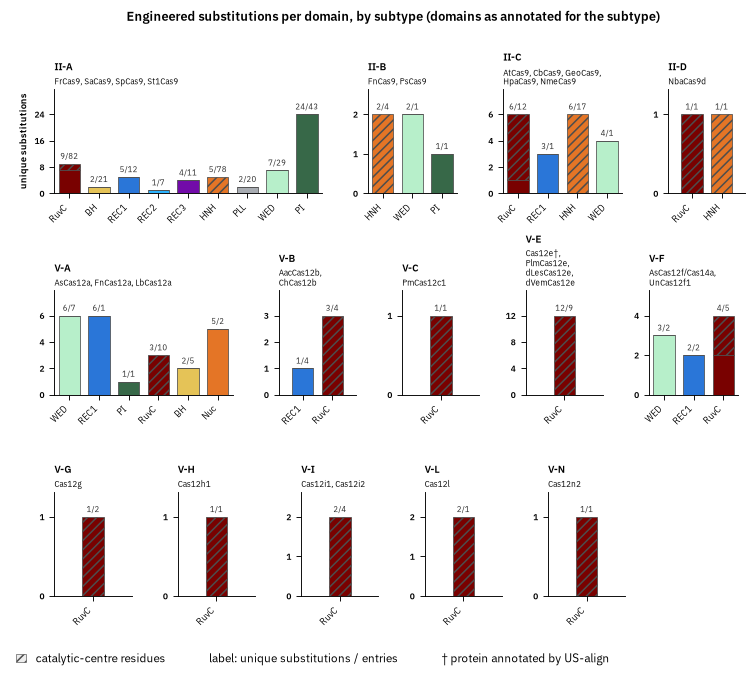

In [11]:
DF = domain_freq(GD, DOMS, SUBAUD)
COL = domain_palette(DF)  # {(семейство, домен): hex} — палитра ниже
# Представители листа сверяются с набором здесь, а не в разделе 1: нужны
# эффекторные сущности KEEP. Все разрезы по координатам дальше берут RECS отсюда.
RECS, REPNOTE = check_sheet_reps(RECS, T, KEEP)
print(
    "представители листа: строк",
    len(RECS),
    "| вне разрезов по координатам:",
    sum(bool(r["rep_problem"]) for r in RECS),
    "| замечаний:",
    len(REPNOTE),
)
for _, p in REPNOTE.iterrows():
    print(f"   {p.ортолог} ({p.pdb}): {p.замечание}")
# Разметка по структуре (US-align, раздел 18) для белков без годной строки
# листа — до разрезов: её берут фигуры 4, 5, 7 и 10 (ANNREC). Карта доменов,
# покрытие и размеры доменов (фигуры 8, 11–13) остаются на ручной RECS.
SREC, SRECNOTE = struct_annotations(RECS, T, KEEP)
ANNREC = RECS + SREC
ANN, ANNNOTE = entry_annotations(ANNREC, T)
_src = pd.Series({p: annotation_source(r) for p, r in ANN.items()})
print(
    "записей с разметкой:",
    len(ANN),
    "из",
    T.pdb.nunique(),
    "| по листу:",
    int((_src == "лист").sum()),
    "| по US-align:",
    int((_src == "US-align").sum()),
    f"({len(SREC)} белков)",
    "| без разметки:",
    len(ANNNOTE),
)
print(
    ANNNOTE.assign(причина=ANNNOTE.причина.map(reason_kind))
    .groupby("причина")
    .pdb.nunique()
    .to_string()
)
# Остатки активных центров по белкам (от якоря подтипа), и по ним замена каталитическая или нет
CAT = catalytic_sites(ANNREC, REFS, KEEP)
SITES = catalytic_site_map(CAT)
GS, GSNOTE = subs_sheet(G, T, ANNREC, REFS, KEEP, SITES)
CATAUD = catalytic_audit(GS)
CATSUB = catalytic_by_subtype(CAT, GS, T)
CATENT = catalytic_entries(GS, T)
_u = GS.drop_duplicates(["белок", "wt", "позиция", "mut"])
print(
    "центры активности: белков",
    CAT.белок.nunique(),
    "| с найденным центром:",
    CAT[CAT.определён].белок.nunique(),
    "| остатков найдено",
    int(CAT.определён.sum()),
    "из",
    len(CAT),
    "| каталитических замен (уникальных): прежнее правило",
    int(_u.каталитическая_прежняя.sum()),
    "-> таблица центров",
    int(_u.каталитическая.sum()),
)
print(
    CATAUD[CATAUD.решение != "то же"][
        ["подтип", "белок", "wt", "позиция", "mut", "решение", "основание"]
    ].to_string(index=False)
)
figM, DFS = fig_mut_domains(GS, ANNREC)
PUB = publication_table(GD)
print(
    "замен с доменом листа:",
    int(GS.семейство_домена.notna().sum()),
    "из",
    len(G),
    "| подтипов:",
    GS.подтип.nunique(),
    "| отброшено:",
    len(GSNOTE),
)
if len(GSNOTE):
    print(GSNOTE.groupby("причина").белок.unique().to_string())
print(
    "строк в таблице к фигуре:",
    len(PUB),
    "| уникальных замен: Cas9",
    int(DF[DF.fam == "Cas9"].уник_семейства.iloc[0]),
    "| Cas12",
    int(DF[DF.fam == "Cas12"].уник_семейства.iloc[0]),
)
DF.assign(
    класс=[DOM_CLASS.get(d, "вне доменов") for d in DF.домен],
    цвет=[COL[(f, d)] for f, d in zip(DF.fam, DF.домен)],
)[
    [
        "fam",
        "домен",
        "класс",
        "цвет",
        "уникальных",
        "уникальных_каталитических",
        "уникальных_PAM",
        "записей",
        "замен",
        "доля_уник_проц",
        "уникальных_на_100ао",
    ]
]


**Figure 5.** Unique engineered substitutions on the domain annotation of each subtype. Each panel is one subtype. The height of a bar is the number of distinct substitutions mapped onto that domain, and hatching marks a substitution of a catalytic residue. Domains are those published for the subtype. A substitution whose wild-type residue does not match the reference sequence of its own protein is excluded. This is review Figure 16; the review text discusses the Cas9 engineering programmes, and the figure counts substitutions for every subtype in the set.

Abbreviations: PAM, protospacer-adjacent motif.


In [12]:
# Таблицы центров. CATSUB — то, что нужно тексту: какие остатки каких подтипов считаются
# каталитическими и сколько записей несёт замену на них.
CATWIDE = (
    CAT[CAT.определён]
    .assign(остаток=lambda d: d.остаток_белка + np.where(d.ярус == 2, "*", ""))
    .groupby(["fam", "подтип", "белок", "pdb", "центр"], sort=False)
    .остаток.agg(" ".join)
    .unstack("центр")
    .reset_index()
)


In [13]:
SUBAUD = annotate_paper_checks(SUBAUD)


## 4. Overview of the set


записей по стадиям: {'Apo': 12, 'GuideRNA': 67, 'TargetEngage': 18, 'Rloop_partial': 84, 'Rloop_full': 215, 'AfterCleav': 37, 'PostCleav': 5}
подтипов на панели c (≥2 структур): 19 | с одной структурой, не показаны: 1


,fam,subtype,n,median,min,max
0,Cas12,V-L,1,3.36,3.36,3.36


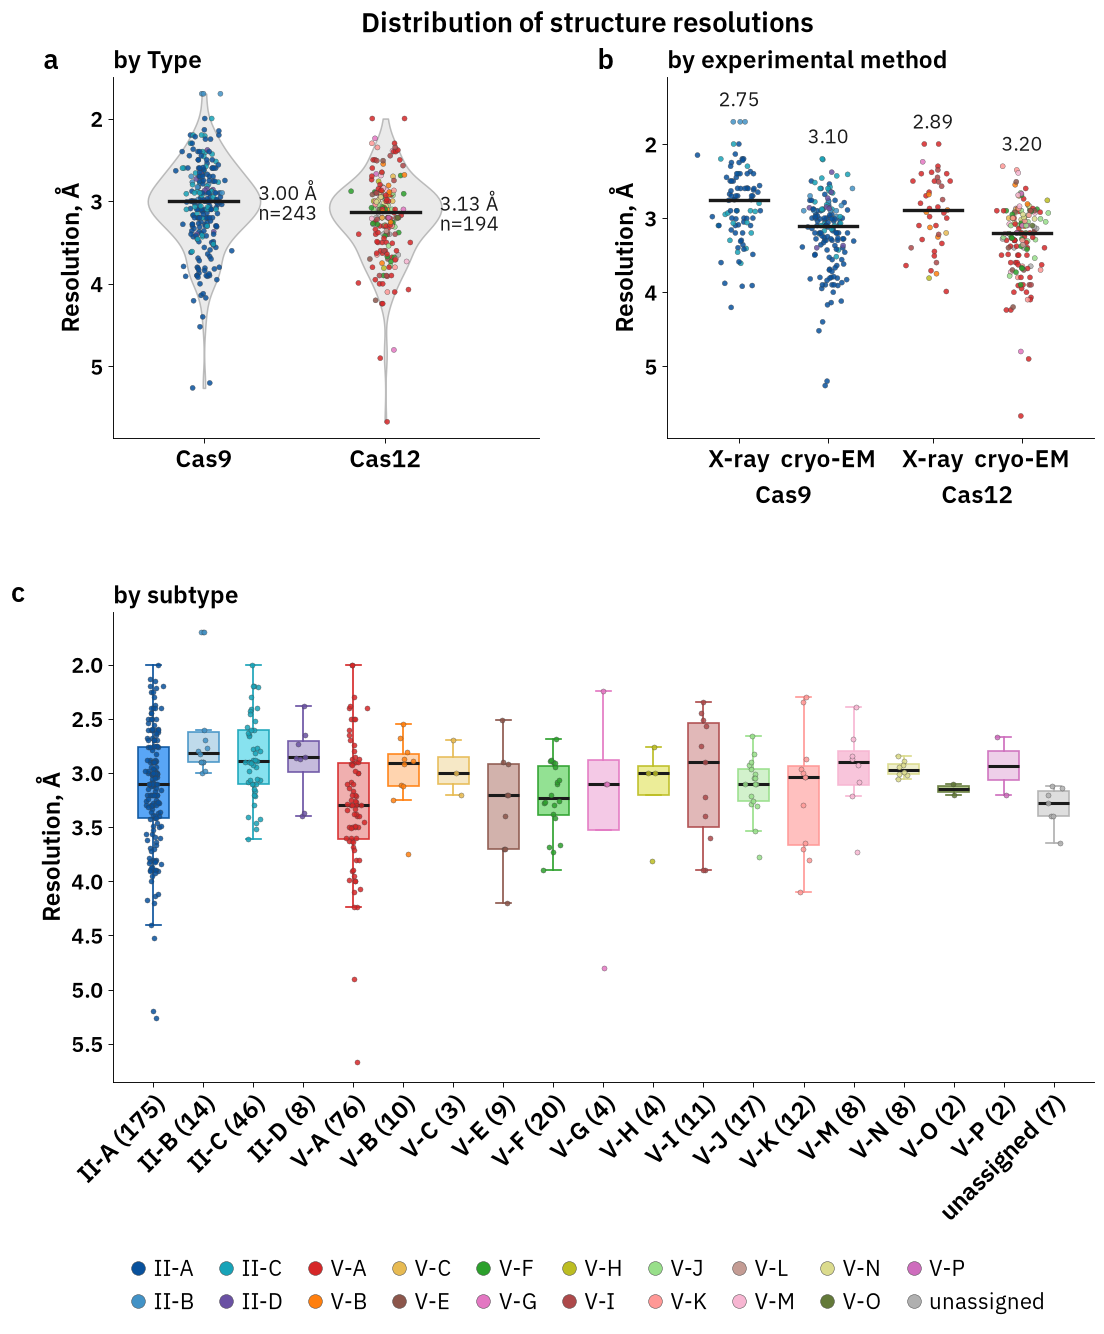

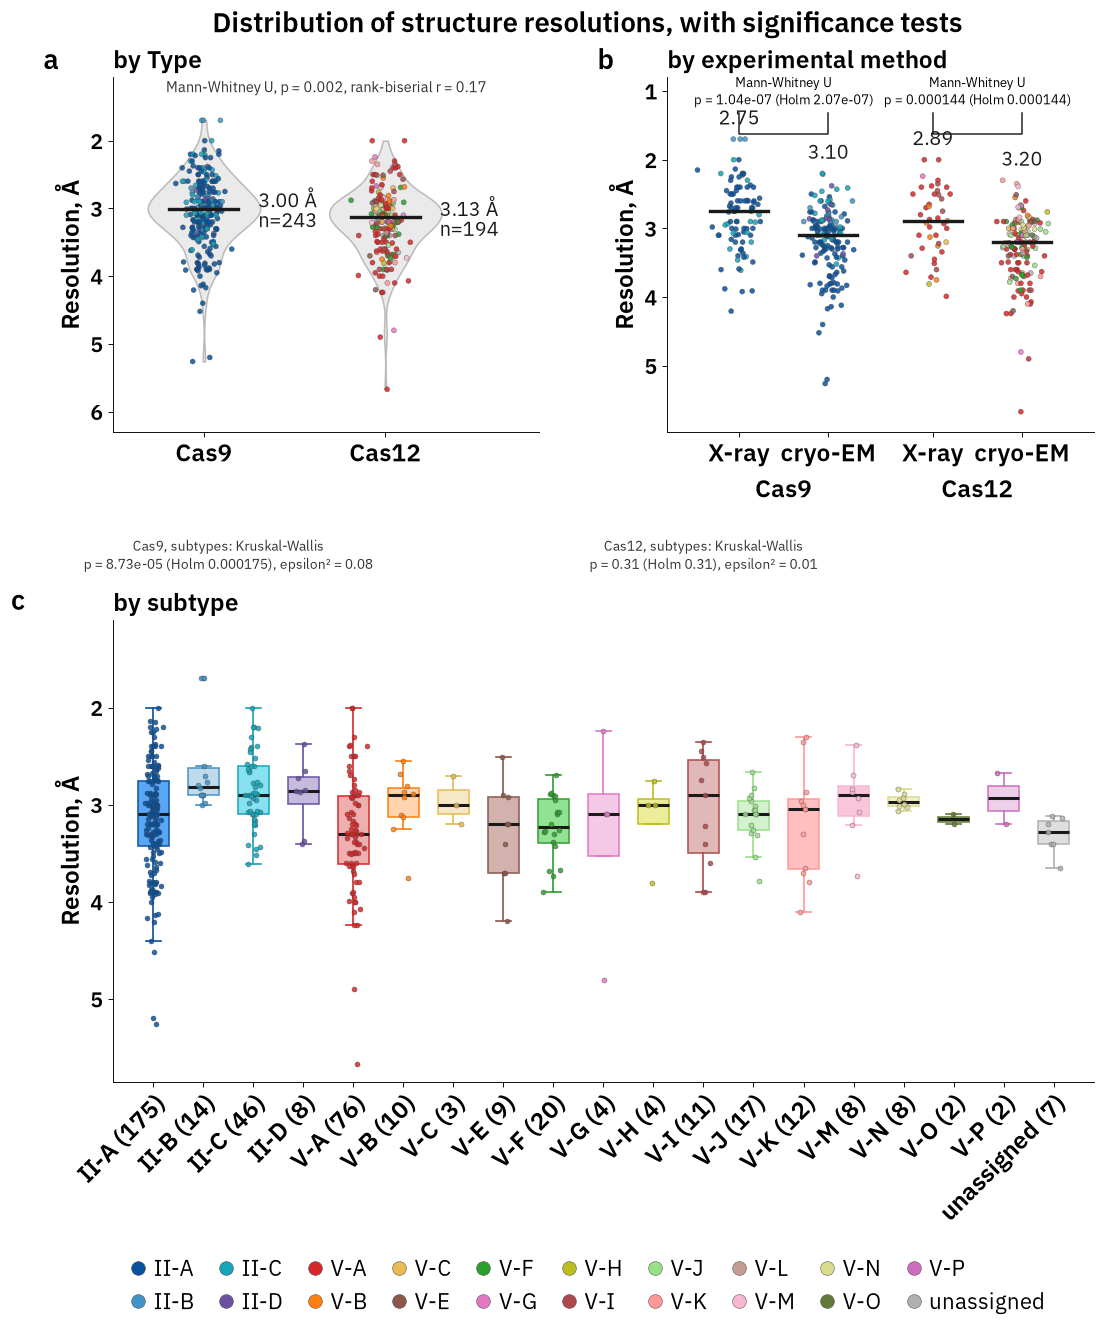

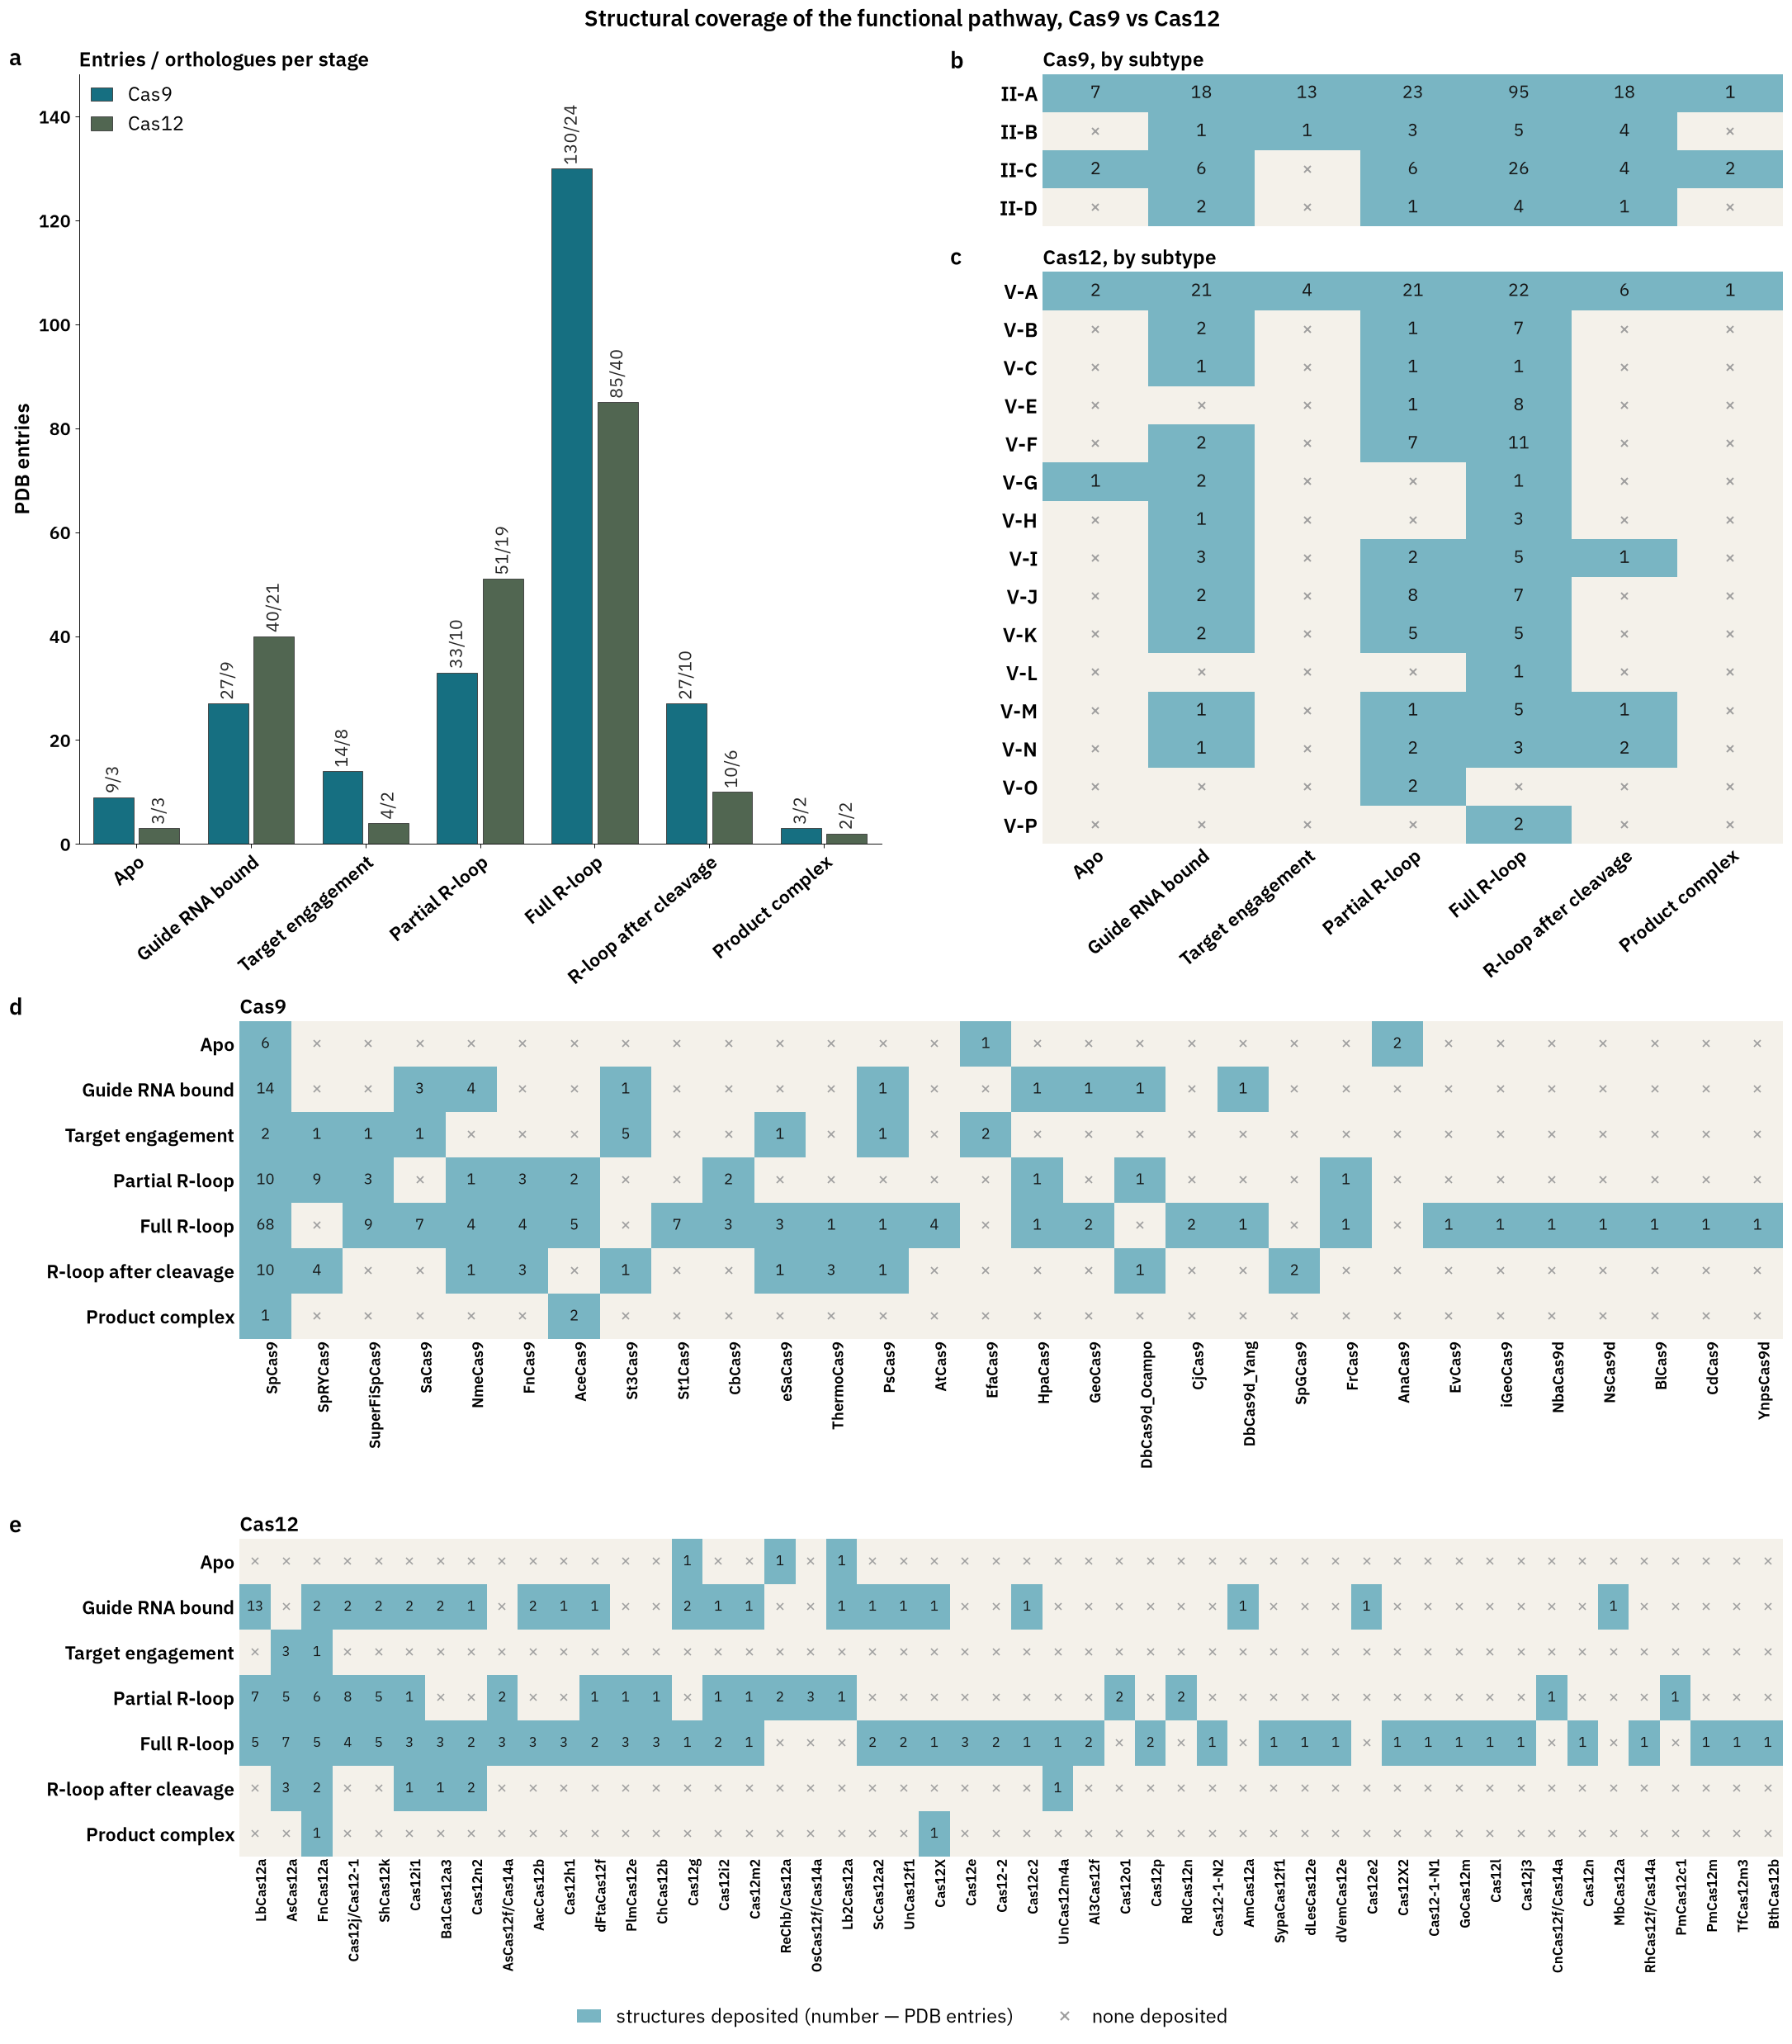

In [14]:
figR, gres, omitR = fig_resolution(T)
figR2, statsR = fig_resolution_stats(T)
figS, piv, pivs = fig_stages(T)
print("записей по стадиям:", piv.sum().astype(int).to_dict())
print(
    "подтипов на панели c (≥2 структур):",
    len(gres),
    "| с одной структурой, не показаны:",
    len(omitR),
)
omitR.sort_values(["fam", "subtype"])


**Figure 1.** Resolution of the 437 catalogued structures. **(a)** By effector type. Each point is one PDB entry, the bar is the median, and the label is the number of entries. **(b)** By experimental method within each type. **(c)** By subtype: the box is the median and interquartile range, whiskers are 1.5 times the interquartile range, and every entry is drawn. Subtypes with a single structure are omitted and listed beside the figure. The resolution axis is inverted, so a higher position is the better-resolved structure. Color is the subtype. This is review Figure 6.

**Figure 1, statistical companion.** The same three panels, with the comparison used on each. Type II against type V is one test and is not corrected. X-ray against cryo-EM is two tests, one inside each type, and the two *p*-values are Holm-corrected together. Subtypes are compared by one omnibus test inside Cas9 and one inside Cas12, again Holm-corrected as a pair. A group of at least three entries is checked with the Shapiro–Wilk test; the comparison is Welch or ANOVA when every group in it looks normal, and Mann–Whitney or Kruskal–Wallis otherwise.

**Figure 2.** Structural coverage of the DNA-cleavage pathway. **(a)** Entries and orthologs at each stage, type II against type V. **(b)** Cas9 counts by subtype. **(c)** Cas12 counts by subtype. **(d, e)** Ortholog maps for Cas9 and Cas12. Orthologs lie on the horizontal axis, with the ortholog that has the most structures at the left, and stages lie on the vertical axis; the two maps have the same width. A filled cell means that a structure exists at that stage, the numeral is the number of entries, and a cross means that there are none. One color denotes presence. PDB 8H9D contributes two stage rows, an apo copy and a guide-bound copy. This is review Figure 3. The count in each cell is the number of entries; the experimental method of each entry is in the accompanying table.


записей с длиной гетеродуплекса: 298 | из них с каталитической остановкой: 126
комплексов с партнёром в контактах: 52 | пар остатков: 2792 | на остатках без домена листа: 4.3 % | не вошли: 5
 pdb ортолог                    причина
8WUS  SpCas9 нет контактов ближе порога
8WUT  SpCas9 нет контактов ближе порога
8WUV  SpCas9 нет контактов ближе порога
8YGJ  SpCas9 нет контактов ближе порога
8YNY  SpCas9 нет контактов ближе порога
подтипов с R-петлёй: 19 | не нарисованы (нет каталитически неактивного комплекса): Cas12 V-G, Cas12 V-J, Cas12 V-K, Cas12 V-M, Cas12 V-N, Cas12 V-O, Cas12 V-P


записей  медиана_нт
fam   subtype catalytic_stall                     
Cas12 V-A     False                 34        15.0
              True                   8        18.5
      V-B     False                  5        19.0
              True                   3        20.0
      V-C     False                  1        17.0
              True                   1        14.0
      V-E     True                   9        20.0
      V-F     False                 15        18.0
              True                   3        17.0
      V-G     False                  1        24.0
      V-H     False                  2        18.0
              True                   1        21.0
      V-I     False                  3        18.0
              True                   4        19.0
      V-J     False                 15        15.0
      V-K     False                 10        13.0
      V-L     True                   1        20.0
      V-M     False                  6        18.0
      V-N     False                  5        16.0
      V-O     False                  2         8.0
      V-P     False                  2        17.0
Cas9  II-A    False                 45        18.0
              True                  75        20.0
      II-B    False                  4        14.5
              True                   4        21.0
      II-C    False                 18        20.0
              True                  16        20.0
      II-D    False                  4        20.5
              True                   1        25.0

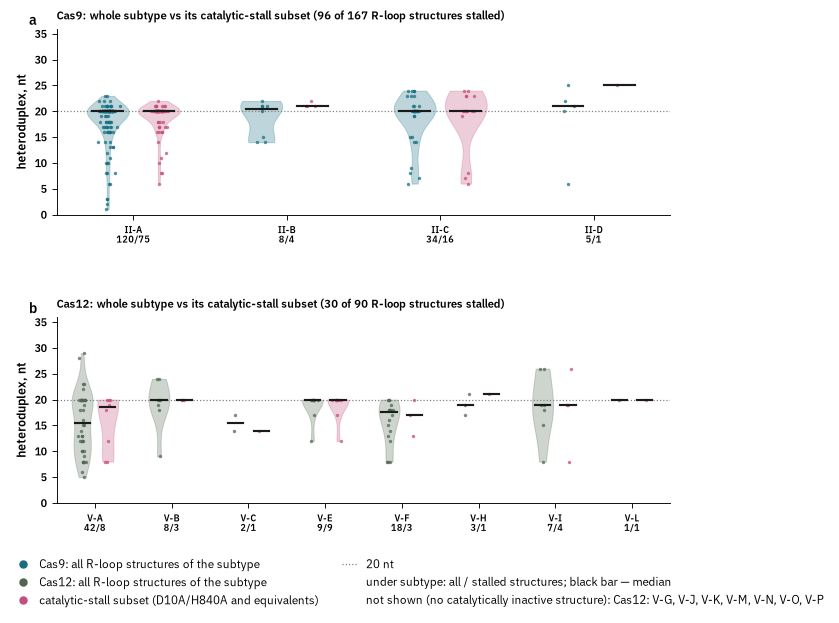

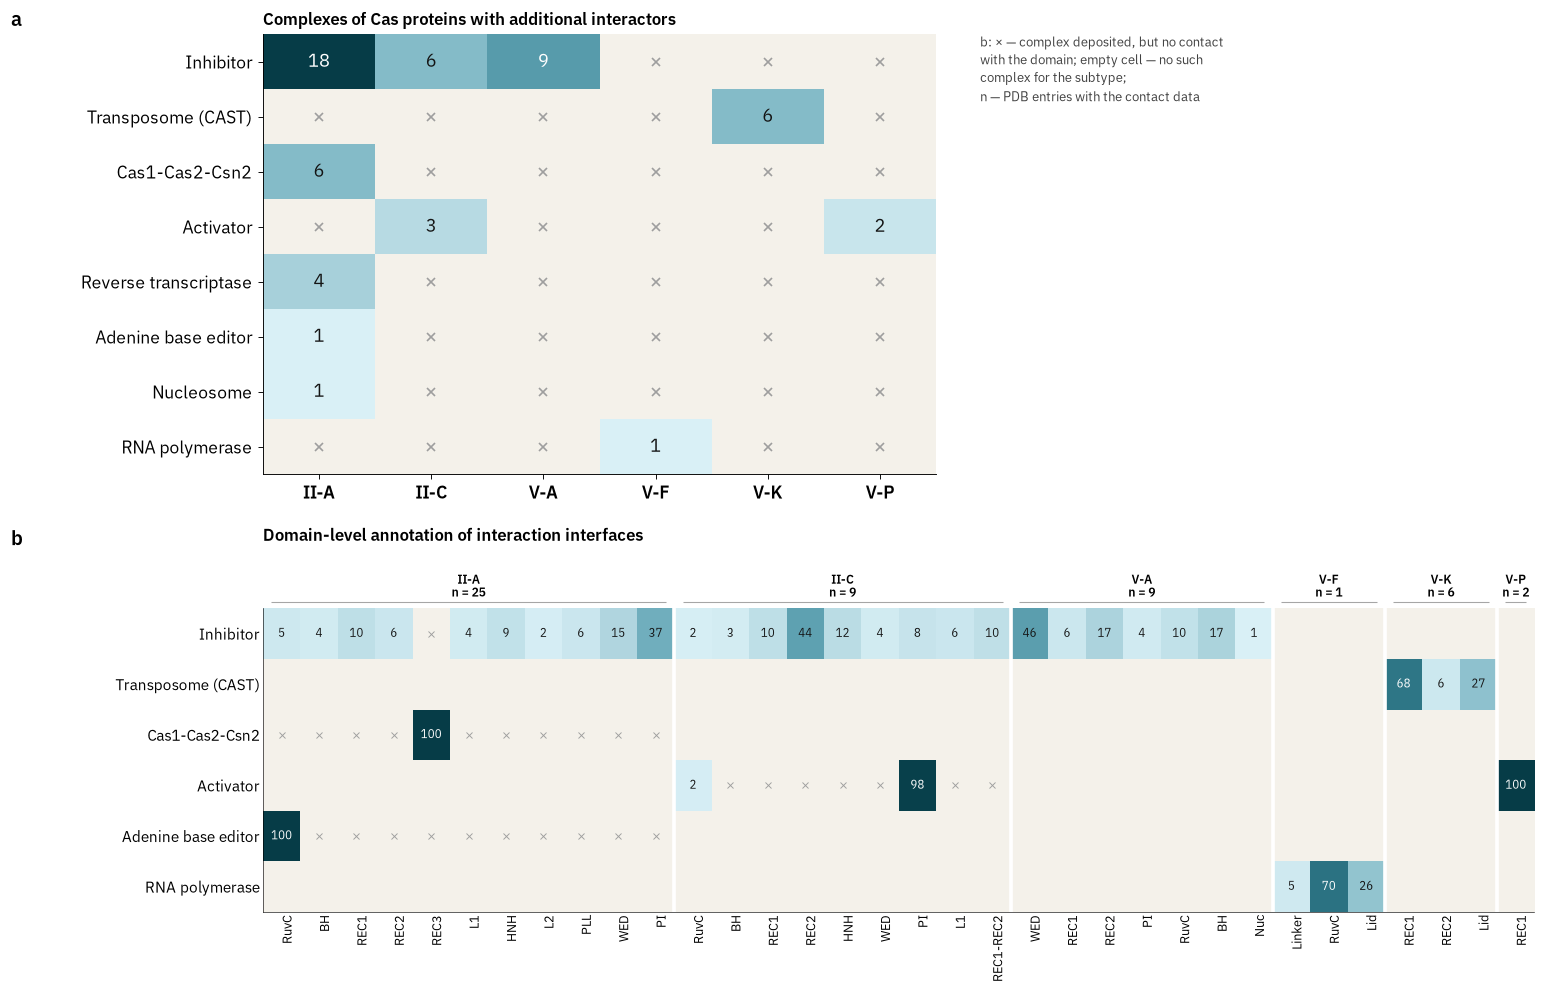

In [15]:
figL, rloop_tab = fig_rloop(T, G, GS)
PC, PCNOTE = partner_contacts(SGT, T, ANNREC)
figG, pivg, PCMAP = fig_subgroups(SGT, T, PC, ANNREC)
print(
    "записей с длиной гетеродуплекса:",
    len(rloop_tab),
    "| из них с каталитической остановкой:",
    int(rloop_tab.catalytic_stall.sum()),
)
print(
    "комплексов с партнёром в контактах:",
    PC.pdb.nunique(),
    "| пар остатков:",
    len(PC),
    f"| на остатках без домена листа: {100 * PC.семейство_домена.isna().mean():.1f} %",
    "| не вошли:",
    len(PCNOTE),
)
if len(PCNOTE):
    print(PCNOTE.to_string(index=False))
_ns = rloop_tab.groupby(["fam", "subtype"]).catalytic_stall.any()
print(
    "подтипов с R-петлёй:",
    len(_ns),
    "| не нарисованы (нет каталитически неактивного комплекса):",
    ", ".join(f"{f} {s}" for (f, s), v in _ns.items() if not v),
)
rloop_tab.groupby(["fam", "subtype", "catalytic_stall"]).agg(
    записей=("pdb", "size"), медиана_нт=("heteroduplex_bp", "median")
)


**Figure 3.** Heteroduplex length by subtype, and the subset stalled by a catalytic substitution. **(a)** Type II. **(b)** Type V. For each subtype that has both a measured heteroduplex and at least one catalytic stall, the left group is every entry of the subtype with a heteroduplex and the right group is the stalled subset. A violin is drawn when a group has at least six entries and the lengths are not all equal; otherwise the entries are points. The bar is the median. The dashed line is 20 nt. Entries with no length, a length of 0 nt, or no assigned subtype are omitted, and a subtype with no stalled entry is not drawn. A stall is a substitution of a tier-1 active-site residue; in Cas9 one inactivated center is a nickase. This is review Figure 5.

**Figure 4.** Protein partners bound with the effector. **(a)** Number of entries for each partner class and subtype. An entry that carries more than one class is counted in each. **(b)** Where the partner touches the effector. Columns are domain families, gathered in bands by subtype, and rows are the partner classes in the order of panel (a). A cell is the fraction of the effector residues that contact the partner and fall in that domain, averaged across entries. A cross means that the subtype has such a complex but no contact closer than 4 Å in that domain; an empty cell means that the subtype has no complex of that class. The numeral above a band is the number of entries with contacts. Nucleic acids are not counted. The stage of each complex is in the accompanying table. This is review Figure 7.

Abbreviations: CAST, CRISPR-associated transposon.


polymer_coverage получен для 437 записей из 437
Cas9 SpCas9 n = 111 | пропущено: 0
Cas12 FnCas12a n = 17 | пропущено: 0
провалов (доля построенных < 80 %, длина ≥ 5): 10


,fam,ортолог,начало,конец,длина,домен,min_pct,mean_pct,min_pos
0,Cas9,SpCas9,713,717,5,REC3,46.8,56.9,715
1,Cas9,SpCas9,766,776,11,"RuvC-II, HNH",16.2,32.3,771
2,Cas9,SpCas9,1012,1033,22,RuvC-III,28.8,43.5,1028
3,Cas9,SpCas9,1051,1058,8,RuvC-III,48.6,62.7,1054
4,Cas9,SpCas9,1243,1248,6,PI,58.6,68.3,1245
5,Cas12,FnCas12a,333,341,9,"REC1-I, REC2",47.1,55.6,336
6,Cas12,FnCas12a,424,443,20,REC2,41.2,55.0,430
7,Cas12,FnCas12a,546,557,12,REC2,64.7,66.7,550
8,Cas12,FnCas12a,1009,1020,12,RuvC-II,41.2,52.0,1010
9,Cas12,FnCas12a,1154,1163,10,Nuc,17.6,41.8,1158


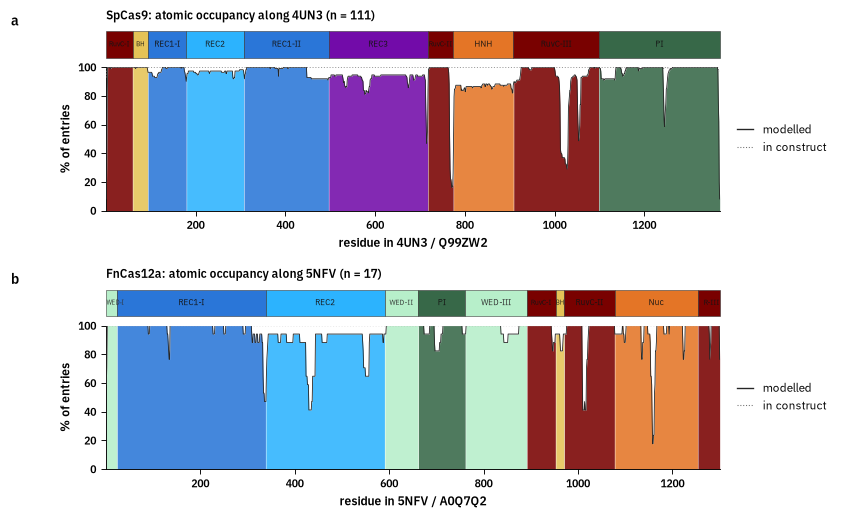

In [16]:
COV = pdbe(ALL_IDS, "polymer_coverage")
print(
    "polymer_coverage получен для",
    sum(v is not None for v in COV.values()),
    "записей из",
    len(COV),
)

refs = {fam: uniprot_seq(acc) for fam, acc in REF_ACC.items()}
profiles, skipped = {}, {}
for fam in ("Cas9", "Cas12"):
    profiles[fam], _, skipped[fam] = profile_family(fam, T, ENT, SEQS, COV, refs[fam])
    print(
        fam,
        REP_ORTHOLOG[fam],
        "n =",
        int(profiles[fam].n_записей.iloc[0]),
        "| пропущено:",
        len(skipped[fam]),
    )

figC = fig_coverage(profiles)
DS = pd.concat(
    [domain_summary(profiles[f], ARCH[f]) for f in ("Cas9", "Cas12")], ignore_index=True
)
GAPS = pd.concat(
    [occupancy_gaps(profiles[f]) for f in ("Cas9", "Cas12")], ignore_index=True
)
print("провалов (доля построенных < 80 %, длина ≥ 5):", len(GAPS))
GAPS


**Figure 6.** Fraction of the reference sequence present in the construct and modelled in the coordinates. **(a)** SpCas9, against UniProt Q99ZW2. **(b)** FnCas12a, against UniProt A0Q7Q2. The solid line is the fraction of entries in which the residue is modelled, and the dashed line is the fraction in which it is present in the construct. The schematic above each trace is the domain annotation of PDB 4UN3 and PDB 5NFV. Engineered variants of SpCas9, and every other ortholog, are separate proteins and are not projected onto these two references. Review Figure 8 is a rendering of 4UN3 and 5NFV; this figure is the occupancy of those sequences across the entries deposited under the same name.


## 5. Contact interfaces: Cas9 against Cas12


In [17]:
MODULATOR = {"анти-CRISPR", "анти-Thoeris", "активатор эффектора"}
mod = {p for p, tags in SG.items() if MODULATOR & set(tags)}
eng = set(PERE[PERE.статус == "инженерный"].pdb)

cand = T[(T.stage == "Rloop_full") & (T.res <= 3.5)].copy()
cand["есть_ДНК"] = cand.pdb.map(lambda p: NA.get(p, {}).get("есть_ДНК", False))
cand["модулятор"] = cand.pdb.isin(mod)
cand["инженерный"] = cand.pdb.isin(eng)
REP = (
    cand[cand.есть_ДНК]
    .sort_values(["модулятор", "res", "инженерный", "pdb"])
    .drop_duplicates("effector")[
        ["pdb", "fam", "effector", "stage", "res", "модулятор", "инженерный"]
    ]
)

print(
    "кандидатов (полная R-петля, ≤ 3.5 Å):",
    len(cand),
    "| отброшено записей с РНК-мишенью:",
    int((~cand.есть_ДНК).sum()),
    sorted(cand[~cand.есть_ДНК].pdb),
)
print(
    "представителей:",
    len(REP),
    "| Cas9:",
    int((REP.fam == "Cas9").sum()),
    "| Cas12:",
    int((REP.fam == "Cas12").sum()),
    "| с модулятором (другой записи нет):",
    int(REP.модулятор.sum()),
    "| инженерных:",
    int(REP.инженерный.sum()),
)
REP.head(10)


кандидатов (полная R-петля, ≤ 3.5 Å): 187 | отброшено записей с РНК-мишенью: 3 ['21WJ', '8D4B', '9HM4']
представителей: 61 | Cas9: 23 | Cas12: 38 | с модулятором (другой записи нет): 1 | инженерных: 23


,pdb,fam,effector,stage,res,модулятор,инженерный
313,5B2O,Cas9,FnCas9,Rloop_full,1.70,False,True
420,8X5V,Cas9,BlCas9,Rloop_full,2.00,False,False
316,5B2R,Cas9,SpCas9,Rloop_full,2.00,False,True
336,5XH6,Cas12,AsCas12a,Rloop_full,2.00,False,True
38,8D2L,Cas9,AceCas9,Rloop_full,2.21,False,False
291,8RDU,Cas12,ShCas12k,Rloop_full,2.30,False,False
335,5X2H,Cas9,CjCas9,Rloop_full,2.30,False,True
436,7EU9,Cas12,Cas12i1,Rloop_full,2.35,False,True
205,9K31,Cas9,YnpsCas9d,Rloop_full,2.38,False,False
301,23VW,Cas12,TfCas12m3,Rloop_full,2.39,False,True


In [18]:
FAMREF = {"Cas9": "Q99ZW2", "Cas12": "A0Q7Q2"}
FAM = REP.set_index("pdb").fam.to_dict()
ids = list(REP.pdb)
os.makedirs("cif", exist_ok=True)
got = fetch_cif(ids)
print("координаты:", pd.Series(got).value_counts().to_dict())

frames, meta, bad = [], [], {}
t0 = time.time()
for i, pid in enumerate(ids, 1):
    try:
        src = "sifts"
        pt = paint_table(build_context([pid], cif_dir="cif"))
        if pt.empty and pid in FAM:
            src = "семейный референс"
            pt = paint_table(
                build_context([pid], cif_dir="cif", ref_of={pid: FAMREF[FAM[pid]]})
            )
        if pt.empty:
            bad[pid] = "нет разметки доменов"
            continue
        df, nbp = profile_entry(pid, pt)
        if df.empty:
            bad[pid] = "нет контактов белок-НК"
            continue
        frames.append(df)
        meta.append(
            dict(
                pdb=pid,
                n_контактов=len(df),
                целевая_цепь_найдена=bool(nbp),
                ref=pt.ref.iloc[0],
                источник_ref=src,
                покрытие=round(float(pt.pct.mean()), 1),
            )
        )
    except Exception as e:
        bad[pid] = f"{type(e).__name__}: {e}"
    if i % 10 == 0:
        print(
            f"  {i}/{len(ids)} посчитано={len(frames)} не вышло={len(bad)}"
            f" ({time.time() - t0:.0f} с)",
            flush=True,
        )

IFC = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["pdb"])
MET = pd.DataFrame(meta)
# Прогон, в котором не сосчиталась заметная доля представителей, — это почти
# всегда сеть или координаты, а не данные; падать надо здесь, а не на фигуре.
missing = sorted(set(ids) - set(IFC.pdb))
assert len(missing) <= 0.15 * len(ids), (
    f"профиль не собран для {len(missing)} из {len(ids)} представителей: "
    + ", ".join(missing)
    + "\n"
    + "; ".join(f"{p}: {m}" for p, m in bad.items())
)
print(
    f"готово за {time.time() - t0:.0f} с:",
    IFC.pdb.nunique(),
    "записей,",
    len(IFC),
    "контактов | не вышло:",
    len(bad),
    bad or "",
)


координаты: {'cached': 61}
  10/61 посчитано=10 не вышло=0 (2 с)
  20/61 посчитано=20 не вышло=0 (4 с)
  30/61 посчитано=30 не вышло=0 (6 с)
  40/61 посчитано=40 не вышло=0 (6 с)
  50/61 посчитано=50 не вышло=0 (8 с)
  60/61 посчитано=60 не вышло=0 (10 с)
готово за 10 с: 61 записей, 16984 контактов | не вышло: 0 


контакт белок–НК ближе 4.0 Å | контактов: 15519 | записей: 57 | подтипов: 17 | на остатках без домена листа: 0.2 %
без целевой цепи ДНК: 1 | пропущено по листу разметки: нет годной строки листа разметки: 3


партнёр       гидовая РНК  нецелевая цепь ДНК  целевая цепь ДНК
подтип домен                                                   
II-A   BH            13.3                 0.0               0.1
       HNH            0.5                 0.0               1.3
       L1             0.3                 0.0               0.5
       L2             0.0                 0.1               0.2
       PI             8.3                 3.7               1.6
...                   ...                 ...               ...
V-N    WED           17.4                 2.6               7.9
V-P    PI             0.0                 1.8               3.6
       REC1           8.9                 6.5               2.4
       RuvC          48.8                 0.0               7.7
       WED           13.1                 1.8               5.4

[127 rows x 3 columns]

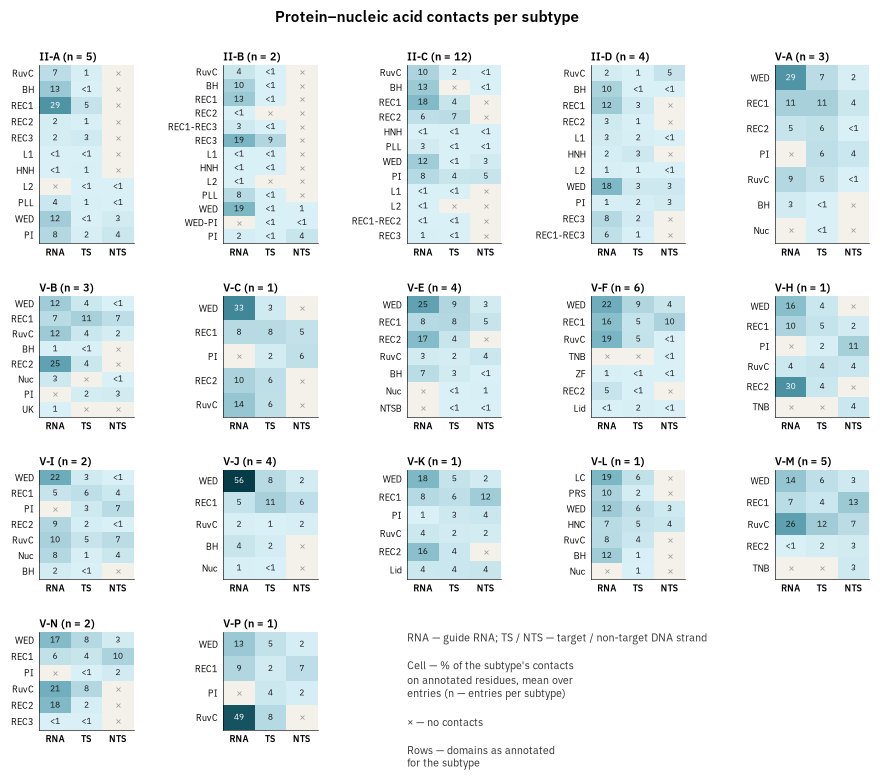

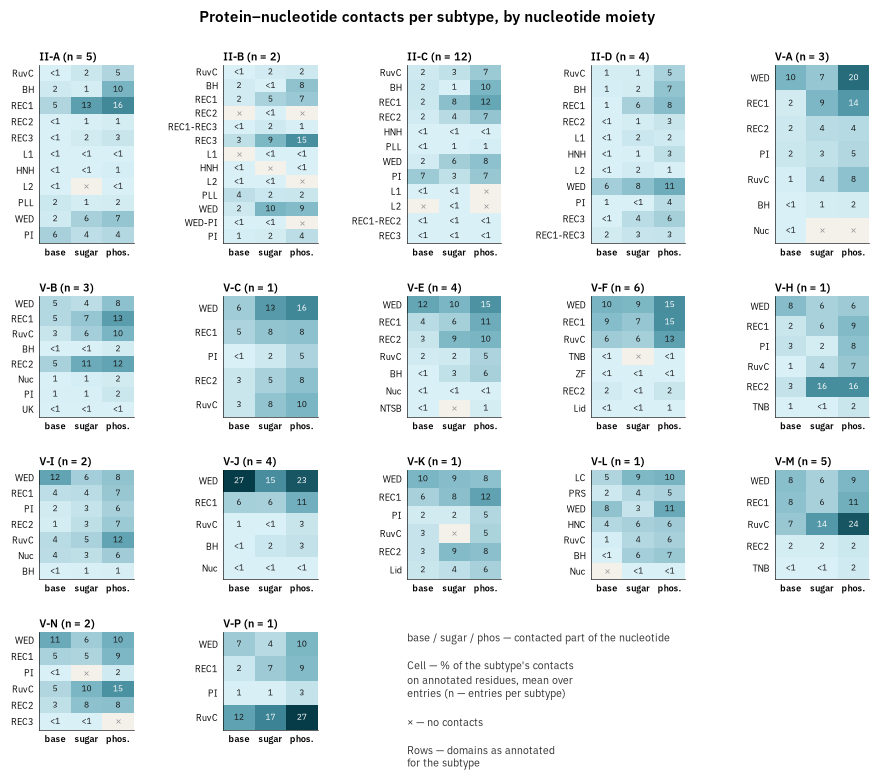

In [19]:
IFS, IFSNOTE = iface_sheet(IFC, MET, T, ANNREC)
figI, IMAP = fig_iface_contacts(IFS, ANNREC, by="партнёр")
figIM, IMAPM = fig_iface_contacts(IFS, ANNREC, by="часть", path="cas_iface_moiety.png")
print(
    "контакт белок–НК ближе",
    CONTACT_CUTOFF,
    "Å | контактов:",
    len(IFS),
    "| записей:",
    IFS.pdb.nunique(),
    "| подтипов:",
    IFS.подтип.nunique(),
    f"| на остатках без домена листа: {100 * IFS.семейство_домена.isna().mean():.1f} %",
)
print(
    "без целевой цепи ДНК:",
    int((~MET.целевая_цепь_найдена).sum()),
    "| пропущено по листу разметки:",
    reasons_summary(IFSNOTE),
)
IMAP


**Figure 7.** Fraction of protein–nucleic-acid contacts contributed by each domain at the full R-loop. Each panel is one subtype, and the representative is one entry per ortholog. Rows are the domain families in the order of that subtype's annotation. Columns are the guide RNA, the target DNA strand and the non-target DNA strand. A contact is a pair of atoms closer than 4 Å, collapsed to a residue–nucleotide pair. Each entry is normalized by its own number of contacts and the entries of a subtype are then averaged, so the percentages in a panel sum to 100. A cross means that no contact was found. Chains that are not the effector, and residues outside the annotated domains, are not in the map. This is review Figure 15.

**Figure 7, nucleotide moiety.** The same contacts, with columns for the base, the sugar and the phosphate instead of the nucleic-acid strand. The part is taken from the closest atom pair.

Abbreviations: RNA, ribonucleic acid; TS, target strand; NTS, non-target strand.


## 6. Domain organization of the representatives


In [20]:
# + замечания сверки представителей с набором (раздел 3)
DOMPROB = pd.concat([domain_map_problems(RECS), REPNOTE], ignore_index=True)

print(
    f"записей в карте: {len(RECS)} "
    f"({sum(r['fam'] == 'Cas9' for r in RECS)} Cas9, "
    f"{sum(r['fam'] == 'Cas12' for r in RECS)} Cas12) | "
    f"исключено: {len(SKIPPED)} | замечаний к разметке: {len(DOMPROB)}"
)
for _, p in DOMPROB.iterrows():
    print(f"   {p.ортолог} ({p.pdb}): {p.замечание}")
SKIPPED


записей в карте: 65 (30 Cas9, 35 Cas12) | исключено: 8 | замечаний к разметке: 5
   CjCas9 (5X2G): в нумерации конструкта нет 155 из 984 размеченных остатков (домены без половины и больше: HNH 155/160): делеционный конструкт или границы листа не в авторской нумерации записи; записи с той же нумерацией и более полным конструктом нет
   AceCas9 (6WC0): в нумерации конструкта нет 161 из 1138 размеченных остатков (домены без половины и больше: HNH 158/160): делеционный конструкт или границы листа не в авторской нумерации записи; разметку на записи ортолога переносит 8D2K — нумерация та же, в конструкте 1138 из 1138 размеченных остатков
   BlCas9 (8X5V): в нумерации конструкта нет 159 из 1092 размеченных остатков (домены без половины и больше: HNH 159/166): делеционный конструкт или границы листа не в авторской нумерации записи; записи с той же нумерацией и более полным конструктом нет
   CdCas9 (6JOO): в нумерации конструкта нет 160 из 1084 размеченных остатков (домены без половины и больш

,fam,ортолог,pdb,причина
0,Cas12,MbCas12a,6IV6,нет разметки в статье
1,Cas12,ScCas12a2,8D4A,нет разметки в статье
2,Cas12,Al3Cas12f,9NZO,нет доменов
3,Cas12,CnCas12f,8HR5,нет доменов
4,Cas12,OsCas12f,9NZQ,нет доменов
5,Cas12,RhCas12f,9NZP,нет доменов
6,Cas12,TfCas12m3,23VW,нет доменов
7,Cas12,UnCas12m4a,23VU,нет доменов


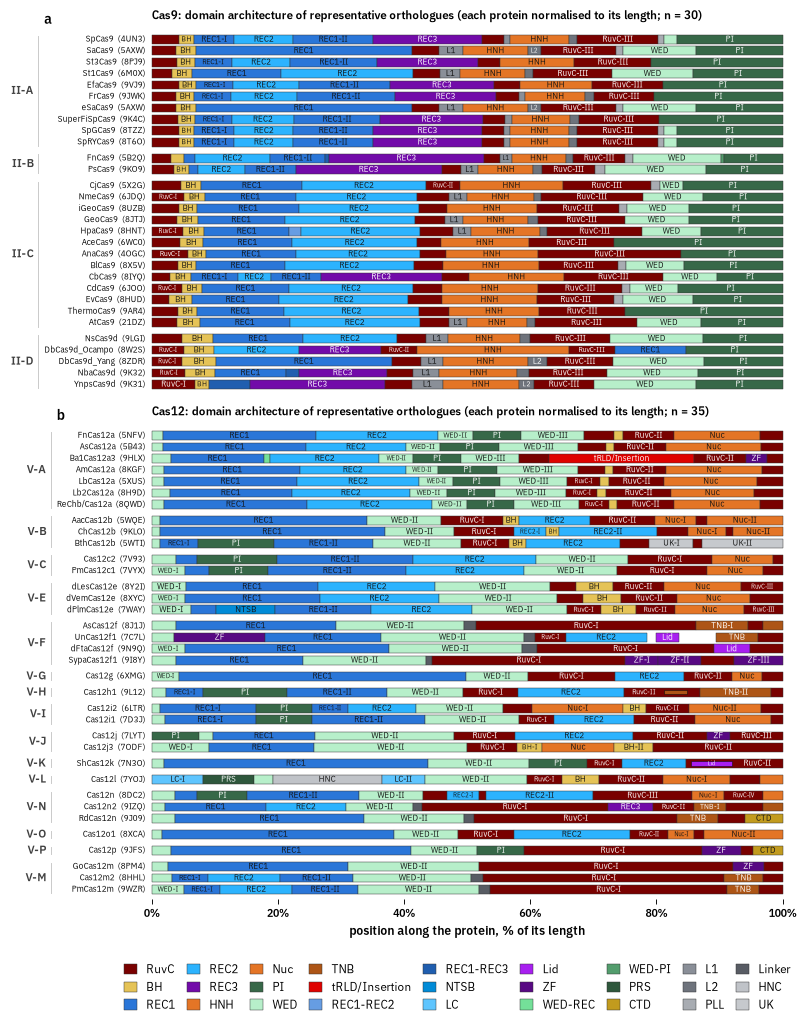

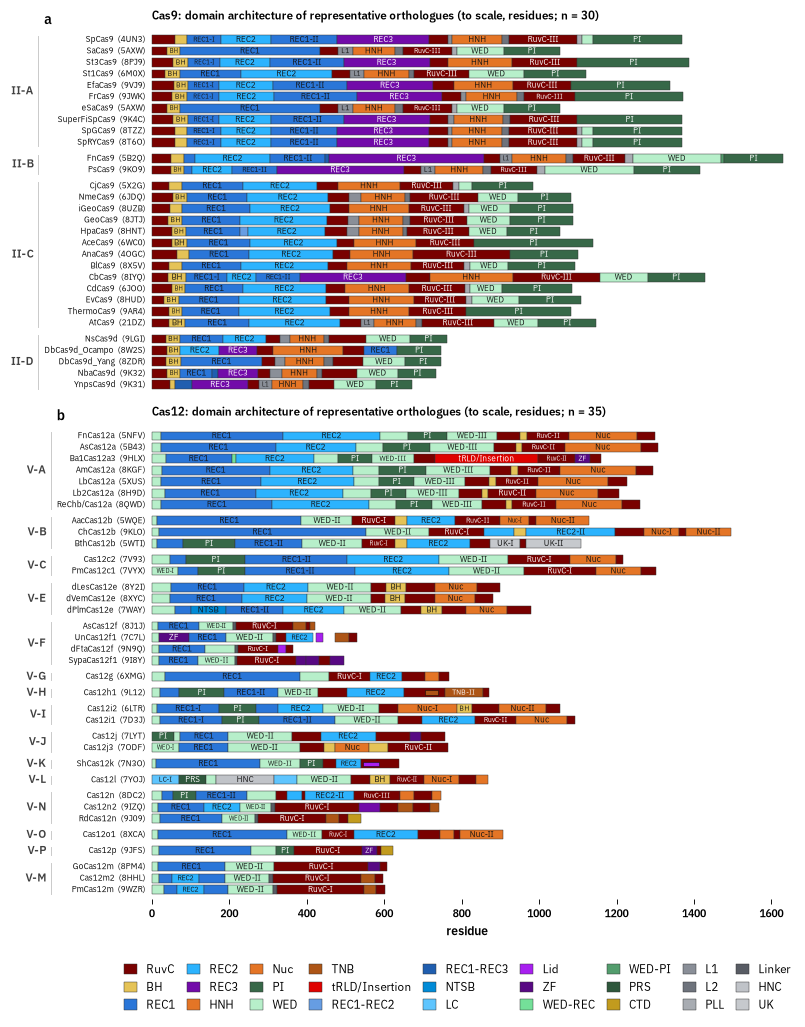

In [21]:
figDE = fig_domain_map(RECS, mode="equal", path="cas_domain_map_equal.png")
figDM = fig_domain_map(RECS, mode="scaled", path="cas_domain_map_scaled.png")


**Figure 8.** Domain architecture of the orthologs with published residue boundaries. The upper drawing scales every protein to its own length. The lower drawing places the same architectures on one residue axis. Each band is one ortholog, grouped by subtype and ordered from the N terminus to the C terminus. A domain that lies inside another is drawn inside it. A residue written as the end of one domain and the start of the next is given to the domain on the left. Color is the domain family. Rows that name domains but do not publish boundaries, and rows with no domains, are omitted; the seven of those rows that can be annotated by structural transfer are in Figure 15, and ScCas12a2 is not annotated. This is review Figure 11.


## 7. Further cuts of the set


ортологов с измеренным гетеродуплексом: 72 | предельная длина в наборе, нт: 29


,ортологов,медиана_предела
fam,,
Cas12,46,20.0
Cas9,26,20.5


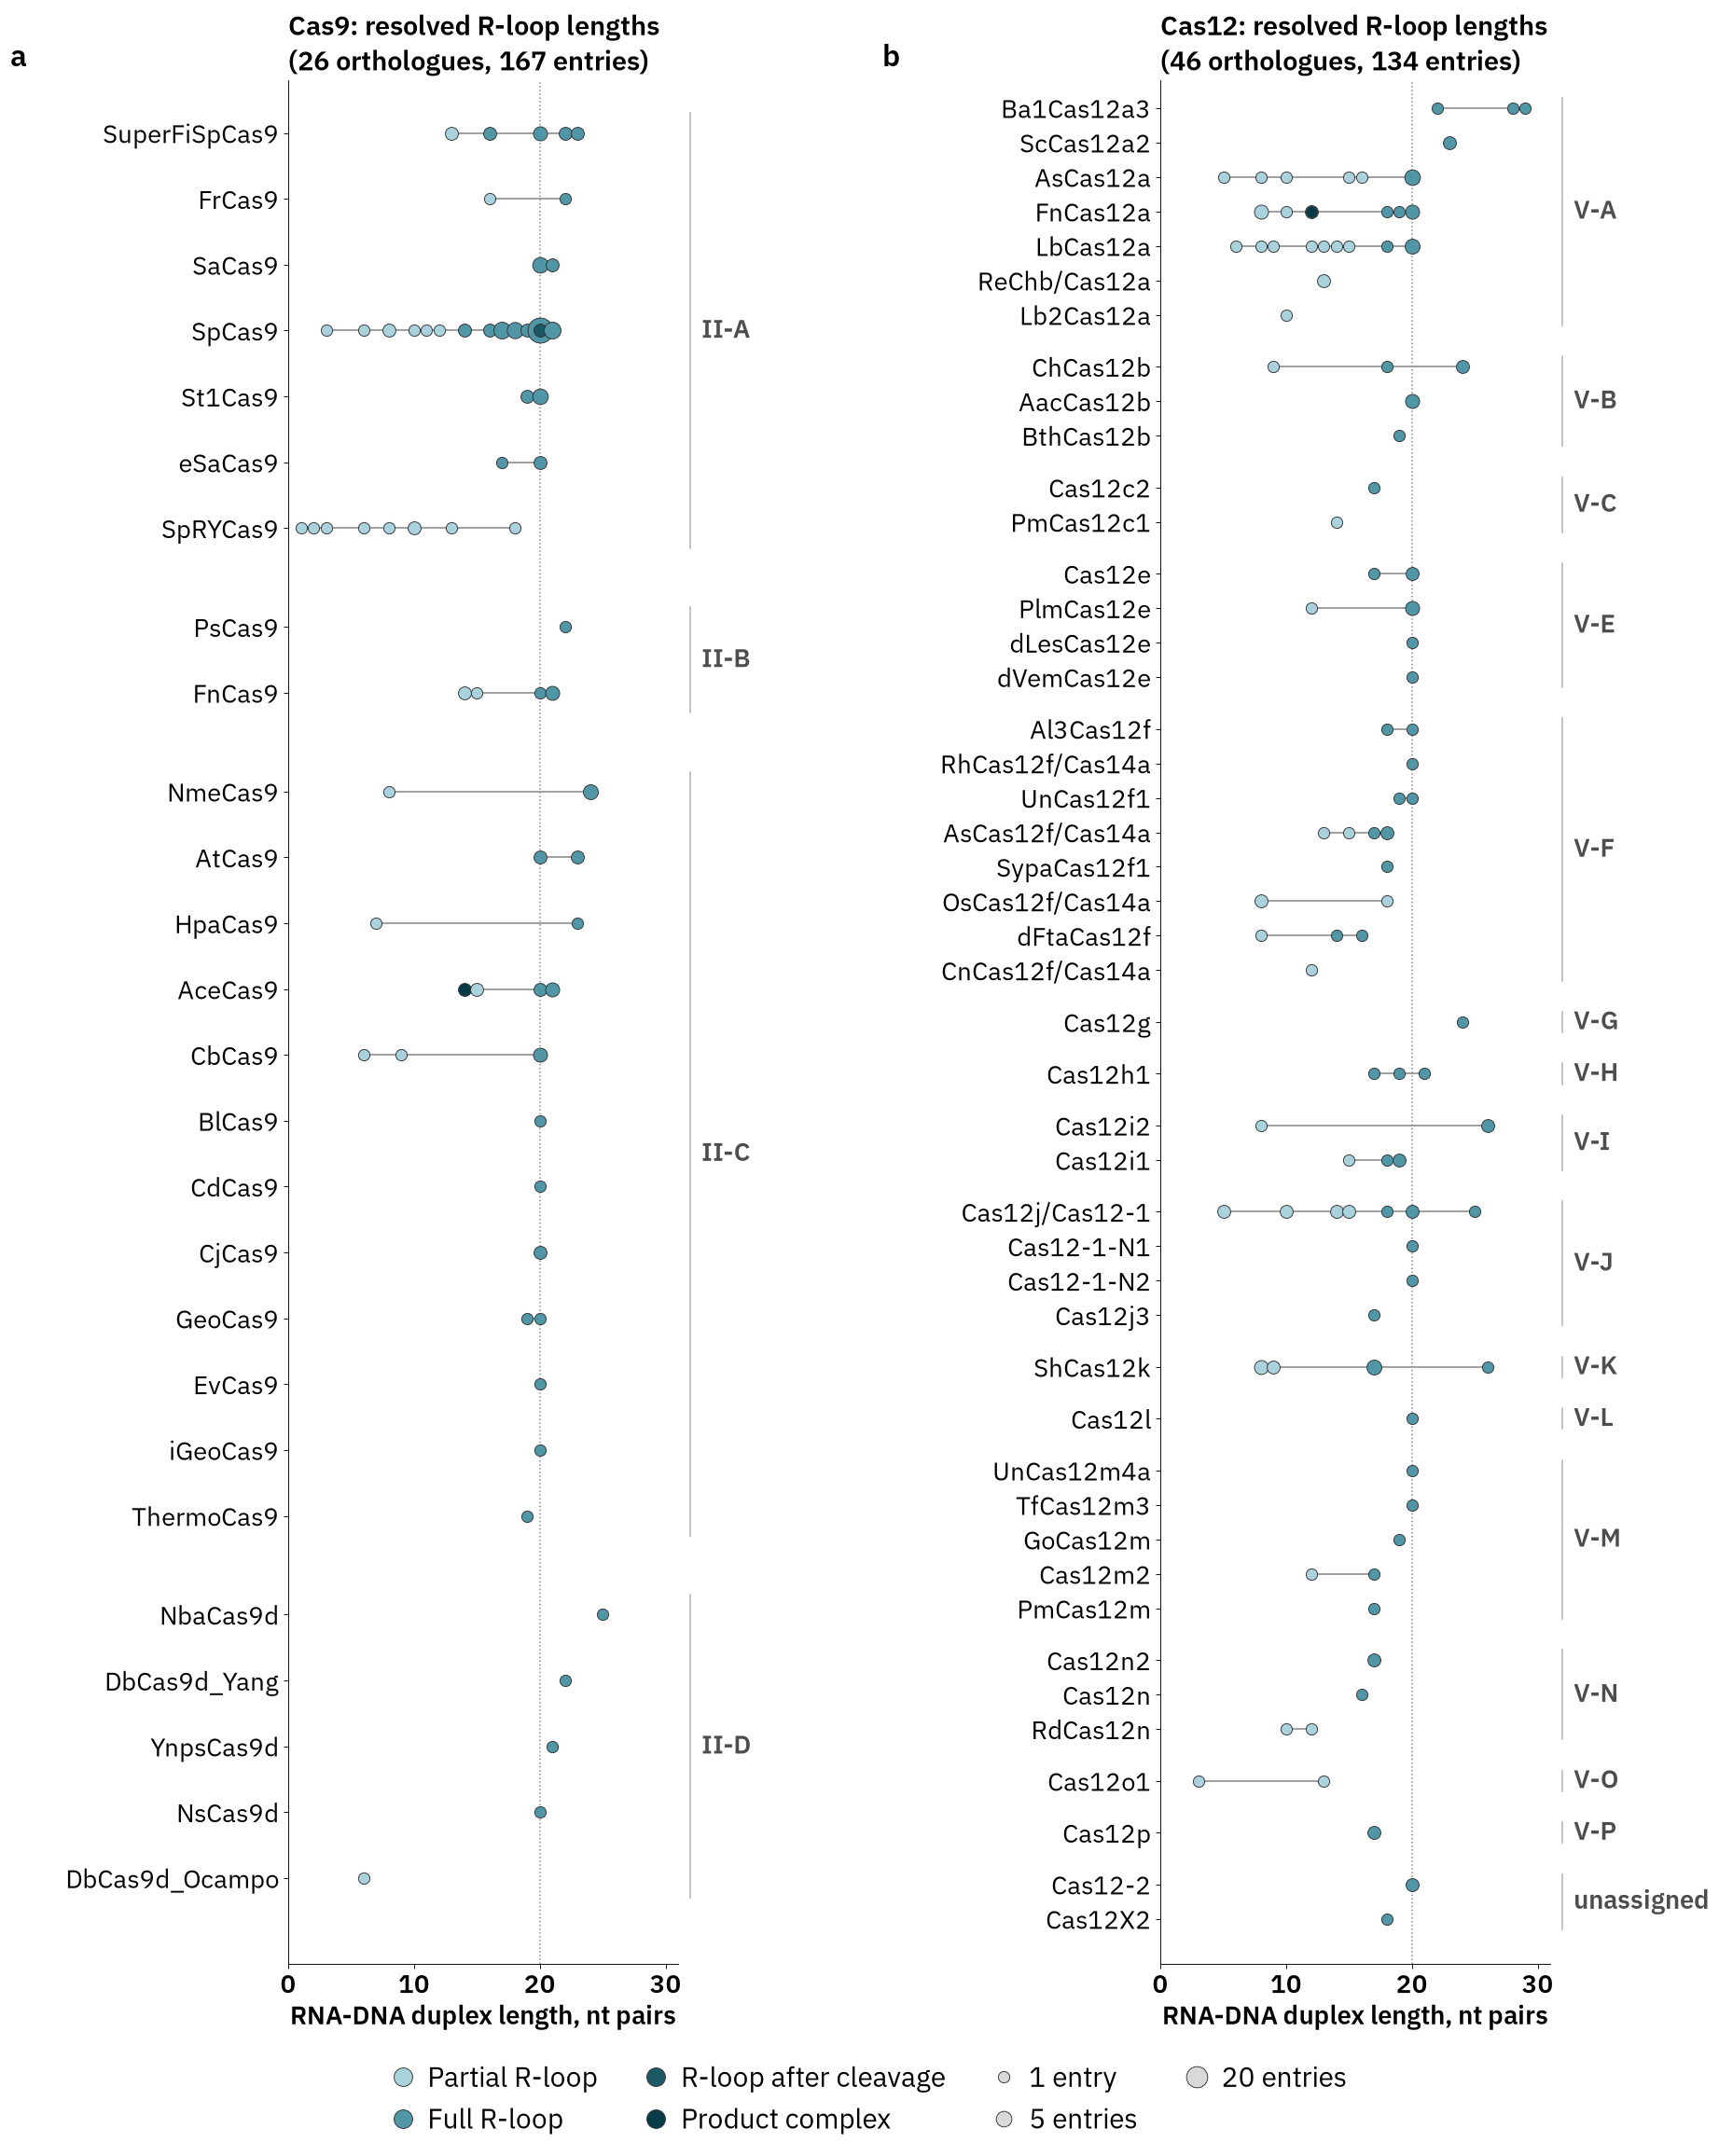

In [22]:
RC = rloop_coverage(T)
figRC = fig_rloop_coverage(T)

print(
    "ортологов с измеренным гетеродуплексом:",
    RC.ортолог.nunique(),
    "| предельная длина в наборе, нт:",
    int(RC.максимум.max()),
)
RC.groupby("fam").agg(
    ортологов=("ортолог", "nunique"), медиана_предела=("максимум", "median")
)


**Figure 9.** Range of resolved heteroduplex lengths for each ortholog. Each row is one ortholog, grouped by subtype, and the subtype is labelled at the right. The line runs from the shortest to the longest heteroduplex of that ortholog. A point is one length, its area is the number of entries at that length, and its color is the stage of the pathway. A heteroduplex of 0 nt is a product complex and is omitted, as is an entry with no length. Review Figure 4 is the distribution of these lengths by stage; the counts for that distribution are in the heteroduplex table, and this figure shows how far each ortholog has been sampled.


In [23]:
RR, RRNOTE = rec_rotation(ANNREC, T)
# Figure 10 is drawn with both angles once the all-stages table exists.

RRS = rec_rotation_shown(RR)  # те же записи, что на фигуре 10 (без референсов с 0°)
print(
    "ортологов:",
    RR.ортолог.nunique(),
    "| подтипов:",
    RR.подтип.nunique(),
    "| записей измерено:",
    len(RR),
    "| пропущено:",
    len(RRNOTE),
    "| на фигуре и в сводках ниже:",
    len(RRS),
)
# самопроверка: референс, совмещённый сам с собой, обязан дать 0°
assert set(RR.loc[RR.pdb == RR.референс, "угол_REC"]) <= {
    0.0
}, "референс сам на себя не ноль"
# панель c описательна: на фигуре p не рисуется (сравнение методов — панель f);
# Манн–Уитни, двусторонний, остаётся в таблице
RRT = rec_method_tests(RRS)
# чувствительность: без серии SpCas9 с несовпадающей мишенью (Pacesa et al., 2022, Cell,
# doi 10.1016/j.cell.2022.09.026; все записи серии — X-ray)
_mm = set(T[T.doi.astype(str).str.contains("2022.09.026", regex=False)].pdb)
RRT_nm = rec_method_tests(RRS[~RRS.pdb.isin(_mm)])
RRTAB = pd.concat(
    [
        RRT.assign(набор="все записи фигуры"),
        RRT_nm.assign(
            набор=f"без серии с несовпадающей мишенью ({int(RRS.pdb.isin(_mm).sum())} записей)"
        ),
    ],
    ignore_index=True,
)
print("cryo-EM против X-ray, описательно (стратифицированное сравнение — панель f):")
print(RRTAB.round(4).to_string(index=False))
# сводка по семейству: медиана и квартили по записям фигуры
print(
    RRS.groupby("fam")
    .agg(
        записей=("pdb", "size"),
        ортологов=("ортолог", "nunique"),
        q1=("угол_REC", lambda x: x.quantile(0.25)),
        медиана=("угол_REC", "median"),
        q3=("угол_REC", lambda x: x.quantile(0.75)),
        максимум=("угол_REC", "max"),
    )
    .round(1)
    .to_string()
)
RRS.groupby(["fam", "подтип"], observed=True, sort=False).agg(
    ортологов=("ортолог", "nunique"),
    записей=("pdb", "size"),
    медиана_угла=("угол_REC", "median"),
    максимум=("угол_REC", "max"),
    медиана_RMSD_NUC=("rmsd_NUC", "median"),
)


ортологов: 40 | подтипов: 15 | записей измерено: 266 | пропущено: 37 | на фигуре и в сводках ниже: 212
cryo-EM против X-ray, описательно (стратифицированное сравнение — панель f):
  fam  n_Xray  n_cryoEM  медиана_Xray  медиана_cryoEM      U      p  r_бисериальная                                          набор
 Cas9      64        69           4.5             1.4 3097.5 0.0001            0.40                              все записи фигуры
Cas12      23        56           3.1             1.9  671.0 0.7747            0.04                              все записи фигуры
 Cas9      47        69           3.9             1.4 2096.5 0.0076            0.29 без серии с несовпадающей мишенью (17 записей)
Cas12      23        56           3.1             1.9  671.0 0.7747            0.04 без серии с несовпадающей мишенью (17 записей)
       записей  ортологов   q1  медиана   q3  максимум
fam                                                   
Cas12       79         21  0.6      2.1  7.9      21.3


ортологов  записей  медиана_угла  максимум  медиана_RMSD_NUC
fam   подтип                                                              
Cas9  II-A            6      105          3.80      10.6             0.810
      II-B            1        6          0.40       1.4             0.935
      II-C            7       22          0.85      13.5             0.715
Cas12 V-A             4       32          6.70      21.3             1.440
      V-B             2        5          0.40       3.1             1.050
      V-E             2        5          1.80       8.2             1.280
      V-F             4        8          1.50       2.2             1.010
      V-H             1        2          2.00       2.1             1.095
      V-I             2        5          1.10       2.1             0.650
      V-J             2       10          0.60       8.3             0.655
      V-K             1        9          7.40      15.9             0.590
      V-M             1        1          2.20       2.2             0.710
      V-N             1        1          2.10       2.1             0.780
      V-P             1        1          0.20       0.2             0.220

записей измерено: 401 | ортологов: 53 | пропущено: 36 | на панелях d–g: 317 | референсов групп: 53
помечено меткой доверия: 180 из 401 | метки качества (покрытие, REC): 72 - cryo-EM 65

поворот REC по стадиям (к полной R-петле), медиана и квартили, °:
                     count   25%   50%    75%    max
fam   стадия                                        
Cas12 AfterCleav      10.0   0.7   2.0    5.0   10.8
      Apo              1.0  11.6  11.6   11.6   11.6
      GuideRNA        34.0   6.3  16.4   23.3   96.1
      PostCleav        1.0  11.6  11.6   11.6   11.6
      Rloop_full      41.0   0.5   1.2    3.4   37.0
      Rloop_partial   39.0   2.0   3.4   10.8   29.3
      TargetEngage     4.0  15.5  17.6   18.0   18.4
Cas9  AfterCleav      19.0   2.3   3.1    5.1    8.6
      Apo              6.0  93.8  98.5  103.3  137.1
      GuideRNA        25.0   9.5  15.1   27.2   99.4
      PostCleav        3.0   2.6   3.1    5.4    7.8
      Rloop_full     106.0   1.5   2.9    4.1   11.4
      

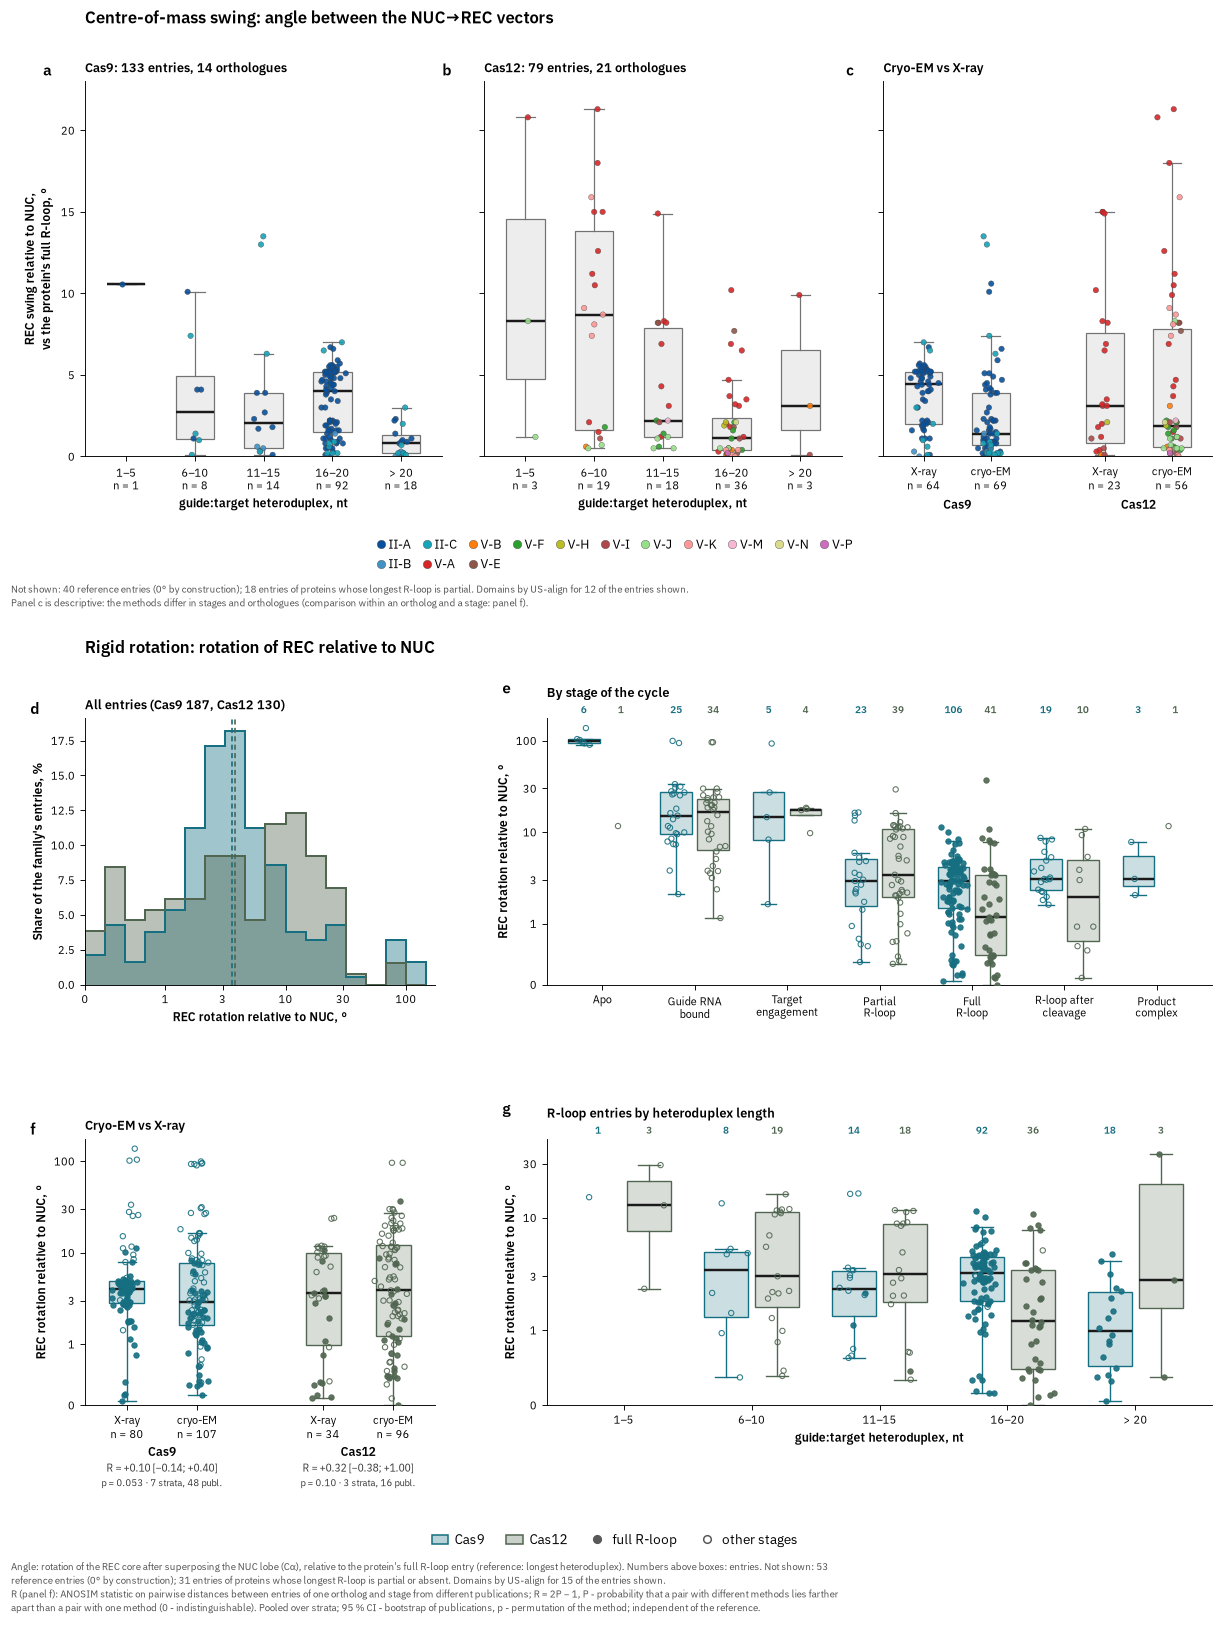

In [24]:
# Все стадии цикла: перенос разметки и референс те же, что для фигуры 10, но
# измеряются и записи без гетеродуплекса (Apo, Guide RNA bound, продукт).
RRG, RRGNOTE = rec_groups(ANNREC, T, all_stages=True)
RRA, _rr_notes = rec_measure(RRG, T)
RRANOTE = pd.DataFrame(RRGNOTE + _rr_notes)
assert len({g["orth"] for g in RRG}) == len(RRG), "два белка под одним именем ортолога"
# самопроверка: на записях, измеренных и для фигуры 10, референс и угол те же
_chk = RR.merge(RRA[["pdb", "референс", "угол_REC"]], on="pdb", suffixes=("", "_все"))
assert len(_chk) == len(RR), "запись фигуры 10 не измерена на всех стадиях"
assert (_chk.референс == _chk.референс_все).all(), "референс на всех стадиях другой"
assert (
    _chk.угол_REC - _chk.угол_REC_все
).abs().max() < 0.05, "угол на всех стадиях другой"

# Расстояния между записями одного белка и одной стадии - без референса.
RRPAIR = rec_pair_table(RRG, T)
# Медоид - запись полной R-петли в центре своей группы; углы к нему - проверка
# того, как выбор референса сдвигает значения.
RRMED, _to_med = rec_medoids(RRG, RRPAIR, RRA, T)
RRA["поворот_REC_медоид"] = RRA.pdb.map(
    lambda p: round(_to_med[p][0], 2) if p in _to_med else np.nan
)
RRA["угол_REC_медоид"] = RRA.pdb.map(
    lambda p: round(_to_med[p][1], 1) if p in _to_med else np.nan
)

# Сравнение методов при одном ортологе и одной стадии (rec_strata_test), обе меры,
# и устойчивость к записям с метками качества и к серии Pacesa et al. (2022).
_mm = set(T[T.doi.astype(str).str.contains("2022.09.026", regex=False)].pdb)
_tech = set(
    RRA[RRA.флаги.str.contains("покрытие лобы|REC неоднородна")].pdb
)  # метки качества
_sets = [
    ("все записи", ()),
    (
        f"без записей с покрытием лобы < {REC_FLAG_COVER:.0%} или RMSD ядра REC > {REC_FLAG_RMSD:g} Å "
        f"({len(_tech)})",
        _tech,
    ),
    (
        f"без серии с несовпадающей мишенью, Pacesa et al., 2022 ({len(_mm & set(RRA.pdb))})",
        _mm,
    ),
]
_parts = []
for _name, _drop in _sets:
    for _metric in ("поворот_REC", "угол_REC"):
        _s, _st = rec_strata_test(RRPAIR, _metric, drop=_drop)
        _parts += [
            _s.assign(набор=_name, уровень="итог"),
            _st.assign(набор=_name, уровень="страта"),
        ]
RRSTRAT = pd.concat(_parts, ignore_index=True)
RRSTRAT = RRSTRAT[
    [
        "набор",
        "fam",
        "метрика",
        "уровень",
        "ортолог",
        "стадия",
        "страт",
        "публикаций",
        "публикаций_Xray",
        "публикаций_cryoEM",
        "пар_между",
        "пар_внутри",
        "медиана_между",
        "медиана_внутри",
        "Δмед",
        "вес",
        "R",
        "R_ДИ_нижн",
        "R_ДИ_верхн",
        "p",
        "перестановок",
        "бутстрепов",
    ]
]
RRSUM = RRSTRAT[(RRSTRAT.набор == _sets[0][0]) & (RRSTRAT.уровень == "итог")]

# Как выбор референса меняет сравнение методов: записи полной R-петли, без референсов и
# медоидов групп; углы к референсу группы и к её медоиду (Манн–Уитни, описательно).
_f = RRA[
    (RRA.стадия == "Rloop_full")
    & (RRA.стадия_референса == "Rloop_full")
    & ~RRA.pdb.isin(set(RRA.референс) | set(RRMED.медоид))
    & RRA.поворот_REC_медоид.notna()
]
_rows = []
for _fam in ("Cas9", "Cas12"):
    for _col, _nm in (
        ("поворот_REC", "референс группы"),
        ("поворот_REC_медоид", "медоид группы"),
    ):
        _x = _f[(_f.fam == _fam) & (_f.метод == "X-ray")][_col]
        _e = _f[(_f.fam == _fam) & (_f.метод == "Cryo-EM")][_col]
        _rows.append(
            dict(
                fam=_fam,
                отсчёт_от=_nm,
                n_Xray=len(_x),
                n_cryoEM=len(_e),
                медиана_Xray=round(float(_x.median()), 1),
                медиана_cryoEM=round(float(_e.median()), 1),
                p=float(spstats.mannwhitneyu(_x, _e, alternative="two-sided").pvalue),
            )
        )
RRREF = pd.DataFrame(_rows)

# Пары записей одной публикации, решённые разными методами (один ортолог, одна стадия) -
# единственный парный дизайн в наборе. В rec_strata_test пары одной публикации не входят,
# поэтому их смотрят отдельно: расстояние между методами против расстояния между записями
# того же метода в той же публикации (описательно: пар мало, записи зависимы).
_same = RRPAIR[RRPAIR.публикация_a == RRPAIR.публикация_b].assign(
    пара=lambda d: np.where(d.метод_a != d.метод_b, "между методами", "внутри метода")
)
_samekey = ["fam", "ортолог", "стадия", "публикация_a"]
RRSAME = (
    _same.merge(
        _same[_same.пара == "между методами"][_samekey].drop_duplicates(), on=_samekey
    )
    .groupby(_samekey + ["пара"])
    .agg(
        пар=("a", "size"),
        медиана_поворот_REC=("поворот_REC", "median"),
        мин_поворот_REC=("поворот_REC", "min"),
        макс_поворот_REC=("поворот_REC", "max"),
        медиана_угол_REC=("угол_REC", "median"),
    )
    .round(2)
    .reset_index()
    .rename(columns={"публикация_a": "публикация"})
)

figRR = fig_rec_combined(RR, RRA, RRSUM)

RRAS = rec_rotation_all_shown(RRA)
print(
    "записей измерено:",
    len(RRA),
    "| ортологов:",
    RRA.ортолог.nunique(),
    "| пропущено:",
    len(RRANOTE),
    "| на панелях d–g:",
    len(RRAS),
    "| референсов групп:",
    int((RRA.pdb == RRA.референс).sum()),
)
print(
    "помечено меткой доверия:",
    int((RRA.флаги != "").sum()),
    "из",
    len(RRA),
    "| метки качества (покрытие, REC):",
    len(_tech),
    "- cryo-EM",
    int(RRA[RRA.pdb.isin(_tech)].метод.eq("Cryo-EM").sum()),
)
print("\nповорот REC по стадиям (к полной R-петле), медиана и квартили, °:")
print(
    RRAS.groupby(["fam", "стадия"], observed=True)
    .поворот_REC.describe(percentiles=[0.25, 0.5, 0.75])[
        ["count", "25%", "50%", "75%", "max"]
    ]
    .round(1)
    .to_string()
)
print("\nто же без записей с метками качества (покрытие лобы, неоднородная REC):")
print(
    RRAS[~RRAS.pdb.isin(_tech)]
    .groupby(["fam", "стадия"], observed=True)
    .поворот_REC.describe(percentiles=[0.25, 0.5, 0.75])[
        ["count", "25%", "50%", "75%", "max"]
    ]
    .round(1)
    .to_string()
)
_xs = pd.crosstab([RRAS.fam, RRAS.метод], RRAS.стадия)
print(
    "\nзаписи панелей d–g по методам и стадиям (число записей; доля полной R-петли в строке, %):"
)
print(
    _xs.assign(
        **{"полная R-петля, %": (100 * _xs.Rloop_full / _xs.sum(axis=1)).round(0)}
    ).to_string()
)
print(
    "\nсравнение методов при одном ортологе и одной стадии (R > 0 — между методами дальше, чем внутри метода):"
)
print(
    RRSTRAT[RRSTRAT.уровень == "итог"][
        [
            "набор",
            "fam",
            "метрика",
            "страт",
            "публикаций",
            "R",
            "R_ДИ_нижн",
            "R_ДИ_верхн",
            "p",
        ]
    ]
    .round(3)
    .to_string(index=False)
)
print("\nстраты (все записи; медианы расстояний между публикациями, °):")
print(
    RRSTRAT[(RRSTRAT.уровень == "страта") & (RRSTRAT.набор == _sets[0][0])][
        [
            "fam",
            "метрика",
            "ортолог",
            "стадия",
            "публикаций_Xray",
            "публикаций_cryoEM",
            "пар_между",
            "пар_внутри",
            "медиана_между",
            "медиана_внутри",
            "Δмед",
            "R",
            "вес",
        ]
    ]
    .round(2)
    .to_string(index=False)
)
print("\nмедоид и референс (записи полной R-петли, без референса и медоида):")
print(RRMED.to_string(index=False))
print(
    "\nполная R-петля: поворот REC у X-ray и cryo-EM при отсчёте от референса и от медоида (описательно):"
)
print(RRREF.round(4).to_string(index=False))
print(
    "\nзаписи одной публикации, решённые разными методами (один ортолог, одна стадия):"
)
print(RRSAME.to_string(index=False))


**Figure 10.** Position of the REC lobe relative to the NUC lobe, measured from the full R-loop of the same protein (the entry with the longest heteroduplex). The two blocks are two angles. Centres and the rigid fit use only Cα atoms modelled in both structures. REC is the recognition-lobe domains and NUC is every other annotated domain. This is review Figure 10.

**Centre-of-mass swing** (a–c). The angle between the vectors that join the centre of mass of the NUC Cα atoms to the centre of mass of the REC Cα atoms, after the NUC lobes are superimposed. Rotation of REC about that vector does not move the centres, so it is not in this angle. **(a)** Cas9, by heteroduplex length (1–5, 6–10, 11–15, 16–20, and more than 20 nt). **(b)** Cas12, on the same axis. **(c)** The same entries by experimental method. A point is an entry, colored by subtype. The reference against itself is 0° and is not shown, nor is a product complex of 0 nt, nor a protein whose longest R-loop is only partial.

**Rigid rotation** (d–g). The rotation angle of REC after the NUC lobes have been superimposed and REC has been fitted on its own. It includes the swing in (a–c) and any rotation of REC about the NUC–REC axis. **(d)** Distribution of the angle in each type. The axis is linear below 1° and logarithmic above. **(e)** By stage of the pathway. **(f)** By experimental method. The statistic under each pair compares the methods within an ortholog and a stage and does not use the group reference. **(g)** Entries that contain a heteroduplex, by the length intervals of (a). A filled point is a full R-loop and an open point is another stage. Group references, and proteins whose reference is not a full R-loop, are omitted.

Abbreviations: REC, recognition lobe; NUC, nuclease lobe.


ячейка: SpCas9 × Rloop_full | записей: 68 | X-ray: 48 | cryo-EM: 20 | референс группы: 8WUS | медоид: 9C9P
публикаций с обоими методами в ячейке: 0 (парного дизайна внутри статьи здесь нет)

баланс ячейки (что, кроме метода, различается):
метод                              Cryo-EM    X-ray
записей                               20.0    48.00
публикаций                            11.0    13.00
год депонирования, медиана          2023.0  2022.00
разрешение, медиана                    3.1     2.70
гетеродуплекс, нт, медиана            20.0    20.00
с модулятором, %                       0.0     0.00
несёт не каталитические замены, %      0.0    29.17
гетеродуплекс < 20 нт, %              45.0    20.83
HNH построен < 50 %, записей           5.0     1.00
серия Pacesa, %                        0.0    35.42
HNH в конструкте, %                  100.0   100.00

исходы: X-ray против cryo-EM (единица - публикация с методом; δ > 0 - у X-ray больше):
                                           сценар

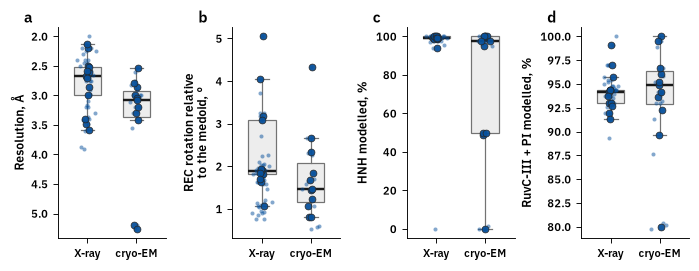

In [25]:
# b3. Контроль: один белок, одна стадия, два метода (SpCas9 x полная R-петля).
# Всё, что фиксирует контроль, названо здесь; дальше только счёт.
CTRL_ORTH, CTRL_STAGE = "SpCas9", "Rloop_full"
CTRL_MOBILE = [("HNH", 775, 908)]  # подвижный домен (ARCH["Cas9"])
CTRL_STATIC = [
    ("RuvC-III", 909, 1098),
    ("PI", 1099, 1368),
]  # жёсткое ядро: отрицательный контроль
CTRL_RES_CAP = 3.5  # общая область разрешений двух методов, Å
CTRL_NPERM, CTRL_NBOOT, CTRL_SEED = 20000, 5000, 20261003


def ctrl_built(pid, ranges, ref_seq, E):
    """Доля построенных остатков диапазонов референса Q99ZW2 у одной записи.

    Как в profile_family: SEQRES эффекторной сущности выравнивается на референс,
    остаток референса «в конструкте», если у него есть пара; «построен», если
    парный остаток есть в PDBe polymer_coverage. Знаменатель - остатки в
    конструкте; домен, которого в конструкте нет совсем, даёт NaN.
    -> {имя диапазона: (в конструкте, построено)}
    """
    hit = E[E.pdb == pid]
    if hit.empty:
        return None
    eid = int(hit.iloc[0].entity)
    seq = SEQS.get((pid, eid)) or SEQS.get((pid, str(eid)))
    if not seq:
        return None
    obs = observed_seqres(COV.get(pid), eid)
    pairs, _ident, _ = align_pairs(ref_seq, seq)
    out = {name: [0, 0] for name, _, _ in ranges}
    for i_ref, i_seq, _, _ in pairs:
        for name, a, b in ranges:
            if a <= i_ref <= b:
                out[name][0] += 1
                out[name][1] += int(i_seq in obs)
    return {k: tuple(v) for k, v in out.items()}


def ctrl_frame():
    """Одна строка на запись ячейки (SpCas9, полная R-петля) с исходами и метками."""
    P = T.drop_duplicates("pdb")
    P = P[(P.effector == CTRL_ORTH) & (P.stage == CTRL_STAGE)].copy()
    P["pub"] = P.apply(_rec_pub, axis=1)
    P["метод"] = P.method.map({"X-ray": "X-ray", "Cryo-EM": "Cryo-EM"})
    assert P.метод.notna().all(), "метод вне X-ray / Cryo-EM"
    P["модулятор"] = P.pdb.isin(mod)
    # «вариант» - у записи есть замена НЕ каталитическая (PAM-варианты, VQR/VRER, HF,
    # замены цистеинов под кристаллизацию). D10A/H840A вариантом не считаются:
    # на стадии полной R-петли это приём получить структуру (фигура 3), а не вариант белка.
    _noncat = set(GS[(GS.pdb.isin(set(P.pdb))) & ~GS.каталитическая.astype(bool)].pdb)
    P["вариант"] = P.pdb.isin(_noncat)
    P["серия_Pacesa"] = P.pdb.isin(_mm)
    ref_seq = refs["Cas9"]
    E = pick_effectors(ENT) if "kind" in ENT.columns else one_effector(ENT)
    rows = []
    for pid in P.pdb:
        r = ctrl_built(pid, CTRL_MOBILE + CTRL_STATIC, ref_seq, E)
        row = dict(pdb=pid)
        if r is None:
            row.update(
                HNH_в_конструкте=np.nan,
                HNH_построено=np.nan,
                ядро_в_конструкте=np.nan,
                ядро_построено=np.nan,
            )
        else:
            row.update(
                HNH_в_конструкте=r["HNH"][0],
                HNH_построено=r["HNH"][1],
                ядро_в_конструкте=sum(r[n][0] for n, _, _ in CTRL_STATIC),
                ядро_построено=sum(r[n][1] for n, _, _ in CTRL_STATIC),
            )
        rows.append(row)
    B = pd.DataFrame(rows)
    B["HNH_%"] = np.where(
        B.HNH_в_конструкте > 0,
        100 * B.HNH_построено / B.HNH_в_конструкте.replace(0, np.nan),
        np.nan,
    )
    B["ядро_%"] = np.where(
        B.ядро_в_конструкте > 0,
        100 * B.ядро_построено / B.ядро_в_конструкте.replace(0, np.nan),
        np.nan,
    )
    B["HNH_нет_%"] = np.where(B["HNH_%"].notna(), 100.0 * (B["HNH_%"] < 50), np.nan)
    P = P.merge(B, on="pdb", how="left")
    # положение REC: к референсу группы (8WUS, cryo-EM) и к медоиду полной петли (RRA)
    rr = RRA.set_index("pdb")
    ref_pdb = set(RRA.loc[RRA.ортолог == CTRL_ORTH, "референс"])
    med_pdb = set(RRMED.loc[RRMED.ортолог == CTRL_ORTH, "медоид"])
    P["поворот_к_референсу"] = P.pdb.map(rr.поворот_REC).where(~P.pdb.isin(ref_pdb))
    P["поворот_к_медоиду"] = P.pdb.map(rr.поворот_REC_медоид).where(
        ~P.pdb.isin(med_pdb | ref_pdb)
    )
    return P, ref_pdb, med_pdb


def ctrl_unit_test(d, col, n_perm=CTRL_NPERM, n_boot=CTRL_NBOOT, seed=CTRL_SEED):
    """X-ray против cryo-EM по одному исходу; единица - публикация с методом.

    Записи одной статьи - серия почти одной структуры, поэтому значение единицы -
    медиана её записей, а не сами записи (как в rec_strata_test). δ - дельта
    Клиффа единиц, δ = 2P - 1, где P - вероятность, что у случайной единицы X-ray
    значение больше, чем у случайной единицы cryo-EM (ничья - половина): δ > 0 -
    X-ray больше. Это та же шкала, что R на панели f. p - перестановка метода
    между единицами (двусторонний, учтено, что единицы одной статьи с двумя
    методами - две единицы); ДИ разности медиан - бутстреп единиц внутри метода.
    """
    u = (
        d.dropna(subset=[col])
        .groupby(["pub", "метод"])
        .agg(v=(col, "median"), записей=(col, "size"))
        .reset_index()
    )
    x = u[u.метод == "X-ray"].v.to_numpy(float)
    e = u[u.метод == "Cryo-EM"].v.to_numpy(float)
    res = dict(
        единиц_Xray=len(x),
        единиц_cryoEM=len(e),
        записей_Xray=int(u[u.метод == "X-ray"].записей.sum()),
        записей_cryoEM=int(u[u.метод == "Cryo-EM"].записей.sum()),
    )
    if len(x) < 2 or len(e) < 2:
        return res

    def cliff(a, b):
        g = (a[:, None] > b[None, :]).mean() + 0.5 * (a[:, None] == b[None, :]).mean()
        return 2 * g - 1

    v, lab = (
        np.concatenate([x, e]),
        np.r_[np.ones(len(x), bool), np.zeros(len(e), bool)],
    )
    obs = cliff(x, e)
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm)
    for k in range(n_perm):
        l = rng.permutation(lab)
        null[k] = cliff(v[l], v[~l])
    dm = np.empty(n_boot)
    for k in range(n_boot):
        dm[k] = np.median(rng.choice(x, len(x))) - np.median(rng.choice(e, len(e)))
    res.update(
        медиана_Xray=float(np.median(x)),
        медиана_cryoEM=float(np.median(e)),
        Δмед=float(np.median(x) - np.median(e)),
        Δмед_ДИ_нижн=float(np.percentile(dm, 2.5)),
        Δмед_ДИ_верхн=float(np.percentile(dm, 97.5)),
        δ=float(obs),
        p=float((1 + np.sum(np.abs(null) >= abs(obs) - 1e-12)) / (1 + n_perm)),
    )
    return res


CT, CTRL_REF, CTRL_MED = ctrl_frame()
CTRL_SCEN = [
    ("все записи ячейки", CT),
    ("без серии Pacesa 2022 (X-ray, несовпадающая мишень)", CT[~CT.серия_Pacesa]),
    ("только каталитические замены или дикий тип", CT[~CT.модулятор & ~CT.вариант]),
    (
        f"разрешение ≤ {CTRL_RES_CAP} Å (общая область методов)",
        CT[CT.res <= CTRL_RES_CAP],
    ),
]
CTRL_OUT = [
    ("res", "разрешение, Å"),
    ("поворот_к_референсу", "поворот REC к референсу, °"),
    ("поворот_к_медоиду", "поворот REC к медоиду, °"),
    ("HNH_%", "HNH построен, % остатков в конструкте"),
    ("HNH_нет_%", "HNH построен меньше чем на 50 %, % записей"),
    ("ядро_%", "RuvC-III + PI построены, % (отрицательный контроль)"),
]

rows = []
for sname, d in CTRL_SCEN:
    for col, oname in CTRL_OUT:
        r = ctrl_unit_test(d, col)
        if col == "HNH_нет_%" and "δ" in r:
            # у бинарного исхода медиана единиц - всегда 0; показываем доли записей,
            # ДИ разности медиан к нему неприменим
            for k, m in (("медиана_Xray", "X-ray"), ("медиана_cryoEM", "Cryo-EM")):
                r[k] = float(d[d.метод == m][col].mean())
            r.update(
                Δмед=r["медиана_Xray"] - r["медиана_cryoEM"],
                Δмед_ДИ_нижн=np.nan,
                Δмед_ДИ_верхн=np.nan,
            )
        rows.append(dict(сценарий=sname, исход=oname, **r))
CTRL = pd.DataFrame(rows)
CTRL = CTRL.rename(columns={"медиана_Xray": "X-ray", "медиана_cryoEM": "cryo-EM"})

# Положение REC без референса: расстояния между публикациями (RRPAIR), только пары ячейки.
_cp = RRPAIR[(RRPAIR.ортолог == CTRL_ORTH) & (RRPAIR.стадия == CTRL_STAGE)]
_cells = {"все записи ячейки": ()}
_cells["без серии Pacesa 2022 (X-ray, несовпадающая мишень)"] = tuple(
    CT[CT.серия_Pacesa].pdb
)
_cells["только каталитические замены или дикий тип"] = tuple(
    CT[CT.модулятор | CT.вариант].pdb
)
_cells[f"разрешение ≤ {CTRL_RES_CAP} Å (общая область методов)"] = tuple(
    CT[CT.res > CTRL_RES_CAP].pdb
)
rows = []
for sname, drop in _cells.items():
    for metric in ("поворот_REC", "угол_REC"):
        S, St = rec_strata_test(_cp, metric=metric, drop=drop, n_perm=5000, n_boot=2000)
        if S.empty:
            continue
        s, t = S.iloc[0], St.iloc[0]
        rows.append(
            dict(
                сценарий=sname,
                метрика=metric,
                публикаций_Xray=t.публикаций_Xray,
                публикаций_cryoEM=t.публикаций_cryoEM,
                пар_между=t.пар_между,
                пар_внутри=t.пар_внутри,
                медиана_между=t.медиана_между,
                медиана_внутри=t.медиана_внутри,
                Δмед=t.Δмед,
                R=s.R,
                R_ДИ_нижн=s.R_ДИ_нижн,
                R_ДИ_верхн=s.R_ДИ_верхн,
                p=s.p,
            )
        )
CTRLREC = pd.DataFrame(rows)

# Поправка Холма на множественность - внутри каждого сценария. Семейство - четыре
# проверки гипотезы «метод связан с тем, что читается из структуры»: разрешение,
# доля записей с HNH < 50 %, положение REC без референса по обеим мерам панелей d–g
# (поворот_REC, угол_REC). В семейство не входят: отрицательный контроль (его p
# должен быть большим), положение REC от референса и от медоида и непрерывная доля
# HNH - это те же исходы в другой мере, они описательны.
_FAM_CTRL = ("разрешение, Å", "HNH построен меньше чем на 50 %, % записей")
_fam = pd.concat(
    [
        CTRL[CTRL.исход.isin(_FAM_CTRL)][["сценарий", "исход", "p"]],
        CTRLREC[["сценарий", "метрика", "p"]].assign(
            исход=lambda d: "положение REC без референса: " + d.метрика
        )[["сценарий", "исход", "p"]],
    ],
    ignore_index=True,
).dropna(subset=["p"])
_fam["p_холм"] = _fam.groupby("сценарий").p.transform(
    lambda x: pd.Series(_holm(x.to_numpy()), index=x.index)
)
_fam["в_семействе"] = _fam.groupby("сценарий").p.transform("size")
CTRLFAM = _fam
CTRL = CTRL.merge(
    _fam[_fam.исход.isin(_FAM_CTRL)][["сценарий", "исход", "p_холм"]],
    on=["сценарий", "исход"],
    how="left",
)
CTRLREC = CTRLREC.merge(
    _fam[_fam.исход.str.startswith("положение REC")].assign(
        метрика=lambda d: d.исход.str.split(": ").str[1]
    )[["сценарий", "метрика", "p_холм"]],
    on=["сценарий", "метрика"],
    how="left",
)


# Баланс ячейки: чем два метода отличаются внутри неё помимо метода.
def _bal(g):
    return pd.Series(
        {
            "записей": len(g),
            "публикаций": g.pub.nunique(),
            "год депонирования, медиана": g.deposit_year.median(),
            "разрешение, медиана": g.res.median(),
            "гетеродуплекс, нт, медиана": g.mer.median(),
            "с модулятором, %": 100 * g.модулятор.mean(),
            "несёт не каталитические замены, %": 100 * g.вариант.mean(),
            "гетеродуплекс < 20 нт, %": 100 * (g.mer < 20).mean(),
            "HNH построен < 50 %, записей": int((g["HNH_%"] < 50).sum()),
            "серия Pacesa, %": 100 * g.серия_Pacesa.mean(),
            "HNH в конструкте, %": 100 * (g.HNH_в_конструкте > 0).mean(),
        }
    )


CTRLBAL = CT.groupby("метод").apply(_bal, include_groups=False).T.round(2)

# Утечка по одной публикации: самый слабый и самый сильный результат без одной публикации
rows = []
for col, oname in CTRL_OUT:
    ds, ps = [], []
    for pub in CT.pub.unique():
        r = ctrl_unit_test(CT[CT.pub != pub], col, n_perm=4000, n_boot=200)
        if "δ" in r:
            ds.append(r["δ"])
            ps.append(r["p"])
    rows.append(
        dict(
            исход=oname,
            публикаций_исключали=len(ds),
            δ_мин=min(ds),
            δ_макс=max(ds),
            p_макс=max(ps),
        )
    )
CTRLLOO = pd.DataFrame(rows)

print(
    "ячейка:",
    CTRL_ORTH,
    "×",
    CTRL_STAGE,
    "| записей:",
    len(CT),
    "| X-ray:",
    int((CT.метод == "X-ray").sum()),
    "| cryo-EM:",
    int((CT.метод == "Cryo-EM").sum()),
    "| референс группы:",
    ", ".join(sorted(CTRL_REF)),
    "| медоид:",
    ", ".join(sorted(CTRL_MED)),
)
_both = set(CT[CT.метод == "X-ray"].pub) & set(CT[CT.метод == "Cryo-EM"].pub)
print(
    "публикаций с обоими методами в ячейке:",
    len(_both),
    "(парного дизайна внутри статьи здесь нет)" if not _both else "",
)
print("\nбаланс ячейки (что, кроме метода, различается):")
print(CTRLBAL.to_string())
print(
    "\nисходы: X-ray против cryo-EM (единица - публикация с методом; δ > 0 - у X-ray больше):"
)
print(CTRL.round(3).to_string(index=False))
print(
    "\nположение REC без референса (расстояния между публикациями; R > 0 - между методами дальше, чем внутри):"
)
print(CTRLREC.round(3).to_string(index=False))
print("\nпоправка Холма на семейство из четырёх проверок (внутри сценария):")
print(CTRLFAM.round(3).to_string(index=False))
print("\nбез одной публикации (диапазон по всем вариантам исключения):")
print(CTRLLOO.round(3).to_string(index=False))


def fig_control(CT, path="cas_control_spcas9.png"):
    """Четыре исхода ячейки по методам, без подписей внутри фигуры: n, δ, p и
    расшифровка точек - в подписи к фигуре. Малая точка - запись, крупная -
    публикация (медиана её записей), ящик и черта - по публикациям. Стиль -
    как у фигуры 10 (серые ящики, цвет точки - подтип, открытая рамка)."""
    panels = [
        ("res", "Resolution, Å", True),
        ("поворот_к_медоиду", "REC rotation relative\nto the medoid, °", False),
        ("HNH_%", "HNH modelled, %", False),
        ("ядро_%", "RuvC-III + PI modelled, %", False),
    ]
    dot = subtype_color("II-A")
    rng = np.random.default_rng(1)
    fig, axes = plt.subplots(1, 4, figsize=(7.4, 2.5), gridspec_kw=dict(wspace=0.62))
    for ax, (c, lab, invert), letter in zip(axes, panels, "abcd"):
        for k, m in enumerate(("X-ray", "Cryo-EM")):
            d = CT[CT.метод == m].dropna(subset=[c])
            u = d.groupby("pub")[c].median().to_numpy(float)
            bp = ax.boxplot(
                [u],
                positions=[k],
                widths=0.56,
                whis=1.5,
                patch_artist=True,
                showfliers=False,
                manage_ticks=False,
            )
            bp["boxes"][0].set(facecolor="0.93", edgecolor="0.45", linewidth=0.8)
            for kk in ("whiskers", "caps"):
                for ln in bp[kk]:
                    ln.set(color="0.45", linewidth=0.8)
            bp["medians"][0].set(color="0.1", linewidth=1.6)
            ax.scatter(
                rng.normal(k, 0.08, len(d)),
                d[c],
                s=7,
                color=dot,
                alpha=0.5,
                linewidths=0,
                zorder=3,
            )
            ax.scatter(
                rng.normal(k, 0.035, len(u)),
                u,
                s=20,
                color=dot,
                edgecolors="0.15",
                linewidths=0.5,
                alpha=0.95,
                zorder=4,
            )
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["X-ray", "cryo-EM"], fontsize=7.2)
        ax.set_xlim(-0.6, 1.6)
        ax.set_ylabel(lab, fontsize=8, linespacing=1.15)
        ax.tick_params(axis="y", labelsize=7.2)
        if invert:  # разрешение: меньше значит лучше
            ax.invert_yaxis()
        set_frame(ax, "open")
        panel_letter(ax, letter, fontsize=10, dx=-0.46)
    finish_fig(fig)
    fig.savefig(path, bbox_inches="tight")
    return fig


figCT = fig_control(CT)
english_table(CTRL).to_csv("cas_control_spcas9.csv", index=False)
english_table(CTRLREC).to_csv("cas_control_spcas9_rec.csv", index=False)
english_table(CTRLBAL).to_csv("cas_control_spcas9_balance.csv")
english_table(CTRLLOO).to_csv("cas_control_spcas9_loo.csv", index=False)
english_table(
    CT.drop(
        columns=["title", "title_table", "commentary", "noteworthy"], errors="ignore"
    )
).to_csv("cas_control_spcas9_entries.csv", index=False)


**Figure S2.** SpCas9 at the full R-loop, X-ray against cryo-EM. The four panels are the four outcomes of that one cell. A small point is an entry and a large point is a publication, plotted at the median of its entries. The box and the median bar are computed on the publications. **(a)** Resolution, with the axis inverted. **(b)** REC rotation relative to the medoid of the cell. **(c)** Percentage of the HNH residues present in the construct that are modelled. **(d)** The same percentage for RuvC-III together with the PAM-interacting domain, the negative control. Sample sizes, the rank-biserial correlation and the *p*-values are in the accompanying table and are not printed on the drawing. The Holm correction is across the four pre-specified tests: resolution, HNH modelled below half of its residues, and REC position by rigid rotation and by the centre-of-mass angle. Panel (b) is descriptive and is outside that family, as is panel (d). This is review Figure S2.

Abbreviations: REC, recognition lobe; PAM, protospacer-adjacent motif.


записей с покрытием: 64 | пропущено: 0 | доменов в конструкте, но без координат: 30 | доменов, которых нет в конструкте: 0


,fam,ортолог,pdb,домен,длина,в_конструкте,доля_построен
28,Cas9,St3Cas9,8PJ9,REC2,129,129,0.0
32,Cas9,St3Cas9,8PJ9,HNH,165,165,0.0
63,Cas9,FrCas9,9JWK,L1,14,14,0.0
64,Cas9,FrCas9,9JWK,HNH,131,131,0.0
86,Cas9,SuperFiSpCas9,9K4C,L1,15,15,0.0
65,Cas9,FrCas9,9JWK,L2,19,19,0.0
112,Cas9,SpRYCas9,8T6O,L1,12,12,0.0
87,Cas9,SuperFiSpCas9,9K4C,HNH,126,126,0.0
113,Cas9,SpRYCas9,8T6O,HNH,129,129,0.0
114,Cas9,SpRYCas9,8T6O,L2,18,18,0.0


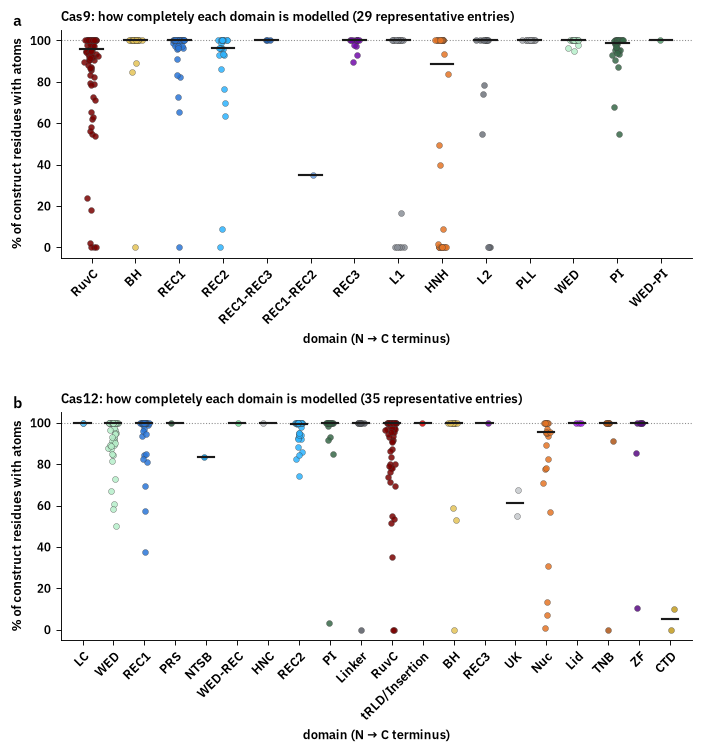

In [26]:
DC, DCNOTE = domain_coverage(RECS)
# один порядок доменов на фигурах 11, 12 и их вариантах — от N- к C-концу
NCORDER = domain_nc_order(ANNREC)
figDC = fig_domain_coverage(DC, order=NCORDER)

print(
    "записей с покрытием:",
    DC.pdb.nunique(),
    "| пропущено:",
    len(DCNOTE),
    "| доменов в конструкте, но без координат:",
    int((DC.доля_построен == 0).sum()),
    "| доменов, которых нет в конструкте:",
    int(DC.доля_построен.isna().sum()),
)
DC[DC.доля_построен.isna() | (DC.доля_построен < 50)].sort_values("доля_построен")[
    ["fam", "ортолог", "pdb", "домен", "длина", "в_конструкте", "доля_построен"]
]


вариант по записям: записей 398 | ортологов 65 | не вошло: 39 | нет годной строки листа разметки: 23; эффектор — другой белок под именем ортолога (< 80 %): 13; исключён решением автора (DOMAIN_EXCLUDE): 3


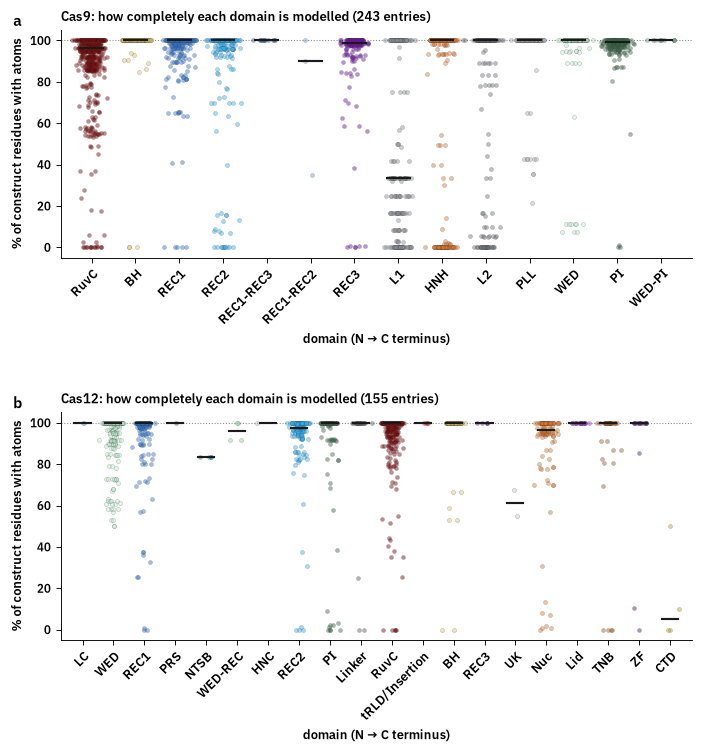

In [27]:
# Разметка представителя переносится выравниванием на каждую запись белка
# со строкой листа. Разметка по структуре сюда не входит: она задана только
# на построенных остатках, и доля построенного была бы 100% по построению.
DCE, DCENOTE = domain_coverage_entries(RECS, T)
figDCE = fig_domain_coverage(
    DCE,
    path="cas_domain_coverage_entries.png",
    order=NCORDER,
    unit="entries",
    s=7,
    alpha=0.45,
    jitter=0.14,
)
print(
    "вариант по записям: записей",
    DCE.pdb.nunique(),
    "| ортологов",
    DCE.ортолог.nunique(),
    "| не вошло:",
    len(DCENOTE),
    "|",
    reasons_summary(DCENOTE),
)


**Figure 11.** Fraction of each domain that is modelled. **(a)** Cas9. **(b)** Cas12. A point is one domain segment of one representative structure, after a nested domain has been subtracted. The vertical position is the percentage of residues of that segment that are present in the construct and have atoms in the coordinates. The bar is the median. Domains run from the N terminus to the C terminus. A segment that is absent from the construct is omitted from the drawing and kept in the table. The median of a bimodal domain can sit at 100% while a minority of representatives have no coordinates for it; that minority is in the table under the figure.

**Figure 11, every entry.** The same measurement after the representative's published boundaries are transferred, by sequence alignment, onto every entry of that protein. An effector less than 80% identical to the annotated protein is not used. A point is one segment of one entry. Boundaries obtained by structural transfer are not included: they exist only for residues that were modelled, so the modelled fraction would be 100% by construction.


вариант с US-align: ортологов 77 | из них по US-align: 12
RuvC: белков 74 | из них по US-align: 9
       count   mean   std    min    25%    50%    75%    max
fam                                                         
Cas12   44.0  190.0  48.0   47.0  164.0  187.0  222.0  311.0
Cas9    30.0  238.0  52.0  135.0  215.0  241.0  275.0  359.0
ортологов: 65 | семейств доменов: 27


ортологов  медиана_аа  мин  макс
fam   семейство_домена                                  
Cas12 tRLD/Insertion            1       266.0  266   266
      UK                        1       219.0  219   219
      REC1                     34       205.0   96   533
      RuvC                     35       189.0   47   311
      WED                      35       166.0   84   261
      REC2                     27       164.0   65   308
      HNC                       1       150.0  150   150
      Nuc                      20       141.0   37   273
      LC                        1       130.0  130   130
      PI                       17        94.0   46   153
      NTSB                      1        91.0   91    91
      PRS                       1        69.0   69    69
      REC3                      1        53.0   53    53
      ZF                        6        39.5   28    98
      TNB                       7        36.0   30   130
      BH                       15        31.0   16    78
      CTD                       2        30.5   29    32
      Lid                       3        21.0   19    42
      WED-REC                   1        12.0   12    12
      Linker                    8         9.0    5    11
Cas9  RuvC                     30       241.0  135   359
      REC3                     13       223.0   97   399
      REC2                     25       195.0   76   236
      REC1                     29       161.0   82   361
      PI                       30       160.0   92   305
      HNH                      30       129.0   81   214
      WED                      22       108.5   27   228
      BH                       30        35.5   15    48
      L1                       18        31.0   12    39
      REC1-REC2                 1        20.0   20    20
      L2                       18        18.0   12    23
      REC1-REC3                 3        15.0   10    44
      PLL                      12        14.0   13    22
      WED-PI                    1         9.0    9     9

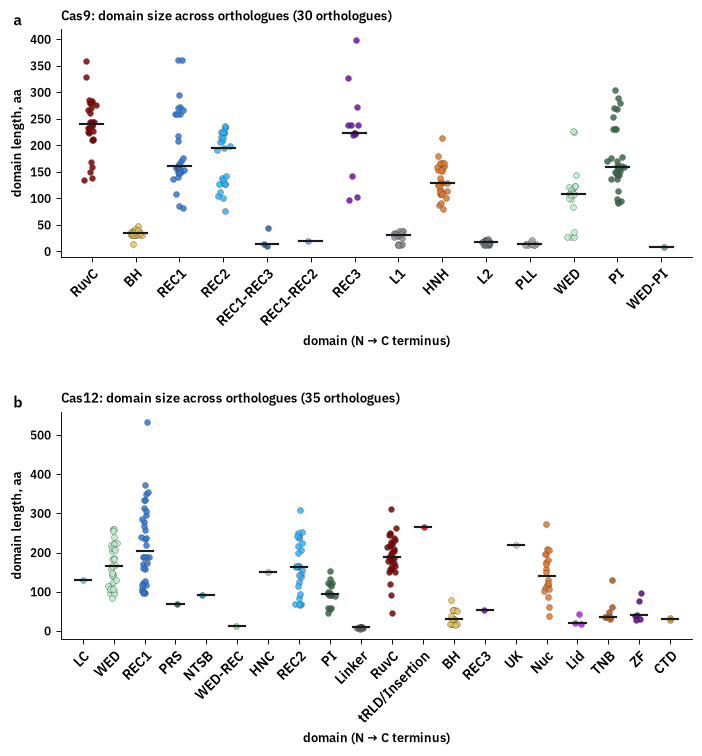

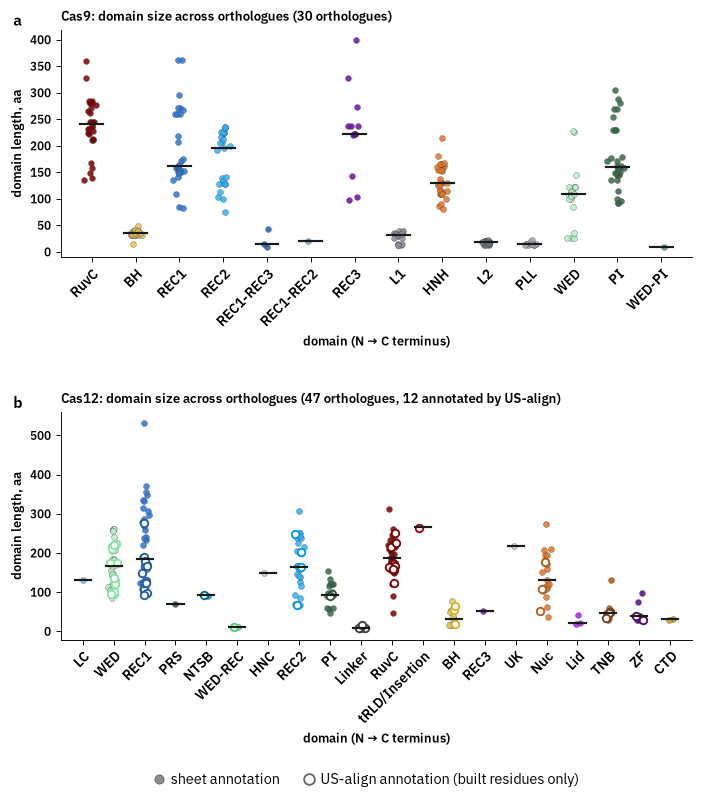

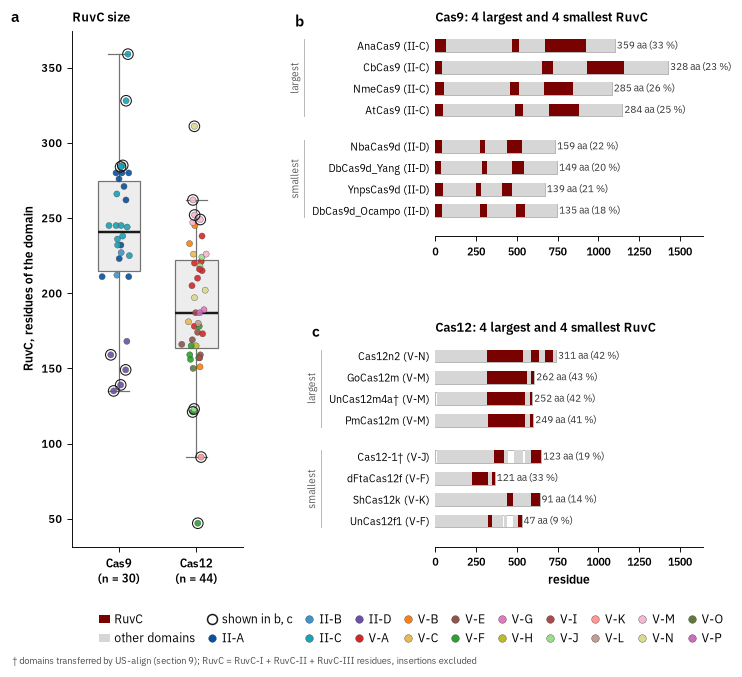

In [28]:
DSZ = domain_sizes(RECS)
figSZ = fig_domain_sizes(DSZ, order=NCORDER)
# Вариант с разметкой по структуре: к строкам листа добавлены белки без строки листа
# (SREC, US-align); их точки — пустые кружки. Размер по US-align — нижняя оценка:
# размечены только построенные остатки цели.
DSZS = domain_sizes(ANNREC)
figSZS = fig_domain_sizes(DSZS, path="cas_domain_sizes_structural.png", order=NCORDER)
print(
    "вариант с US-align: ортологов",
    DSZS.ортолог.nunique(),
    "| из них по US-align:",
    DSZS[DSZS.разметка == "US-align"].ортолог.nunique(),
)
# RuvC — по разметке записи (лист или US-align), только остатки самого домена
RV = ruvc_sizes(ANNREC)
figRS = fig_ruvc_size(RV)
print(
    "RuvC: белков",
    len(RV),
    "| из них по US-align:",
    int((RV.разметка == "US-align").sum()),
)
print(RV.groupby("fam").остатков_RuvC.describe().round(0).to_string())

print(
    "ортологов:",
    DSZ.ортолог.nunique(),
    "| семейств доменов:",
    DSZ.семейство_домена.nunique(),
)
DSZ.groupby(["fam", "семейство_домена"], observed=True).agg(
    ортологов=("ортолог", "nunique"),
    медиана_аа=("длина", "median"),
    мин=("длина", "min"),
    макс=("длина", "max"),
).sort_values(["fam", "медиана_аа"], ascending=[True, False])


**Figure 12.** Length of each domain family across orthologs with published boundaries. **(a)** Cas9. **(b)** Cas12. The length is the sum of the residues in the segments of that family. Residues of a domain nested inside another are not counted toward the outer domain. A point is one ortholog and the bar is the median. Families run from the N terminus to the C terminus. This is review Figure 9.

**Figure 12, with structural transfer.** The same drawing after the proteins that have no published boundaries are added. Filled points are published boundaries and open points are boundaries transferred by US-align. A transferred length is a lower estimate, because only residues modelled in the target are annotated. The median is taken over every point on the panel.

**Figure 13.** Size of RuvC. **(a)** Residue count of RuvC in Cas9 and in Cas12. RuvC is the sum of RuvC-I, RuvC-II and RuvC-III, without domains nested inside those segments and without the sequence that lies between them. A point is one protein, colored by subtype; the proteins drawn in (b) and (c) are outlined. **(b, c)** Linear maps of the four proteins with the largest RuvC and the four with the smallest RuvC in each type. RuvC is shown in the domain color, the other annotated domains in grey, and an empty stretch is unannotated. The numeral at the right is the number of RuvC residues and its fraction of the annotated protein. The review caption describes these rows as subtypes; each row is one protein. This is review Figure 14.


## 8. Structural comparison of annotations (US-align)


пар: 330 | целей: 59 | совпадение с лучшим по TM эталоном: медиана 91.7 %, 10-й перцентиль 64.8 %
по доменам: сравнений «домен эталона — цель» 1708 | в сводке: 1594 | исключено (домен того же имени у цели построен < DOM_MIN_BUILT %): 114 | из сводки: пар, где в разметке цели такого домена нет вовсе: 137


пар  TM_домена  то_же_имя_%  по_цепи_%
fam   домен                                                 
Cas12 BH                5     0.8730         36.0       51.0
      Nuc              43     0.8570         68.0       56.0
      PI               49     0.6980         69.0       55.0
      REC1             84     0.7810         66.0       40.0
      REC2             70     0.7410         57.0       25.0
      RuvC             77     0.8460         78.0       77.0
      WED              84     0.7625         80.0       77.0
      tRLD/Insertion    6     0.3405          0.0        0.0
Cas9  HNH              61     0.7380         80.0       25.0
      PI              246     0.6680         66.0       62.0
      REC1            218     0.7785         65.0       63.0
      REC2            195     0.7230         64.0       32.0
      REC3             76     0.7690         43.0       26.0
      RuvC            225     0.7470         75.0       69.0
      WED             146     0.6075         47.0       42.0

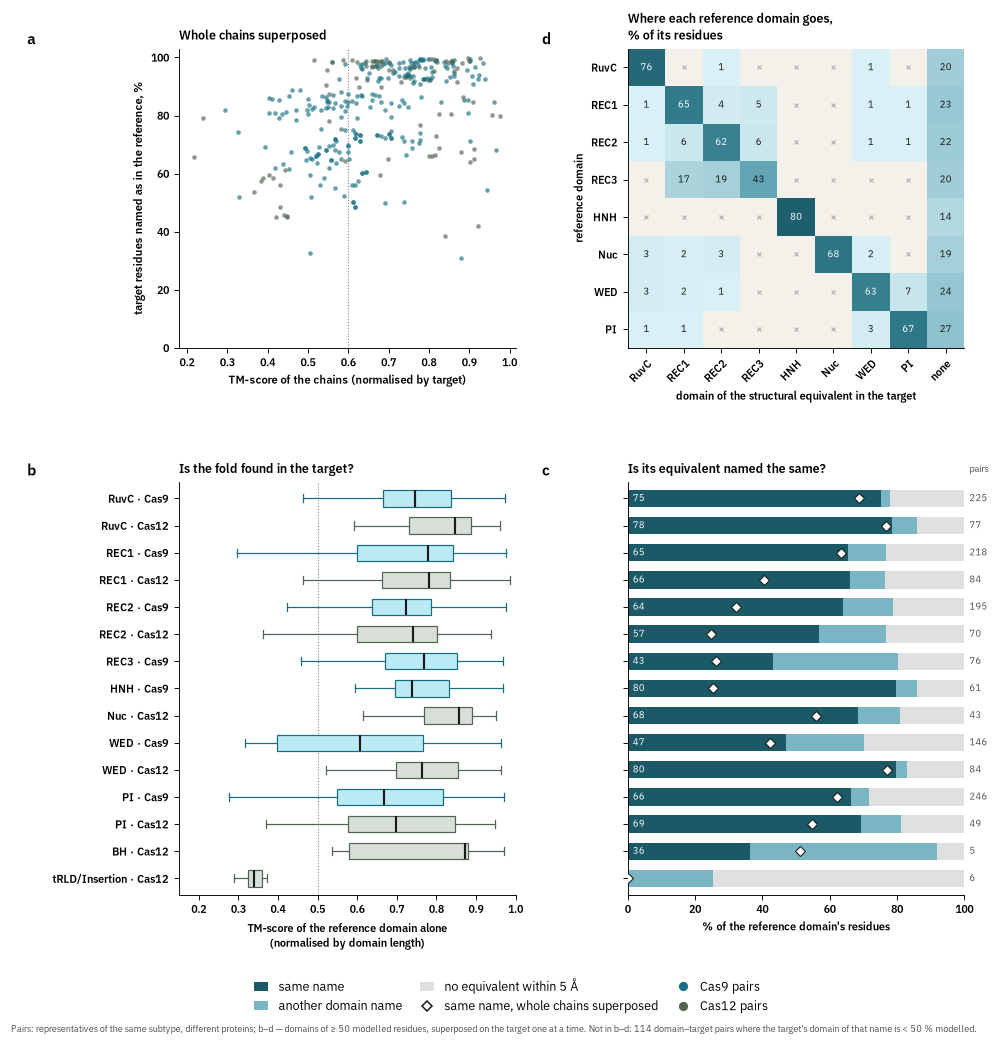

In [29]:
USC, USCONF = struct_concordance(RECS)
# каждый домен эталона совмещается с целью отдельно (раздел 18b)
DCN, DCONF = domain_concordance(RECS)
figSC = fig_struct_concordance(USC, DCN)

_best = USC.loc[USC.groupby("цель").TM.idxmax()]
print(
    "пар:",
    len(USC),
    "| целей:",
    USC.цель.nunique(),
    "| совпадение с лучшим по TM эталоном: медиана",
    _best.совпадение.median(),
    "%, 10-й перцентиль",
    round(_best.совпадение.quantile(0.1), 1),
    "%",
)
print(
    "по доменам: сравнений «домен эталона — цель»",
    len(DCN),
    "| в сводке:",
    int(DCN.в_сводке.sum()),
    "| исключено (домен того же имени у цели построен < DOM_MIN_BUILT %):",
    int((~DCN.в_сводке).sum()),
    "| из сводки: пар, где в разметке цели такого домена нет вовсе:",
    int(DCN.цель_построено.isna().sum()),
)
_D = DCN[DCN.в_сводке]
_dom = (
    _D.assign(same=_D.то_же_имя * _D.остатков, rigid=_D.то_же_имя_по_цепи * _D.остатков)
    .groupby(["fam", "домен"])
    .agg(
        пар=("TM_домена", "size"),
        TM_домена=("TM_домена", "median"),
        same=("same", "sum"),
        rigid=("rigid", "sum"),
        остатков=("остатков", "sum"),
    )
)
_dom["то_же_имя_%"] = (_dom.pop("same") / _dom.остатков).round(0)
_dom["по_цепи_%"] = (_dom.pop("rigid") / _dom.остатков).round(0)
_dom[_dom.пар >= 5].drop(columns="остатков")


**Figure 14.** Agreement of domain names between representatives of one subtype. Pairs are within a subtype and run in both directions. Two entries of the same protein are excluded. **(a)** Whole-chain superposition. The vertical axis is the fraction of the target's annotated, modelled residues that receive the same domain family as the reference residue they align to, and the horizontal axis is the TM-score normalized by the length of the target. The dashed line is the TM-score threshold used elsewhere for a transfer. **(b)** TM-score of each domain superimposed on its own, so a hinge motion between domains does not enter the comparison. The dashed line is 0.5. **(c)** After that domain superposition, the fraction of reference-domain residues whose equivalent is named the same way, named differently, or has no equivalent within 5 Å. The diamond is the fraction named the same way under a whole-chain superposition with the same distance cutoff. **(d)** Where the residues of the reference domain are placed in the target, as a percentage of the reference domain. Domains with fewer than 50 modelled residues are omitted, as is a comparison in which the target has a domain of the same name but less than half of it is modelled. This is review Figure 13.

Abbreviations: TM-score, template-modeling score.


белков с разметкой по структуре: 12 | записей за ними: 29 | без разметки: 5
  ортолог              pdb                                                  причина
  Cas12-2       8WRU, 8WRV      в подтипе unassigned нет размеченных представителей
   Cas12X 8ZQB, 8ZQH, 8ZQS      в подтипе unassigned нет размеченных представителей
  Cas12X2             8ZQC      в подтипе unassigned нет размеченных представителей
  Cas12e2             9IX6      в подтипе unassigned нет размеченных представителей
ScCas12a2 8D49, 8D4A, 8D4B исключён: доменной разметки по остаткам в литературе нет


,fam,subtype,name,ярлык,pdb,эталон,pdb_эталона,TM,записей
0,Cas12,V-A,Ba1Cas12a3-like,Ba1Cas12a3,21WE,Ba1Cas12a3,9HLX,0.934,2
1,Cas12,V-A,MbCas12a,MbCas12a,6IV6,AmCas12a,8KGF,0.883,1
2,Cas12,V-E,Cas12e,Cas12e,6NY2,dPlmCas12e,7WAY,0.950,3
3,Cas12,V-F,Al3Cas12f,Al3Cas12f,9NZR,AsCas12f,8J1J,0.797,2
4,Cas12,V-F,CnCas12f/Cas14a,CnCas12f/Cas14a,8HR5,AsCas12f,8J1J,0.755,1
5,Cas12,V-F,OsCas12f/Cas14a,OsCas12f/Cas14a,9NZT,AsCas12f,8J1J,0.936,3
6,Cas12,V-F,RhCas12f/Cas14a,RhCas12f/Cas14a,9NZP,dFtaCas12f,9N9Q,0.822,1
7,Cas12,V-J,Cas12-1,Cas12j/Cas12-1,8WRS,Cas12j3,7ODF,0.720,11
8,Cas12,V-J,Cas12-1-N1,Cas12-1-N1,8WRW,Cas12j,7LYT,0.895,1
9,Cas12,V-J,Cas12-1-N2,Cas12-1-N2,8WS5,Cas12j,7LYT,0.870,1


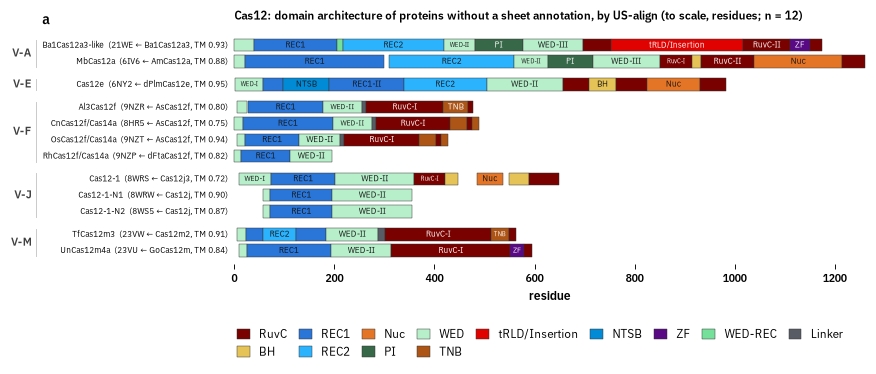

In [30]:
# SREC, SRECNOTE — разметка по структуре, посчитана в разделе 3
SRECTAB = struct_annotation_table(SREC)
if SREC:
    figSD = fig_domain_map(
        SREC,
        mode="scaled",
        path="cas_domain_map_structural.png",
        what="proteins without a sheet annotation, by US-align",
    )
print(
    "белков с разметкой по структуре:",
    len(SREC),
    "| записей за ними:",
    sum(len(r["записи"]) for r in SREC),
    "| без разметки:",
    len(SRECNOTE),
)
if len(SRECNOTE):
    print(SRECNOTE.to_string(index=False))
pd.DataFrame(
    [
        {
            k: r[k]
            for k in (
                "fam",
                "subtype",
                "name",
                "ярлык",
                "pdb",
                "эталон",
                "pdb_эталона",
                "TM",
            )
        }
        | {"записей": len(r["записи"])}
        for r in SREC
    ]
)


**Figure 15.** Domain boundaries transferred by US-align for the 12 proteins that do not have a usable published annotation of their own. Seven are sheet rows without published boundaries (MbCas12a, Al3Cas12f, CnCas12f, OsCas12f, RhCas12f, TfCas12m3 and UnCas12m4a). Five have no sheet row, or were deposited under a name that already belongs to a different protein (Cas12e, Cas12-1, Cas12-1-N1, Cas12-1-N2 and Ba1Cas12a3). ScCas12a2 is excluded: its nearest annotated Cas12a reference falls below a TM-score of 0.6. Each band is the modelled part of one chain. The label gives the entry, the reference the annotation was taken from, and the TM-score. The domain names are those of the reference. Segments shorter than three residues are dropped. This is the transfer half of review Figure 12.

Abbreviations: TM-score, template-modeling score.


представителей на карте: 77 | позиций, названных как у якоря (медиана по представителям): 80.8 %


так_же_как_у_якоря  позиций
fam   у_якоря                             
Cas12 BH                     27.1      715
      Nuc                    70.8     2561
      PI                     92.3      861
      REC1                   90.1     6974
      REC2                   85.6     2000
      RuvC                   85.8     6299
      WED                    95.2     6011
Cas9  BH                     96.7      911
      HNH                    85.7      912
      PI                     99.8     4124
      REC1                   95.4     4242
      REC2                   75.3      918
      REC3                   42.8     5249
      RuvC                   96.9     5432
      WED                    70.0      740

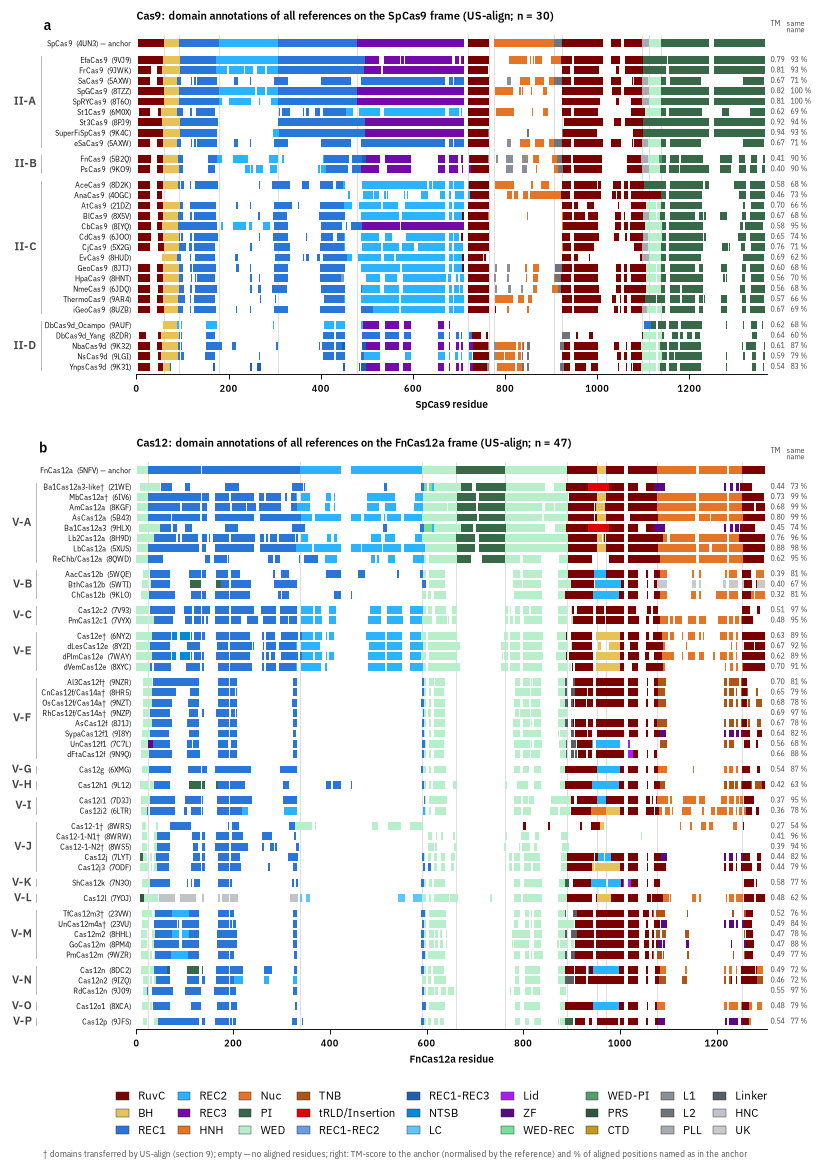

In [31]:
AL = aligned_annotations(ANNREC)
ALRUNS = aligned_runs(AL)
figAL = fig_domain_map_aligned(AL)

_al = AL.dropna(subset=["у_якоря"]).assign(то_же=lambda d: d.семейство == d.у_якоря)
print(
    "представителей на карте:",
    AL.белок.nunique(),
    "| позиций, названных как у якоря (медиана по представителям):",
    round(100 * _al.groupby("белок").то_же.mean().median(), 1),
    "%",
)
# по домену якоря: какая доля представителей называет его участок так же
(
    _al.groupby(["fam", "у_якоря"])
    .то_же.agg(["mean", "size"])
    .rename(columns={"mean": "так_же_как_у_якоря", "size": "позиций"})
    .assign(так_же_как_у_якоря=lambda d: (100 * d.так_же_как_у_якоря).round(1))
    .query("позиций >= 500")
)


**Figure 16.** Every annotation projected onto one anchor per type. The anchor is SpCas9 (PDB 4UN3) for Cas9 and FnCas12a (PDB 5NFV) for Cas12. A row is one representative, grouped by subtype. The first row of a type is the anchor, and the vertical lines are the boundaries of its domains. Color is the domain family in that representative's own annotation, placed on the anchor residue it aligns to. An empty stretch of the anchor has no aligned residue of that representative. At the right are the TM-score of the superposition, normalized by the length of the representative, and the fraction of aligned positions that carry the same domain family as the anchor. A dagger marks an annotation obtained by structural transfer. A column of one color is one name for a structurally equivalent stretch; a change of color down a column is a disagreement between nomenclatures. Below a TM-score of about 0.5 the alignment is mostly the nuclease core, and the comparison of names is about that core. This is the projection half of review Figure 12.

Abbreviations: TM-score, template-modeling score.


In [32]:
def _delta(df, fig):
    u = df.dropna(subset=["семейство_домена"]) if "семейство_домена" in df else df
    us = u[u.разметка == "US-align"]
    return dict(
        фигура=fig,
        записей=u.pdb.nunique(),
        из_них_US_align=us.pdb.nunique(),
        белков_US_align=(
            us.белок_разметки.nunique()
            if "белок_разметки" in us
            else us.ортолог.nunique()
        ),
        белки=", ".join(
            sorted(set(us.белок_разметки if "белок_разметки" in us else us.ортолог))
        ),
    )


US_DELTA = pd.DataFrame(
    [
        _delta(PC, "4b"),
        _delta(GS, "5"),
        _delta(IFS, "7"),
        _delta(RR, "10"),
        _delta(RV, "13"),
    ]
)
with pd.option_context("display.max_colwidth", None):
    print(US_DELTA.to_string(index=False))
US_DELTA


фигура  записей  из_них_US_align  белков_US_align                                                                                                          белки
    4b       52                0                0                                                                                                               
     5      196                3                1                                                                                                         Cas12e
     7       57                8                8                     Al3Cas12f, Cas12-1, Cas12-1-N1, Cas12-1-N2, Cas12e, RhCas12f/Cas14a, TfCas12m3, UnCas12m4a
    10      266               18                4                                                                    Al3Cas12f, Cas12-1, Cas12e, OsCas12f/Cas14a
    13       73                9                9 Al3Cas12f, Ba1Cas12a3-like, Cas12-1, Cas12e, CnCas12f/Cas14a, MbCas12a, OsCas12f/Cas14a, TfCas12m3, UnCas12m4a


,фигура,записей,из_них_US_align,белков_US_align,белки
0,4b,52,0,0,
1,5,196,3,1,Cas12e
2,7,57,8,8,"Al3Cas12f, Cas12-1, Cas12-1-N1, Cas12-1-N2, Ca..."
3,10,266,18,4,"Al3Cas12f, Cas12-1, Cas12e, OsCas12f/Cas14a"
4,13,73,9,9,"Al3Cas12f, Ba1Cas12a3-like, Cas12-1, Cas12e, C..."


## 9. Tables and the publication folder

Tables are written in English beside the notebook. The last code cell deletes `publication/` and copies in the numbered figures, the tables that belong to them, `figure_legends.md` and `article_number_check.csv`.


In [33]:
IFACE_META = MET.merge(
    REP[["pdb", "fam", "effector", "stage", "модулятор", "инженерный"]],
    on="pdb",
    how="left",
).assign(
    подтип=lambda d: d.pdb.map(T.drop_duplicates("pdb").set_index("pdb").subtype),
    в_фигуре=lambda d: d.pdb.isin(set(IFS.pdb)),
)

TABLES = {
    "cas_resolution_by_subtype.csv": gres,
    "cas_resolution_omitted_subtypes.csv": omitR,
    "cas_stage_matrix.csv": piv.astype(int),
    "cas_stage_subtypes.csv": pivs.astype(int),
    "cas_rloop_entries.csv": rloop_tab,
    "cas_catalytic_sites.csv": CAT,
    "cas_catalytic_sites_by_protein.csv": CATWIDE,
    "cas_catalytic_sites_by_subtype.csv": CATSUB,
    "cas_catalytic_entries.csv": CATENT,
    "cas_catalytic_audit.csv": CATAUD,
    "cas_subgroups.csv": SGT,
    "cas_subgroups_by_subtype.csv": pivg.astype(int),
    "cas_subgroup_contacts.csv": PCMAP,
    "cas_mut_domains.csv": DFS,
    "cas_mut_domains_substitutions.csv": PUB,
    "cas_mut_domains_sheet.csv": GS,
    "cas_domain_validation.csv": DV,
    "cas_coverage.csv": pd.concat(profiles.values(), ignore_index=True),
    "cas_coverage_domains.csv": DS,
    "cas_coverage_gaps.csv": GAPS,
    "cas_iface_map_partner.csv": IMAP,
    "cas_iface_map_moiety.csv": IMAPM,
    "cas_iface_meta.csv": IFACE_META,
    "cas_entries.csv": T,
    "cas_substitutions.csv": SUBS,
    "cas_substitution_audit.csv": SUBAUD,
    "cas_protein_groups.csv": pd.Series(GROUPS, name="белок").rename_axis("ярлык"),
    "cas_domain_map.csv": DSZ,
    "cas_domain_map_skipped.csv": SKIPPED,
    "cas_rloop_coverage.csv": RC,
    "cas_rec_rotation.csv": RR,
    "cas_rec_rotation_methods.csv": RRTAB,
    "cas_rec_rotation_all.csv": RRA,
    "cas_rec_rotation_strata.csv": RRSTRAT,
    "cas_rec_rotation_pairs.csv": RRPAIR,
    "cas_rec_rotation_medoids.csv": RRMED,
    "cas_rec_rotation_reference.csv": RRREF,
    "cas_rec_rotation_same_publication.csv": RRSAME,
    "cas_domain_coverage.csv": DC,
    "cas_domain_coverage_entries.csv": DCE,
    "cas_domain_sizes_structural.csv": DSZS,
    "cas_struct_concordance.csv": USC,
    "cas_struct_confusion.csv": USCONF,
    "cas_domain_concordance.csv": DCN.assign(
        куда=DCN.куда.map(
            lambda d: "; ".join(
                f"{k}: {v}" for k, v in sorted(d.items(), key=lambda x: -x[1])
            )
        )
    ),
    "cas_ruvc_size.csv": RV.assign(
        отрезки_RuvC=RV.отрезки_RuvC.map(lambda x: ", ".join(f"{a}-{b}" for a, b in x))
    ).drop(columns="прочие_отрезки"),
    "cas_domain_map_structural.csv": SRECTAB,
    "cas_domain_map_aligned.csv": ALRUNS,
    "cas_us_align_delta.csv": US_DELTA,
}
INDEXED = {
    "cas_stage_matrix.csv",
    "cas_stage_subtypes.csv",
    "cas_subgroups_by_subtype.csv",
    "cas_subgroup_contacts.csv",
    "cas_iface_map_partner.csv",
    "cas_iface_map_moiety.csv",
    "cas_protein_groups.csv",
    "cas_struct_confusion.csv",
}
for name, obj in TABLES.items():
    english_table(obj).to_csv(name, index=name in INDEXED, encoding="utf-8-sig")

# Контакты интерфейсов — рядом, чтобы раздел 5 можно было пересчитать без
# повторного разбора координат.
os.makedirs("handoff", exist_ok=True)
english_table(IFC).to_csv(
    "handoff/iface_contacts.csv", index=False, encoding="utf-8-sig"
)
english_table(MET).to_csv("handoff/iface_meta.csv", index=False, encoding="utf-8-sig")
print(
    "таблиц сохранено:",
    len(TABLES),
    "| строк всего:",
    sum(len(o) for o in TABLES.values()),
)


таблиц сохранено: 48 | строк всего: 25646


`cas_figure_filters.csv` records, for each figure, how many entries were drawn and why the others were left out.


In [34]:
_P = T.drop_duplicates("pdb")
_Pc = (T[T.cleavage_cycle] if "cleavage_cycle" in T.columns else T).drop_duplicates(
    "pdb"
)
_sg = SGT[SGT.в_наборе & SGT.с_эффектором]
_pc = PC.dropna(subset=["семейство_домена"])
_if = IFS.dropna(subset=["семейство_домена"])
_rl = _Pc[_Pc.mer > 0]
_rl3 = _rl[~_rl.subtype.isin(SUBTYPE_MISSING)]
_rr = rec_rotation_shown(RR)
_rr_ref = RR.pdb == RR.референс  # референсы групп (0° по построению)
_rr_part = ~_rr_ref & (
    RR.стадия_референса != "Rloop_full"
)  # прочие записи групп с частичной петлёй у референса
_rr_zero = ~_rr_ref & ~_rr_part & (RR.mer == 0)  # гетеродуплекс 0 нт
assert len(RR) - int(_rr_ref.sum() + _rr_part.sum() + _rr_zero.sum()) == len(
    _rr
), "причины исключения пересекаются"
_ra = rec_rotation_all_shown(RRA)
_ra_ref = RRA.pdb == RRA.референс  # референсы групп (0° по построению)
_ra_part = ~_ra_ref & (
    RRA.стадия_референса != "Rloop_full"
)  # референс группы - не полная R-петля
assert len(RRA) - int(_ra_ref.sum() + _ra_part.sum()) == len(
    _ra
), "причины исключения пересекаются"
_skip6 = [p for v in skipped.values() for p, _why in v]


def _us(df):
    """записей с разметкой US-align (раздел 18) в таблице разреза"""
    u = df.dropna(subset=["семейство_домена"]) if "семейство_домена" in df else df
    return int(u[u.разметка == "US-align"].pdb.nunique()) if "разметка" in u else 0


def _row(fig, files, unit, d, orth, sub, excluded, note=""):
    return dict(
        фигура=fig,
        файлы=files,
        единица=unit,
        вошло=int(d),
        ортологов=None if orth is None else int(orth),
        подтипов=None if sub is None else int(sub),
        исключено=excluded,
        примечание=note,
    )


_ns3 = rloop_tab.groupby(["fam", "subtype"]).catalytic_stall.any()
_om3 = ", ".join(s for (f, s), v in _ns3.items() if not v)
FIGLOG = pd.DataFrame(
    [
        _row(
            "1",
            "cas_resolution.png",
            "записи PDB",
            _P.res.notna().sum(),
            _P[_P.res.notna()].effector.nunique(),
            _P[_P.res.notna()].subtype.nunique(),
            f"без разрешения в PDB API: {int(_P.res.isna().sum())}; "
            f"панель c — подтипы с одной структурой: {len(omitR)}",
        ),
        _row(
            "1 (stats)",
            "cas_resolution_stats.png",
            "записи PDB",
            _P.res.notna().sum(),
            _P[_P.res.notna()].effector.nunique(),
            _P[_P.res.notna()].subtype.nunique(),
            "тот же набор, что на фигуре 1; статистика — в cas_resolution_stats.csv",
        ),
        _row(
            "2",
            "cas_stages.png",
            "записи PDB",
            _Pc.pdb.nunique(),
            _Pc.effector.nunique(),
            _Pc.subtype.nunique(),
            f"вне цикла расщепления: {_P.pdb.nunique() - _Pc.pdb.nunique()}; "
            f"без распознанной стадии: {int(_Pc.stage.isna().sum())}",
        ),
        _row(
            "3",
            "cas_rloop.png",
            "записи PDB",
            len(rloop_tab),
            rloop_tab.effector.nunique(),
            rloop_tab.subtype.nunique(),
            f"без длины гетеродуплекса: {int(_Pc.mer.isna().sum())}; "
            f"гетеродуплекс 0 нт: {int((_Pc.mer == 0).sum())}; без подтипа: {len(_rl) - len(_rl3)}",
            f"с каталитической остановкой: {int(rloop_tab.catalytic_stall.sum())}; подтипы без остановки "
            f"(не нарисованы): {_om3}",
        ),
        _row(
            "4a",
            "cas_subgroups.png",
            "записи PDB",
            _sg.pdb.nunique(),
            _sg.эффектор.nunique(),
            _sg.подтип.nunique(),
            "записи без белкового партнёра в фигуру не входят",
        ),
        _row(
            "4b",
            "cas_subgroups.png",
            "записи PDB",
            _pc.pdb.nunique(),
            _pc.ортолог.nunique(),
            _pc.подтип.nunique(),
            reasons_summary(PCNOTE),
            f"контактов на остатках вне доменов: {100 * PC.семейство_домена.isna().mean():.1f} %; "
            f"записей с разметкой US-align: {_us(PC)}",
        ),
        _row(
            "5",
            "cas_mut_domains.png",
            "записи PDB",
            GS.pdb.nunique(),
            GS.белок.nunique(),
            GS.подтип.nunique(),
            "замен: " + reasons_summary(GSNOTE, key=None),
            f"замен с доменом: {int(GS.семейство_домена.notna().sum())} из {len(G)}; уникальных: "
            f"{GS[['белок', 'wt', 'позиция', 'mut']].drop_duplicates().shape[0]}; "
            f"записей с разметкой US-align: {_us(GS)}",
        ),
        _row(
            "6",
            "cas_coverage.png",
            "записи PDB",
            sum(int(profiles[f].n_записей.iloc[0]) for f in profiles),
            len(profiles),
            None,
            f"нет эффекторной сущности или SEQRES: {len(_skip6)}",
        ),
        _row(
            "7",
            "cas_iface.png, cas_iface_moiety.png",
            "записи PDB",
            _if.pdb.nunique(),
            _if.ортолог.nunique(),
            _if.подтип.nunique(),
            f"кандидатов-представителей: {len(REP)}; профиль не собран: {len(REP) - len(MET)}; "
            f"без целевой цепи ДНК: {int((~MET.целевая_цепь_найдена).sum())}; по листу — "
            + reasons_summary(IFSNOTE),
            f"записей с разметкой US-align: {_us(IFS)}",
        ),
        _row(
            "8",
            "cas_domain_map_scaled.png, cas_domain_map_equal.png",
            "строки листа",
            len(RECS),
            len({r["name"] for r in RECS}),
            len({r["subtype"] for r in RECS}),
            reasons_summary(SKIPPED, key="ортолог"),
            f"замечаний сверки представителей: {len(REPNOTE)}",
        ),
        _row(
            "9",
            "cas_rloop_coverage.png",
            "записи PDB",
            int((_P.mer > 0).sum()),
            _P[_P.mer > 0].effector.nunique(),
            _P[_P.mer > 0].subtype.nunique(),
            f"без длины гетеродуплекса: {int(_P.mer.isna().sum())}; "
            f"гетеродуплекс 0 нт: {int((_P.mer == 0).sum())}",
        ),
        _row(
            "10",
            "cas_rec_rotation.png",
            "записи PDB",
            len(_rr),
            _rr.ортолог.nunique(),
            _rr.подтип.nunique(),
            reasons_summary(RRNOTE) + f"; на фигуре не показаны: референсы "
            f"групп (0°) — {int(_rr_ref.sum())}, остальные записи групп с частичной петлёй у "
            f"референса — {int(_rr_part.sum())}, гетеродуплекс 0 нт — {int(_rr_zero.sum())} "
            "(причины не пересекаются)",
            f"измерено всего: {len(RR)}; на фигуре с разметкой US-align: {_us(_rr)}",
        ),
        _row(
            "10, panels d–g",
            "cas_rec_rotation.png",
            "записи PDB",
            len(_ra),
            _ra.ортолог.nunique(),
            _ra.подтип.nunique(),
            reasons_summary(RRANOTE) + f"; на фигуре не показаны: референсы "
            f"групп (0°) — {int(_ra_ref.sum())}, остальные записи групп, где референс не полная "
            f"R-петля — {int(_ra_part.sum())} (причины не пересекаются)",
            f"измерено всего: {len(RRA)}; с метками доверия: {int((RRA.флаги != '').sum())}; "
            f"на фигуре с разметкой US-align: {_us(_ra)}",
        ),
        _row(
            "11",
            "cas_domain_coverage.png",
            "записи PDB",
            DC.pdb.nunique(),
            DC.ортолог.nunique(),
            DC.подтип.nunique(),
            reasons_summary(DCNOTE),
            f"сегментов вне конструкта (не на фигуре): {int(DC.доля_построен.isna().sum())}",
        ),
        _row(
            "11 (entries)",
            "cas_domain_coverage_entries.png",
            "записи PDB",
            DCE.pdb.nunique(),
            DCE.ортолог.nunique(),
            DCE.подтип.nunique(),
            reasons_summary(DCENOTE),
            "строки листа: разметка представителя перенесена на записи белка; US-align не входит",
        ),
        _row(
            "12",
            "cas_domain_sizes.png",
            "строки листа",
            DSZ.ортолог.nunique(),
            DSZ.ортолог.nunique(),
            DSZ.подтип.nunique(),
            "строки листа без границ — как на фигуре 8",
        ),
        _row(
            "12 (US-align)",
            "cas_domain_sizes_structural.png",
            "строки листа и белки US-align",
            DSZS.ортолог.nunique(),
            DSZS.ортолог.nunique(),
            DSZS.подтип.nunique(),
            "как на фигуре 12",
            f"белков с разметкой US-align: {DSZS[DSZS.разметка == 'US-align'].ортолог.nunique()}",
        ),
        _row(
            "13",
            "cas_ruvc_size.png",
            "белки",
            len(RV),
            RV.ортолог.nunique(),
            RV.подтип.nunique(),
            f"разметок без RuvC или с несверенным представителем: {len(ANNREC) - len(RV)}",
            f"с разметкой US-align: {int((RV.разметка == 'US-align').sum())}; "
            f"на картах b, c — по {RUVC_EXTREMES} крайних в семействе",
        ),
        _row(
            "14",
            "cas_struct_concordance.png",
            "пары представителей",
            len(USC),
            USC.цель.nunique(),
            USC.подтип.nunique(),
            "пары одного белка (идентичность ≥ 80 %) и подтипы с одним представителем; "
            f"b–d — домены короче {DOM_MIN_RES} построенных остатков и {int((~DCN.в_сводке).sum())} "
            f"сравнений, где домен того же имени у цели построен < {DOM_MIN_BUILT:.0f} %",
            f"сравнений «домен эталона — цель» в b–d: {int(DCN.в_сводке.sum())}, из них без домена того "
            f"же имени в разметке цели: {int(DCN.цель_построено.isna().sum())}",
        ),
        _row(
            "15",
            "cas_domain_map_structural.png",
            "белки",
            len(SREC),
            len({r["ярлык"] for r in SREC}),
            len({r["subtype"] for r in SREC}),
            reasons_summary(SRECNOTE),
            f"записей за белками: {sum(len(r['записи']) for r in SREC)}",
        ),
        _row(
            "16",
            "cas_domain_map_aligned.png",
            "представители",
            AL.белок.nunique(),
            AL.белок.nunique(),
            AL.подтип.nunique(),
            "—",
            f"якоря: {', '.join(ALIGN_ANCHOR.values())}",
        ),
    ]
)
FIGLOG[["ортологов", "подтипов"]] = FIGLOG[["ортологов", "подтипов"]].astype("Int64")
english_table(FIGLOG).to_csv("cas_figure_filters.csv", index=False)
# длинные перечни причин не обрезаются: таблица — для подписей к фигурам
pd.set_option("display.max_colwidth", None)
FIGLOG


,фигура,файлы,единица,вошло,ортологов,подтипов,исключено,примечание
0,1,cas_resolution.png,записи PDB,437,80,20,без разрешения в PDB API: 0; панель c — подтипы с одной структурой: 1,
1,1 (stats),cas_resolution_stats.png,записи PDB,437,80,20,"тот же набор, что на фигуре 1; статистика — в cas_resolution_stats.csv",
2,2,cas_stages.png,записи PDB,437,80,20,вне цикла расщепления: 0; без распознанной стадии: 0,
3,3,cas_rloop.png,записи PDB,298,70,19,без длины гетеродуплекса: 134; гетеродуплекс 0 нт: 2; без подтипа: 3,"с каталитической остановкой: 126; подтипы без остановки (не нарисованы): V-G, V-J, V-K, V-M, V-N, V-O, V-P"
4,4a,cas_subgroups.png,записи PDB,57,12,6,записи без белкового партнёра в фигуру не входят,
5,4b,cas_subgroups.png,записи PDB,52,12,6,нет контактов ближе 4 Å: 5,контактов на остатках вне доменов: 4.3 %; записей с разметкой US-align: 0
6,5,cas_mut_domains.png,записи PDB,196,30,14,"замен: ни дикий остаток, ни мутант не на позиции референса и по авторскому номеру: 1",замен с доменом: 722 из 723; уникальных: 141; записей с разметкой US-align: 3
7,6,cas_coverage.png,записи PDB,128,2,<NA>,нет эффекторной сущности или SEQRES: 0,
8,7,"cas_iface.png, cas_iface_moiety.png",записи PDB,57,57,17,кандидатов-представителей: 61; профиль не собран: 0; без целевой цепи ДНК: 1; по листу — нет годной строки листа разметки: 3,записей с разметкой US-align: 8
9,8,"cas_domain_map_scaled.png, cas_domain_map_equal.png",строки листа,65,65,19,нет доменов: 6; нет разметки в статье: 2,замечаний сверки представителей: 5


## Check against the review

Each numerical claim in the review is recomputed from the tables in this directory. `match` agrees exactly, `rounding` is within half a unit of the last printed digit, and `differs` is a manuscript difference that is left as printed. The tables are not edited to match the manuscript.


In [35]:
# Recompute the review's numerical claims from the tables in this directory.
import importlib

import article_checks

importlib.reload(article_checks)
from article_checks import run_checks

REPORT = run_checks()
REPORT.to_csv("article_number_check.csv", index=False)
print(REPORT.status.value_counts().to_string())
REPORT.loc[
    REPORT.status != "match",
    ["section", "claim", "catalogue", "manuscript", "status", "note"],
]


AssertionError: Inhibitor entries: expected 33, got 0

In [ ]:
import shutil

PUB_SET = [
    (
        1,
        "cas_resolution.png",
        ["cas_resolution_by_subtype.csv", "cas_resolution_omitted_subtypes.csv"],
    ),
    (1, "cas_resolution_stats.png", ["cas_resolution_stats.csv"]),
    (2, "cas_stages.png", ["cas_stage_matrix.csv", "cas_stage_subtypes.csv"]),
    (
        3,
        "cas_rloop.png",
        [
            "cas_rloop_entries.csv",
            "cas_catalytic_sites.csv",
            "cas_catalytic_sites_by_protein.csv",
            "cas_catalytic_sites_by_subtype.csv",
            "cas_catalytic_entries.csv",
            "cas_catalytic_audit.csv",
        ],
    ),
    (
        4,
        "cas_subgroups.png",
        [
            "cas_subgroups.csv",
            "cas_subgroups_by_subtype.csv",
            "cas_subgroup_contacts.csv",
        ],
    ),
    (
        5,
        "cas_mut_domains.png",
        [
            "cas_mut_domains.csv",
            "cas_mut_domains_sheet.csv",
            "cas_mut_domains_substitutions.csv",
            "cas_domain_validation.csv",
        ],
    ),
    (
        6,
        "cas_coverage.png",
        ["cas_coverage.csv", "cas_coverage_domains.csv", "cas_coverage_gaps.csv"],
    ),
    (7, "cas_iface.png", ["cas_iface_map_partner.csv", "cas_iface_meta.csv"]),
    (7, "cas_iface_moiety.png", ["cas_iface_map_moiety.csv"]),
    (
        8,
        "cas_domain_map_scaled.png",
        ["cas_domain_map.csv", "cas_domain_map_skipped.csv"],
    ),
    (8, "cas_domain_map_equal.png", []),
    (9, "cas_rloop_coverage.png", ["cas_rloop_coverage.csv"]),
    (
        10,
        "cas_rec_rotation.png",
        [
            "cas_rec_rotation.csv",
            "cas_rec_rotation_methods.csv",
            "cas_rec_rotation_all.csv",
            "cas_rec_rotation_strata.csv",
            "cas_rec_rotation_pairs.csv",
            "cas_rec_rotation_medoids.csv",
            "cas_rec_rotation_reference.csv",
            "cas_rec_rotation_same_publication.csv",
        ],
    ),
    (11, "cas_domain_coverage.png", ["cas_domain_coverage.csv"]),
    (11, "cas_domain_coverage_entries.png", ["cas_domain_coverage_entries.csv"]),
    (12, "cas_domain_sizes.png", []),
    (12, "cas_domain_sizes_structural.png", ["cas_domain_sizes_structural.csv"]),
    (13, "cas_ruvc_size.png", ["cas_ruvc_size.csv"]),
    (
        14,
        "cas_struct_concordance.png",
        [
            "cas_struct_concordance.csv",
            "cas_struct_confusion.csv",
            "cas_domain_concordance.csv",
        ],
    ),
    (15, "cas_domain_map_structural.png", ["cas_domain_map_structural.csv"]),
    (16, "cas_domain_map_aligned.png", ["cas_domain_map_aligned.csv"]),
]
SUPP = {
    "cas_substitutions.csv": "supplementary_all_substitutions.csv",
    "cas_substitution_audit.csv": "supplementary_substitution_audit.csv",
    "cas_entries.csv": "supplementary_entries.csv",
    "cas_protein_groups.csv": "supplementary_protein_groups.csv",
}

PUBDIR = "publication"
os.makedirs(PUBDIR, exist_ok=True)
for f in os.listdir(PUBDIR):
    os.remove(os.path.join(PUBDIR, f))
missing, copied = [], []
for n, fig, tabs in PUB_SET:
    for src in [fig] + tabs:
        dst = os.path.join(PUBDIR, f"fig{n}_{src}")
        if os.path.exists(src):
            shutil.copyfile(src, dst)
            copied.append(dst)
        else:
            missing.append(src)
for src, dst in SUPP.items():
    if os.path.exists(src):
        shutil.copyfile(src, os.path.join(PUBDIR, dst))
        copied.append(os.path.join(PUBDIR, dst))
    else:
        missing.append(src)

# Figure S2 is the SpCas9 control cited by the review. It is built in the
# control section and is not one of the numbered main-text figures.
S2 = [
    ("cas_control_spcas9.png", "figure_s2_cas_control_spcas9.png"),
    ("cas_control_spcas9.csv", "figure_s2_cas_control_spcas9.csv"),
    ("cas_control_spcas9_rec.csv", "figure_s2_cas_control_spcas9_rec.csv"),
    ("cas_control_spcas9_balance.csv", "figure_s2_cas_control_spcas9_balance.csv"),
    ("cas_control_spcas9_loo.csv", "figure_s2_cas_control_spcas9_loo.csv"),
    ("cas_control_spcas9_entries.csv", "figure_s2_cas_control_spcas9_entries.csv"),
]
for src, dst_name in S2:
    dst = os.path.join(PUBDIR, dst_name)
    if os.path.exists(src):
        shutil.copyfile(src, dst)
        copied.append(dst)
    else:
        missing.append(src)

from figure_legends import write_legends

legends_path = write_legends(os.path.join(PUBDIR, "figure_legends.md"))
copied.append(str(legends_path))

if os.path.exists("article_number_check.csv"):
    shutil.copyfile(
        "article_number_check.csv",
        os.path.join(PUBDIR, "article_number_check.csv"),
    )
    copied.append(os.path.join(PUBDIR, "article_number_check.csv"))
else:
    print("article_number_check.csv is absent; run the check cell before this one.")

assert not missing, "files missing from the publication set: " + ", ".join(missing)
print("figures:", len(PUB_SET), "| files in", PUBDIR + ":", len(copied))
for f in sorted(os.listdir(PUBDIR)):
    print(f"   {os.path.getsize(os.path.join(PUBDIR, f)):>9,d}  {f}")
